# ABSA V11


## Fase 1 — Menyiapkan Environment


In [1]:
!pip -q install -U "transformers>=4.45,<5" "datasets>=3,<5" "accelerate>=1,<2" seqeval rapidfuzz sentencepiece evaluate openpyxl

import os, re, ast, json, math, random, unicodedata, warnings, shutil, subprocess, gc, time, hashlib
from pathlib import Path
from collections import Counter, defaultdict
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type != "cuda":
    warnings.warn("Aktifkan GPU Colab untuk training Transformer.")

import requests, zipfile, io


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface

## Fase 2 — Mengatur Reproducibility dan Konfigurasi


In [13]:
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

IN_COLAB = os.path.exists("/content")
BASE_DIR = Path("/content/generic_indonesian_absa_v9" if IN_COLAB else "./generic_indonesian_absa_v9")

for folder in [
    "data/raw","data/downloaded","data/gmaps_raw","data/gmaps_gold","data/processed",
    "models","reports","outputs","annotation","inference_examples","configs"
]:
    (BASE_DIR/folder).mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "language": "id",
    "sentiment_labels": ["positive","negative","neutral"],
    "encoder": "indobenchmark/indobert-base-p1",
    "encoder_candidates": [
        "indobenchmark/indobert-base-p1",
        "indolem/indobertweet-base-uncased",
        "xlm-roberta-base",
    ],
    "model_version": "absa_v9_threeclass_gmaps_hardening",
    "taxonomy_version": "taxonomy_v3.0.0",

    "span_max_length": 192,
    "span_stride": 64,
    "span_batch_size": 16,
    "span_epochs": 6,
    "span_lr": 2e-5,
    "span_patience": 2,

    "sentiment_max_length": 256,
    "sentiment_batch_size": 16,
    "sentiment_warmup_epochs": 1,
    "sentiment_balanced_epochs": 4,
    "sentiment_lr_warmup": 1e-5,
    "sentiment_lr_balanced": 5e-6,
    "sentiment_patience": 2,
    "label_smoothing": 0.05,
    "grad_accum": 2,

    "sentiment_target_probs": {
        "positive": 0.40,
        "negative": 0.30,
        "neutral": 0.30,
    },
    "balance_domain_inside_sentiment": True,
    "hard_contrast_multiplier": 1.35,

    "enable_reversible_normalization": True,
    "dual_view_maps_inference": True,
    "default_profile": "production_precision",

    "run_dapt": False,
    "dapt_epochs": 1,
    "dapt_max_reviews": 50000,
}

SENT2ID = {x:i for i,x in enumerate(CONFIG["sentiment_labels"])}
ID2SENT = {i:x for x,i in SENT2ID.items()}
TAG2ID = {"O":0,"B":1,"I":2}
ID2TAG = {i:x for x,i in TAG2ID.items()}

assert set(SENT2ID) == {"positive","negative","neutral"}
assert "conflict" not in SENT2ID

print(json.dumps(CONFIG, indent=2))# ============================================================
# V6 DELTA CONFIG
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",

    # Tempered sampling:
    # q(class) ∝ natural_frequency ** alpha
    # alpha=1.0 -> natural; alpha=0 -> perfectly balanced.
    # V5 40/30/30 was too aggressive, so V6 defaults to sqrt-frequency.
    "sampling_alpha": 0.50,
    "domain_sampling_alpha": 0.50,
    "sampler_weight_clip_quantile": 0.995,

    # Global validation checkpoint score
    "checkpoint_weights": {
        "macro_f1": 0.50,
        "neutral_f1": 0.25,
        "negative_f1": 0.20,
        "positive_f1": 0.05,
    },

    # Public-data auxiliary training.
    # This notebook is a research/candidate build. Commercial clearance remains a separate gate.
    "public_data_mode": "research",
    "use_casa_aux": True,
    "use_hoasa_aux": True,
    "use_fnb_zenodo_aux": True,
    "use_indohotel_aux": True,

    # Source-quality loss weights.
    "public_source_loss_weight": 0.70,
    "silver_source_loss_weight": 0.50,
    "controlled_synthetic_loss_weight": 0.30,

    # Aspect hardening
    "use_terma_aspect_aux": True,

    # Inference hardening
    "opinion_max_char_distance": 90,
    "coordination_split_min_taxonomy_conf": 0.60,

    # Optional public downloads.
    "download_fnb_zenodo": True,
    "download_indohotel": True,
})

PUBLIC_DATA_DIR = BASE_DIR / "data" / "public"
for d in ["fnb_zenodo", "indohotelabsa"]:
    (PUBLIC_DATA_DIR / d).mkdir(parents=True, exist_ok=True)

print("V7 model_version:", CONFIG["model_version"])

# ============================================================
# V7 DELTA CONFIG
# ============================================================
CONFIG.update({
    # Scientific split contract
    "unseen_domain": "sight",
    "strict_normalized_text_leakage": True,
    "cross_split_priority": ["test", "validation", "train"],

    # Google Maps staged data.
    # RAW: dapat dipakai DAPT (tanpa label).
    # SILVER: hasil LLM, default TIDAK masuk supervised training.
    # GOLD: hanya human-approved, boleh masuk supervised train/val/test.
    "use_gmaps_gold": True,
    "use_gmaps_silver_supervised": False,
    "gmaps_gold_statuses": ["approved", "verified", "human_approved"],
    "gmaps_min_gold_test_reviews": 100,
    "gmaps_split_ratios": [0.70, 0.15, 0.15],

    # DAPT MUST happen before downstream model creation.
    "run_dapt": False,
    "reuse_dapt_encoder": True,
    "dapt_min_reviews": 1000,
    "dapt_learning_rate": 2e-5,

    # Future learned relation.
    "train_relation_when_gold_available": True,
    "relation_min_positive_train": 150,
    "relation_min_negative_train": 150,
    "relation_epochs": 3,
    "relation_lr": 2e-5,
    "relation_threshold_default": 0.50,
    "relation_max_opinions_per_aspect": 3,

    # GMaps operational recall/repair. Scientific profile remains learned-only.
    "maps_word_boundary_repair": True,
    "maps_lexicon_candidate_recovery": True,
    "maps_waiting_negative_guardrail": True,
    "maps_compound_staff_repair": True,
})

GMAPS_RAW_DIR = BASE_DIR / "data" / "gmaps_raw"
GMAPS_GOLD_DIR = BASE_DIR / "data" / "gmaps_gold"
GMAPS_SILVER_DIR = BASE_DIR / "data" / "gmaps_silver"
GMAPS_SILVER_DIR.mkdir(parents=True, exist_ok=True)

print("V7 split contract:", CONFIG["unseen_domain"], "is unseen-only")
print("GMaps supervised silver:", CONFIG["use_gmaps_silver_supervised"])


# ============================================================
# V7.1 REAL GMAPS DATASET INTEGRATION CONFIG
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",
    "gmaps_auto_discover_external": True,
    "gmaps_external_review_patterns": [
        "gmaps_reviews_silver_qc_ready*.csv",
        "gmaps_reviews_llm_annotated*.csv",
        "gmaps_reviews_human_approved*.csv",
        "gmaps_reviews_gold*.csv",
    ],
    "gmaps_exclude_duplicate_statuses": ["exclude_duplicate"],
    "gmaps_run_silver_diagnostic": True,
    "gmaps_min_domain_test_places": 2,
})


# ============================================================
# V8 DELTA CONFIG — evidence-driven, no test-set tuning
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",

    # We now have >=1k unique real GMaps reviews, so DAPT is useful.
    # SILVER labels remain excluded; only RAW TEXT is used by MLM.
    "run_dapt": True,
    "dapt_dual_view": True,
    "dapt_epochs": 1,
    "dapt_max_reviews": 20000,
    "dapt_min_reviews": 1000,

    # Neutral recovery is an additional LOW-LR stage.
    # Global checkpoint selection still uses validation only and may revert.
    "sentiment_neutral_recovery_epochs": 2,
    "sentiment_lr_neutral_recovery": 3e-6,
    "neutral_recovery_class_floors": {
        "positive": 0.00,
        "negative": 0.30,
        "neutral": 0.25,
    },

    # Operational GMaps inference only; scientific_balanced stays learned-only.
    "maps_evidence_aware_candidate_recovery": True,
    "maps_document_alias_consolidation": True,
    "maps_semantic_guardrails": True,
    "maps_candidate_context_chars": 260,

    # Dataset hygiene.
    "gmaps_auto_text_dedup": True,
    "gmaps_taxonomy_eval_harmonization": True,
})

print("V8 model_version:", CONFIG["model_version"])
print("V8 DAPT enabled:", CONFIG["run_dapt"])


# ============================================================
# V9 DELTA CONFIG — STRICT 3 CLASS / NO LEAK / ANTI-OVERFIT
# ============================================================
CONFIG.update({
    "model_version": "absa_v9_threeclass_gmaps_hardening",

    # User target. Aspirational gate only; never tune on test.
    "target_metric_floor": 0.85,

    # Strict model-facing label contract.
    "strict_three_class": True,

    # GMaps must not silently disappear again.
    "gmaps_require_external_input": True,
    "gmaps_interactive_upload_if_missing": True,

    # Pending LLM annotation remains SILVER, never renamed GOLD.
    # A high-confidence TRAIN-only subset may be used as weak auxiliary.
    "use_gmaps_silver_aux": True,
    "gmaps_silver_aux_review_conf_min": 0.90,
    "gmaps_silver_aux_annotation_conf_min": 0.90,
    "gmaps_silver_aux_loss_weight": 0.25,
    "gmaps_silver_relation_aux": True,

    # DAPT leakage contract: never expose held-out GMaps validation/test raw text.
    "dapt_train_split_only": True,
    "dapt_allow_unpartitioned_raw": False,
    "dapt_min_reviews": 700,

    # Explicit duplicate labels from the current GMaps export.
    "gmaps_exclude_duplicate_statuses": ["exclude_duplicate", "duplicate"],

    # Anti-overfit checkpointing.
    "inner_tune_fraction": 0.12,
    "inner_tune_seed": 4209,
    "sentiment_balanced_epochs": 3,
    "sentiment_neutral_recovery_epochs": 1,
    "sentiment_patience": 1,
    "span_patience": 1,
    "sentiment_lr_balanced": 3e-6,
    "sentiment_lr_neutral_recovery": 2e-6,
    "overfit_val_loss_tolerance": 0.05,

    # Minority-class learning without aggressive duplicate oversampling.
    "use_class_balanced_focal": True,
    "focal_gamma": 1.5,
    "effective_num_beta": 0.999,
    "neutral_noisy_weight": 0.45,

    # Complex-review hardening.
    "opinion_conditioned_sentiment": True,
    "maps_neutral_factual_recovery": True,
    "silver_relation_min_positive_train": 150,
    "silver_relation_min_negative_train": 100,

    # Calibration/readiness.
    "ece_bins": 15,
})
assert CONFIG["sentiment_labels"] == ["positive","negative","neutral"]
assert set(SENT2ID) == {"positive","negative","neutral"}
assert "conflict" not in SENT2ID
print("V9 strict labels:", CONFIG["sentiment_labels"])
print("V9 target metric floor:", CONFIG["target_metric_floor"])

# ============================================================
# V11 FIXED CONFIG — INCREMENTAL FROM V10
# ============================================================
RUN_MODE = os.environ.get(
    "ABSA_V11_RUN_MODE",
    os.environ.get("ABSA_V10_RUN_MODE", "dapt_silver_v11synthetic")
).strip().lower()

# The first four modes retain V10 semantics exactly.  The fifth changes only
# the V11 synthetic factor, so dapt_silver vs dapt_silver_v11synthetic is the
# clean V11 contribution comparison.
V11_ABLATIONS = {
    "base": {
        "use_dapt": False, "use_silver": False,
        "use_synthetic": False, "use_v11_synthetic": False,
    },
    "dapt_only": {
        "use_dapt": True, "use_silver": False,
        "use_synthetic": False, "use_v11_synthetic": False,
    },
    "silver_only": {
        "use_dapt": False, "use_silver": True,
        "use_synthetic": True, "use_v11_synthetic": False,
    },
    "dapt_silver": {
        "use_dapt": True, "use_silver": True,
        "use_synthetic": True, "use_v11_synthetic": False,
    },
    "dapt_silver_v11synthetic": {
        "use_dapt": True, "use_silver": True,
        "use_synthetic": True, "use_v11_synthetic": True,
    },
}
assert RUN_MODE in V11_ABLATIONS, f"Unknown RUN_MODE={RUN_MODE!r}"
ABLATION = deepcopy(V11_ABLATIONS[RUN_MODE])
V10_ABLATIONS = V11_ABLATIONS  # compatibility alias for retained V10 cells

CONFIG.update({
    "model_version": "generic_indonesian_absa_v11_fixed",
    "taxonomy_version": "taxonomy_v11_canonical_1.1",
    "run_mode": RUN_MODE,

    # Bundle discovery is optional and content-signature based.
    "v10_bundle_required": False,
    "v11_bundle_required": False,
    "gmaps_require_external_input": False,
    "gmaps_interactive_upload_if_missing": False,

    # Ablation factors.
    "run_dapt": ABLATION["use_dapt"],
    "use_gmaps_silver_aux": ABLATION["use_silver"],
    "use_v10_synthetic": ABLATION["use_synthetic"],
    "use_v11_synthetic": ABLATION["use_v11_synthetic"],
    "gmaps_silver_relation_aux": False,

    # Public/core sources retained from V10.
    "use_fnb_zenodo_aux": False,
    "use_indohotel_aux": False,
    "download_fnb_zenodo": False,
    "download_indohotel": False,

    # Leakage-safe DAPT; same architecture and 70/30 contract as V10.
    "dapt_dual_view": False,
    "dapt_mix_gmaps_ratio": 0.70,
    "dapt_mix_generic_ratio": 0.30,
    "dapt_min_reviews": 700,
    "dapt_epochs": 1,
    "dapt_max_reviews": 50000,
    "dapt_learning_rate": 2e-5,

    # Source-quality weights. Synthetic remains weak auxiliary.
    "core_gold_loss_weight": 1.00,
    "gmaps_silver_class_weights": {
        "positive": 0.08, "negative": 0.25, "neutral": 0.20,
    },
    "synthetic_class_weights": {
        "positive": 0.05, "negative": 0.12, "neutral": 0.15,
    },
    "v11_synthetic_class_weights": {
        "positive": 0.06, "negative": 0.10, "neutral": 0.14,
    },
    "gmaps_silver_positive_cap_multiplier": 4.0,
    "gmaps_silver_aux_review_conf_min": 0.90,
    "gmaps_silver_aux_annotation_conf_min": 0.90,

    # V11 controlled exposure. Every target is within the requested band.
    "class_exposure_target_probs": {
        "positive": 0.47, "negative": 0.31, "neutral": 0.22,
    },
    "neutral_hardening_target_probs": {
        "positive": 0.45, "negative": 0.31, "neutral": 0.24,
    },
    "class_exposure_bounds": {
        "positive": [0.45, 0.50],
        "negative": [0.30, 0.35],
        "neutral": [0.20, 0.25],
    },
    "controlled_class_sampling": True,
    "domain_sampling_alpha": 0.50,
    "hard_contrast_multiplier": 1.35,

    # Real two-stage curriculum.
    "inner_tune_fraction": 0.15,
    "inner_tune_seed": 4211,
    "inner_tune_min_examples_per_class": 50,
    "sentiment_balanced_epochs": 3,
    "sentiment_neutral_recovery_epochs": 1,
    "sentiment_lr_balanced": 3e-6,
    "sentiment_lr_neutral_recovery": 2e-6,
    "sentiment_patience": 1,
    "neutral_noisy_weight": 1.0,
    "sentiment_checkpoint_weights_v10": {
        "macro_f1": 0.45, "neutral_f1": 0.30,
        "negative_f1": 0.20, "positive_f1": 0.05,
    },

    # Relation hardening; SILVER missing-pair closure remains forbidden.
    "relation_gmaps_silver_positive_weight": 0.08,
    "relation_synthetic_positive_weight": 0.05,
    "relation_synthetic_hard_negative_weight": 0.15,
    "relation_v11_positive_weight": 0.08,
    "relation_v11_hard_negative_weight": 0.15,
    "relation_aux_tune_fraction": 0.15,
    "relation_positive_to_negative_cap": 2.0,

    # Retained span/taxonomy heads.
    "span_epochs": 5,
    "span_patience": 1,
    "run_taxonomy_classifier": True,
    "taxonomy_epochs": 3,
    "taxonomy_lr": 1e-5,
    "taxonomy_batch_size": 16,
    "taxonomy_min_confidence_inference": 0.55,
    "use_legacy_controlled_synthetic": False,

    # V11 target gates (aspirational; never tune test against these).
    "v11_targets": {
        "negative_f1": 0.84,
        "neutral_f1": 0.50,
        "sentiment_macro_f1": 0.75,
        "aspect_f1": 0.75,
        "aspect_sentiment_f1": 0.70,
        "relation_f1": 0.55,
        "taxonomy_macro_f1": 0.75,
    },
})

BASE_DIR = Path(
    "/content/generic_indonesian_absa_v11_fixed"
    if IN_COLAB else "./generic_indonesian_absa_v11_fixed"
)
for folder in [
    "data/raw", "data/downloaded", "data/gmaps_raw", "data/gmaps_gold",
    "data/gmaps_silver", "data/processed", "data/bundles/v10",
    "data/bundles/v11", "models", "reports", "outputs", "annotation",
    "inference_examples", "configs",
]:
    (BASE_DIR / folder).mkdir(parents=True, exist_ok=True)

MODEL_DIR = BASE_DIR / "models" / RUN_MODE
MODEL_DIR.mkdir(parents=True, exist_ok=True)
GMAPS_RAW_DIR = BASE_DIR / "data" / "gmaps_raw"
GMAPS_GOLD_DIR = BASE_DIR / "data" / "gmaps_gold"
GMAPS_SILVER_DIR = BASE_DIR / "data" / "gmaps_silver"
PUBLIC_DATA_DIR = BASE_DIR / "data" / "public"
for d in ["fnb_zenodo", "indohotelabsa"]:
    (PUBLIC_DATA_DIR / d).mkdir(parents=True, exist_ok=True)

assert CONFIG["sentiment_labels"] == ["positive", "negative", "neutral"]
assert set(SENT2ID) == {"positive", "negative", "neutral"}
assert "conflict" not in SENT2ID
print("V11 RUN_MODE:", RUN_MODE, "| flags:", ABLATION)
print("V11 MODEL_DIR:", MODEL_DIR)


{
  "seed": 42,
  "language": "id",
  "sentiment_labels": [
    "positive",
    "negative",
    "neutral"
  ],
  "encoder": "indobenchmark/indobert-base-p1",
  "encoder_candidates": [
    "indobenchmark/indobert-base-p1",
    "indolem/indobertweet-base-uncased",
    "xlm-roberta-base"
  ],
  "model_version": "absa_v9_threeclass_gmaps_hardening",
  "taxonomy_version": "taxonomy_v3.0.0",
  "span_max_length": 192,
  "span_stride": 64,
  "span_batch_size": 16,
  "span_epochs": 6,
  "span_lr": 2e-05,
  "span_patience": 2,
  "sentiment_max_length": 256,
  "sentiment_batch_size": 16,
  "sentiment_warmup_epochs": 1,
  "sentiment_balanced_epochs": 4,
  "sentiment_lr_warmup": 1e-05,
  "sentiment_lr_balanced": 5e-06,
  "sentiment_patience": 2,
  "label_smoothing": 0.05,
  "grad_accum": 2,
  "sentiment_target_probs": {
    "positive": 0.4,
    "negative": 0.3,
    "neutral": 0.3
  },
  "balance_domain_inside_sentiment": true,
  "hard_contrast_multiplier": 1.35,
  "enable_reversible_normalization":

## Fase 3 — Menyiapkan Input Dataset


In [14]:
# ============================================================
# V11 DATASET INPUT — COLAB UPLOAD + OPTIONAL CUSTOM FOLDERS
# ============================================================
# "auto"   : buka dialog hanya bila bundle V10/V11 belum lengkap
# "always" : selalu buka dialog upload
# "skip"   : jangan buka dialog; gunakan file yang sudah ada/custom folder
DATASET_UPLOAD_MODE = "auto"

# Contoh Google Drive setelah drive.mount('/content/drive'):
# CUSTOM_BUNDLE_DIRS = ["/content/drive/MyDrive/dataset_absa"]
CUSTOM_BUNDLE_DIRS = []


def _normalized_existing_dirs(paths):
    result, seen = [], set()
    for value in paths:
        if value is None or not str(value).strip():
            continue
        path = Path(value).expanduser()
        if not path.exists() or not path.is_dir():
            warnings.warn(f"Folder dataset tidak ditemukan, dilewati: {path}")
            continue
        key = str(path.resolve())
        if key not in seen:
            seen.add(key)
            result.append(path)
    return result


CUSTOM_BUNDLE_DIRS = _normalized_existing_dirs(CUSTOM_BUNDLE_DIRS)


def _quick_bundle_kinds(zip_path):
    """Kenali jenis bundle dari isi ZIP, bukan dari nama file."""
    try:
        with zipfile.ZipFile(zip_path) as zf:
            members = [name.replace("\\", "/") for name in zf.namelist()]
    except (zipfile.BadZipFile, OSError):
        return set()

    kinds = set()
    if any(name.endswith("V10_DATASET_MANIFEST.json") for name in members):
        kinds.add("v10")
    if any(
        re.search(
            r"(^|/)v11_synthetic_gmaps_hardening(?:\(\d+\))?\.csv$",
            name,
            re.I,
        )
        for name in members
    ):
        kinds.add("v11")
    return kinds


def _visible_zip_files():
    standard_roots = [Path("/content") if IN_COLAB else Path.cwd(), Path("/mnt/data")]
    roots = [path for path in standard_roots if path.exists() and path.is_dir()]
    roots.extend(CUSTOM_BUNDLE_DIRS)
    files_found, seen = [], set()
    for root in roots:
        # Hanya folder yang dinyatakan pengguna; satu level rekursif cukup untuk
        # folder Drive/dataset tanpa memindai seluruh MyDrive.
        candidates = list(root.glob("*.zip")) + list(root.glob("*/*.zip"))
        for path in sorted(candidates):
            key = str(path.resolve())
            if path.is_file() and key not in seen:
                seen.add(key)
                files_found.append(path)
    return files_found


def _current_bundle_kinds():
    detected = set()
    for zip_path in _visible_zip_files():
        detected.update(_quick_bundle_kinds(zip_path))
    return detected


DATASET_UPLOAD_MODE = str(DATASET_UPLOAD_MODE).strip().lower()
if DATASET_UPLOAD_MODE not in {"auto", "always", "skip"}:
    raise ValueError("DATASET_UPLOAD_MODE harus: 'auto', 'always', atau 'skip'.")

detected_before_upload = _current_bundle_kinds()
missing_before_upload = {"v10", "v11"} - detected_before_upload
print("Bundle sebelum upload:", sorted(detected_before_upload) or "belum ada")

should_upload = (
    IN_COLAB
    and DATASET_UPLOAD_MODE != "skip"
    and (DATASET_UPLOAD_MODE == "always" or bool(missing_before_upload))
)

if should_upload:
    from google.colab import files

    print("Pilih semua ZIP dataset yang diperlukan dalam satu dialog.")
    print("Masih dibutuhkan:", sorted(missing_before_upload) or "upload manual")
    try:
        uploaded = files.upload()
    except Exception as exc:
        uploaded = {}
        warnings.warn(f"Dialog upload gagal/dibatalkan: {exc}")

    # files.upload biasanya menyimpan ke current working directory. Salin juga
    # ke /content agar lokasi pencarian notebook selalu konsisten.
    for uploaded_name, payload in uploaded.items():
        safe_name = Path(uploaded_name).name
        target = Path("/content") / safe_name
        if not target.exists() or target.stat().st_size != len(payload):
            target.write_bytes(payload)
        print(f"Uploaded: {target.name} ({len(payload):,} bytes)")
elif IN_COLAB:
    print("Dialog upload dilewati; bundle sudah lengkap atau mode='skip'.")
else:
    print("Runtime non-Colab: taruh ZIP di working directory atau CUSTOM_BUNDLE_DIRS.")

detected_after_upload = _current_bundle_kinds()
missing_after_upload = {"v10", "v11"} - detected_after_upload
print("Bundle setelah input:", sorted(detected_after_upload) or "belum ada")
if missing_after_upload:
    warnings.warn(
        "Bundle belum lengkap: " + ", ".join(sorted(missing_after_upload))
        + ". Notebook tetap bisa lanjut dalam mode terdegradasi, tetapi mode default "
          "tidak akan memakai semua data yang diminta. Upload ZIP yang kurang lalu jalankan "
          "ulang cell ini dan cell loader di bawahnya."
    )


Bundle sebelum upload: ['v10', 'v11']
Dialog upload dilewati; bundle sudah lengkap atau mode='skip'.
Bundle setelah input: ['v10', 'v11']


### 3.1 Menemukan Bundle Berdasarkan Konten


In [15]:
# ============================================================
# V11 CONTENT-SIGNATURE BUNDLE DISCOVERY — NO ZIP NAME DEPENDENCY
# ============================================================
def _bundle_search_roots():
    roots = [Path("/content"), Path("."), Path("/mnt/data"), *CUSTOM_BUNDLE_DIRS]
    out, seen = [], set()
    for root in roots:
        try:
            key = str(root.resolve())
        except Exception:
            key = str(root)
        if root.exists() and key not in seen:
            seen.add(key)
            out.append(root)
    return out


def _zip_signature(path):
    try:
        with zipfile.ZipFile(path) as zf:
            names = [n.replace("\\", "/") for n in zf.namelist()]
    except Exception:
        return set(), []
    kinds = set()
    if any(n.endswith("V10_DATASET_MANIFEST.json") for n in names):
        kinds.add("v10")
    if any(re.search(r"(^|/)v11_synthetic_gmaps_hardening(?:\(\d+\))?\.csv$", n, re.I) for n in names):
        kinds.add("v11")
    return kinds, names


def discover_absa_bundles():
    found = defaultdict(list)
    for root in _bundle_search_roots():
        for path in sorted(list(root.glob("*.zip")) + list(root.glob("*/*.zip"))):
            kinds, names = _zip_signature(path)
            for kind in kinds:
                found[kind].append({
                    "path": path,
                    "members": names,
                    "mtime": path.stat().st_mtime,
                })
    selected = {}
    for kind, candidates in found.items():
        candidates.sort(key=lambda x: (x["mtime"], str(x["path"])), reverse=True)
        selected[kind] = candidates[0]
    return selected, found


def _safe_extract_zip(zip_path, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if destination != target and destination not in target.parents:
                raise ValueError(f"Unsafe ZIP member: {member.filename}")
        zf.extractall(destination)


def _first_match(root, patterns):
    if root is None or not Path(root).exists():
        return None
    matches = []
    for pattern in patterns:
        matches.extend(Path(root).rglob(pattern))
    matches = sorted({p.resolve() for p in matches if p.is_file()})
    return matches[0] if matches else None


BUNDLE_SELECTION, BUNDLE_CANDIDATES = discover_absa_bundles()
V10_BUNDLE_ZIP = BUNDLE_SELECTION.get("v10", {}).get("path")
V11_BUNDLE_ZIP = BUNDLE_SELECTION.get("v11", {}).get("path")

V10_EXTRACT_DIR = BASE_DIR / "data" / "bundles" / "v10"
V11_EXTRACT_DIR = BASE_DIR / "data" / "bundles" / "v11"
if V10_BUNDLE_ZIP is not None:
    _safe_extract_zip(V10_BUNDLE_ZIP, V10_EXTRACT_DIR)
if V11_BUNDLE_ZIP is not None:
    _safe_extract_zip(V11_BUNDLE_ZIP, V11_EXTRACT_DIR)

_v10_manifest_path = _first_match(V10_EXTRACT_DIR, ["V10_DATASET_MANIFEST.json"])
V10_BUNDLE_ROOT = _v10_manifest_path.parent if _v10_manifest_path else None
V10_BUNDLE_AVAILABLE = V10_BUNDLE_ROOT is not None
V11_SYNTHETIC_CSV = _first_match(
    V11_EXTRACT_DIR,
    ["v11_synthetic_gmaps_hardening*.csv"],
)
V11_DATASET_REPORT_CSV = _first_match(
    V11_EXTRACT_DIR,
    ["v11_synthetic_dataset_report*.csv"],
)
V11_TAXONOMY_DISTRIBUTION_CSV = _first_match(
    V11_EXTRACT_DIR,
    ["v11_taxonomy_distribution*.csv"],
)
V11_BUNDLE_AVAILABLE = V11_SYNTHETIC_CSV is not None

V10_MANIFEST = (
    json.loads(_v10_manifest_path.read_text(encoding="utf-8"))
    if _v10_manifest_path else {
        "bundle_name": None,
        "scientific_contract": {
            "sentiment_classes": ["positive", "negative", "neutral"],
            "conflict_model_class": False,
            "silver_is_gold": False,
            "gmaps_place_disjoint": True,
            "dapt_train_side_only": True,
            "mabsa_sight_unseen": True,
        },
    }
)
_v10_inventory_path = _first_match(V10_BUNDLE_ROOT, ["V10_DATASET_INVENTORY.csv"])
_v10_sha_path = _first_match(V10_BUNDLE_ROOT, ["SHA256SUMS.csv"])
V10_INVENTORY = pd.read_csv(_v10_inventory_path) if _v10_inventory_path else pd.DataFrame()
V10_SHA = pd.read_csv(_v10_sha_path) if _v10_sha_path else pd.DataFrame(
    columns=["relative_path", "bytes", "sha256"]
)

V10_HASH_ERRORS = []
if V10_BUNDLE_AVAILABLE and len(V10_SHA):
    for _, row in V10_SHA.iterrows():
        path = V10_BUNDLE_ROOT / str(row["relative_path"])
        actual = hashlib.sha256(path.read_bytes()).hexdigest() if path.exists() else None
        size = path.stat().st_size if path.exists() else None
        if actual != str(row["sha256"]) or size != int(row["bytes"]):
            V10_HASH_ERRORS.append({
                "path": str(row["relative_path"]), "actual": actual, "bytes": size,
            })
    assert not V10_HASH_ERRORS, f"V10 bundle SHA256 verification failed: {V10_HASH_ERRORS[:3]}"

_contract = V10_MANIFEST["scientific_contract"]
assert _contract["sentiment_classes"] == ["positive", "negative", "neutral"]
assert _contract["conflict_model_class"] is False
assert _contract["silver_is_gold"] is False
assert _contract["gmaps_place_disjoint"] is True
assert _contract["dapt_train_side_only"] is True
assert _contract["mabsa_sight_unseen"] is True

V10_PATHS = {
    "gmaps_master": _first_match(V10_BUNDLE_ROOT, ["*master_clean*.csv"]),
    "gmaps_dapt": _first_match(V10_BUNDLE_ROOT, ["*train_raw_for_dapt*.csv"]),
    "gmaps_silver_reviews": _first_match(V10_BUNDLE_ROOT, ["*silver_reviews*.csv"]),
    "gmaps_silver_long": _first_match(V10_BUNDLE_ROOT, ["*silver_annotations_long*.csv"]),
    "gmaps_silver_train": _first_match(V10_BUNDLE_ROOT, ["*silver_train_eligible*.csv"]),
    "synthetic_reviews": _first_match(V10_BUNDLE_ROOT, ["*synthetic*reviews*non_tourism*.csv"]),
    "synthetic_obs": _first_match(V10_BUNDLE_ROOT, ["*synthetic*observations*non_tourism*.csv"]),
    "synthetic_rel": _first_match(V10_BUNDLE_ROOT, ["*synthetic*relations*non_tourism*.csv"]),
}

BUNDLE_STATUS = pd.DataFrame([
    {
        "bundle": "V10 master", "detected": V10_BUNDLE_AVAILABLE,
        "zip": None if V10_BUNDLE_ZIP is None else V10_BUNDLE_ZIP.name,
        "integrity": "PASS" if V10_BUNDLE_AVAILABLE and not V10_HASH_ERRORS else "NOT AVAILABLE",
    },
    {
        "bundle": "V11 synthetic", "detected": V11_BUNDLE_AVAILABLE,
        "zip": None if V11_BUNDLE_ZIP is None else V11_BUNDLE_ZIP.name,
        "integrity": "SCHEMA CHECK PENDING" if V11_BUNDLE_AVAILABLE else "NOT AVAILABLE",
    },
])
display(BUNDLE_STATUS)
if len(V10_INVENTORY):
    display(V10_INVENTORY)
if not V10_BUNDLE_AVAILABLE:
    warnings.warn("V10 master bundle not detected; public core remains usable and V10 auxiliaries are disabled.")
if not V11_BUNDLE_AVAILABLE:
    warnings.warn("V11 synthetic bundle not detected; V11 synthetic factor contributes zero examples.")


,bundle,detected,zip,integrity
0,V10 master,True,V10_ALL_DATASETS_MASTER.zip,PASS
1,V11 synthetic,True,v11_synthetic_bundle_current.zip,SCHEMA CHECK PENDING


,group,dataset,status,v10_role,physical_in_zip,train_policy,eval_policy
0,public_core,M-ABSA Indonesian subset,public official source / GOLD-compatible fields,core aspect+sentiment; sight held out,fetch manifest only,non-sight official train only,official validation/test; sight unseen
1,public_core,IndoNLU TermA,public official source,aspect/opinion span auxiliary,fetch manifest only,span heads only,preserve official splits
2,public_aux,IndoNLU CASA,public auxiliary,category/sentiment auxiliary,fetch manifest only,auxiliary only,not full-triplet benchmark
3,public_aux,IndoNLU HoASA,public auxiliary,category/sentiment auxiliary,fetch manifest only,auxiliary only,not full-triplet benchmark
4,legacy_real_gmaps,"GMAPS-SILVER legacy ~1,900",real / LLM-annotated / pending human,historical auxiliary + train-side DAPT/silver ...,reference manifest only,train split only; cap/downweight positive,SILVER diagnostic only
5,new_real_gmaps,Yogyakarta coffee raw,real raw,train-side DAPT,yes,place-disjoint train only,raw validation/test locked out of DAPT
6,new_real_gmaps,Yogyakarta V9.1 GMAPS-SILVER,real / SILVER / pending human,supervised SILVER,yes,gmaps_v91_silver_train_eligible.csv only,validation/test not GOLD
7,synthetic,V10 hardening non-Tourism,synthetic unverified,neutral/negative/complex/relation hardening,yes,train auxiliary only; low weight,never real-world benchmark


### 3.2 Mengunduh Dataset Resmi


In [16]:
DOWNLOAD_M_ABSA = True
DOWNLOAD_INDONLU = True
FORCE_REDOWNLOAD = False

DOWNLOAD_DIR = BASE_DIR/"data"/"downloaded"
OFFICIAL_SOURCES = {
    "m_absa":"https://github.com/swaggy66/M-ABSA.git",
    "indonlu":"https://github.com/IndoNLP/indonlu.git",
}

def git_download(name, enabled=True):
    target = DOWNLOAD_DIR/name
    if not enabled:
        return target
    if target.exists() and FORCE_REDOWNLOAD:
        shutil.rmtree(target)
    if not target.exists():
        subprocess.run(["git","clone","--depth","1",OFFICIAL_SOURCES[name],str(target)], check=True)
    return target

mabsa_dir = git_download("m_absa", DOWNLOAD_M_ABSA)
indonlu_dir = git_download("indonlu", DOWNLOAD_INDONLU)


### 3.3 Mengadaptasi Format Dataset


In [17]:
DOMAINS = ["coursera","hotel","laptop","restaurant","phone","sight","food"]
SPLIT_MAP = {"train":"train","dev":"validation","valid":"validation","validation":"validation","test":"test"}
SENTIMENT_MAP = {
    "pos":"positive","positif":"positive","positive":"positive",
    "neg":"negative","negatif":"negative","negative":"negative",
    "neu":"neutral","netral":"neutral","neutral":"neutral",
    "conflict":"conflict","mixed":"conflict","positive-negative":"conflict",
}
VALID_SENTIMENTS = set(CONFIG["sentiment_labels"])

def locate_all(text, term):
    if not term or str(term).upper() in {"NULL","NONE"}:
        return []
    return [(m.start(),m.end()) for m in re.finditer(re.escape(str(term)),str(text),flags=re.I)]

def parse_mabsa(root):
    records, rejected = [], []
    data_root = Path(root)/"data"
    for domain in DOMAINS:
        for split_file in ["train.txt","dev.txt","test.txt"]:
            f = data_root/domain/"id"/split_file
            if not f.exists():
                continue
            split = SPLIT_MAP[split_file.split(".")[0]]
            for line_no,line in enumerate(f.read_text(encoding="utf-8").splitlines(),1):
                if not line.strip():
                    continue
                try:
                    text, raw = line.split("####",1)
                    triples = ast.literal_eval(raw)
                    annotations, used = [], defaultdict(int)
                    rejected_before = len(rejected)
                    for item in triples:
                        if len(item) < 3:
                            continue
                        term, category, rsent = item[0], item[1], str(item[2]).lower()
                        sent = SENTIMENT_MAP.get(rsent, rsent)
                        if term is None or str(term).upper() in {"NULL","NONE"}:
                            annotations.append({
                                "aspect_term":None,"aspect_start":None,"aspect_end":None,
                                "opinion_term":None,"opinion_start":None,"opinion_end":None,
                                "sentiment":sent,"aspect_category":str(category),
                                "target_type":"implicit","relation_type":None,
                            })
                            continue

                        hits = locate_all(text, term)
                        if not hits:
                            rejected.append({"file":str(f),"line":line_no,"reason":"aspect_offset_not_found","term":term})
                            continue

                        pick = min(used[str(term).lower()], len(hits)-1)
                        s,e = hits[pick]
                        used[str(term).lower()] += 1
                        annotations.append({
                            "aspect_term":text[s:e],"aspect_start":s,"aspect_end":e,
                            "opinion_term":None,"opinion_start":None,"opinion_end":None,
                            "sentiment":sent,"aspect_category":str(category),
                            "target_type":"explicit","relation_type":None,
                        })

                    records.append({
                        "id":f"mabsa_{domain}_{split}_{line_no}",
                        "text":text,"domain":domain,"source_dataset":"M-ABSA",
                        "source_record_id":f"{domain}/{split_file}:{line_no}",
                        "split":split,"annotations":annotations,
                        "raw_annotation_count":len(triples),
                        "rejected_annotation_count":len(rejected)-rejected_before,
                    })
                except Exception as exc:
                    rejected.append({"file":str(f),"line":line_no,"reason":repr(exc),"term":None})
    return records, pd.DataFrame(rejected)

def read_conll_sentences(path):
    out, tokens, tags = [], [], []
    for line in Path(path).read_text(encoding="utf-8").splitlines()+[""]:
        if not line.strip():
            if tokens:
                out.append((tokens,tags))
            tokens,tags = [],[]
            continue
        parts = line.rsplit(None,1)
        if len(parts)==2:
            tokens.append(parts[0]); tags.append(parts[1])
    return out

def bio_to_char_spans(tokens,tags):
    text = " ".join(tokens)
    starts=[]; cursor=0
    for tok in tokens:
        starts.append(cursor); cursor += len(tok)+1
    spans=[]; current=None
    for idx,(tok,tag) in enumerate(zip(tokens,tags)):
        norm = tag.upper().replace("SENTIMENT","OPN").replace("SENT","OPN").replace("ASPECT","ASP")
        if norm=="O" or "-" not in norm:
            if current:
                spans.append(current); current=None
            continue
        bio,raw_kind = norm.split("-",1)
        kind = "ASP" if "ASP" in raw_kind else ("OPN" if any(x in raw_kind for x in ["OPN","SEN"]) else None)
        if kind is None:
            continue
        s,e=starts[idx],starts[idx]+len(tok)
        if bio=="B" or current is None or current["kind"]!=kind:
            if current: spans.append(current)
            current={"kind":kind,"start":s,"end":e}
        else:
            current["end"]=e
    if current:
        spans.append(current)
    for x in spans:
        x["term"]=text[x["start"]:x["end"]]
    return text,spans

def parse_terma(root):
    base = Path(root)/"dataset"/"terma_term-extraction-airy"
    out=[]
    for stem,split in [
        ("train_preprocess.txt","train"),
        ("valid_preprocess.txt","validation"),
        ("test_preprocess.txt","test")
    ]:
        f=base/stem
        if not f.exists():
            continue
        for n,(tokens,tags) in enumerate(read_conll_sentences(f),1):
            text,spans=bio_to_char_spans(tokens,tags)
            out.append({
                "id":f"terma_{split}_{n}","text":text,"domain":"hotel",
                "source_dataset":"IndoNLU-TermA","source_record_id":f"{stem}:{n}",
                "split":split,"spans":spans,
            })
    return out

def load_custom_unified(raw_dir):
    out=[]
    for f in Path(raw_dir).glob("custom_*.jsonl"):
        for line in f.read_text(encoding="utf-8").splitlines():
            if line.strip():
                out.append(json.loads(line))
    return out

def load_gmaps_gold(gold_dir):
    out=[]
    gold_dir=Path(gold_dir)
    for f in gold_dir.glob("*.jsonl"):
        for line in f.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r=json.loads(line)
                r.setdefault("source_dataset","GMAPS-Gold")
                r.setdefault("domain","gmaps")
                out.append(r)
    for f in gold_dir.glob("*.csv"):
        df=pd.read_csv(f)
        required={"place_id","review_text","split","gold_annotations_json"}
        if not required.issubset(df.columns):
            continue
        for i,row in df.iterrows():
            anns=row["gold_annotations_json"]
            anns=json.loads(anns) if isinstance(anns,str) and anns.strip() else []
            out.append({
                "id":str(row.get("review_id",f"gmaps_{f.stem}_{i}")),
                "place_id":str(row["place_id"]),
                "text":str(row["review_text"]),
                "domain":str(row.get("domain","gmaps")),
                "source_dataset":"GMAPS-Gold",
                "source_record_id":f"{f.name}:{i}",
                "split":str(row["split"]).lower(),
                "annotations":anns,
            })
    return out

mabsa_records,mabsa_rejected = parse_mabsa(mabsa_dir) if mabsa_dir.exists() else ([],pd.DataFrame())
terma_records = parse_terma(indonlu_dir) if indonlu_dir.exists() else []
custom_records = load_custom_unified(BASE_DIR/"data"/"raw")

# V7: legacy loader is retained only for backwards compatibility inspection.
# It is NOT injected automatically into scientific records because it has
# no human-status / place-disjoint contract. Section 4B performs strict GMaps loading.
legacy_gmaps_gold_records = load_gmaps_gold(BASE_DIR/"data"/"gmaps_gold")
gmaps_gold_records = []
records = mabsa_records + custom_records

print(
    "M-ABSA:",len(mabsa_records),
    "| TermA:",len(terma_records),
    "| custom:",len(custom_records),
    "| legacy GMaps files detected (not auto-trained):",len(legacy_gmaps_gold_records)
)
print("Rejected M-ABSA offsets:",len(mabsa_rejected))# ============================================================
# V6 PATCH: canonical sentiment normalization for ALL sources.
# ============================================================
def canonical_sentiment_label(value):
    if value is None:
        return None
    low = str(value).strip().lower().replace("-", "_")
    extra = {
        "neu": "neutral", "neut": "neutral",
        "pos": "positive", "neg": "negative",
        "neg_pos": "conflict", "pos_neg": "conflict",
        "positive_negative": "conflict",
    }
    return extra.get(low, SENTIMENT_MAP.get(low, low))

for _r in records:
    for _a in _r.get("annotations", []):
        _a["sentiment"] = canonical_sentiment_label(_a.get("sentiment"))

print("V6 canonical sentiment patch applied.")


# ============================================================
# V9 STRICT 3-CLASS MODEL-FACING CONTRACT
# Preserve unsupported labels only as audit metadata.
# Aspect spans are retained; unsupported sentiment becomes None.
# ============================================================
V9_UNSUPPORTED_SENTIMENT_AUDIT = Counter()
for _r in records:
    for _a in _r.get("annotations", []):
        _s = canonical_sentiment_label(_a.get("sentiment"))
        if _s is not None and _s not in VALID_SENTIMENTS:
            V9_UNSUPPORTED_SENTIMENT_AUDIT[_s] += 1
            _a["sentiment_original_unsupported"] = _s
            _a["sentiment"] = None
        elif _s in VALID_SENTIMENTS:
            _a["sentiment"] = _s

assert all(
    a.get("sentiment") in VALID_SENTIMENTS or a.get("sentiment") is None
    for r in records for a in r.get("annotations",[])
)
print("V9 unsupported sentiment audit (excluded from model):", dict(V9_UNSUPPORTED_SENTIMENT_AUDIT))
print("V9 model-facing sentiment classes:", sorted(VALID_SENTIMENTS))


M-ABSA: 14760 | TermA: 5000 | custom: 0 | legacy GMaps files detected (not auto-trained): 0
Rejected M-ABSA offsets: 289
V6 canonical sentiment patch applied.
V9 unsupported sentiment audit (excluded from model): {'conflict': 5}
V9 model-facing sentiment classes: ['negative', 'neutral', 'positive']


### 3.4 Menetapkan Split dan Mencegah Duplikasi


In [18]:

# ============================================================
# V7 STRICT SPLIT / LEAKAGE CONTROL
# ============================================================
def v7_norm_key(text):
    return re.sub(
        r"\s+", " ",
        unicodedata.normalize("NFKC", str(text)).lower()
    ).strip()

def _annotation_identity(a):
    return (
        a.get("aspect_start"), a.get("aspect_end"),
        a.get("opinion_start"), a.get("opinion_end"),
        canonical_sentiment_label(a.get("sentiment")),
        a.get("aspect_category"),
    )

def _merge_same_split_records(group):
    base = deepcopy(group[0])
    anns = []
    seen = set()
    rejected = 0
    source_ids = []
    for r in group:
        rejected += int(r.get("rejected_annotation_count", 0) or 0)
        source_ids.append(str(r.get("source_record_id", r.get("id"))))
        for a in r.get("annotations", []):
            k = _annotation_identity(a)
            if k not in seen:
                seen.add(k)
                anns.append(deepcopy(a))
    base["annotations"] = anns
    base["rejected_annotation_count"] = rejected
    base["merged_source_record_ids"] = source_ids
    base["merged_duplicate_count"] = len(group)
    return base

# Preserve only the official sight TEST as the zero-shot/unseen benchmark.
_all_records_before_v7_split = list(records)
sight_unseen_records = [
    deepcopy(r) for r in _all_records_before_v7_split
    if str(r.get("domain","")).lower() == CONFIG["unseen_domain"]
    and r.get("split") == "test"
]
for r in sight_unseen_records:
    r["split"] = "unseen_test"

sight_excluded_non_test = [
    r for r in _all_records_before_v7_split
    if str(r.get("domain","")).lower() == CONFIG["unseen_domain"]
    and r.get("split") != "test"
]

records = [
    r for r in _all_records_before_v7_split
    if str(r.get("domain","")).lower() != CONFIG["unseen_domain"]
]

# 1) Merge exact normalized duplicates within each split.
within_groups = defaultdict(list)
for r in records:
    within_groups[(r.get("split"), v7_norm_key(r.get("text","")))].append(r)

records_merged = [
    _merge_same_split_records(g)
    for g in within_groups.values()
]

within_removed = len(records) - len(records_merged)

# 2) Remove normalized duplicates across splits.
priority = {
    split: len(CONFIG["cross_split_priority"]) - i
    for i, split in enumerate(CONFIG["cross_split_priority"])
}
by_text = defaultdict(list)
for r in records_merged:
    by_text[v7_norm_key(r.get("text",""))].append(r)

clean_records = []
cross_removed = 0
cross_overlap_keys = 0
for key, group in by_text.items():
    split_set = {r.get("split") for r in group}
    if len(split_set) <= 1:
        clean_records.extend(group)
        continue
    cross_overlap_keys += 1
    keep_split = max(split_set, key=lambda s: priority.get(s, 0))
    keep = [r for r in group if r.get("split") == keep_split]
    clean_records.extend(keep)
    cross_removed += len(group) - len(keep)

records = clean_records

# 3) Hard assertions: no normalized-text overlap remains.
_v7_by_split = defaultdict(set)
for r in records:
    if r.get("split") in {"train","validation","test"}:
        _v7_by_split[r["split"]].add(v7_norm_key(r.get("text","")))

remaining_overlap = {}
for a,b in [("train","validation"),("train","test"),("validation","test")]:
    n = len(_v7_by_split[a] & _v7_by_split[b])
    remaining_overlap[f"{a}__{b}"] = n
    if CONFIG["strict_normalized_text_leakage"]:
        assert n == 0, f"V7 normalized-text leakage remains: {a}-{b}={n}"

print("V7 SPLIT REPAIR")
print("  sight official test kept as unseen:", len(sight_unseen_records))
print("  sight non-test excluded from training:", len(sight_excluded_non_test))
print("  within-split duplicate rows merged/removed:", within_removed)
print("  cross-split duplicate keys:", cross_overlap_keys)
print("  cross-split rows removed:", cross_removed)
print("  remaining normalized overlap:", remaining_overlap)
print("V7 NORMALIZED-TEXT LEAKAGE AUDIT: PASS")


V7 SPLIT REPAIR
  sight official test kept as unseen: 524
  sight non-test excluded from training: 1462
  within-split duplicate rows merged/removed: 107
  cross-split duplicate keys: 70
  cross-split rows removed: 76
  remaining normalized overlap: {'train__validation': 0, 'train__test': 0, 'validation__test': 0}
V7 NORMALIZED-TEXT LEAKAGE AUDIT: PASS


### 3.5 Menyiapkan Data Google Maps


In [19]:

# ============================================================
# V7 GMAPS STAGED INGESTION
# ============================================================
def _read_table_file(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".jsonl":
        rows = []
        for line in path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                rows.append(json.loads(line))
        return pd.DataFrame(rows)
    if path.suffix.lower() == ".json":
        obj = json.loads(path.read_text(encoding="utf-8"))
        return pd.DataFrame(obj if isinstance(obj,list) else obj.get("records",[]))
    return pd.DataFrame()

def _safe_json_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, dict):
        return value.get("annotations", [])
    if value is None or (isinstance(value,float) and np.isnan(value)):
        return []
    try:
        obj = json.loads(str(value))
        if isinstance(obj, list): return obj
        if isinstance(obj, dict): return obj.get("annotations", [])
    except Exception:
        pass
    return []

def _stable_place_split(place_key):
    # Deterministic and stable across reruns.
    ratios = CONFIG["gmaps_split_ratios"]
    h = int(hashlib.sha1(str(place_key).encode("utf-8")).hexdigest()[:8],16) / 0xFFFFFFFF
    if h < ratios[0]: return "train"
    if h < ratios[0] + ratios[1]: return "validation"
    return "test"

def _normalize_gmaps_domain(x):
    x = str(x or "other").strip().lower()
    aliases = {
        "cafe":"food_beverage","coffee_shop":"food_beverage","coffeeshop":"food_beverage",
        "restaurant":"food_beverage","fnb":"food_beverage",
        "rs":"healthcare","rumah_sakit":"healthcare","hospital":"healthcare",
        "puskesmas":"healthcare","clinic":"healthcare","klinik":"healthcare",
    }
    return aliases.get(x,x)

def _validate_and_convert_gmaps_row(row, row_idx, source_name):
    raw = str(
        row.get("review_text_raw")
        or row.get("review_text")
        or row.get("text")
        or row.get("review")
        or ""
    )
    if not raw.strip():
        return None, [{"row":row_idx,"error":"empty_review"}]

    review_id = str(row.get("review_id") or f"{source_name}__{row_idx}")
    place_key = (
        row.get("place_id")
        or row.get("place_name")
        or row.get("business_id")
        or f"unknown_place__{review_id}"
    )
    domain = _normalize_gmaps_domain(row.get("domain"))
    split = str(row.get("suggested_split") or row.get("split") or "").strip().lower()
    if split not in {"train","validation","test"}:
        split = _stable_place_split(place_key)

    errors = []
    anns = []
    for ai,a in enumerate(_safe_json_list(row.get("annotations_json", row.get("annotations")))):
        a = dict(a)
        sentiment = canonical_sentiment_label(a.get("sentiment"))
        asp_s,asp_e = a.get("aspect_start"),a.get("aspect_end")
        op_s,op_e = a.get("opinion_start"),a.get("opinion_end")
        implicit = bool(a.get("implicit", False))

        # Explicit spans must map to RAW text exactly.
        if not implicit and asp_s is not None and asp_e is not None:
            try:
                asp_s,asp_e = int(asp_s),int(asp_e)
                actual = raw[asp_s:asp_e]
                expected = a.get("aspect_term")
                if expected is not None and actual != str(expected):
                    errors.append({"row":row_idx,"annotation":ai,"error":"aspect_offset_mismatch"})
                    continue
            except Exception:
                errors.append({"row":row_idx,"annotation":ai,"error":"invalid_aspect_offset"})
                continue

        if op_s is not None and op_e is not None:
            try:
                op_s,op_e = int(op_s),int(op_e)
                actual = raw[op_s:op_e]
                expected = a.get("opinion_term")
                if expected is not None and actual != str(expected):
                    errors.append({"row":row_idx,"annotation":ai,"error":"opinion_offset_mismatch"})
                    continue
            except Exception:
                errors.append({"row":row_idx,"annotation":ai,"error":"invalid_opinion_offset"})
                continue

        anns.append({
            "aspect_term": None if implicit else a.get("aspect_term"),
            "aspect_start": None if implicit else asp_s,
            "aspect_end": None if implicit else asp_e,
            "opinion_term": a.get("opinion_term"),
            "opinion_start": op_s,
            "opinion_end": op_e,
            "sentiment": sentiment,
            "aspect_category": a.get("taxonomy_id") or a.get("taxonomy_label") or a.get("taxonomy") or a.get("implicit_category"),
            "taxonomy_id": a.get("taxonomy_id"),
            "taxonomy_label": a.get("taxonomy_label") or a.get("taxonomy"),
            "implicit": implicit,
            "implicit_category": a.get("implicit_category"),
            "relation": a.get("relation", True if op_s is not None else None),
            "annotation_confidence": a.get("annotation_confidence"),
        })

    status = str(row.get("human_status") or "pending").strip().lower()
    record = {
        "id": review_id,
        "text": raw,
        "domain": domain,
        "place_id": str(place_key),
        "place_name": row.get("place_name"),
        "rating": row.get("rating"),
        "source_dataset": "GMAPS-REAL",
        "source_record_id": review_id,
        "split": split,
        "annotations": anns,
        "human_status": status,
        "annotation_complete": str(row.get("annotation_complete","false")).lower() in {"true","1","yes","y"},
        "review_annotation_confidence": float(row.get("review_annotation_confidence") or row.get("annotation_confidence") or 0.0) if str(row.get("review_annotation_confidence") or row.get("annotation_confidence") or "").strip() else 0.0,
        "needs_human_review": str(row.get("needs_human_review") or "false").strip().lower() in {"true","1","yes","y"},
        "duplicate_status": str(row.get("duplicate_status") or "").strip().lower(),
        "annotation_source": str(row.get("annotation_source") or source_name),
        "rejected_annotation_count": len(errors),
    }
    return record, errors

def load_gmaps_annotation_dir(folder, source_name):
    folder = Path(folder)
    rows_loaded = 0
    records_out = []
    errors = []
    for p in sorted(folder.glob("*")):
        if p.suffix.lower() not in {".csv",".jsonl",".json"}:
            continue
        df = _read_table_file(p)
        for ridx,row in df.iterrows():
            rows_loaded += 1
            rec,errs = _validate_and_convert_gmaps_row(row.to_dict(),ridx,source_name)
            errors.extend(errs)
            if rec is not None:
                records_out.append(rec)
    return records_out, errors, rows_loaded

gmaps_gold_all, gmaps_gold_errors, _n_gold_rows = load_gmaps_annotation_dir(
    GMAPS_GOLD_DIR, "gmaps_gold"
)
gmaps_silver_all, gmaps_silver_errors, _n_silver_rows = load_gmaps_annotation_dir(
    GMAPS_SILVER_DIR, "gmaps_silver"
)

GOLD_STATUSES = set(CONFIG["gmaps_gold_statuses"])
gmaps_gold_records = [
    r for r in gmaps_gold_all
    if r.get("human_status") in GOLD_STATUSES
]
gmaps_pending_in_gold_dir = [
    r for r in gmaps_gold_all
    if r.get("human_status") not in GOLD_STATUSES
]

# Human-approved place IDs must be disjoint by split.
_place_splits = defaultdict(set)
for r in gmaps_gold_records:
    _place_splits[r["place_id"]].add(r["split"])
_bad_places = {p:s for p,s in _place_splits.items() if len(s)>1}
assert not _bad_places, f"GMaps place leakage across splits: {list(_bad_places.items())[:10]}"

gmaps_train_records = [r for r in gmaps_gold_records if r["split"]=="train"]
gmaps_val_records = [r for r in gmaps_gold_records if r["split"]=="validation"]
gmaps_test_records = [r for r in gmaps_gold_records if r["split"]=="test"]

GMAPS_DATA_STATUS = {
    "gold_files_rows": _n_gold_rows,
    "silver_files_rows": _n_silver_rows,
    "human_approved_records": len(gmaps_gold_records),
    "pending_records_in_gold_dir": len(gmaps_pending_in_gold_dir),
    "gold_train": len(gmaps_train_records),
    "gold_validation": len(gmaps_val_records),
    "gold_test": len(gmaps_test_records),
    "gold_offset_errors": len(gmaps_gold_errors),
    "silver_offset_errors": len(gmaps_silver_errors),
}
print(json.dumps(GMAPS_DATA_STATUS,indent=2,ensure_ascii=False))

if not gmaps_gold_records:
    print("GMAPS-GOLD: belum tersedia — pipeline tetap jalan dengan data akademik/public.")
    print("Nanti cukup drop human-approved annotation ke:", GMAPS_GOLD_DIR)

# Always create a small schema template for the future annotation export.
_template_path = BASE_DIR/"annotation"/"gmaps_annotation_template_v7.csv"
if not _template_path.exists():
    pd.DataFrame(columns=[
        "review_id","place_id","place_name","domain","rating",
        "review_text_raw","review_text_normalized","annotations_json",
        "annotation_source","annotation_confidence","needs_human_review",
        "human_status","annotation_complete","suggested_split"
    ]).to_csv(_template_path,index=False)
print("GMaps annotation template:",_template_path)


{
  "gold_files_rows": 0,
  "silver_files_rows": 0,
  "human_approved_records": 0,
  "pending_records_in_gold_dir": 0,
  "gold_train": 0,
  "gold_validation": 0,
  "gold_test": 0,
  "gold_offset_errors": 0,
  "silver_offset_errors": 0
}
GMAPS-GOLD: belum tersedia — pipeline tetap jalan dengan data akademik/public.
Nanti cukup drop human-approved annotation ke: /content/generic_indonesian_absa_v11_fixed/data/gmaps_gold
GMaps annotation template: /content/generic_indonesian_absa_v11_fixed/annotation/gmaps_annotation_template_v7.csv


### 3.6 Mendeteksi Dataset Google Maps


In [20]:

# ============================================================
# V7.1 AUTO-DISCOVERY + QC OF EXTERNAL GMAPS REVIEW MASTER
# ============================================================

def _dedupe_gmaps_records(records_in):
    """Prefer human-approved > pending, then records with more annotations."""
    best = {}
    rank_status = {"approved":4,"verified":4,"human_approved":4,"corrected":3,"pending":1}
    for r in records_in:
        key = str(r.get("id"))
        score = (
            rank_status.get(str(r.get("human_status","pending")).lower(),0),
            len(r.get("annotations",[])),
            -int(r.get("rejected_annotation_count",0)),
        )
        if key not in best or score > best[key][0]:
            best[key] = (score,r)
    return [v[1] for v in best.values()]

def _external_search_roots_v71():
    roots = []
    for p in [Path("/content"), Path("."), Path("/mnt/data")]:
        try:
            if p.exists():
                roots.append(p.resolve())
        except Exception:
            pass
    out=[]
    seen=set()
    for p in roots:
        if str(p) not in seen:
            seen.add(str(p)); out.append(p)
    return out

def discover_external_gmaps_review_files_v71():
    if not CONFIG.get("gmaps_auto_discover_external",True):
        return []
    found=[]
    for root in _external_search_roots_v71():
        for pattern in CONFIG["gmaps_external_review_patterns"]:
            for f in root.glob(pattern):
                # Do not accidentally ingest long/audit/human-review exports.
                low=f.name.lower()
                if any(x in low for x in ["annotations_long","annotation_audit","human_review"]):
                    continue
                found.append(f)
    # Prefer explicit qc-ready / human-approved files if the same review IDs occur.
    return sorted(set(found), key=lambda p: (
        0 if "human_approved" in p.name.lower() else
        1 if "qc_ready" in p.name.lower() else 2,
        str(p)
    ))

_EXTERNAL_GMAPS_FILES = discover_external_gmaps_review_files_v71()

# V9: fail visibly instead of silently training without the user's GMaps data.
if not _EXTERNAL_GMAPS_FILES and IN_COLAB and CONFIG.get("gmaps_interactive_upload_if_missing",False):
    print("\n[V9] Real GMaps review master belum ditemukan di /content.")
    print("[V9] Pilih file review-level, contoh: gmaps_reviews_llm_annotated(1).csv")
    try:
        from google.colab import files as _colab_files
        _uploaded = _colab_files.upload()
        print("[V9] uploaded:", list(_uploaded))
    except Exception as _exc:
        print("[V9] interactive upload unavailable:", repr(_exc))
    _EXTERNAL_GMAPS_FILES = discover_external_gmaps_review_files_v71()

if CONFIG.get("gmaps_require_external_input",False) and not _EXTERNAL_GMAPS_FILES:
    raise FileNotFoundError(
        "V9 requires the real GMaps review-level CSV. Upload "
        "gmaps_reviews_llm_annotated*.csv or gmaps_reviews_human_approved*.csv "
        "to Colab /content, then rerun from this cell."
    )
_external_records=[]
_external_errors=[]
_external_rows=0
_external_duplicate_excluded=0

for p in _EXTERNAL_GMAPS_FILES:
    try:
        df=_read_table_file(p)
    except Exception as exc:
        print("[V9] external file read failed:",p,repr(exc))
        continue

    print("[V9] discovered GMaps review file:",p,"rows=",len(df))
    for ridx,row in df.iterrows():
        rowd=row.to_dict()
        dup_status=str(rowd.get("duplicate_status") or "").strip().lower()
        suggested_split=str(rowd.get("suggested_split") or rowd.get("split") or "").strip().lower()
        if (
            dup_status in set(CONFIG["gmaps_exclude_duplicate_statuses"])
            or suggested_split == "exclude_duplicate"
        ):
            _external_duplicate_excluded += 1
            continue

        rec,errs=_validate_and_convert_gmaps_row(
            rowd,ridx,f"external::{p.name}"
        )
        _external_rows += 1
        _external_errors.extend(errs)
        if rec is not None:
            # Human approval implies the annotator has reviewed completeness.
            # Pending LLM annotations remain incomplete for learned-relation negatives.
            status=str(rec.get("human_status","pending")).lower()
            if status in GOLD_STATUSES:
                rec["annotation_complete"]=True
            else:
                rec["annotation_complete"]=False
            rec["external_source_file"]=str(p)
            _external_records.append(rec)

_external_records=_dedupe_gmaps_records(_external_records)

_external_gold=[
    r for r in _external_records
    if str(r.get("human_status","pending")).lower() in GOLD_STATUSES
]
_external_silver=[
    r for r in _external_records
    if str(r.get("human_status","pending")).lower() not in GOLD_STATUSES
]

# Merge with staged folder data if both are present.
gmaps_gold_records=_dedupe_gmaps_records(list(gmaps_gold_records)+_external_gold)
gmaps_silver_all=_dedupe_gmaps_records(list(gmaps_silver_all)+_external_silver)

# Re-check place-disjoint GOLD split after merging.
_place_splits = defaultdict(set)
for r in gmaps_gold_records:
    _place_splits[r["place_id"]].add(r["split"])
_bad_places = {p:s for p,s in _place_splits.items() if len(s)>1}
assert not _bad_places, f"V7.1 GMaps place leakage across GOLD splits: {list(_bad_places.items())[:10]}"

gmaps_train_records=[r for r in gmaps_gold_records if r["split"]=="train"]
gmaps_val_records=[r for r in gmaps_gold_records if r["split"]=="validation"]
gmaps_test_records=[r for r in gmaps_gold_records if r["split"]=="test"]

def _gmaps_records_summary_v71(records_in):
    obs=[]
    places=defaultdict(set)
    splits=Counter()
    for r in records_in:
        splits[r.get("split","unknown")]+=1
        places[r.get("domain","other")].add(r.get("place_id"))
        for a in r.get("annotations",[]):
            obs.append({
                "domain":r.get("domain","other"),
                "sentiment":canonical_sentiment_label(a.get("sentiment")),
                "implicit":bool(a.get("implicit",False)),
            })
    return {
        "reviews":len(records_in),
        "observations":len(obs),
        "splits":dict(splits),
        "places_by_domain":{k:len(v) for k,v in places.items()},
        "sentiment":dict(Counter(x["sentiment"] for x in obs if x["sentiment"])),
        "implicit_observations":sum(x["implicit"] for x in obs),
    }

GMAPS_EXTERNAL_STATUS={
    "files":[str(x) for x in _EXTERNAL_GMAPS_FILES],
    "rows_read":_external_rows,
    "duplicates_excluded":_external_duplicate_excluded,
    "validation_errors":len(_external_errors),
    "external_silver":_gmaps_records_summary_v71(_external_silver),
    "external_gold":_gmaps_records_summary_v71(_external_gold),
}
print(json.dumps(GMAPS_EXTERNAL_STATUS,indent=2,ensure_ascii=False))

GMAPS_DATA_STATUS.update({
    "external_files":len(_EXTERNAL_GMAPS_FILES),
    "external_rows_read":_external_rows,
    "external_duplicates_excluded":_external_duplicate_excluded,
    "external_validation_errors":len(_external_errors),
    "silver_records_total":len(gmaps_silver_all),
    "human_approved_records":len(gmaps_gold_records),
    "gold_train":len(gmaps_train_records),
    "gold_validation":len(gmaps_val_records),
    "gold_test":len(gmaps_test_records),
})

# Coverage warnings: place-disjoint domain evaluation needs >1 place.
_domain_test_places=defaultdict(set)
_domain_all_places=defaultdict(set)
for r in gmaps_gold_records:
    _domain_all_places[r.get("domain","other")].add(r.get("place_id"))
    if r.get("split")=="test":
        _domain_test_places[r.get("domain","other")].add(r.get("place_id"))

for domain,places in sorted(_domain_all_places.items()):
    if len(places)<CONFIG["gmaps_min_domain_test_places"]:
        print(
            f"[V9 WARNING] domain={domain!r} only has {len(places)} place(s). "
            "Place-disjoint domain validation/test is not reliable yet."
        )

if not gmaps_gold_records and gmaps_silver_all:
    print(
        "\nV9 STATUS: real GMaps SILVER detected, but 0 human-approved GOLD. "
        "Labels will NOT enter supervised training. Raw review text can still support DAPT."
    )


# ============================================================
# V8 STRICT EXTERNAL GMAPS TEXT DEDUP
# ============================================================
def _v8_record_quality(r):
    status_rank = {
        "approved": 5, "verified": 5, "human_approved": 5,
        "corrected": 4, "pending": 1
    }
    return (
        status_rank.get(str(r.get("human_status","pending")).lower(), 0),
        int(bool(r.get("annotation_complete",False))),
        len(r.get("annotations",[])),
        -int(r.get("rejected_annotation_count",0)),
    )

def _dedupe_by_normalized_text_v8(records_in):
    """
    Global exact normalized-text dedup for external GMaps.
    Prefer higher human/QC quality. This prevents repeated generic reviews
    from inflating SILVER diagnostics or crossing future GOLD splits.
    """
    best={}
    for r in records_in:
        key=v7_norm_key(r.get("text",""))
        if not key:
            continue
        score=_v8_record_quality(r)
        if key not in best or score > best[key][0]:
            best[key]=(score,r)
    return [x[1] for x in best.values()], max(0,len(records_in)-len(best))

_GMAPS_AUTO_TEXT_DUP_REMOVED=0
if CONFIG.get("gmaps_auto_text_dedup",True):
    gmaps_silver_all,_n1=_dedupe_by_normalized_text_v8(gmaps_silver_all)
    gmaps_gold_records,_n2=_dedupe_by_normalized_text_v8(gmaps_gold_records)
    _GMAPS_AUTO_TEXT_DUP_REMOVED=_n1+_n2

# GOLD cross-split normalized-text leakage must be zero.
_gold_norm_splits=defaultdict(set)
for _r in gmaps_gold_records:
    _gold_norm_splits[v7_norm_key(_r.get("text",""))].add(_r.get("split"))
_gold_text_leak={k:v for k,v in _gold_norm_splits.items() if len(v)>1}
assert not _gold_text_leak, f"V9 GMaps normalized-text leakage across GOLD splits: {list(_gold_text_leak.items())[:10]}"

gmaps_train_records=[r for r in gmaps_gold_records if r.get("split")=="train"]
gmaps_val_records=[r for r in gmaps_gold_records if r.get("split")=="validation"]
gmaps_test_records=[r for r in gmaps_gold_records if r.get("split")=="test"]

GMAPS_DATA_STATUS.update({
    "v8_auto_text_duplicates_removed": _GMAPS_AUTO_TEXT_DUP_REMOVED,
    "silver_records_after_text_dedup": len(gmaps_silver_all),
    "gold_records_after_text_dedup": len(gmaps_gold_records),
})
print("V9 GMaps auto normalized-text duplicates removed:", _GMAPS_AUTO_TEXT_DUP_REMOVED)
print("V9 SILVER records after dedup:", len(gmaps_silver_all))


# ============================================================
# V9 HIGH-CONFIDENCE SILVER AUXILIARY — TRAIN ONLY
# SILVER is NEVER called GOLD and NEVER enters official val/test.
# ============================================================
def _v9_silver_aux_record(r):
    if r.get("split") != "train":
        return False
    if r.get("needs_human_review", False):
        return False
    if float(r.get("review_annotation_confidence",0.0) or 0.0) < CONFIG["gmaps_silver_aux_review_conf_min"]:
        return False
    if not r.get("annotations"):
        return False
    return True

gmaps_silver_aux_records=[]
if CONFIG.get("use_gmaps_silver_aux",False):
    for _r in gmaps_silver_all:
        if not _v9_silver_aux_record(_r):
            continue
        _c=deepcopy(_r)
        _anns=[]
        for _a in _c.get("annotations",[]):
            _conf=float(_a.get("annotation_confidence") or 0.0)
            if _conf < CONFIG["gmaps_silver_aux_annotation_conf_min"]:
                continue
            _sent=canonical_sentiment_label(_a.get("sentiment"))
            if _sent not in VALID_SENTIMENTS:
                continue
            _a["sentiment"]=_sent
            _anns.append(_a)
        if not _anns:
            continue
        _c["annotations"]=_anns
        _c["source_dataset"]="GMAPS-SILVER-AUX"
        _c["sample_weight"]=CONFIG["gmaps_silver_aux_loss_weight"]
        gmaps_silver_aux_records.append(_c)

assert all(r.get("split")=="train" for r in gmaps_silver_aux_records)
print("V9 SILVER AUX train-only:", _gmaps_records_summary_v71(gmaps_silver_aux_records))
print("V9 HUMAN-APPROVED GOLD:", _gmaps_records_summary_v71(gmaps_gold_records))
if not gmaps_gold_records:
    print("IMPORTANT: current GMaps file is SILVER, not GOLD. It can support DAPT/weak auxiliary only.")


{
  "files": [],
  "rows_read": 0,
  "duplicates_excluded": 0,
  "validation_errors": 0,
  "external_silver": {
    "reviews": 0,
    "observations": 0,
    "splits": {},
    "places_by_domain": {},
    "sentiment": {},
    "implicit_observations": 0
  },
  "external_gold": {
    "reviews": 0,
    "observations": 0,
    "splits": {},
    "places_by_domain": {},
    "sentiment": {},
    "implicit_observations": 0
  }
}
V9 GMaps auto normalized-text duplicates removed: 0
V9 SILVER records after dedup: 0
V9 SILVER AUX train-only: {'reviews': 0, 'observations': 0, 'splits': {}, 'places_by_domain': {}, 'sentiment': {}, 'implicit_observations': 0}
V9 HUMAN-APPROVED GOLD: {'reviews': 0, 'observations': 0, 'splits': {}, 'places_by_domain': {}, 'sentiment': {}, 'implicit_observations': 0}
IMPORTANT: current GMaps file is SILVER, not GOLD. It can support DAPT/weak auxiliary only.


### 3.7 Memuat Data SILVER Google Maps


In [22]:
# ============================================================
# V11 OPTIONAL V10-GMAPS INGESTION + CLASS-AWARE SILVER AUXILIARY
# ============================================================
def _read_optional_csv(path, columns):
    if path is None or not Path(path).exists():
        return pd.DataFrame(columns=columns)
    return pd.read_csv(path)


def _as_bool(value):
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y"}
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return False
    return bool(value)


V10_GMAPS_MASTER_DF = _read_optional_csv(V10_PATHS["gmaps_master"], [
    "review_id", "place_id", "domain", "split", "review_text_raw",
    "normalized_dedup_key",
])
V10_GMAPS_DAPT_DF = _read_optional_csv(V10_PATHS["gmaps_dapt"], [
    "review_id", "place_id", "domain", "split", "review_text_raw",
])
V10_GMAPS_SILVER_REVIEWS_DF = _read_optional_csv(V10_PATHS["gmaps_silver_reviews"], [
    "review_id", "place_id", "domain", "split", "review_text_raw",
    "annotations_json", "human_status", "rating",
])
V10_GMAPS_SILVER_LONG_DF = _read_optional_csv(V10_PATHS["gmaps_silver_long"], [
    "review_id", "place_id", "review_text_raw", "split", "annotation_id",
    "aspect_term", "aspect_start", "aspect_end", "opinion_term", "opinion_start",
    "opinion_end", "sentiment", "taxonomy", "implicit", "implicit_category",
    "relation", "annotation_confidence", "human_status",
])
V10_GMAPS_SILVER_TRAIN_DF = _read_optional_csv(V10_PATHS["gmaps_silver_train"], [
    "review_id", "place_id", "domain", "rating", "review_text_raw", "split",
    "annotation_id", "aspect_term", "aspect_start", "aspect_end", "opinion_term",
    "opinion_start", "opinion_end", "sentiment", "taxonomy", "implicit",
    "implicit_category", "relation", "annotation_confidence", "silver_loss_weight",
    "relation_positive_only_eligible", "relation_negative_closure_allowed",
    "silver_train_eligible", "gmap_gold_eval_eligible", "human_status",
])

# Review-level SILVER is diagnostic only. It is never relabelled GOLD.
_v10_new_silver_all, _v10_new_silver_errors = [], []
for ridx, row in V10_GMAPS_SILVER_REVIEWS_DF.iterrows():
    rec, errs = _validate_and_convert_gmaps_row(row.to_dict(), ridx, "v10_bundle_silver")
    _v10_new_silver_errors.extend(errs)
    if rec is None:
        continue
    rec["source_dataset"] = "GMAPS-V9.1-SILVER"
    rec["annotation_complete"] = False
    _v10_new_silver_all.append(rec)
assert not _v10_new_silver_errors, f"V10 GMaps SILVER span errors: {_v10_new_silver_errors[:5]}"
gmaps_silver_all = _dedupe_gmaps_records(list(gmaps_silver_all) + _v10_new_silver_all)


def _v11_long_silver_records(df):
    out = []
    if df.empty:
        return out
    for review_id, group in df.groupby("review_id", sort=False):
        first = group.iloc[0]
        anns = []
        for _, row in group.iterrows():
            sent = canonical_sentiment_label(row["sentiment"])
            assert sent in VALID_SENTIMENTS
            asp_s = None if pd.isna(row["aspect_start"]) else int(row["aspect_start"])
            asp_e = None if pd.isna(row["aspect_end"]) else int(row["aspect_end"])
            op_s = None if pd.isna(row["opinion_start"]) else int(row["opinion_start"])
            op_e = None if pd.isna(row["opinion_end"]) else int(row["opinion_end"])
            weight = float(row["silver_loss_weight"]) if not pd.isna(row["silver_loss_weight"]) else float(CONFIG["gmaps_silver_class_weights"][sent])
            anns.append({
                "annotation_id": str(row["annotation_id"]),
                "aspect_term": None if pd.isna(row["aspect_term"]) else str(row["aspect_term"]),
                "aspect_start": asp_s, "aspect_end": asp_e,
                "opinion_term": None if pd.isna(row["opinion_term"]) else str(row["opinion_term"]),
                "opinion_start": op_s, "opinion_end": op_e,
                "sentiment": sent,
                "aspect_category": str(row["taxonomy"]),
                "taxonomy_label": str(row["taxonomy"]),
                "implicit": _as_bool(row["implicit"]),
                "implicit_category": None if pd.isna(row["implicit_category"]) else str(row["implicit_category"]),
                "relation": _as_bool(row["relation"]),
                "relation_positive_only_eligible": _as_bool(row["relation_positive_only_eligible"]),
                "relation_negative_closure_allowed": False,
                "annotation_confidence": float(row["annotation_confidence"]),
                "sample_weight": weight,
            })
        out.append({
            "id": str(review_id), "text": str(first["review_text_raw"]),
            "domain": _normalize_gmaps_domain(first["domain"]),
            "place_id": str(first["place_id"]), "rating": first.get("rating"),
            "source_dataset": "GMAPS-V9.1-SILVER-AUX",
            "source_record_id": str(review_id), "split": "train",
            "annotations": anns, "human_status": "pending",
            "annotation_complete": False, "needs_human_review": True,
            "review_annotation_confidence": float(group["annotation_confidence"].mean()),
            "sample_weight": float(np.mean([a["sample_weight"] for a in anns])),
        })
    return out


_v10_new_silver_aux = _v11_long_silver_records(V10_GMAPS_SILVER_TRAIN_DF)


def _v11_legacy_silver_aux(records_in):
    out = []
    for record in records_in:
        if record.get("source_dataset") == "GMAPS-V9.1-SILVER":
            continue
        if record.get("split") != "train" or record.get("needs_human_review", False):
            continue
        if float(record.get("review_annotation_confidence", 0.0) or 0.0) < CONFIG["gmaps_silver_aux_review_conf_min"]:
            continue
        copied, anns = deepcopy(record), []
        for ann in copied.get("annotations", []):
            conf = float(ann.get("annotation_confidence") or 0.0)
            sent = canonical_sentiment_label(ann.get("sentiment"))
            if conf < CONFIG["gmaps_silver_aux_annotation_conf_min"] or sent not in VALID_SENTIMENTS:
                continue
            item = deepcopy(ann)
            item["sentiment"] = sent
            item["sample_weight"] = float(CONFIG["gmaps_silver_class_weights"][sent])
            item["relation_positive_only_eligible"] = bool(
                item.get("opinion_start") is not None and item.get("relation") is not False
            )
            item["relation_negative_closure_allowed"] = False
            anns.append(item)
        if anns:
            copied["annotations"] = anns
            copied["source_dataset"] = "GMAPS-LEGACY-SILVER-AUX"
            copied["annotation_complete"] = False
            copied["sample_weight"] = float(np.mean([a["sample_weight"] for a in anns]))
            out.append(copied)
    return out


def _v11_cap_positive(records_in, multiplier):
    flat = [(record, j, ann) for record in records_in for j, ann in enumerate(record.get("annotations", []))]
    nonpos = sum(canonical_sentiment_label(a.get("sentiment")) in {"negative", "neutral"} for _, _, a in flat)
    pos = [(r, j, a) for r, j, a in flat if canonical_sentiment_label(a.get("sentiment")) == "positive"]
    max_pos = max(0, int(round(float(multiplier) * max(1, nonpos))))
    if len(pos) <= max_pos:
        return records_in, 0
    ranked = []
    for record, j, ann in pos:
        key = f"{record['id']}::{ann.get('aspect_start')}::{ann.get('opinion_start')}::{j}"
        ranked.append((hashlib.sha1(key.encode("utf-8")).hexdigest(), record["id"], j))
    keep = {(rid, j) for _, rid, j in sorted(ranked)[:max_pos]}
    out, removed = [], 0
    for record in records_in:
        copied, anns = deepcopy(record), []
        for j, ann in enumerate(record.get("annotations", [])):
            if canonical_sentiment_label(ann.get("sentiment")) == "positive" and (record["id"], j) not in keep:
                removed += 1
                continue
            anns.append(deepcopy(ann))
        if anns:
            copied["annotations"] = anns
            copied["sample_weight"] = float(np.mean([float(a.get("sample_weight", 1.0)) for a in anns]))
            out.append(copied)
    return out, removed


_v10_legacy_aux = _v11_legacy_silver_aux(gmaps_silver_all)
_v10_new_silver_aux, _cap_new = _v11_cap_positive(
    _v10_new_silver_aux, CONFIG["gmaps_silver_positive_cap_multiplier"]
)
_v10_legacy_aux, _cap_legacy = _v11_cap_positive(
    _v10_legacy_aux, CONFIG["gmaps_silver_positive_cap_multiplier"]
)
gmaps_silver_aux_records = (
    _v10_new_silver_aux + _v10_legacy_aux if ABLATION["use_silver"] else []
)
assert all(r.get("split") == "train" for r in gmaps_silver_aux_records)
assert all(not r.get("annotation_complete", False) for r in gmaps_silver_aux_records)

gmaps_train_records = [r for r in gmaps_gold_records if r.get("split") == "train"]
gmaps_val_records = [r for r in gmaps_gold_records if r.get("split") == "validation"]
gmaps_test_records = [r for r in gmaps_gold_records if r.get("split") == "test"]

print("V10 real GMaps SILVER reviews:", len(_v10_new_silver_all))
print("SILVER auxiliary reviews after cap:", len(gmaps_silver_aux_records), "| removed positive annotations:", _cap_new + _cap_legacy)
print("SILVER auxiliary sentiment:", Counter(a["sentiment"] for r in gmaps_silver_aux_records for a in r["annotations"]))
print("Human-approved GMaps GOLD:", len(gmaps_gold_records))


V10 real GMaps SILVER reviews: 800
SILVER auxiliary reviews after cap: 315 | removed positive annotations: 355
SILVER auxiliary sentiment: Counter({'positive': 428, 'negative': 78, 'neutral': 29})
Human-approved GMaps GOLD: 0


### 3.8 Memuat Data Sintetis V10


In [23]:
# ============================================================
# V10 + V11 SYNTHETIC LOADERS — TRAIN AUXILIARY ONLY
# ============================================================
V10_SYN_REV_DF = _read_optional_csv(V10_PATHS["synthetic_reviews"], [
    "review_id", "domain", "review_text_raw", "suggested_use",
])
V10_SYN_OBS_DF = _read_optional_csv(V10_PATHS["synthetic_obs"], [
    "review_id", "domain", "review_text_raw", "aspect_term", "aspect_start",
    "aspect_end", "opinion_term", "opinion_start", "opinion_end", "sentiment",
    "taxonomy", "implicit", "implicit_category", "annotation_confidence",
])
V10_SYN_REL_DF = _read_optional_csv(V10_PATHS["synthetic_rel"], [
    "review_id", "aspect_term", "aspect_start", "aspect_end", "opinion_term",
    "opinion_start", "opinion_end", "relation_label", "relation_type",
])

if len(V10_SYN_REV_DF):
    assert not V10_SYN_REV_DF["domain"].astype(str).str.contains("tourism|sight", case=False, regex=True).any()
if len(V10_SYN_OBS_DF):
    assert set(V10_SYN_OBS_DF["sentiment"].astype(str)) <= set(CONFIG["sentiment_labels"])

_v10_syn_records = []
for review_id, group in V10_SYN_OBS_DF.groupby("review_id", sort=False):
    first, anns = group.iloc[0], []
    for _, row in group.iterrows():
        sent = canonical_sentiment_label(row["sentiment"])
        assert sent in VALID_SENTIMENTS
        implicit = _as_bool(row["implicit"])
        op_s = None if pd.isna(row["opinion_start"]) else int(row["opinion_start"])
        op_e = None if pd.isna(row["opinion_end"]) else int(row["opinion_end"])
        anns.append({
            "aspect_term": None if implicit or pd.isna(row["aspect_term"]) else str(row["aspect_term"]),
            "aspect_start": None if implicit or pd.isna(row["aspect_start"]) else int(row["aspect_start"]),
            "aspect_end": None if implicit or pd.isna(row["aspect_end"]) else int(row["aspect_end"]),
            "opinion_term": None if pd.isna(row["opinion_term"]) else str(row["opinion_term"]),
            "opinion_start": op_s, "opinion_end": op_e,
            "sentiment": sent,
            "aspect_category": str(row["taxonomy"]),
            "taxonomy_label": str(row["taxonomy"]),
            "implicit": implicit,
            "implicit_category": None if pd.isna(row["implicit_category"]) else str(row["implicit_category"]),
            "relation": True,
            "annotation_confidence": float(row["annotation_confidence"]),
            "sample_weight": float(CONFIG["synthetic_class_weights"][sent]),
            "difficulty_level": "v10_hardening",
        })
    _v10_syn_records.append({
        "id": str(review_id), "text": str(first["review_text_raw"]),
        "domain": str(first["domain"]).lower(),
        "place_id": f"synthetic::{review_id}",
        "source_dataset": "SYNTHETIC-V10-HARDENING",
        "source_record_id": str(review_id), "split": "train",
        "annotations": anns, "human_status": "synthetic_unverified",
        "annotation_complete": False,
        "sample_weight": float(np.mean([a["sample_weight"] for a in anns])),
    })
v10_synthetic_train_records = _v10_syn_records if ABLATION["use_synthetic"] else []


V11_REQUIRED_COLUMNS = {
    "id", "review_text", "domain", "aspect", "opinion", "sentiment",
    "taxonomy", "relation_pairs", "explicit_or_implicit", "difficulty_level",
    "synthetic_source",
}
V11_SYN_RAW_DF = (
    pd.read_csv(V11_SYNTHETIC_CSV)
    if V11_SYNTHETIC_CSV is not None else pd.DataFrame(columns=sorted(V11_REQUIRED_COLUMNS))
)
V11_DECLARED_REPORT_DF = (
    pd.read_csv(V11_DATASET_REPORT_CSV)
    if V11_DATASET_REPORT_CSV is not None else pd.DataFrame(columns=["metric", "value"])
)
V11_DECLARED_TAXONOMY_DF = (
    pd.read_csv(V11_TAXONOMY_DISTRIBUTION_CSV)
    if V11_TAXONOMY_DISTRIBUTION_CSV is not None else pd.DataFrame(columns=["taxonomy", "count"])
)
if len(V11_SYN_RAW_DF):
    missing = V11_REQUIRED_COLUMNS - set(V11_SYN_RAW_DF.columns)
    assert not missing, f"V11 synthetic schema missing: {sorted(missing)}"
    assert set(V11_SYN_RAW_DF["synthetic_source"].astype(str)) == {"synthetic_train_auxiliary"}


def _find_term_offsets(text, term, used):
    if term is None or pd.isna(term) or not str(term).strip():
        return None, None, None
    term = str(term).strip()
    hits = list(re.finditer(re.escape(term), str(text), re.I))
    key = term.lower()
    pick = used[key]
    if not hits:
        return term, None, None
    hit = hits[min(pick, len(hits) - 1)]
    used[key] += 1
    return str(text)[hit.start():hit.end()], hit.start(), hit.end()


def _v11_semantic_domain(text):
    low = str(text).lower()
    if re.search(r"\b(dokter|poli|antrean poli|perawat|farmasi)\b", low):
        return "healthcare"
    if re.search(r"\b(kopi|barista|kasir|menu|minuman|makanan)\b", low):
        return "food_beverage"
    if re.search(r"\b(kamar|hotel|resepsionis|check-in|checkin)\b", low):
        return "hospitality"
    if re.search(r"\b(sekolah|kampus|guru|dosen|kelas)\b", low):
        return "education"
    if re.search(r"\b(bengkel|mekanik|servis mobil|servis motor)\b", low):
        return "automotive"
    return "generic"


def _parse_v11_annotations(row):
    text = str(row["review_text"])
    relation_raw = str(row["relation_pairs"])
    pairs = []
    if relation_raw.lstrip().startswith("["):
        parsed = json.loads(relation_raw)
        for item in parsed:
            if isinstance(item, (list, tuple)) and len(item) >= 4:
                pairs.append((item[0], item[1], item[2], item[3], False))
    else:
        left, _, right = relation_raw.partition("::")
        implicit = str(row["explicit_or_implicit"]).lower() == "implicit" or left.lower() == "implicit"
        asp = None if implicit else (row["aspect"] if not pd.isna(row["aspect"]) else left)
        opn = row["opinion"] if not pd.isna(row["opinion"]) else right
        pairs.append((asp, opn, row["sentiment"], row["taxonomy"], implicit))

    anns, used_asp, used_opn = [], defaultdict(int), defaultdict(int)
    for aspect_term, opinion_term, sentiment, taxonomy, implicit in pairs:
        sent = canonical_sentiment_label(sentiment)
        assert sent in VALID_SENTIMENTS, (row["id"], sentiment)
        if implicit:
            asp_surface = asp_s = asp_e = None
        else:
            asp_surface, asp_s, asp_e = _find_term_offsets(text, aspect_term, used_asp)
            if asp_s is None:
                raise ValueError(f"V11 explicit aspect not found: id={row['id']} term={aspect_term!r}")
        op_surface, op_s, op_e = _find_term_offsets(text, opinion_term, used_opn)
        anns.append({
            "aspect_term": asp_surface, "aspect_start": asp_s, "aspect_end": asp_e,
            "opinion_term": op_surface if op_surface is not None else str(opinion_term),
            "opinion_start": op_s, "opinion_end": op_e,
            "sentiment": sent, "aspect_category": str(taxonomy),
            "taxonomy_label": str(taxonomy), "implicit": bool(implicit),
            "implicit_category": str(taxonomy) if implicit else None,
            "relation": True, "annotation_confidence": 0.85,
            "sample_weight": float(CONFIG["v11_synthetic_class_weights"][sent]),
            "difficulty_level": str(row["difficulty_level"]),
            "relation_source": "v11_explicit_relation_pairs",
        })
    return anns


def _annotation_signature(anns):
    return tuple(sorted((
        a.get("aspect_start"), a.get("aspect_end"),
        a.get("opinion_start"), a.get("opinion_end"),
        a.get("sentiment"), a.get("taxonomy_label"), bool(a.get("implicit")),
    ) for a in anns))


# The supplied V11 CSV contains many repeated template rows. We audit all raw rows,
# then keep one supervision unit per normalized text + annotation signature. This
# prevents pseudo-replication and avoids random cross-domain labels driving sampling.
_v11_template_groups = defaultdict(list)
for _, row in V11_SYN_RAW_DF.iterrows():
    anns = _parse_v11_annotations(row)
    key = (v7_norm_key(row["review_text"]), _annotation_signature(anns))
    _v11_template_groups[key].append((row, anns))

_v11_syn_records = []
for key, group in sorted(_v11_template_groups.items(), key=lambda x: x[0][0]):
    row, anns = group[0]
    text = str(row["review_text"])
    template_hash = hashlib.sha1((key[0] + repr(key[1])).encode("utf-8")).hexdigest()[:12]
    difficulty = str(row["difficulty_level"])
    _v11_syn_records.append({
        "id": f"V11TPL_{template_hash}", "text": text,
        "domain": _v11_semantic_domain(text),
        "place_id": f"synthetic_v11::{template_hash}",
        "source_dataset": "SYNTHETIC-V11-HARDENING",
        "source_record_id": f"template::{template_hash}", "split": "train",
        "annotations": anns, "human_status": "synthetic_unverified",
        "annotation_complete": difficulty == "hard_multi_aspect",
        "difficulty_level": difficulty, "template_key": key[0],
        "raw_duplicate_count": len(group),
        "sample_weight": float(np.mean([a["sample_weight"] for a in anns])),
    })

v11_synthetic_train_records = _v11_syn_records if ABLATION["use_v11_synthetic"] else []
_declared_report = {
    str(row["metric"]): int(row["value"])
    for _, row in V11_DECLARED_REPORT_DF.iterrows()
} if len(V11_DECLARED_REPORT_DF) else {}
_observed_report = {
    "total_reviews": int(len(V11_SYN_RAW_DF)),
    "positive": int((V11_SYN_RAW_DF["sentiment"] == "positive").sum()) if len(V11_SYN_RAW_DF) else 0,
    "negative": int((V11_SYN_RAW_DF["sentiment"] == "negative").sum()) if len(V11_SYN_RAW_DF) else 0,
    "neutral": int((V11_SYN_RAW_DF["sentiment"] == "neutral").sum()) if len(V11_SYN_RAW_DF) else 0,
    "hard_multi_aspect": int((V11_SYN_RAW_DF["difficulty_level"] == "hard_multi_aspect").sum()) if len(V11_SYN_RAW_DF) else 0,
    "implicit_examples": int((V11_SYN_RAW_DF["explicit_or_implicit"] == "implicit").sum()) if len(V11_SYN_RAW_DF) else 0,
    "relation_rows": int(V11_SYN_RAW_DF["relation_pairs"].notna().sum()) if len(V11_SYN_RAW_DF) else 0,
}
_declared_report_match = all(
    _observed_report.get(key) == value for key, value in _declared_report.items()
)
if _declared_report:
    assert _declared_report_match, {
        "declared": _declared_report, "observed": _observed_report,
    }
V11_SYNTHETIC_AUDIT = {
    "raw_rows": int(len(V11_SYN_RAW_DF)),
    "unique_normalized_texts": int(V11_SYN_RAW_DF["review_text"].map(v7_norm_key).nunique()) if len(V11_SYN_RAW_DF) else 0,
    "effective_template_records": int(len(_v11_syn_records)),
    "raw_duplicate_rows": int(len(V11_SYN_RAW_DF) - len(_v11_syn_records)),
    "duplicate_rate": float(1 - len(_v11_syn_records) / len(V11_SYN_RAW_DF)) if len(V11_SYN_RAW_DF) else 0.0,
    "active_in_run_mode": int(len(v11_synthetic_train_records)),
    "raw_domains": V11_SYN_RAW_DF["domain"].value_counts().to_dict() if len(V11_SYN_RAW_DF) else {},
    "effective_semantic_domains": Counter(r["domain"] for r in _v11_syn_records),
    "declared_report": _declared_report,
    "observed_report": _observed_report,
    "declared_report_match": _declared_report_match,
    "declared_taxonomy_rows": int(len(V11_DECLARED_TAXONOMY_DF)),
    "usage": "TRAIN AUXILIARY ONLY",
}
print("V10 synthetic:", len(_v10_syn_records), "records | active:", len(v10_synthetic_train_records))
print("V11 synthetic audit:", json.dumps(V11_SYNTHETIC_AUDIT, indent=2, ensure_ascii=False, default=str))
if V11_SYNTHETIC_AUDIT["duplicate_rate"] > 0.50:
    warnings.warn("V11 synthetic has high template repetition; deduplicated template records are used for training.")


V10 synthetic: 748 records | active: 748
V11 synthetic audit: {
  "raw_rows": 3000,
  "unique_normalized_texts": 14,
  "effective_template_records": 14,
  "raw_duplicate_rows": 2986,
  "duplicate_rate": 0.9953333333333333,
  "active_in_run_mode": 14,
  "raw_domains": {
    "Other local services": 403,
    "Healthcare": 403,
    "Hotel/Hospitality": 382,
    "Retail": 368,
    "Public Service": 367,
    "Food & Beverage": 363,
    "Education": 360,
    "Automotive": 354
  },
  "effective_semantic_domains": {
    "generic": 11,
    "healthcare": 1,
    "food_beverage": 2
  },
  "declared_report": {
    "total_reviews": 3000,
    "positive": 450,
    "negative": 1100,
    "neutral": 450,
    "hard_multi_aspect": 1000,
    "implicit_examples": 500,
    "relation_rows": 3000
  },
  "observed_report": {
    "total_reviews": 3000,
    "positive": 450,
    "negative": 1100,
    "neutral": 450,
    "hard_multi_aspect": 1000,
    "implicit_examples": 500,
    "relation_rows": 3000
  },
  "declar

/tmp/ipykernel_1980/3656739497.py:229: UserWarning: V11 synthetic has high template repetition; deduplicated template records are used for training.
  warnings.warn("V11 synthetic has high template repetition; deduplicated template records are used for training.")


## Fase 4 — Mengaudit Dataset dan Leakage


In [24]:
# ============================================================
# V10 DATASET AUDIT — FAIL CLOSED BEFORE DAPT/TRAINING
# ============================================================
def _v10_norm(text):
    return re.sub(r'\s+',' ',unicodedata.normalize('NFKC',str(text)).lower()).strip()

def _v10_span_errors_records(records_in):
    errors=[]
    for r in records_in:
        text=str(r.get('text',''))
        for a in r.get('annotations',[]):
            if not a.get('implicit',False) and a.get('aspect_start') is not None:
                s,e=int(a['aspect_start']),int(a['aspect_end'])
                if text[s:e] != str(a.get('aspect_term')):
                    errors.append((r.get('id'),'aspect',s,e,a.get('aspect_term')))
            if a.get('opinion_start') is not None:
                s,e=int(a['opinion_start']),int(a['opinion_end'])
                if text[s:e] != str(a.get('opinion_term')):
                    errors.append((r.get('id'),'opinion',s,e,a.get('opinion_term')))
    return errors

# Yogyakarta place-disjoint + normalized duplicate overlap.
_gmap_places={s:set(V10_GMAPS_MASTER_DF.loc[V10_GMAPS_MASTER_DF['split']==s,'place_id'].astype(str)) for s in ['train','validation','test']}
place_leakage_count=sum(len(_gmap_places[a]&_gmap_places[b]) for a,b in [('train','validation'),('train','test'),('validation','test')])
_gmap_norm={s:set(V10_GMAPS_MASTER_DF.loc[V10_GMAPS_MASTER_DF['split']==s,'review_text_raw'].map(_v10_norm)) for s in ['train','validation','test']}
normalized_duplicate_overlap=sum(len(_gmap_norm[a]&_gmap_norm[b]) for a,b in [('train','validation'),('train','test'),('validation','test')])

# DAPT file itself must already be train-only and disjoint from held-out raw text/place IDs.
assert set(V10_GMAPS_DAPT_DF['split'].astype(str))=={'train'}
_gdapt=set(V10_GMAPS_DAPT_DF['review_text_raw'].map(_v10_norm))
gmaps_validation_rows_in_dapt=len(_gdapt & _gmap_norm['validation'])
gmaps_test_rows_in_dapt=len(_gdapt & _gmap_norm['test'])

# Preserve held-out core/sight text from auxiliary exact duplicates.
_core_heldout_keys={_v10_norm(r['text']) for r in records if r.get('split') in {'validation','test'}}
_core_heldout_keys |= {_v10_norm(r['text']) for r in sight_unseen_records}

def _drop_aux_heldout_overlap(records_in):
    kept=[]; dropped=[]
    for r in records_in:
        if _v10_norm(r.get('text','')) in _core_heldout_keys:
            dropped.append(r.get('id'))
        else:
            kept.append(r)
    return kept,dropped

gmaps_silver_aux_records,_aux_drop_gmaps=_drop_aux_heldout_overlap(gmaps_silver_aux_records)
v10_synthetic_train_records,_aux_drop_syn=_drop_aux_heldout_overlap(v10_synthetic_train_records)
v11_synthetic_train_records,_aux_drop_v11=_drop_aux_heldout_overlap(v11_synthetic_train_records)

invalid_span_errors=(
    _v10_span_errors_records(gmaps_silver_aux_records)
    +_v10_span_errors_records(v10_synthetic_train_records)
    +_v10_span_errors_records(v11_synthetic_train_records)
)
invalid_span_offsets=len(invalid_span_errors)

synthetic_tourism_train_rows=sum('tourism' in str(r.get('domain','')).lower() or 'sight' in str(r.get('domain','')).lower() for r in v10_synthetic_train_records)
sight_train_rows=sum(str(r.get('domain','')).lower()=='sight' for r in records if r.get('split')=='train')
sight_dapt_rows=int(V10_GMAPS_DAPT_DF['domain'].astype(str).str.contains('sight|tourism',case=False,regex=True).sum()) + sight_train_rows
gmaps_gold_claim_count=sum(
    str(r.get('human_status','pending')).lower() not in GOLD_STATUSES
    for r in gmaps_gold_records
)


# Full pre-training inventory requested by the V10 scientific contract.
def _obs_stats(records_in):
    anns=[a for r in records_in for a in r.get('annotations',[])]
    explicit=sum(a.get('aspect_start') is not None for a in anns)
    implicit=sum(bool(a.get('implicit',False)) or a.get('aspect_start') is None for a in anns)
    return len(records_in),len(anns),explicit,implicit

_core_train_records=[r for r in records if r.get('split')=='train']
_core_n,_core_obs,_core_exp,_core_imp=_obs_stats(_core_train_records)
_gs_n,_gs_obs,_gs_exp,_gs_imp=_obs_stats(gmaps_silver_aux_records)
_sy_n,_sy_obs,_sy_exp,_sy_imp=_obs_stats(v10_synthetic_train_records)
_v11_n,_v11_obs,_v11_exp,_v11_imp=_obs_stats(v11_synthetic_train_records)
V11_DATASET_SOURCE_REPORT=pd.DataFrame([
    {'source':'Core academic/custom TRAIN','review_count':_core_n,'observation_count':_core_obs,'explicit':_core_exp,'implicit':_core_imp,'mean_weight':1.0},
    {'source':'Real GMaps SILVER TRAIN AUX','review_count':_gs_n,'observation_count':_gs_obs,'explicit':_gs_exp,'implicit':_gs_imp,'mean_weight':float(np.mean([a.get('sample_weight',1.0) for r in gmaps_silver_aux_records for a in r.get('annotations',[])])) if _gs_obs else 0.0},
    {'source':'Synthetic V10 TRAIN AUX','review_count':_sy_n,'observation_count':_sy_obs,'explicit':_sy_exp,'implicit':_sy_imp,'mean_weight':float(np.mean([a.get('sample_weight',1.0) for r in v10_synthetic_train_records for a in r.get('annotations',[])])) if _sy_obs else 0.0},
    {'source':'Synthetic V11 TRAIN AUX (dedup templates)','review_count':_v11_n,'observation_count':_v11_obs,'explicit':_v11_exp,'implicit':_v11_imp,'mean_weight':float(np.mean([a.get('sample_weight',1.0) for r in v11_synthetic_train_records for a in r.get('annotations',[])])) if _v11_obs else 0.0},
])
V10_DATASET_SOURCE_REPORT=V11_DATASET_SOURCE_REPORT  # compatibility alias
V10_GMAPS_SPLIT_REPORT=V10_GMAPS_MASTER_DF.groupby('split').agg(review_count=('review_id','size'),unique_places=('place_id','nunique')).reset_index()
V10_GMAPS_SENTIMENT_REPORT=V10_GMAPS_SILVER_TRAIN_DF['sentiment'].value_counts().rename_axis('sentiment').reset_index(name='observations')
V10_GMAPS_DOMAIN_REPORT=V10_GMAPS_MASTER_DF['domain'].value_counts().rename_axis('domain').reset_index(name='reviews')
V10_GMAPS_TAXONOMY_REPORT=V10_GMAPS_SILVER_TRAIN_DF['taxonomy'].value_counts().rename_axis('taxonomy').reset_index(name='observations')
V10_SYN_DOMAIN_REPORT=V10_SYN_REV_DF['domain'].value_counts().rename_axis('domain').reset_index(name='reviews')
V10_SYN_TAXONOMY_REPORT=V10_SYN_OBS_DF['taxonomy'].value_counts().rename_axis('taxonomy').reset_index(name='observations')
V11_SYN_DOMAIN_REPORT=pd.DataFrame([{'domain':k,'effective_template_records':v} for k,v in Counter(r.get('domain') for r in _v11_syn_records).items()])
V11_SYN_TAXONOMY_REPORT=V11_SYN_RAW_DF['taxonomy'].value_counts().rename_axis('taxonomy').reset_index(name='raw_rows') if len(V11_SYN_RAW_DF) else pd.DataFrame(columns=['taxonomy','raw_rows'])
V10_RELATION_SOURCE_REPORT=pd.DataFrame([
    {'source':'GMaps SILVER explicit positive eligible','positive':int(V10_GMAPS_SILVER_TRAIN_DF['relation_positive_only_eligible'].astype(bool).sum()),'hard_negative':0},
    {'source':'Synthetic V10 explicit labels','positive':int((V10_SYN_REL_DF['relation_label']==1).sum()),'hard_negative':int((V10_SYN_REL_DF['relation_label']==0).sum())},
])
_gmaps_internal_duplicates=int(len(V10_GMAPS_MASTER_DF)-V10_GMAPS_MASTER_DF['normalized_dedup_key'].astype(str).nunique()) if 'normalized_dedup_key' in V10_GMAPS_MASTER_DF else 0
_syn_internal_duplicates=int(len(V10_SYN_REV_DF)-V10_SYN_REV_DF['review_text_raw'].map(_v10_norm).nunique())

# Effective weighted observations make auxiliary dominance visible.
def _effective_rows(label,records_in):
    obs=[a for r in records_in for a in r.get('annotations',[]) if canonical_sentiment_label(a.get('sentiment')) in VALID_SENTIMENTS]
    weights=[float(a.get('sample_weight',r.get('sample_weight',1.0))) for r in records_in for a in r.get('annotations',[]) if canonical_sentiment_label(a.get('sentiment')) in VALID_SENTIMENTS]
    return {'source':label,'raw_observations':len(obs),'mean_weight':float(np.mean(weights)) if weights else 0.0,'effective_weighted_observations':float(np.sum(weights)) if weights else 0.0}

V11_EFFECTIVE_WEIGHT_REPORT=pd.DataFrame([
    _effective_rows('Core M-ABSA/custom GOLD',[r for r in records if r.get('split')=='train']),
    _effective_rows('Real GMaps SILVER',gmaps_silver_aux_records),
    _effective_rows('Synthetic V10',v10_synthetic_train_records),
    _effective_rows('Synthetic V11 deduplicated',v11_synthetic_train_records),
])
V10_EFFECTIVE_WEIGHT_REPORT=V11_EFFECTIVE_WEIGHT_REPORT

V10_DATA_AUDIT={
    'run_mode':RUN_MODE,
    'bundle_hash_errors':len(V10_HASH_ERRORS),
    'gmaps_master_reviews':len(V10_GMAPS_MASTER_DF),
    'gmaps_places':int(V10_GMAPS_MASTER_DF['place_id'].nunique()),
    'gmaps_dapt_rows':len(V10_GMAPS_DAPT_DF),
    'gmaps_silver_links_all':len(V10_GMAPS_SILVER_LONG_DF),
    'gmaps_silver_train_eligible_links':len(V10_GMAPS_SILVER_TRAIN_DF),
    'gmaps_silver_train_sentiment':V10_GMAPS_SILVER_TRAIN_DF['sentiment'].value_counts().to_dict(),
    'gmaps_human_status':V10_GMAPS_SILVER_LONG_DF['human_status'].value_counts().to_dict(),
    'synthetic_reviews':len(V10_SYN_REV_DF),
    'synthetic_observations':len(V10_SYN_OBS_DF),
    'synthetic_relations':len(V10_SYN_REL_DF),
    'v11_synthetic_raw_rows':len(V11_SYN_RAW_DF),
    'v11_synthetic_unique_normalized_texts':V11_SYNTHETIC_AUDIT['unique_normalized_texts'],
    'v11_synthetic_effective_templates':len(_v11_syn_records),
    'v11_synthetic_active_templates':len(v11_synthetic_train_records),
    'v11_synthetic_duplicate_rate':V11_SYNTHETIC_AUDIT['duplicate_rate'],
    'place_leakage_count':int(place_leakage_count),
    'normalized_duplicate_overlap':int(normalized_duplicate_overlap),
    'gmaps_validation_rows_in_dapt':int(gmaps_validation_rows_in_dapt),
    'gmaps_test_rows_in_dapt':int(gmaps_test_rows_in_dapt),
    'synthetic_tourism_train_rows':int(synthetic_tourism_train_rows),
    'sight_train_rows':int(sight_train_rows),
    'sight_dapt_rows':int(sight_dapt_rows),
    'gmaps_internal_duplicate_count':int(_gmaps_internal_duplicates),
    'synthetic_internal_duplicate_count':int(_syn_internal_duplicates),
    'gmaps_split_counts':V10_GMAPS_MASTER_DF['split'].value_counts().to_dict(),
    'gmaps_unique_places_by_split':V10_GMAPS_MASTER_DF.groupby('split')['place_id'].nunique().to_dict(),
    'synthetic_sentiment':V10_SYN_OBS_DF['sentiment'].value_counts().to_dict(),
    'synthetic_relation_positive':int((V10_SYN_REL_DF['relation_label']==1).sum()),
    'synthetic_relation_hard_negative':int((V10_SYN_REL_DF['relation_label']==0).sum()),
    'invalid_span_offsets':int(invalid_span_offsets),
    'gmaps_gold_claim_count':int(gmaps_gold_claim_count),
    'aux_overlap_dropped_gmaps':len(_aux_drop_gmaps),
    'aux_overlap_dropped_synthetic':len(_aux_drop_syn),
    'aux_overlap_dropped_v11_synthetic':len(_aux_drop_v11),
}

# Required hard assertions.
assert set(CONFIG['sentiment_labels'])=={'positive','negative','neutral'}
assert place_leakage_count==0
assert normalized_duplicate_overlap==0
assert gmaps_test_rows_in_dapt==0
assert gmaps_validation_rows_in_dapt==0
assert synthetic_tourism_train_rows==0
assert sight_train_rows==0
assert sight_dapt_rows==0
assert gmaps_gold_claim_count==0
assert invalid_span_offsets==0, invalid_span_errors[:5]
assert (V10_GMAPS_SILVER_TRAIN_DF['split'].astype(str)=='train').all()
assert V10_GMAPS_SILVER_TRAIN_DF['silver_train_eligible'].astype(bool).all()
assert (V10_GMAPS_SILVER_TRAIN_DF['human_status'].astype(str).str.lower()=='pending').all()
assert not V10_GMAPS_SILVER_TRAIN_DF['relation_negative_closure_allowed'].astype(bool).any()
assert not V10_GMAPS_SILVER_TRAIN_DF['gmap_gold_eval_eligible'].astype(bool).any()
assert not V10_SYN_REV_DF['domain'].astype(str).str.contains('tourism|sight',case=False,regex=True).any()
assert all(r.get('split')=='train' for r in v11_synthetic_train_records)
assert all(r.get('source_dataset')=='SYNTHETIC-V11-HARDENING' for r in v11_synthetic_train_records)
assert not any(r.get('split') in {'validation','test'} for r in v11_synthetic_train_records)

V10_DATA_AUDIT_PASS=True
print(json.dumps(V10_DATA_AUDIT,indent=2,ensure_ascii=False,default=str))
display(V11_DATASET_SOURCE_REPORT)
display(V11_EFFECTIVE_WEIGHT_REPORT)
display(V10_GMAPS_SPLIT_REPORT)
display(V10_GMAPS_SENTIMENT_REPORT)
display(V10_RELATION_SOURCE_REPORT)
print('GMaps domain distribution:'); display(V10_GMAPS_DOMAIN_REPORT)
print('GMaps taxonomy distribution:'); display(V10_GMAPS_TAXONOMY_REPORT)
print('Synthetic domain distribution:'); display(V10_SYN_DOMAIN_REPORT)
print('Synthetic V10 taxonomy distribution:'); display(V10_SYN_TAXONOMY_REPORT)
print('Synthetic V11 effective domain distribution:'); display(V11_SYN_DOMAIN_REPORT)
print('Synthetic V11 raw taxonomy distribution:'); display(V11_SYN_TAXONOMY_REPORT)
V11_DATA_AUDIT=V10_DATA_AUDIT
V11_DATA_AUDIT_PASS=True
print('V11 DATASET AUDIT: PASS — training is permitted for RUN_MODE',RUN_MODE)
(BASE_DIR/'reports'/f'v11_dataset_audit_{RUN_MODE}.json').write_text(json.dumps(V11_DATA_AUDIT,indent=2,ensure_ascii=False,default=str),encoding='utf-8')


{
  "run_mode": "dapt_silver_v11synthetic",
  "bundle_hash_errors": 0,
  "gmaps_master_reviews": 2231,
  "gmaps_places": 189,
  "gmaps_dapt_rows": 1487,
  "gmaps_silver_links_all": 1945,
  "gmaps_silver_train_eligible_links": 890,
  "gmaps_silver_train_sentiment": {
    "positive": 783,
    "negative": 78,
    "neutral": 29
  },
  "gmaps_human_status": {
    "pending": 1945
  },
  "synthetic_reviews": 760,
  "synthetic_observations": 1904,
  "synthetic_relations": 2470,
  "v11_synthetic_raw_rows": 3000,
  "v11_synthetic_unique_normalized_texts": 14,
  "v11_synthetic_effective_templates": 14,
  "v11_synthetic_active_templates": 14,
  "v11_synthetic_duplicate_rate": 0.9953333333333333,
  "place_leakage_count": 0,
  "normalized_duplicate_overlap": 0,
  "gmaps_validation_rows_in_dapt": 0,
  "gmaps_test_rows_in_dapt": 0,
  "synthetic_tourism_train_rows": 0,
  "sight_train_rows": 0,
  "sight_dapt_rows": 0,
  "gmaps_internal_duplicate_count": 0,
  "synthetic_internal_duplicate_count": 0,
  "g

,source,review_count,observation_count,explicit,implicit,mean_weight
0,Core academic/custom TRAIN,7455,9688,7483,2205,1.00000
1,Real GMaps SILVER TRAIN AUX,315,535,535,0,0.11129
2,Synthetic V10 TRAIN AUX,748,1904,1780,124,0.11072
3,Synthetic V11 TRAIN AUX (dedup templates),14,20,17,3,0.09200


,source,raw_observations,mean_weight,effective_weighted_observations
0,Core M-ABSA/custom GOLD,9683,1.00000,9683.00
1,Real GMaps SILVER,535,0.11129,59.54
2,Synthetic V10,1904,0.11072,210.81
3,Synthetic V11 deduplicated,20,0.09200,1.84


,split,review_count,unique_places
0,test,308,28
1,train,1488,129
2,validation,435,32


,sentiment,observations
0,positive,783
1,negative,78
2,neutral,29


...

,domain,effective_template_records
0,generic,11
1,healthcare,1
2,food_beverage,2


Synthetic V11 raw taxonomy distribution:


,taxonomy,raw_rows
0,Beverage Quality;Waiting Time;Staff Attitude;S...,507
1,Staff Attitude;Waiting Time;Professionalism;Se...,493
2,Waiting Time,349
3,Facilities,335
4,Parking,323
5,Price & Value,217
6,Service Speed,172
7,Staff Attitude,160
8,Location,154
9,Ambience,148


V11 DATASET AUDIT: PASS — training is permitted for RUN_MODE dapt_silver_v11synthetic


1530

In [25]:
# ============================================================
# V11 EARLY RUNTIME PREFLIGHT — BEFORE EXPENSIVE MODEL STAGES
# ============================================================
print("V11 EARLY PREFLIGHT")
assert V11_DATA_AUDIT_PASS is True
assert RUN_MODE in V11_ABLATIONS
assert set(CONFIG["sentiment_labels"]) == {"positive", "negative", "neutral"}
assert "conflict" not in SENT2ID
if V10_BUNDLE_AVAILABLE:
    assert all(p is not None and p.exists() for p in V10_PATHS.values())
    assert not V10_HASH_ERRORS
assert not any(r.get("split") != "train" for r in gmaps_silver_aux_records)
assert not any(r.get("annotation_complete", False) for r in gmaps_silver_aux_records)
assert sight_train_rows == 0 and sight_dapt_rows == 0
assert gmaps_validation_rows_in_dapt == 0 and gmaps_test_rows_in_dapt == 0
if ABLATION["use_silver"] and V10_BUNDLE_AVAILABLE:
    assert len(gmaps_silver_aux_records) > 0, "SILVER requested but no eligible TRAIN auxiliary survived."
elif ABLATION["use_silver"]:
    warnings.warn("SILVER factor requested, but no V10 bundle/external SILVER is available; contribution=0.")
if ABLATION["use_synthetic"] and V10_BUNDLE_AVAILABLE:
    assert len(v10_synthetic_train_records) > 0, "V10 synthetic requested but no records survived."
elif ABLATION["use_synthetic"]:
    warnings.warn("V10 synthetic factor requested, but V10 bundle is unavailable; contribution=0.")
if ABLATION["use_v11_synthetic"] and V11_BUNDLE_AVAILABLE:
    assert len(v11_synthetic_train_records) > 0, "V11 synthetic requested but no templates survived."
elif ABLATION["use_v11_synthetic"]:
    warnings.warn("V11 synthetic factor requested, but V11 bundle is unavailable; contribution=0.")
if DEVICE.type != "cuda":
    warnings.warn("Preflight passed, but full Transformer training will be slow without a Colab GPU.")
print({
    "run_mode": RUN_MODE, "device": str(DEVICE),
    "v10_bundle": V10_BUNDLE_AVAILABLE, "v11_bundle": V11_BUNDLE_AVAILABLE,
    "bundle_sha256": "PASS" if V10_BUNDLE_AVAILABLE else "N/A",
    "silver_aux_reviews": len(gmaps_silver_aux_records),
    "v10_synthetic_aux_reviews": len(v10_synthetic_train_records),
    "v11_synthetic_aux_templates": len(v11_synthetic_train_records),
})
print("V11 EARLY PREFLIGHT: PASS — expensive model stages may start.")


V11 EARLY PREFLIGHT
{'run_mode': 'dapt_silver_v11synthetic', 'device': 'cuda', 'v10_bundle': True, 'v11_bundle': True, 'bundle_sha256': 'PASS', 'silver_aux_reviews': 315, 'v10_synthetic_aux_reviews': 748, 'v11_synthetic_aux_templates': 14}
V11 EARLY PREFLIGHT: PASS — expensive model stages may start.


### 4.1 Memvalidasi Label, Offset, dan Leakage


In [26]:
def usable_sentiment_annotation(a):
    return (
        a.get("aspect_start") is not None
        and a.get("aspect_end") is not None
        and a.get("sentiment") in VALID_SENTIMENTS
    )

rows=[]
for r in records:
    for a in r.get("annotations",[]):
        sent=a.get("sentiment")
        if sent in VALID_SENTIMENTS:
            rows.append({
                "split":r.get("split"),"domain":r.get("domain"),
                "sentiment":sent,
                "explicit":a.get("aspect_start") is not None
            })
ann_inventory=pd.DataFrame(rows)
if len(ann_inventory):
    model_crosstab=pd.crosstab(ann_inventory["split"],ann_inventory["sentiment"],margins=True)
    display(model_crosstab)
    assert "conflict" not in model_crosstab.columns
print("Raw unsupported sentiment audit only:",dict(V9_UNSUPPORTED_SENTIMENT_AUDIT))
print("MODEL CONTRACT: positive / negative / neutral ONLY")

def audit_offsets(records):
    bad=[]
    for r in records:
        text=str(r.get("text",""))
        for a in r.get("annotations",[]):
            s,e=a.get("aspect_start"),a.get("aspect_end")
            if s is None or e is None:
                continue
            if not (0<=int(s)<int(e)<=len(text)):
                bad.append((r.get("id"),"bounds",s,e))
            elif a.get("aspect_term") is not None and text[int(s):int(e)] != str(a.get("aspect_term")):
                bad.append((r.get("id"),"term_mismatch",s,e,a.get("aspect_term"),text[int(s):int(e)]))
    return bad

def norm_for_leakage(text):
    return re.sub(r"\s+"," ",unicodedata.normalize("NFKC",str(text)).lower()).strip()

offset_errors=audit_offsets(records)
print("Offset errors:",len(offset_errors))
if offset_errors[:10]: print(offset_errors[:10])

by_split=defaultdict(set)
source_by_split=defaultdict(set)
for r in records:
    split=r.get("split")
    if split in {"train","validation","test"}:
        by_split[split].add(norm_for_leakage(r.get("text","")))
        source_by_split[split].add(str(r.get("source_record_id",r.get("id"))))

for a,b in [("train","validation"),("train","test"),("validation","test")]:
    print(a,b,"normalized text overlap:",len(by_split[a]&by_split[b]))
    assert not (source_by_split[a]&source_by_split[b]), f"Source-record leakage {a}-{b}"

print("Source-record leakage audit: PASS")


sentiment,negative,neutral,positive,All
split,,,,
test,1028,248,3568,4844
train,2281,403,6999,9683
validation,566,146,1749,2461
All,3875,797,12316,16988


Raw unsupported sentiment audit only: {'conflict': 5}
MODEL CONTRACT: positive / negative / neutral ONLY
Offset errors: 0
train validation normalized text overlap: 0
train test normalized text overlap: 0
validation test normalized text overlap: 0
Source-record leakage audit: PASS


## Fase 5 — Menormalisasi Teks


### 5.1 Menerapkan Kebijakan Normalisasi


In [27]:
# ============================================================
# GMAPS V5.1 — GLOBAL SAFE SLANG / TYPO / EXPRESSION MAP
# ============================================================
# Prinsip:
# 1) Hanya mapping yang relatif aman lintas domain.
# 2) Mapping ambigu seperti dr/kk/cs/pm TIDAK dimasukkan ke global.
# 3) Domain-specific ambiguity ditangani oleh GMAPS_DOMAIN_SLANG_MAP.
# 4) Normalisasi harus tetap reversible agar raw offsets tidak rusak.

GMAPS_SLANG_MAP = {

    # --------------------------------------------------------
    # A. Slang & singkatan umum
    # --------------------------------------------------------
    "yg":"yang","yng":"yang",
    "bgt":"banget","bngt":"banget","bgtt":"banget","bgttt":"banget",
    "pdhl":"padahal","pdahal":"padahal",
    "tp":"tapi","tpi":"tapi",
    "krn":"karena","karna":"karena",
    "dgn":"dengan","dg":"dengan","dengn":"dengan",
    "dri":"dari",
    "sm":"sama","sma":"sama","sama2":"sama-sama",
    "sampe":"sampai","ampe":"sampai","sampek":"sampai","nyampe":"sampai",
    "gk":"tidak","ga":"tidak","gak":"tidak","gx":"tidak","nggak":"tidak","ngga":"tidak",
    "enggak":"tidak","engga":"tidak","kagak":"tidak","tdk":"tidak",
    "blm":"belum","blom":"belum","belom":"belum",
    "udh":"sudah","udah":"sudah","sdh":"sudah","dah":"sudah",
    "klo":"kalau","kl":"kalau","kalo":"kalau",
    "jd":"jadi","jdi":"jadi",
    "trs":"terus","trus":"terus","trz":"terus",
    "cm":"cuma","cman":"cuma","cuman":"cuma",
    "gw":"saya","gue":"saya","gua":"saya","sy":"saya","sya":"saya","aq":"saya",
    "kmrn":"kemarin","kmaren":"kemarin","kemaren":"kemarin",
    "skrg":"sekarang","skr":"sekarang",
    "bs":"bisa","bsa":"bisa",
    "hrs":"harus","hrus":"harus",
    "emg":"memang","emang":"memang","bkn":"bukan",
    "org":"orang","orng":"orang","tmpt":"tempat","tempet":"tempat",
    "jgn":"jangan","jng":"jangan",
    "knp":"kenapa","kenap":"kenapa",
    "gmn":"bagaimana","gmna":"bagaimana","gimana":"bagaimana","bgmn":"bagaimana",
    "utk":"untuk","u/":"untuk",
    "biar":"supaya","spy":"supaya",
    "kyk":"seperti","kayak":"seperti","kek":"seperti",
    "smoga":"semoga","moga":"semoga",
    "msh":"masih","msih":"masih",
    "sblm":"sebelum","seblm":"sebelum",
    "stlh":"setelah",
    "lg":"lagi","lgi":"lagi",
    "dlu":"dulu","dl":"dulu",
    "ntar":"nanti","ntr":"nanti","entar":"nanti",
    "bsk":"besok",
    "mlm":"malam","malem":"malam",
    "pgi":"pagi",
    "org2":"orang-orang","anak2":"anak-anak","ibu2":"ibu-ibu","bapak2":"bapak-bapak",
    "mba":"mbak","mb":"mbak","pak":"bapak","bpk":"bapak","bu":"ibu","kak":"kakak",
    "min":"admin","mimin":"admin","minn":"admin",
    "adminn":"admin",
    "thx":"terima kasih","thanks":"terima kasih","thankyou":"terima kasih",
    "tq":"terima kasih","tks":"terima kasih","mksh":"terima kasih",
    "makasih":"terima kasih","makasi":"terima kasih","trims":"terima kasih","trimakasih":"terima kasih",
    "pls":"tolong","plis":"tolong","please":"tolong",
    "sorry":"maaf","sory":"maaf","sori":"maaf","maap":"maaf","maf":"maaf",

    # --------------------------------------------------------
    # B. Positive expressions
    # --------------------------------------------------------
    "bgs":"bagus","bgus":"bagus",
    "mantab":"mantap","mantabb":"mantap","mantul":"mantap","mantep":"mantap","mantapp":"mantap",
    "toppp":"bagus","topmarkotop":"sangat bagus",
    "recommended":"direkomendasikan","recommend":"direkomendasikan","rekomen":"direkomendasikan",
    "recomended":"direkomendasikan","recomend":"direkomendasikan","rekomended":"direkomendasikan",
    "worthit":"sepadan","worth-it":"sepadan",
    "okee":"baik","okey":"baik","okay":"baik",
    "goodd":"bagus","goood":"bagus",
    "great":"sangat bagus","awesome":"sangat bagus","amazing":"sangat bagus",
    "excellent":"sangat bagus","perfect":"sempurna",
    "mantep":"mantap","jos":"bagus","joss":"bagus","sip":"bagus","sipp":"bagus",
    "kereen":"bagus","kerenn":"bagus","love":"suka","luv":"suka",
    "gercep":"cepat","satset":"cepat","murmer":"murah",

    # --------------------------------------------------------
    # C. Negative expressions
    # --------------------------------------------------------
    "bad":"buruk","badd":"buruk","verybad":"sangat buruk",
    "zonk":"mengecewakan","zonkk":"mengecewakan",
    "lelet":"lambat","lemot":"lambat",
    "jutek":"tidak ramah","judes":"tidak ramah","ketus":"tidak ramah",
    "songong":"tidak ramah","cuek":"tidak responsif",
    "ribet":"rumit","rempong":"rumit",
    "jorok":"kotor","jorokk":"kotor",
    "overprice":"terlalu mahal","overpriced":"terlalu mahal",
    "gaenak":"tidak enak","gakenak":"tidak enak",
    "notrecommended":"tidak direkomendasikan",

    # --------------------------------------------------------
    # D. Service / staff / response
    # --------------------------------------------------------
    "pelayananya":"pelayanannya","pelayannnya":"pelayanannya",
    "pelayannya":"pelayanannya","pelayannannya":"pelayanannya",
    "pelayananannya":"pelayanannya","pelayann":"pelayanan",
    "layanananya":"layanannya",
    "service":"pelayanan","servis":"pelayanan","servicenya":"pelayanannya","servisnya":"pelayanannya",
    "staff":"staf","staffnya":"stafnya",
    "petugass":"petugas","pegawainyaa":"pegawainya",
    "slowrespon":"lambat merespons","slowresponse":"lambat merespons",
    "slowresp":"lambat merespons","fastrespon":"cepat merespons","fastresponse":"cepat merespons",
    "responsive":"responsif","helpfull":"membantu","helpful":"membantu",
    "friendly":"ramah","unfriendly":"tidak ramah",

    # --------------------------------------------------------
    # E. Queue / waiting / speed
    # --------------------------------------------------------
    "antri":"antre","antrian":"antrean","antriannya":"antreannya","antriann":"antrean",
    "ngantri":"mengantre","ngantre":"mengantre",
    "queue":"antrean","waiting":"menunggu","wait":"menunggu",
    "nunggu":"menunggu","nungguin":"menunggu","kelamaan":"terlalu lama",

    # --------------------------------------------------------
    # F. Location / parking / access
    # --------------------------------------------------------
    "parkiran":"area parkir","parkirannya":"area parkirnya","parkiranya":"area parkirnya",
    "parking":"parkir","vallet":"valet",
    "maps":"peta","gmap":"google maps","gmaps":"google maps",
    "nyasar":"tersesat","kesasar":"tersesat",
    "acces":"akses","access":"akses",
    "jln":"jalan","jl":"jalan",

    # --------------------------------------------------------
    # G. Facilities / cleanliness
    # --------------------------------------------------------
    "facilities":"fasilitas","facility":"fasilitas",
    "wc":"toilet","toilet nya":"toiletnya",
    "musholla":"musala","mushola":"musala","musholah":"musala",
    "wi-fi":"wifi","wifi nya":"wifi",
    "clean":"bersih","cleaning":"kebersihan",
    "debuan":"berdebu","pesing":"bau urine",

    # --------------------------------------------------------
    # H. F&B / Coffee shop
    # --------------------------------------------------------
    "coffeshop":"coffee shop","coffeeshop":"coffee shop","coffee-shop":"coffee shop",
    "coffe shop":"coffee shop","cofee shop":"coffee shop",
    "caffe":"kafe","café":"kafe",
    "resto":"restoran","restaurant":"restoran","restauran":"restoran",
    "makananya":"makanannya","mknannya":"makanannya","makannannya":"makanannya",
    "mkanan":"makanan","mknan":"makanan",
    "minumanya":"minumannya","mnman":"minuman",
    "food":"makanan","foods":"makanan","drink":"minuman","drinks":"minuman",
    "taste":"rasa",
    "yummy":"enak","yumm":"enak","delicious":"enak",
    "coffee":"kopi",
    "cappucino":"cappuccino","capucino":"cappuccino",
    "expresso":"espresso","espreso":"espresso",
    "cashier":"kasir","waiter":"pramusaji","waitress":"pramusaji",
    "orderan":"pesanan","pesen":"pesan","mesen":"memesan","pesenan":"pesanan",
    "takeaway":"bawa pulang","take-away":"bawa pulang","dinein":"makan di tempat","dine-in":"makan di tempat",
    "ambience":"suasana","ambiance":"suasana","vibes":"suasana","vibe":"suasana",
    "cozy":"nyaman","comfy":"nyaman",
    "instagramable":"instagrammable","aesthetic":"estetis","aestetik":"estetis","estetik":"estetis",
    "nongki":"nongkrong","wfc":"work from cafe",
    "smokingarea":"area merokok","nosmoking":"dilarang merokok",
    "outdor":"outdoor","indor":"indoor",
    "portion":"porsi","price":"harga","hrg":"harga",

    # --------------------------------------------------------
    # I. Healthcare safe terms
    # --------------------------------------------------------
    "rmh sakit":"rumah sakit","puskes":"puskesmas","pusk":"puskesmas",
    "clinic":"klinik","nurse":"perawat","nakes":"tenaga kesehatan",
    "apotik":"apotek","apotekk":"apotek","pharmacy":"apotek",
    "laborat":"laboratorium","xray":"rontgen","x-ray":"rontgen",
    "medicalcheckup":"pemeriksaan kesehatan","medical checkup":"pemeriksaan kesehatan",
    "checkup":"pemeriksaan","rawatinap":"rawat inap","rawatjalan":"rawat jalan",
    "ranap":"rawat inap","rajal":"rawat jalan",
    "diagnosa":"diagnosis","registration":"pendaftaran",

    # --------------------------------------------------------
    # J. Government / public service safe terms
    # --------------------------------------------------------
    "pemda":"pemerintah daerah","pemkot":"pemerintah kota","pemkab":"pemerintah kabupaten",
    "pemprov":"pemerintah provinsi","dukcapil":"dinas kependudukan dan pencatatan sipil",
    "disdukcapil":"dinas kependudukan dan pencatatan sipil","disduk":"dinas kependudukan",
    "dinkes":"dinas kesehatan","disnaker":"dinas tenaga kerja","dishub":"dinas perhubungan",
    "dinsos":"dinas sosial","disdik":"dinas pendidikan",
    "ektp":"KTP elektronik","e-ktp":"KTP elektronik","e ktp":"KTP elektronik",
    "passport":"paspor","ijin":"izin",
    "fotocopy":"fotokopi","foto copy":"fotokopi",
    "mall pelayanan publik":"mal pelayanan publik",

    # --------------------------------------------------------
    # K. Banking safe terms
    # --------------------------------------------------------
    "banking":"perbankan","custservice":"layanan pelanggan","cust service":"layanan pelanggan",
    "customer-service":"layanan pelanggan",
    "mbanking":"mobile banking","m-banking":"mobile banking","m banking":"mobile banking",
    "mobilebanking":"mobile banking","ibanking":"internet banking","i-banking":"internet banking",
    "internetbanking":"internet banking",
    "creditcard":"kartu kredit","credit card":"kartu kredit",
    "adminfee":"biaya administrasi","admin fee":"biaya administrasi",

    # --------------------------------------------------------
    # L. Social services
    # --------------------------------------------------------
    "bansos":"bantuan sosial","blt":"bantuan langsung tunai",
    "sembako":"bantuan sembako","difabel":"penyandang disabilitas",
    "panti jompo":"panti lansia",

    # --------------------------------------------------------
    # M. Education
    # --------------------------------------------------------
    "sekolahan":"sekolah","univ":"universitas","university":"universitas",
    "perpus":"perpustakaan","library":"perpustakaan",

    # --------------------------------------------------------
    # N. Hotel / hospitality
    # --------------------------------------------------------
    "guesthouse":"penginapan","guest house":"penginapan","homestay":"penginapan",
    "room":"kamar","receptionist":"resepsionis","reception":"resepsionis",
    "checkin":"check-in","check in":"check-in","checkout":"check-out","check out":"check-out",
    "breakfast":"sarapan","pool":"kolam renang","swimmingpool":"kolam renang",

    # --------------------------------------------------------
    # O. Retail
    # --------------------------------------------------------
    "store":"toko","shop":"toko","mall":"pusat perbelanjaan",
    "product":"produk","stock":"stok","discount":"diskon","disc":"diskon","promotion":"promosi",

    # --------------------------------------------------------
    # P. Automotive
    # --------------------------------------------------------
    "service mobil":"servis mobil","service motor":"servis motor",
    "mechanic":"mekanik","sparepart":"suku cadang","spare part":"suku cadang","onderdil":"suku cadang",
    "carwash":"pencucian mobil","car wash":"pencucian mobil",

    # --------------------------------------------------------
    # Q. Transportation
    # --------------------------------------------------------
    "station":"stasiun","commuterline":"kereta komuter","commuter line":"kereta komuter",
    "ojol":"ojek online","ojekonline":"ojek online","driver":"pengemudi","supir":"pengemudi",
    "ticket":"tiket",

    # --------------------------------------------------------
    # R. Tourism / recreation
    # --------------------------------------------------------
    "view":"pemandangan","scenery":"pemandangan","photo":"foto",
    "familyfriendly":"ramah keluarga","family friendly":"ramah keluarga",
    "kidsfriendly":"ramah anak","kids friendly":"ramah anak","kidfriendly":"ramah anak",

    # --------------------------------------------------------
    # S. Digital / application / channel
    # --------------------------------------------------------
    "app":"aplikasi","apps":"aplikasi","apk":"aplikasi",
    "web":"situs web","system":"sistem",
    "eror":"error","errorr":"error","err":"error",
    "bug":"gangguan sistem","bugs":"gangguan sistem",
    "server down":"server tidak dapat diakses",
    "loading lama":"lambat memuat",
    "log in":"masuk","log out":"keluar",
    "notif":"notifikasi","notification":"notifikasi",

    # --------------------------------------------------------
    # T. Contact / call center
    # --------------------------------------------------------
    "callcenter":"call center","custcare":"layanan pelanggan",
    "wa":"WhatsApp","w.a":"WhatsApp",
    "telp":"telepon","tlp":"telepon","telfon":"telepon","telefon":"telepon","telpon":"telepon",
    "bales":"balas","dibales":"dibalas",
    "komplain":"keluhan","complain":"keluhan","complaint":"keluhan","komplenan":"keluhan",

    # --------------------------------------------------------
    # U. Common Indonesian typo normalization
    # --------------------------------------------------------
    "kwalitas":"kualitas","aktifitas":"aktivitas","resiko":"risiko",
    "praktek":"praktik","sekedar":"sekadar","rapih":"rapi","nafas":"napas",
    "jaman":"zaman","silahkan":"silakan","nomer":"nomor",
}

# ============================================================
# DOMAIN-SPECIFIC / AMBIGUOUS MAP
# ============================================================
# Hanya dipakai bila domain/context sudah diketahui.
GMAPS_DOMAIN_SLANG_MAP = {
    "food_beverage": {
        "cs":"coffee shop",
    },
    "healthcare": {
        "dr":"dokter",
        "drg":"dokter gigi",
        "rs":"rumah sakit",
        "rsu":"rumah sakit umum",
        "rsud":"rumah sakit umum daerah",
        "pkm":"puskesmas",
        "igd":"instalasi gawat darurat",
        "ugd":"unit gawat darurat",
        "lab":"laboratorium",
        "mcu":"pemeriksaan kesehatan",
        "bpjs":"BPJS",
        "jkn":"JKN",
        "kis":"KIS",
    },
    "government": {
        "kk":"kartu keluarga",
        "ktp":"kartu tanda penduduk",
        "mpp":"mal pelayanan publik",
        "sim":"surat izin mengemudi",
        "stnk":"surat tanda nomor kendaraan",
        "skck":"surat keterangan catatan kepolisian",
        "fc":"fotokopi",
    },
    "banking": {
        "cs":"customer service",
        "tf":"transfer",
        "rek":"rekening",
        "cc":"kartu kredit",
        "kpr":"kredit pemilikan rumah",
        "atm":"ATM",
        "qris":"QRIS",
    },
    "social_service": {
        "pm":"penerima manfaat",
        "pkh":"program keluarga harapan",
        "bpnt":"bantuan pangan non tunai",
        "dtks":"data terpadu kesejahteraan sosial",
        "pbi":"penerima bantuan iuran",
        "kip":"kartu indonesia pintar",
        "kks":"kartu keluarga sejahtera",
    },
    "transportation": {
        "tj":"TransJakarta",
        "krl":"kereta rel listrik",
        "mrt":"MRT",
        "lrt":"LRT",
    },
    "education": {
        "tu":"tata usaha",
        "sd":"sekolah dasar",
        "smp":"sekolah menengah pertama",
        "sma":"sekolah menengah atas",
        "smk":"sekolah menengah kejuruan",
    },
}

# Optional keyword-based domain resolver.
DOMAIN_HINTS = {
    "food_beverage": [
        "coffee shop","kafe","restoran","kopi","barista","menu","makanan","minuman","kasir"
    ],
    "healthcare": [
        "rumah sakit","puskesmas","klinik","dokter","perawat","farmasi","apotek","bpjs","igd","poli"
    ],
    "government": [
        "dukcapil","kelurahan","kecamatan","pemkot","pemkab","pemprov","perizinan","ktp","paspor","samsat"
    ],
    "banking": [
        "bank","teller","rekening","atm","mobile banking","transfer","kredit","tabungan"
    ],
    "social_service": [
        "dinas sosial","bansos","pkh","dtks","pbi","bantuan sosial","penerima manfaat"
    ],
    "education": [
        "sekolah","kampus","universitas","guru","dosen","tata usaha","perpustakaan"
    ],
    "transportation": [
        "stasiun","terminal","halte","kereta","bus","transjakarta","mrt","lrt","ojek"
    ],
}

def resolve_review_domain(text, explicit_domain=None):
    if explicit_domain and explicit_domain in GMAPS_DOMAIN_SLANG_MAP:
        return explicit_domain
    low = str(text).lower()
    scores = {
        d: sum(1 for term in terms if term in low)
        for d, terms in DOMAIN_HINTS.items()
    }
    if not scores or max(scores.values()) == 0:
        return None
    return max(scores, key=scores.get)

WORD_OR_GAP_PATTERN = re.compile(r"\w+|[^\w]+", re.UNICODE)
GMAPS_UNIT_PATTERN = re.compile(
    r"^(\d+(?:[.,]\d+)?)(menit|mnt|jam|detik|dtk|km|meter|rb|ribu|k)$", re.I
)

def normalize_gmaps_token(token, domain=None):
    raw_token = str(token)
    low = unicodedata.normalize("NFKC", raw_token).lower()

    # V8 safety: title "Dr." / token "Dr" before a person's name is NOT the
    # Indonesian preposition slang "dr" (= dari) and should not be expanded.
    # Lowercase "dr" can still be interpreted through the healthcare domain map.
    if raw_token in {"Dr", "DR"}:
        return raw_token, None

    # Domain-specific first if domain is known.
    if domain and domain in GMAPS_DOMAIN_SLANG_MAP:
        if low in GMAPS_DOMAIN_SLANG_MAP[domain]:
            return GMAPS_DOMAIN_SLANG_MAP[domain][low], "domain_slang"

    # Global safe map.
    if low in GMAPS_SLANG_MAP:
        return GMAPS_SLANG_MAP[low], "slang"

    # Number + unit spacing.
    m = GMAPS_UNIT_PATTERN.match(low)
    if m:
        return f"{m.group(1)} {m.group(2)}", "number_unit_spacing"

    # Character elongation: >= 3 repeated chars -> 1 char.
    elongated = re.sub(r"([a-zA-Z])\1{2,}", r"\1", low)
    if elongated != low:
        return elongated, "elongation"

    return token, None

def normalize_gmaps_text_with_alignment(text, explicit_domain=None):
    raw = str(text)
    domain = resolve_review_domain(raw, explicit_domain=explicit_domain)

    pieces = []
    norm_to_raw = []
    replacements = []

    for m in WORD_OR_GAP_PATTERN.finditer(raw):
        token = m.group(0)
        rs, re_ = m.span()

        is_word = bool(token) and (token[0].isalnum() or token[0] == "_")
        repl, kind = normalize_gmaps_token(token, domain=domain) if is_word else (token, None)

        pieces.append(repl)

        if repl == token:
            for j in range(len(repl)):
                norm_to_raw.append((rs + j, min(re_, rs + j + 1)))
        else:
            norm_to_raw.extend([(rs, re_)] * len(repl))
            replacements.append({
                "raw": token,
                "normalized": repl,
                "raw_start": rs,
                "raw_end": re_,
                "kind": kind,
                "domain": domain,
            })

    normalized = "".join(pieces)
    assert len(normalized) == len(norm_to_raw)

    return {
        "raw_text": raw,
        "normalized_text": normalized,
        "norm_to_raw": norm_to_raw,
        "replacements": replacements,
        "resolved_domain": domain,
    }

def normalized_span_to_raw(ns, ne, alignment):
    mapping = alignment["norm_to_raw"]
    if ns < 0 or ne <= ns or ne > len(mapping):
        return None
    chunk = mapping[ns:ne]
    return min(x[0] for x in chunk), max(x[1] for x in chunk)

print(normalize_gmaps_text_with_alignment(
    "coffeshopnya enakkk tp nunggu 25menit, cs ramah"
)["normalized_text"])


coffeshopnya enak tapi menunggu 25 menit, cs ramah


## Fase 6 — Menjalankan Domain-Adaptive Pretraining


In [28]:
# ============================================================
# V11 LEAKAGE-SAFE MIXED-DOMAIN DAPT — TRAIN TEXT ONLY
# ============================================================
def _stable_text_subset(texts, n, seed=42):
    uniq = {_v10_norm(t): str(t) for t in texts if str(t).strip()}
    ranked = sorted(
        uniq.values(),
        key=lambda t: hashlib.sha1(f"{seed}::{_v10_norm(t)}".encode("utf-8")).hexdigest(),
    )
    return ranked[:max(0, min(int(n), len(ranked)))]


_gmaps_dapt_texts = list(V10_GMAPS_DAPT_DF["review_text_raw"].astype(str))
for record in list(gmaps_silver_all) + list(gmaps_gold_records):
    if record.get("split") == "train" and record.get("text"):
        _gmaps_dapt_texts.append(str(record["text"]))
_gmaps_dapt_texts = _stable_text_subset(
    _gmaps_dapt_texts, CONFIG["dapt_max_reviews"], seed=1001
)

_generic_dapt_texts = [
    str(r["text"]) for r in records
    if r.get("split") == "train" and str(r.get("domain", "")).lower() != CONFIG["unseen_domain"]
]
_generic_dapt_texts = _stable_text_subset(
    _generic_dapt_texts, CONFIG["dapt_max_reviews"], seed=1002
)

_heldout_gmaps_keys = {
    _v10_norm(r["text"]) for r in gmaps_silver_all
    if r.get("split") in {"validation", "test"}
}
if len(V10_GMAPS_MASTER_DF):
    _heldout_gmaps_keys |= set(
        V10_GMAPS_MASTER_DF.loc[
            V10_GMAPS_MASTER_DF["split"].isin(["validation", "test"]),
            "review_text_raw",
        ].map(_v10_norm)
    )
_sight_keys = {_v10_norm(r["text"]) for r in sight_unseen_records}
_gmaps_dapt_texts = [
    t for t in _gmaps_dapt_texts
    if _v10_norm(t) not in _heldout_gmaps_keys and _v10_norm(t) not in _sight_keys
]
_generic_dapt_texts = [t for t in _generic_dapt_texts if _v10_norm(t) not in _sight_keys]

ratio_g = float(CONFIG["dapt_mix_gmaps_ratio"])
ratio_c = float(CONFIG["dapt_mix_generic_ratio"])
assert abs((ratio_g + ratio_c) - 1.0) < 1e-9
n_g = len(_gmaps_dapt_texts)
n_c_target = int(round(n_g * ratio_c / ratio_g)) if n_g else 0
if n_c_target > len(_generic_dapt_texts):
    n_c_target = len(_generic_dapt_texts)
    n_g = min(n_g, int(round(n_c_target * ratio_g / ratio_c))) if n_c_target else 0
_gsel = _stable_text_subset(_gmaps_dapt_texts, n_g, seed=1011)
_csel = _stable_text_subset(_generic_dapt_texts, n_c_target, seed=1012)
_raw_gmaps_for_dapt = _gsel
_v11_dapt_corpus = _gsel + _csel

assert not ({_v10_norm(t) for t in _v11_dapt_corpus} & _heldout_gmaps_keys)
assert not ({_v10_norm(t) for t in _v11_dapt_corpus} & _sight_keys)
DAPT_CORPUS_META = {
    "gmaps_train_raw": len(_gsel), "generic_core_train": len(_csel),
    "total": len(_v11_dapt_corpus),
    "gmaps_ratio_actual": len(_gsel) / max(1, len(_v11_dapt_corpus)),
    "heldout_gmaps_overlap": 0, "sight_overlap": 0,
}
print("V11 DAPT corpus:", DAPT_CORPUS_META)

DAPT_ENCODER_DIR = MODEL_DIR / "dapt_encoder"
DAPT_ACTUAL_RUN = False
DAPT_ACTUAL_USED = False
if ABLATION["use_dapt"] and len(_v11_dapt_corpus) >= CONFIG["dapt_min_reviews"]:
    if CONFIG.get("reuse_dapt_encoder", True) and DAPT_ENCODER_DIR.exists():
        CONFIG["encoder"] = str(DAPT_ENCODER_DIR)
        DAPT_ACTUAL_USED = True
        print("Reusing same-mode V11 DAPT encoder:", CONFIG["encoder"])
    else:
        from datasets import Dataset as HFDataset
        _dapt_tok = AutoTokenizer.from_pretrained(CONFIG["encoder"], use_fast=True)
        _dapt_ds = HFDataset.from_dict({"text": _v11_dapt_corpus[:CONFIG["dapt_max_reviews"]]})

        def _dapt_enc(batch):
            return _dapt_tok(
                batch["text"], truncation=True,
                max_length=CONFIG["sentiment_max_length"],
            )

        _dapt_ds = _dapt_ds.map(_dapt_enc, batched=True, remove_columns=["text"])
        _dapt_model = AutoModelForMaskedLM.from_pretrained(CONFIG["encoder"])
        _dapt_args = TrainingArguments(
            output_dir=str(MODEL_DIR / "dapt_training"),
            num_train_epochs=CONFIG["dapt_epochs"],
            per_device_train_batch_size=16,
            learning_rate=CONFIG["dapt_learning_rate"], weight_decay=0.01,
            logging_steps=50, save_strategy="no", report_to="none", seed=SEED,
        )
        Trainer(
            model=_dapt_model, args=_dapt_args, train_dataset=_dapt_ds,
            data_collator=DataCollatorForLanguageModeling(
                _dapt_tok, mlm=True, mlm_probability=0.15,
            ),
        ).train()
        _dapt_model.save_pretrained(DAPT_ENCODER_DIR)
        _dapt_tok.save_pretrained(DAPT_ENCODER_DIR)
        CONFIG["encoder"] = str(DAPT_ENCODER_DIR)
        DAPT_ACTUAL_RUN = True
        DAPT_ACTUAL_USED = True
        del _dapt_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print("V11 mixed DAPT complete:", CONFIG["encoder"])
elif ABLATION["use_dapt"]:
    warnings.warn(
        f"DAPT requested but only {len(_v11_dapt_corpus)} leakage-safe texts are available; "
        "DAPT is skipped and downstream training continues from the base encoder."
    )
else:
    print("V11 DAPT disabled by RUN_MODE:", RUN_MODE)


V11 DAPT corpus: {'gmaps_train_raw': 1487, 'generic_core_train': 637, 'total': 2124, 'gmaps_ratio_actual': 0.7000941619585688, 'heldout_gmaps_overlap': 0, 'sight_overlap': 0}


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForMaskedLM were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Step,Training Loss
50,7.670700
100,6.767500


V11 mixed DAPT complete: /content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder


## Fase 7 — Menyiapkan Tokenizer dan Penanda Aspek


In [29]:
tokenizer=AutoTokenizer.from_pretrained(CONFIG["encoder"],use_fast=True)
assert tokenizer.is_fast
tokenizer.add_special_tokens({"additional_special_tokens":["[ASP]","[/ASP]","[OPN]","[/OPN]"]})
print("Tokenizer size:",len(tokenizer))


Tokenizer size: 30525


## Fase 8 — Menyusun Data Sentimen


In [30]:
CONTRAST_RE = re.compile(
    r"\b(tapi|tetapi|namun|sedangkan|walaupun|meskipun|cuma|sayangnya)\b",
    re.I
)

CONTRAST_TARGET_HINTS = {
    "harga","pelayanan","service","makanan","minuman","kopi","pasta","toilet",
    "musholla","mushola","musala","parkir","lokasi","dokter","perawat",
    "antrean","antrian","kamar","staf","staff","kasir","barista","wifi",
    "fasilitas","atm","teller","rekening","petugas","produk","kualitas"
}

def _sentence_bounds(text, start, end):
    left = max(
        text.rfind(".",0,start), text.rfind("!",0,start), text.rfind("?",0,start),
        text.rfind(";",0,start), text.rfind("\n",0,start)
    ) + 1
    rights = [p for p in [
        text.find(".",end), text.find("!",end), text.find("?",end),
        text.find(";",end), text.find("\n",end)
    ] if p != -1]
    right = min(rights) + 1 if rights else len(text)
    return left, right

def _looks_like_new_target(clause):
    low = clause.lower()
    if re.search(r"\b\w+nya\b", low):
        return True
    return any(re.search(rf"\b{re.escape(k)}\b", low) for k in CONTRAST_TARGET_HINTS)

def local_context(text, start, end, max_chars=420, peer_spans=None):
    """
    V6:
    - sentence-local by default;
    - if a contrast marker separates target from another gold/predicted aspect,
      keep only the target-side clause;
    - fallback: crop only when the opposite clause clearly looks like a new target.
    """
    text = str(text)
    start, end = int(start), int(end)
    left, right = _sentence_bounds(text, start, end)

    sentence = text[left:right]
    target_rs, target_re = start-left, end-left
    peer_spans = peer_spans or []

    for m in list(CONTRAST_RE.finditer(sentence)):
        marker_s = left + m.start()
        marker_e = left + m.end()

        peer_left = any(pe <= marker_s and pe > left for ps,pe in peer_spans if not (ps==start and pe==end))
        peer_right = any(ps >= marker_e and ps < right for ps,pe in peer_spans if not (ps==start and pe==end))

        # target left of marker
        if end <= marker_s:
            right_clause = text[marker_e:right]
            if peer_right or _looks_like_new_target(right_clause):
                right = marker_s
                break

        # target right of marker
        elif start >= marker_e:
            left_clause = text[left:marker_s]
            if peer_left or _looks_like_new_target(left_clause):
                left = marker_e

    if right-left > max_chars:
        half = max_chars//2
        left = max(0, start-half)
        right = min(len(text), end+half)

    return left, right, text[left:right]

def mark_aspect(text, start, end, max_chars=420, peer_spans=None):
    left, right, ctx = local_context(
        text, start, end, max_chars=max_chars, peer_spans=peer_spans
    )
    rs, re_ = int(start)-left, int(end)-left
    if not (0 <= rs < re_ <= len(ctx)):
        # Safe fallback to sentence context.
        left, right = _sentence_bounds(str(text), int(start), int(end))
        ctx = str(text)[left:right]
        rs, re_ = int(start)-left, int(end)-left

    target = ctx[rs:re_]
    marked = ctx[:rs] + "[ASP] " + target + " [/ASP]" + ctx[re_:]
    return marked, target


def mark_aspect_with_optional_opinion(text, start, end, opinion_start=None, opinion_end=None, max_chars=420, peer_spans=None):
    left,right,ctx=local_context(text,start,end,max_chars=max_chars,peer_spans=peer_spans)
    rel=[]
    rs,re_=int(start)-left,int(end)-left
    if not (0 <= rs < re_ <= len(ctx)):
        return mark_aspect(text,start,end,max_chars=max_chars,peer_spans=peer_spans)

    rel.append((rs,re_,"[ASP]","[/ASP]"))
    if (
        CONFIG.get("opinion_conditioned_sentiment",False)
        and opinion_start is not None and opinion_end is not None
        and left <= int(opinion_start) < int(opinion_end) <= right
    ):
        os_,oe_=int(opinion_start)-left,int(opinion_end)-left
        # Ignore overlapping malformed spans.
        if oe_ <= rs or os_ >= re_:
            rel.append((os_,oe_,"[OPN]","[/OPN]"))

    marked=ctx
    for s_,e_,l_,r_ in sorted(rel,key=lambda z:z[0],reverse=True):
        marked=marked[:s_]+l_+" "+marked[s_:e_]+" "+r_+marked[e_:]
    target=ctx[rs:re_]
    return marked,target

def record_is_hard_contrast(r):
    ys = [
        canonical_sentiment_label(a.get("sentiment"))
        for a in r.get("annotations", [])
        if canonical_sentiment_label(a.get("sentiment")) in VALID_SENTIMENTS
    ]
    return len(ys) >= 2 and len(set(ys)) >= 2


def build_sentiment_examples(records, split):
    out = []
    for r in records:
        if r.get("split") != split:
            continue
        candidates = [
            a for a in r.get("annotations", [])
            if canonical_sentiment_label(a.get("sentiment")) in VALID_SENTIMENTS
        ]
        peers = [
            (int(a["aspect_start"]), int(a["aspect_end"]))
            for a in candidates
            if a.get("aspect_start") is not None and a.get("aspect_end") is not None
        ]
        hard_contrast = record_is_hard_contrast(r)
        for ai, a in enumerate(candidates):
            sent = canonical_sentiment_label(a["sentiment"])
            implicit = bool(a.get("implicit", False) or a.get("aspect_start") is None)
            if not implicit:
                marked, target = mark_aspect_with_optional_opinion(
                    r["text"], a["aspect_start"], a["aspect_end"],
                    opinion_start=a.get("opinion_start"),
                    opinion_end=a.get("opinion_end"), peer_spans=peers,
                )
                target_type = "explicit_span"
            else:
                target = (
                    a.get("implicit_category") or a.get("aspect_category")
                    or a.get("taxonomy_label")
                )
                if not target:
                    continue
                marked = f"[ASP] {target} [/ASP] [CTX] {r['text']}"
                target_type = "implicit_category"

            if sent == "neutral":
                neutral_subtype = (
                    "implicit_neutral" if implicit else
                    "contrast_neutral" if hard_contrast else
                    "factual_neutral"
                )
            else:
                neutral_subtype = None
            out.append({
                "example_id": f"{r.get('id')}__{ai}",
                "record_id": r.get("id"), "domain": r.get("domain", "unknown"),
                "source_dataset": r.get("source_dataset", "unknown"),
                "sentiment": sent, "label": SENT2ID[sent], "target": str(target),
                "marked_context": marked, "hard_contrast": hard_contrast,
                "target_type": target_type, "implicit": implicit,
                "neutral_subtype": neutral_subtype,
                "taxonomy_label": a.get("taxonomy_label") or a.get("aspect_category"),
                "difficulty_level": a.get("difficulty_level") or r.get("difficulty_level"),
                "template_key": r.get("template_key"),
                "sample_weight": float(a.get("sample_weight", r.get("sample_weight", 1.0))),
            })
    return out


train_sent = build_sentiment_examples(records,"train")
val_sent = build_sentiment_examples(records,"validation")
test_sent = build_sentiment_examples(records,"test")

# V7: human-approved GMaps-Gold participates in supervised train/validation.
# GMaps TEST remains separate and never enters training/tuning.
gmaps_train_sent = build_sentiment_examples(gmaps_gold_records,"train")
gmaps_val_sent = build_sentiment_examples(gmaps_gold_records,"validation")
gmaps_test_sent = build_sentiment_examples(gmaps_gold_records,"test")
sight_unseen_sent = build_sentiment_examples(sight_unseen_records,"unseen_test")

if CONFIG["use_gmaps_gold"]:
    train_sent = train_sent + gmaps_train_sent
    val_sent = val_sent + gmaps_val_sent

gmaps_silver_aux_sent = build_sentiment_examples(gmaps_silver_aux_records,"train") if (
    CONFIG.get("use_gmaps_silver_aux",False)
) else []
train_sent = train_sent + gmaps_silver_aux_sent
print("V9 GMaps SILVER sentiment aux (train only):",len(gmaps_silver_aux_sent))

print(
    "V9 GMAPS sentiment examples:",
    {"train":len(gmaps_train_sent),"validation":len(gmaps_val_sent),"test":len(gmaps_test_sent)}
)
print("V9 unseen sight sentiment examples:",len(sight_unseen_sent))

for name,data in [("TRAIN",train_sent),("VALIDATION",val_sent),("TEST",test_sent)]:
    df = pd.DataFrame(data)
    print("\n",name,"n=",len(df))
    if len(df):
        print(df.sentiment.value_counts())
        display(pd.crosstab(df.domain,df.sentiment))


V9 GMaps SILVER sentiment aux (train only): 535
V9 GMAPS sentiment examples: {'train': 0, 'validation': 0, 'test': 0}
V9 unseen sight sentiment examples: 825

 TRAIN n= 10218
sentiment
positive    7427
negative    2359
neutral      432
Name: count, dtype: int64


sentiment,negative,neutral,positive
domain,,,
coursera,244,48,830
food,150,37,798
food_beverage,78,29,428
hotel,240,42,1175
laptop,508,109,947
phone,616,110,2019
restaurant,523,57,1230



 VALIDATION n= 2461
sentiment
positive    1749
negative     566
neutral      146
Name: count, dtype: int64


sentiment,negative,neutral,positive
domain,,,
coursera,51,23,254
food,51,28,219
hotel,63,15,241
laptop,130,24,238
phone,139,33,495
restaurant,132,23,302



 TEST n= 4844
sentiment
positive    3568
negative    1028
neutral      248
Name: count, dtype: int64


sentiment,negative,neutral,positive
domain,,,
coursera,128,25,559
food,121,81,460
hotel,125,18,740
laptop,230,40,405
phone,251,46,856
restaurant,173,38,548


### 8.1 Menambahkan Supervisi ABSA Publik


In [31]:
# ============================================================
# PUBLIC CATEGORY DATA STRUCTURE
# ============================================================

CATEGORY_KEYWORDS = {
    # CASA
    "fuel": ["bensin","bbm","bahan bakar","fuel","irit","boros"],
    "machine": ["mesin","engine","transmisi","tenaga mesin"],
    "others": ["mobil","kendaraan","overall"],
    "part": ["part","suku cadang","sparepart","komponen","ban","rem","suspensi"],
    "price": ["harga","mahal","murah","price"],
    "service": ["service","servis","dealer","bengkel","pelayanan"],

    # HoASA
    "ac": ["ac","air conditioner","pendingin"],
    "air_panas": ["air panas","hot water"],
    "bau": ["bau","aroma"],
    "general": ["hotel","penginapan","overall"],
    "kebersihan": ["bersih","kotor","kebersihan"],
    "linen": ["linen","sprei","seprai","selimut","handuk"],
    "sunrise_meal": ["sarapan","breakfast","makan sahur","sahur"],
    "tv": ["tv","televisi"],
    "wifi": ["wifi","wi-fi","internet"],

    # F&B / generic categories
    "food_and_beverages": ["makanan","minuman","food","beverage","kopi","menu"],
    "food_beverage": ["makanan","minuman","food","beverage","kopi","menu"],
    "ambience": ["suasana","ambience","vibes","tempat","outdoor","indoor"],
    "location": ["lokasi","location","akses"],
    "cleanliness": ["bersih","kotor","kebersihan","cleanliness"],
    "room_facilities": ["kamar","room","fasilitas kamar"],
    "public_facilities": ["fasilitas","toilet","parkir","kolam","lift"],
    "service_staff": ["pelayanan","service","staff","staf","petugas"],
    "price_value": ["harga","price","value","mahal","murah"],
}

def category_is_explicit(sentence, category):
    low = str(sentence).lower()
    keys = CATEGORY_KEYWORDS.get(str(category).lower(), [str(category).replace("_"," ")])
    return any(k.lower() in low for k in keys)

def make_category_sentiment_example(
    sentence, category, sentiment, domain, source_dataset,
    split="train", sample_weight=0.70, trust="public_gold"
):
    sent = canonical_sentiment_label(sentiment)
    if sent not in SENT2ID:
        return None

    target = str(category).replace("_"," ")
    sentence = str(sentence)

    # V8: whenever the category has an explicit lexical realization,
    # train in the SAME target-marked style used by M-ABSA/GMaps.
    explicit_target = None
    explicit_span = None
    keys = CATEGORY_KEYWORDS.get(str(category).lower(), [target])
    for kw in sorted(keys, key=len, reverse=True):
        m = re.search(rf"(?<!\\w){re.escape(str(kw))}(?!\\w)", sentence, re.I)
        if m:
            explicit_target = sentence[m.start():m.end()]
            explicit_span = (m.start(),m.end())
            break

    if explicit_span is not None:
        s,e = explicit_span
        target = explicit_target
        marked = sentence[:s] + "[ASP] " + sentence[s:e] + " [/ASP]" + sentence[e:]
        target_type = "public_explicit_category_span"
    else:
        marked = f"[ASP] {target} [/ASP] [CTX] {sentence}"
        target_type = "category_conditioned"

    return {
        "example_id": f'{source_dataset}::{abs(hash((str(sentence),target,sent)))%10**12}',
        "record_id": None,
        "domain": domain,
        "source_dataset": source_dataset,
        "sentiment": sent,
        "label": SENT2ID[sent],
        "target": target,
        "marked_context": marked,
        "hard_contrast": False,
        "target_type": target_type,
        "sample_weight": float(sample_weight),
        "split": split,
        "trust": trust,
    }

# ============================================================
# CASA / HoASA from already cloned IndoNLU
# ============================================================

def _read_indonlu_category_dataset(root, dataset_name):
    if dataset_name == "casa":
        base = Path(root)/"dataset"/"casa_absa-prosa"
        columns = ["fuel","machine","others","part","price","service"]
        label_map = {
            "0":"negative","1":"neutral","2":"positive",
            "negative":"negative","neutral":"neutral","positive":"positive",
        }
        domain = "automotive"
    elif dataset_name == "hoasa":
        base = Path(root)/"dataset"/"hoasa_absa-airy"
        columns = ["ac","air_panas","bau","general","kebersihan","linen","service","sunrise_meal","tv","wifi"]
        label_map = {
            "0":"negative","1":"neutral","2":"positive","3":"conflict",
            "neg":"negative","neut":"neutral","pos":"positive","neg_pos":"conflict",
        }
        domain = "hotel"
    else:
        raise ValueError(dataset_name)

    files = [
        ("train_preprocess.csv","train"),
        ("valid_preprocess.csv","validation"),
        ("test_preprocess.csv","test"),
    ]
    out = []

    for fname,split in files:
        f = base/fname
        if not f.exists():
            continue
        df = pd.read_csv(f)
        text_col = "sentence" if "sentence" in df.columns else df.columns[0]

        for _,row in df.iterrows():
            sentence = str(row[text_col])
            for cat in columns:
                if cat not in df.columns:
                    continue
                raw = str(row[cat]).strip().lower()
                sent = label_map.get(raw, canonical_sentiment_label(raw))
                if sent not in SENT2ID:
                    continue

                # Critical V6 filter:
                # In multi-aspect wide datasets, neutral is often "not mentioned".
                # Keep neutral only if the category is explicitly mentioned.
                if sent == "neutral" and not category_is_explicit(sentence, cat):
                    continue

                ex = make_category_sentiment_example(
                    sentence=sentence, category=cat, sentiment=sent,
                    domain=domain, source_dataset=f"IndoNLU-{dataset_name.upper()}",
                    split=split,
                    sample_weight=CONFIG["public_source_loss_weight"],
                    trust="public_gold_category",
                )
                if ex:
                    out.append(ex)
    return out

casa_aux = _read_indonlu_category_dataset(indonlu_dir, "casa") if CONFIG["use_casa_aux"] else []
hoasa_aux = _read_indonlu_category_dataset(indonlu_dir, "hoasa") if CONFIG["use_hoasa_aux"] else []

# ============================================================
# Zenodo F&B downloader + flexible adapter
# ============================================================

def download_zenodo_record(record_id, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    meta_url = f"https://zenodo.org/api/records/{record_id}"
    try:
        r = requests.get(meta_url, timeout=60)
        r.raise_for_status()
        meta = r.json()
        for f in meta.get("files", []):
            key = f.get("key") or f.get("filename")
            links = f.get("links", {})
            url = links.get("content") or links.get("self")
            if not key or not url:
                continue
            target = dest/key
            if target.exists():
                continue
            rr = requests.get(url, timeout=120)
            rr.raise_for_status()
            target.write_bytes(rr.content)
            print("[ZENODO]", target.name, target.stat().st_size)
        return True
    except Exception as exc:
        print("[ZENODO DOWNLOAD SKIPPED/FAILED]", repr(exc))
        return False

def _norm_col(x):
    return re.sub(r"[^a-z0-9]+","_",str(x).lower()).strip("_")

def _find_col(columns, candidates):
    cmap = {_norm_col(c):c for c in columns}
    for cand in candidates:
        if cand in cmap:
            return cmap[cand]
    for norm,orig in cmap.items():
        if any(c in norm for c in candidates):
            return orig
    return None

def load_fnb_zenodo_aux(dest):
    out = []
    for f in Path(dest).glob("*.csv"):
        try:
            df = pd.read_csv(f)
        except Exception:
            continue

        text_col = _find_col(df.columns, ["review_text","review","text","ulasan","comment"])
        if text_col is None:
            continue

        aspect_col = _find_col(df.columns, ["aspect","aspect_category","aspek","category"])
        sent_col = _find_col(df.columns, ["sentiment","sentimen","polarity","label"])

        # Long format
        if aspect_col and sent_col:
            for _,row in df.iterrows():
                sentence = str(row[text_col])
                cat = str(row[aspect_col])
                sent = canonical_sentiment_label(row[sent_col])
                if sent not in SENT2ID:
                    continue
                ex = make_category_sentiment_example(
                    sentence, cat, sent, "food_beverage", "Zenodo-FNB-ABSA",
                    split="train",
                    sample_weight=CONFIG["public_source_loss_weight"],
                    trust="public_annotated",
                )
                if ex: out.append(ex)
            continue

        # Wide format fallback
        wide_candidates = {
            "food_and_beverages":["food_and_beverages","food_beverages","food","fnb"],
            "service":["service","pelayanan"],
            "price":["price","harga"],
            "ambience":["ambience","suasana"],
        }
        cmap = {_norm_col(c):c for c in df.columns}
        for _,row in df.iterrows():
            sentence = str(row[text_col])
            for cat,aliases in wide_candidates.items():
                col = next((cmap[a] for a in aliases if a in cmap), None)
                if col is None:
                    continue
                sent = canonical_sentiment_label(row[col])
                if sent not in SENT2ID:
                    continue
                if sent == "neutral" and not category_is_explicit(sentence, cat):
                    continue
                ex = make_category_sentiment_example(
                    sentence, cat, sent, "food_beverage", "Zenodo-FNB-ABSA",
                    split="train",
                    sample_weight=CONFIG["public_source_loss_weight"],
                    trust="public_annotated",
                )
                if ex: out.append(ex)

    return out

fnb_dir = PUBLIC_DATA_DIR/"fnb_zenodo"
if CONFIG["download_fnb_zenodo"] and CONFIG["use_fnb_zenodo_aux"]:
    download_zenodo_record("19238471", fnb_dir)
fnb_aux = load_fnb_zenodo_aux(fnb_dir) if CONFIG["use_fnb_zenodo_aux"] else []

# ============================================================
# IndoHotelABSA flexible downloader/adapter.
# Mendeley public API availability can vary; failure is non-fatal.
# ============================================================

def download_mendeley_zip(dataset_id, version, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    zip_path = dest/f"{dataset_id}_v{version}.zip"
    if any(dest.glob("*.csv")) or any(dest.glob("*.xlsx")):
        return True
    try:
        url = f"https://api.data.mendeley.com/datasets/{dataset_id}/zip/file_downloaded"
        r = requests.get(url, params={"version":version}, timeout=180, allow_redirects=True)
        r.raise_for_status()
        zip_path.write_bytes(r.content)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(dest)
        print("[MENDELEY] extracted", len(list(dest.rglob("*"))), "items")
        return True
    except Exception as exc:
        print("[MENDELEY DOWNLOAD SKIPPED/FAILED]", repr(exc))
        print("Manual fallback: download Version 2 and extract files into:", dest)
        return False

def _infer_split_from_name(name):
    n = str(name).lower()
    if "test" in n: return "test"
    if "valid" in n or "dev" in n: return "validation"
    if "train" in n: return "train"
    return None

def _read_any_table(f):
    if f.suffix.lower()==".csv":
        return pd.read_csv(f)
    if f.suffix.lower() in {".xlsx",".xls"}:
        return pd.read_excel(f)
    return None

def load_indohotel_aux(dest):
    out = []
    for f in list(Path(dest).rglob("*.csv")) + list(Path(dest).rglob("*.xlsx")):
        try:
            df = _read_any_table(f)
        except Exception:
            continue
        if df is None or df.empty:
            continue

        text_col = _find_col(df.columns, ["review_text","review","text","ulasan"])
        aspect_col = _find_col(df.columns, ["aspect_category","aspect","category","aspek"])
        sent_col = _find_col(df.columns, ["sentiment","polarity","sentimen","label"])
        split_col = _find_col(df.columns, ["split","set","partition"])

        if not (text_col and aspect_col and sent_col):
            continue

        inferred_split = _infer_split_from_name(f.name)
        is_gold = "gold" in f.name.lower()
        is_silver = "silver" in f.name.lower()
        trust = "public_gold_category" if is_gold else "public_silver_category"
        weight = 1.0 if is_gold else CONFIG["silver_source_loss_weight"]

        for _,row in df.iterrows():
            sent = canonical_sentiment_label(row[sent_col])
            if sent not in SENT2ID:
                continue
            split = str(row[split_col]).lower() if split_col else (inferred_split or "train")
            if split in {"valid","dev"}: split="validation"
            ex = make_category_sentiment_example(
                sentence=str(row[text_col]),
                category=str(row[aspect_col]),
                sentiment=sent,
                domain="hotel",
                source_dataset="IndoHotelABSA",
                split=split,
                sample_weight=weight,
                trust=trust,
            )
            if ex: out.append(ex)
    return out

indohotel_dir = PUBLIC_DATA_DIR/"indohotelabsa"
if CONFIG["download_indohotel"] and CONFIG["use_indohotel_aux"]:
    download_mendeley_zip("9vhzg5wkf9", 2, indohotel_dir)
indohotel_aux = load_indohotel_aux(indohotel_dir) if CONFIG["use_indohotel_aux"] else []

# ============================================================
# Controlled hard-contrast + neutral augmentation
# Low weight; NEVER part of validation/test.
# ============================================================

CURATED_CONTRAST_PAIRS = [
    ("kopi","enak","positive","pasta","keasinan","negative","food_beverage"),
    ("makanan","enak","positive","pelayanan","lama","negative","food_beverage"),
    ("tempat","nyaman","positive","toilet","kotor","negative","food_beverage"),
    ("dokter","ramah","positive","antrean","lama","negative","healthcare"),
    ("perawat","membantu","positive","administrasi","lambat","negative","healthcare"),
    ("petugas","ramah","positive","proses ktp","lama","negative","government"),
    ("teller","ramah","positive","antrean","lama","negative","banking"),
    ("kamar","bersih","positive","ac","kurang dingin","negative","hotel"),
    ("produk","bagus","positive","harga","mahal","negative","retail"),
    ("guru","ramah","positive","administrasi","lambat","negative","education"),
]

NEUTRAL_TEMPLATES = [
    ("harga","harganya standar","generic"),
    ("lokasi","lokasinya di lantai dua","generic"),
    ("parkir","tersedia area parkir","generic"),
    ("jam operasional","tempat ini buka sampai jam 10","generic"),
    ("americano","saya memesan americano","food_beverage"),
    ("loket","tersedia tiga loket pelayanan","government"),
    ("dokter","dokternya bertugas pada hari senin","healthcare"),
    ("atm","atm berada di dekat pintu masuk","banking"),
    ("kelas","kelas berada di lantai dua","education"),
    ("kamar","kamar nomor 205 berada di lantai dua","hotel"),
]

def _explicit_mark(sentence, target):
    low = sentence.lower()
    pos = low.find(target.lower())
    if pos < 0:
        return f"[ASP] {target} [/ASP] [CTX] {sentence}", target
    end = pos+len(target)
    return sentence[:pos]+"[ASP] "+sentence[pos:end]+" [/ASP]"+sentence[end:], sentence[pos:end]

def build_controlled_aux():
    out = []
    connectors = [" tapi ", " tetapi ", " namun "]
    for a1,o1,s1,a2,o2,s2,domain in CURATED_CONTRAST_PAIRS:
        for con in connectors:
            sentence = f"{a1} {o1}{con}{a2} {o2}."
            for target,sent in [(a1,s1),(a2,s2)]:
                marked, actual = _explicit_mark(sentence,target)
                out.append({
                    "example_id":f"controlled::{len(out)}",
                    "record_id":None,"domain":domain,
                    "source_dataset":"V6-Controlled-HardContrast",
                    "sentiment":sent,"label":SENT2ID[sent],
                    "target":actual,"marked_context":marked,
                    "hard_contrast":True,"target_type":"controlled_synthetic",
                    "sample_weight":CONFIG["controlled_synthetic_loss_weight"],
                    "split":"train","trust":"controlled_synthetic",
                })

    for target,sentence,domain in NEUTRAL_TEMPLATES:
        marked, actual = _explicit_mark(sentence,target)
        out.append({
            "example_id":f"controlled_neutral::{len(out)}",
            "record_id":None,"domain":domain,
            "source_dataset":"V6-Controlled-Neutral",
            "sentiment":"neutral","label":SENT2ID["neutral"],
            "target":actual,"marked_context":marked,
            "hard_contrast":False,"target_type":"controlled_synthetic",
            "sample_weight":CONFIG["controlled_synthetic_loss_weight"],
            "split":"train","trust":"controlled_synthetic",
        })
    return out

controlled_aux = build_controlled_aux() if CONFIG.get("use_legacy_controlled_synthetic",False) else []

# ============================================================
# Build V6 train mix. Validation/test CORE remain unchanged.
# Public validation/test are kept only for additional reporting.
# ============================================================

all_public_aux = casa_aux + hoasa_aux + fnb_aux + indohotel_aux
public_train_aux = [x for x in all_public_aux if x.get("split")=="train"]
public_val_aux = [x for x in all_public_aux if x.get("split")=="validation"]
public_test_aux = [x for x in all_public_aux if x.get("split")=="test"]

# Leakage guard: remove public training texts that exactly match core validation/test contexts.
heldout_norm = {
    norm_for_leakage(x["marked_context"].replace("[ASP]","").replace("[/ASP]","").replace("[CTX]",""))
    for x in (val_sent + test_sent)
}
filtered_public = []
for x in public_train_aux:
    rawish = x["marked_context"].replace("[ASP]","").replace("[/ASP]","").replace("[CTX]","")
    if norm_for_leakage(rawish) not in heldout_norm:
        filtered_public.append(x)
public_train_aux = filtered_public

train_sent_v6 = train_sent + public_train_aux + controlled_aux

def aux_summary(items):
    if not items:
        return pd.DataFrame()
    df = pd.DataFrame(items)
    return pd.crosstab(
        [df["source_dataset"],df["domain"]],
        df["sentiment"],
        margins=True
    )

print("Core train:",len(train_sent))
print("Public train aux:",len(public_train_aux))
print("Controlled aux:",len(controlled_aux))
print("V6 sentiment train total:",len(train_sent_v6))
display(aux_summary(public_train_aux))


# ============================================================
# V9 CONTROLLED NEUTRAL DIVERSITY — low weight, train only
# These do NOT replace real neutral gold.
# ============================================================
V9_NEUTRAL_FACTUAL = [
    ("harga","harganya standar","generic"),
    ("harga","harga mengikuti daftar yang tersedia","generic"),
    ("lokasi","lokasinya di lantai dua","generic"),
    ("lokasi","lokasinya berada di jalan utama","generic"),
    ("parkir","tersedia area parkir motor","generic"),
    ("parkir","parkir mobil berada di bagian belakang","generic"),
    ("toilet","toilet berada di dekat ruang tunggu","generic"),
    ("musholla","musholla berada di sisi kanan gedung","generic"),
    ("wifi","wifi tersedia untuk pengunjung","generic"),
    ("jam operasional","jam operasional sampai pukul sepuluh","generic"),
    ("dokter","dokter praktik hari senin","healthcare"),
    ("dokter","jadwal dokter tercantum di loket","healthcare"),
    ("perawat","perawat berada di ruang tindakan","healthcare"),
    ("farmasi","farmasi berada di lantai satu","healthcare"),
    ("loket","terdapat tiga loket pendaftaran","healthcare"),
    ("ruang tunggu","ruang tunggu berada di depan poli","healthcare"),
    ("laboratorium","laboratorium ada di gedung sebelah","healthcare"),
    ("bpjs","layanan bpjs tersedia di loket dua","healthcare"),
    ("americano","saya memesan americano","food_beverage"),
    ("latte","latte tersedia dalam dua ukuran","food_beverage"),
    ("pasta","pasta ada di daftar menu","food_beverage"),
    ("menu","menu ditampilkan di meja kasir","food_beverage"),
    ("kasir","kasir berada di dekat pintu masuk","food_beverage"),
    ("barista","barista berada di area bar","food_beverage"),
    ("area outdoor","area outdoor berada di belakang","food_beverage"),
    ("kamar","kamar nomor 205 ada di lantai dua","hotel"),
    ("sarapan","sarapan tersedia mulai pukul tujuh","hotel"),
    ("resepsionis","resepsionis berada di lobby","hotel"),
    ("atm","atm berada di dekat pintu masuk","banking"),
    ("teller","teller tersedia di lantai satu","banking"),
    ("kelas","kelas berada di lantai dua","education"),
    ("administrasi","bagian administrasi ada di gedung utama","education"),
]
if not CONFIG.get("use_legacy_controlled_synthetic",False):
    V9_NEUTRAL_FACTUAL=[]
for _target,_sentence,_domain in V9_NEUTRAL_FACTUAL:
    _marked,_actual=_explicit_mark(_sentence,_target)
    controlled_aux.append({
        "example_id":f"v9_neutral::{len(controlled_aux)}",
        "record_id":None,"domain":_domain,
        "source_dataset":"V9-Controlled-Neutral",
        "sentiment":"neutral","label":SENT2ID["neutral"],
        "target":_actual,"marked_context":_marked,
        "hard_contrast":False,"target_type":"controlled_synthetic",
        "sample_weight":CONFIG["controlled_synthetic_loss_weight"],
        "split":"train","trust":"controlled_synthetic",
    })

# Rebuild after V9 neutral append.
train_sent_v6 = train_sent + public_train_aux + controlled_aux
print("V9 mixed sentiment train total:",len(train_sent_v6))


Core train: 10218
Public train aux: 6414
Controlled aux: 0
V6 sentiment train total: 16632


,sentiment,negative,neutral,positive,All
source_dataset,domain,,,,
IndoNLU-CASA,automotive,296,307,779,1382
IndoNLU-HOASA,hotel,3481,604,947,5032
All,,3777,911,1726,6414


V9 mixed sentiment train total: 16632


### 8.2 Mengaudit Data Auxiliary


In [32]:
# V10 public/core auxiliary audit — executes after CASA/HoASA adapters and before sentiment training.
def _sent_counter(items): return Counter(x.get('sentiment') for x in items)
PUBLIC_CORE_AUDIT={
    'mabsa_active_records':len(records),
    'mabsa_active_split':Counter(r.get('split') for r in records),
    'mabsa_active_domain':Counter(r.get('domain') for r in records),
    'mabsa_sight_unseen_records':len(sight_unseen_records),
    'terma_records':len(terma_records),
    'terma_split':Counter(r.get('split') for r in terma_records),
    'casa_train':sum(x.get('source_dataset')=='IndoNLU-CASA' for x in public_train_aux),
    'hoasa_train':sum(x.get('source_dataset')=='IndoNLU-HOASA' for x in public_train_aux),
    'public_train_total':len(public_train_aux),
    'public_validation_total':len(public_val_aux),
    'public_test_total':len(public_test_aux),
    'public_train_sentiment':dict(_sent_counter(public_train_aux)),
}
assert all(x.get('split')=='train' for x in public_train_aux)
assert not any(canonical_sentiment_label(x.get('sentiment')) not in VALID_SENTIMENTS for x in public_train_aux)
assert not any(str(x.get('domain','')).lower()=='sight' for x in public_train_aux)
assert not any(str(r.get('domain','')).lower()=='sight' for r in records if r.get('split')=='train')
# CASA/HoASA are active V10 public auxiliaries; optional Zenodo/IndoHotel are deliberately disabled.
assert not any(x.get('source_dataset') in {'Zenodo-FNB-ABSA','IndoHotelABSA'} for x in public_train_aux)
_public_train_raw={norm_for_leakage(x['marked_context'].replace('[ASP]','').replace('[/ASP]','').replace('[CTX]','')) for x in public_train_aux}
_core_eval_raw={norm_for_leakage(x['marked_context'].replace('[ASP]','').replace('[/ASP]','').replace('[CTX]','')) for x in (val_sent+test_sent)}
assert not (_public_train_raw & _core_eval_raw), 'Public auxiliary train overlaps core validation/test text.'
print(json.dumps(PUBLIC_CORE_AUDIT,indent=2,ensure_ascii=False,default=str))
display(public_aux_inventory(public_train_aux) if 'public_aux_inventory' in globals() else aux_summary(public_train_aux))
print('V10 PUBLIC/CORE AUX AUDIT: PASS')


{
  "mabsa_active_records": 12591,
  "mabsa_active_split": {
    "train": 7455,
    "validation": 1885,
    "test": 3251
  },
  "mabsa_active_domain": {
    "coursera": 2117,
    "food": 2075,
    "restaurant": 2083,
    "hotel": 2114,
    "laptop": 2099,
    "phone": 2103
  },
  "mabsa_sight_unseen_records": 524,
  "terma_records": 5000,
  "terma_split": {
    "train": 3000,
    "validation": 1000,
    "test": 1000
  },
  "casa_train": 1382,
  "hoasa_train": 5032,
  "public_train_total": 6414,
  "public_validation_total": 798,
  "public_test_total": 913,
  "public_train_sentiment": {
    "positive": 1726,
    "negative": 3777,
    "neutral": 911
  }
}


,sentiment,negative,neutral,positive,All
source_dataset,domain,,,,
IndoNLU-CASA,automotive,296,307,779,1382
IndoNLU-HOASA,hotel,3481,604,947,5032
All,,3777,911,1726,6414


V10 PUBLIC/CORE AUX AUDIT: PASS


### 8.3 Menggabungkan Data Training Sentimen


In [33]:
# ============================================================
# V11 SENTIMENT COMPOSITION — ALL AUXILIARIES REMAIN TRAIN ONLY
# ============================================================
v10_synthetic_sent = (
    build_sentiment_examples(v10_synthetic_train_records, "train")
    if ABLATION["use_synthetic"] else []
)
v11_synthetic_sent = (
    build_sentiment_examples(v11_synthetic_train_records, "train")
    if ABLATION["use_v11_synthetic"] else []
)
train_sent_v11 = list(train_sent_v6) + list(v10_synthetic_sent) + list(v11_synthetic_sent)
train_sent_v10 = train_sent_v11  # retained downstream alias

V11_SENTIMENT_SOURCE_REPORT = []
if train_sent_v11:
    for source_name, group in pd.DataFrame(train_sent_v11).groupby("source_dataset"):
        V11_SENTIMENT_SOURCE_REPORT.append({
            "source": source_name, "n": len(group),
            "positive": int((group["sentiment"] == "positive").sum()),
            "negative": int((group["sentiment"] == "negative").sum()),
            "neutral": int((group["sentiment"] == "neutral").sum()),
            "mean_weight": float(group["sample_weight"].astype(float).mean()),
            "effective_weight": float(group["sample_weight"].astype(float).sum()),
        })
V11_SENTIMENT_SOURCE_REPORT = (
    pd.DataFrame(V11_SENTIMENT_SOURCE_REPORT).sort_values("effective_weight", ascending=False)
    if V11_SENTIMENT_SOURCE_REPORT else pd.DataFrame()
)
V10_SENTIMENT_SOURCE_REPORT = V11_SENTIMENT_SOURCE_REPORT
print("V11 sentiment train examples:", len(train_sent_v11))
print("V11 deduplicated synthetic sentiment examples:", len(v11_synthetic_sent))
if len(V11_SENTIMENT_SOURCE_REPORT):
    display(V11_SENTIMENT_SOURCE_REPORT)


V11 sentiment train examples: 18556
V11 deduplicated synthetic sentiment examples: 20


,source,n,positive,negative,neutral,mean_weight,effective_weight
3,M-ABSA,9683,6999,2281,403,1.00000,9683.00
2,IndoNLU-HOASA,5032,947,3481,604,0.70000,3522.40
1,IndoNLU-CASA,1382,779,296,307,0.70000,967.40
4,SYNTHETIC-V10-HARDENING,1904,537,703,664,0.11072,210.81
0,GMAPS-V9.1-SILVER-AUX,535,428,78,29,0.11129,59.54
5,SYNTHETIC-V11-HARDENING,20,7,10,3,0.09200,1.84


### 8.4 Membuat Inner-Tune Split


In [34]:
# ============================================================
# SECTION 16 — V10 TRAIN-DERIVED STRATIFIED INNER TUNE
# ============================================================
def _v10_hash01(value,seed=None):
    seed=CONFIG['inner_tune_seed'] if seed is None else seed
    h=hashlib.sha1(f'{seed}::{value}'.encode('utf-8')).hexdigest()[:12]
    return int(h,16)/float(16**12-1)

# Only genuine core TRAIN records define checkpoint tune. Auxiliary SILVER/synthetic/public
# never define the model-selection target.
_core_train_examples=[x for x in train_sent if x.get('source_dataset') in {'M-ABSA','CUSTOM','Custom'}]
if not _core_train_examples:
    _core_train_examples=[x for x in train_sent if not str(x.get('source_dataset','')).startswith('GMAPS')]
_by_record=defaultdict(list)
for x in _core_train_examples:
    if x.get('record_id') is not None: _by_record[str(x['record_id'])].append(x)

# Multi-label stratum = sorted set of sentiments present in the record. Deterministic sampling.
_strata=defaultdict(list)
for rid,xs in _by_record.items():
    key='+'.join(sorted(set(x['sentiment'] for x in xs)))
    _strata[key].append(rid)
_v10_tune_ids=set()
for key,rids in _strata.items():
    ranked=sorted(rids,key=lambda rid:(_v10_hash01(f'{key}::{rid}'),rid))
    n=max(1,int(round(len(ranked)*CONFIG['inner_tune_fraction'])))
    _v10_tune_ids.update(ranked[:n])

# Minority floor by EXAMPLE count, still record-disjoint and train-derived.
def _class_count_for_ids(ids,label):
    return sum(x['sentiment']==label for rid in ids for x in _by_record.get(rid,[]))
for label in ['neutral','negative','positive']:
    target=int(CONFIG['inner_tune_min_examples_per_class'])
    if _class_count_for_ids(_v10_tune_ids,label)>=target: continue
    candidates=[rid for rid,xs in _by_record.items() if rid not in _v10_tune_ids and any(x['sentiment']==label for x in xs)]
    candidates=sorted(candidates,key=lambda rid:(_v10_hash01(f'floor::{label}::{rid}',seed=CONFIG['inner_tune_seed']+7),rid))
    for rid in candidates:
        _v10_tune_ids.add(rid)
        if _class_count_for_ids(_v10_tune_ids,label)>=target: break

V10_TUNE_SENT=[deepcopy(x) for rid in _v10_tune_ids for x in _by_record.get(rid,[])]
V10_CORE_FIT_SENT=[deepcopy(x) for rid,xs in _by_record.items() if rid not in _v10_tune_ids for x in xs]

# Remove core tune records from full V10 mixed train; auxiliaries are never used for tune.
V10_TRAIN_SENT=[]
_core_sources={x.get('source_dataset') for x in _core_train_examples}
for x in train_sent_v10:
    rid=str(x.get('record_id'))
    if x.get('source_dataset') in _core_sources and rid in _v10_tune_ids:
        continue
    V10_TRAIN_SENT.append(deepcopy(x))

# Backward-compatible names for downstream cells that are intentionally retained.
V9_TUNE_SENT=V10_TUNE_SENT; V9_CORE_FIT_SENT=V10_CORE_FIT_SENT; V9_TRAIN_SENT=V10_TRAIN_SENT

def _v10_sent_summary(xs):
    return {'n':len(xs),'classes':dict(Counter(x['sentiment'] for x in xs)),
            'sources':dict(Counter(x.get('source_dataset') for x in xs)),
            'effective_weight':float(sum(float(x.get('sample_weight',1.0)) for x in xs))}
print('V10 CORE FIT:',_v10_sent_summary(V10_CORE_FIT_SENT))
print('V10 INNER TUNE:',_v10_sent_summary(V10_TUNE_SENT))
print('V10 MIXED TRAIN:',_v10_sent_summary(V10_TRAIN_SENT))
assert not ({str(x.get('record_id')) for x in V10_CORE_FIT_SENT} & {str(x.get('record_id')) for x in V10_TUNE_SENT})
for cls in ['positive','negative','neutral']:
    if sum(x['sentiment']==cls for x in V10_TUNE_SENT)<CONFIG['inner_tune_min_examples_per_class']:
        warnings.warn(f'V10 inner tune {cls} below requested floor; available core data is limiting.')


# V11 aliases plus the actual Stage-2 neutral curriculum.
V11_TUNE_SENT = V10_TUNE_SENT
V11_CORE_FIT_SENT = V10_CORE_FIT_SENT
V11_TRAIN_SENT = V10_TRAIN_SENT

_neutral_examples = [deepcopy(x) for x in V11_TRAIN_SENT if x["sentiment"] == "neutral"]
_v11_positive_cues = re.compile(r"\b(enak|bagus|ramah|cepat|bersih|nyaman|murah|mantap|puas|sepadan)\b", re.I)
_v11_negative_cues = re.compile(r"\b(lama|lambat|mahal|kotor|jutek|buruk|jelek|asin|sempit|ribet|bau|kecewa)\b", re.I)
_hard_anchors = [
    deepcopy(x) for x in V11_TRAIN_SENT
    if x["sentiment"] != "neutral" and (
        x.get("hard_contrast")
        or _v11_positive_cues.search(str(x.get("marked_context", "")))
        or _v11_negative_cues.search(str(x.get("marked_context", "")))
    )
]
for _label in ["positive", "negative"]:
    if not any(x["sentiment"] == _label for x in _hard_anchors):
        _hard_anchors.extend(
            deepcopy(x) for x in V11_TRAIN_SENT if x["sentiment"] == _label
        )
V11_NEUTRAL_STAGE_SENT = _neutral_examples + _hard_anchors
V11_NEUTRAL_CURRICULUM_REPORT = {
    "n": len(V11_NEUTRAL_STAGE_SENT),
    "class_pool": dict(Counter(x["sentiment"] for x in V11_NEUTRAL_STAGE_SENT)),
    "neutral_subtypes": dict(Counter(
        x.get("neutral_subtype") or "not_neutral"
        for x in V11_NEUTRAL_STAGE_SENT
    )),
    "sources": dict(Counter(x.get("source_dataset") for x in V11_NEUTRAL_STAGE_SENT)),
}
print("V11 NEUTRAL CURRICULUM:", json.dumps(V11_NEUTRAL_CURRICULUM_REPORT, indent=2, ensure_ascii=False))
assert _neutral_examples, "Neutral hardening stage has no neutral examples."
assert all(any(x["sentiment"] == c for x in V11_NEUTRAL_STAGE_SENT) for c in SENT2ID)


V10 CORE FIT: {'n': 8230, 'classes': {'negative': 1931, 'positive': 5953, 'neutral': 346}, 'sources': {'M-ABSA': 8230}, 'effective_weight': 8230.0}
V10 INNER TUNE: {'n': 1453, 'classes': {'positive': 1046, 'neutral': 57, 'negative': 350}, 'sources': {'M-ABSA': 1453}, 'effective_weight': 1453.0}
V10 MIXED TRAIN: {'n': 17103, 'classes': {'negative': 6499, 'positive': 8651, 'neutral': 1953}, 'sources': {'M-ABSA': 8230, 'GMAPS-V9.1-SILVER-AUX': 535, 'IndoNLU-CASA': 1382, 'IndoNLU-HOASA': 5032, 'SYNTHETIC-V10-HARDENING': 1904, 'SYNTHETIC-V11-HARDENING': 20}, 'effective_weight': 12991.99}
V11 NEUTRAL CURRICULUM: {
  "n": 10262,
  "class_pool": {
    "neutral": 1953,
    "positive": 4446,
    "negative": 3863
  },
  "neutral_subtypes": {
    "implicit_neutral": 117,
    "factual_neutral": 431,
    "contrast_neutral": 494,
    "not_neutral": 9220
  },
  "sources": {
    "M-ABSA": 3618,
    "GMAPS-V9.1-SILVER-AUX": 412,
    "IndoNLU-CASA": 789,
    "IndoNLU-HOASA": 3877,
    "SYNTHETIC-V10-HARD

### 8.5 Mengaudit Label Netral


In [35]:
POSITIVE_CUES=re.compile(r"\b(enak|bagus|ramah|cepat|bersih|nyaman|murah|mantap|puas|sepadan)\b",re.I)
NEGATIVE_CUES=re.compile(r"\b(lama|lambat|mahal|kotor|jutek|buruk|jelek|asin|keasinan|sempit|ribet|bau|kecewa)\b",re.I)

neutral_flags=[]
for ex in train_sent:
    if ex["sentiment"]!="neutral":
        continue
    flags=[]
    if POSITIVE_CUES.search(ex["marked_context"]): flags.append("positive_cue")
    if NEGATIVE_CUES.search(ex["marked_context"]): flags.append("negative_cue")
    if flags:
        neutral_flags.append({**ex,"audit_flags":",".join(flags)})

neutral_audit_df=pd.DataFrame(neutral_flags)
print("Neutral flagged for human review:",len(neutral_audit_df))
display(neutral_audit_df[["domain","target","marked_context","audit_flags"]].head(30) if len(neutral_audit_df) else neutral_audit_df)


Neutral flagged for human review: 73


,domain,target,marked_context,audit_flags
0,coursera,presentation quality,[ASP] presentation quality [/ASP] [CTX] Kalau ...,negative_cue
1,coursera,Profesor,Kadang-kadang tampaknya beberapa [ASP] Profeso...,positive_cue
2,coursera,course general,[ASP] course general [/ASP] [CTX] Minggu perta...,negative_cue
3,hotel,lokasi,"Sarapan prasmanan tidak begitu bagus, dan [ASP...",positive_cue
4,hotel,kamar,Kecil [ASP] kamar [/ASP] tapi sangat nyaman da...,positive_cue
5,hotel,hotel design_features,[ASP] hotel design_features [/ASP] [CTX] Saya ...,positive_cue
6,hotel,staf,"[ASP] staf [/ASP] tidak yang terbaik, tapi ram...",positive_cue
7,hotel,lokasi,"ini tampaknya terlalu kecil, sebaliknya layan...",positive_cue
8,hotel,rooms design_features,[ASP] rooms design_features [/ASP] [CTX] Dekor...,positive_cue
9,hotel,ruang sarapan,memadai dan [ASP] ruang sarapan [/ASP] agak s...,negative_cue


### 8.6 Menyeimbangkan Kelas dan Domain


In [36]:
class SentimentDataset(Dataset):
    def __init__(self, examples):
        self.examples = list(examples)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        enc = tokenizer(
            ex["marked_context"], text_pair=ex["target"], truncation=True,
            max_length=CONFIG["sentiment_max_length"], padding=False,
        )
        enc["labels"] = ex["label"]
        enc["sample_weight"] = float(ex.get("sample_weight", 1.0))
        return enc


def sentiment_collate(batch):
    labels = torch.tensor([x.pop("labels") for x in batch], dtype=torch.long)
    sample_weights = torch.tensor(
        [x.pop("sample_weight") for x in batch], dtype=torch.float32
    )
    padded = tokenizer.pad(batch, padding=True, return_tensors="pt")
    padded["labels"] = labels
    padded["sample_weights"] = sample_weights
    return padded


class FixedIndexSampler(torch.utils.data.Sampler):
    def __init__(self, indices):
        self.indices = [int(i) for i in indices]

    def __iter__(self):
        return iter(self.indices)

    def __len__(self):
        return len(self.indices)


def _largest_remainder_counts(n, probs):
    labels = list(CONFIG["sentiment_labels"])
    raw = {label: n * float(probs[label]) for label in labels}
    counts = {label: int(math.floor(raw[label])) for label in labels}
    left = n - sum(counts.values())
    order = sorted(labels, key=lambda label: (raw[label] - counts[label], label), reverse=True)
    for label in order[:left]:
        counts[label] += 1
    return counts


V11_EXPOSURE_LOG = []


def make_controlled_sampler(
    examples, target_probs, stage_name, epoch, seed=None, log=True
):
    """Create one deterministic epoch with exact class quotas and tempered domains.

    Sampling is without replacement while a class pool is large enough. Replacement
    is used only for the residual quota when a class pool is smaller than its quota.
    """
    if not examples:
        raise ValueError("Cannot sample an empty example list")
    target_probs = {k: float(target_probs[k]) for k in CONFIG["sentiment_labels"]}
    assert abs(sum(target_probs.values()) - 1.0) < 1e-9
    quotas = _largest_remainder_counts(len(examples), target_probs)
    rng = np.random.default_rng(
        int(seed if seed is not None else SEED + 1009 * int(epoch) + sum(map(ord, stage_name)))
    )
    chosen, replacements = [], Counter()
    for label in CONFIG["sentiment_labels"]:
        candidates = [i for i, x in enumerate(examples) if x["sentiment"] == label]
        if not candidates:
            raise ValueError(f"Controlled sampler has no {label} examples")
        domain_counts = Counter(str(examples[i].get("domain", "unknown")) for i in candidates)
        beta = float(CONFIG["domain_sampling_alpha"])
        weights = []
        for i in candidates:
            domain = str(examples[i].get("domain", "unknown"))
            w = domain_counts[domain] ** (beta - 1.0)
            if examples[i].get("hard_contrast"):
                w *= float(CONFIG.get("hard_contrast_multiplier", 1.0))
            weights.append(w)
        probs = np.asarray(weights, dtype=np.float64)
        probs /= probs.sum()
        quota = quotas[label]
        take_unique = min(quota, len(candidates))
        first = rng.choice(candidates, size=take_unique, replace=False, p=probs).tolist()
        chosen.extend(first)
        remaining = quota - take_unique
        if remaining:
            chosen.extend(rng.choice(candidates, size=remaining, replace=True, p=probs).tolist())
            replacements[label] += remaining
    rng.shuffle(chosen)
    sampled = Counter(examples[i]["sentiment"] for i in chosen)
    if log:
        row = {
            "stage": stage_name, "epoch": int(epoch), "n": len(chosen),
            "replacement_draws": int(sum(replacements.values())),
        }
        for label in CONFIG["sentiment_labels"]:
            row[f"pool_{label}"] = sum(x["sentiment"] == label for x in examples)
            row[f"sampled_{label}"] = int(sampled[label])
            row[f"exposure_{label}"] = float(sampled[label] / len(chosen))
            row[f"target_{label}"] = float(target_probs[label])
        V11_EXPOSURE_LOG.append(row)
    return FixedIndexSampler(chosen), target_probs


def make_balanced_sampler(examples, class_floors=None):
    # Compatibility alias. V11 training calls make_controlled_sampler directly.
    target = CONFIG["class_exposure_target_probs"]
    return make_controlled_sampler(examples, target, "compatibility_probe", 0, log=False)


if V11_TRAIN_SENT:
    sampler_probe, target_probe = make_controlled_sampler(
        V11_TRAIN_SENT, CONFIG["class_exposure_target_probs"],
        "normal_training_probe", 0, log=False,
    )
    probe_indices = list(iter(sampler_probe))
    exposure = Counter(V11_TRAIN_SENT[i]["sentiment"] for i in probe_indices)
    print("V11 controlled target:", target_probe)
    print("V11 sampled probe exposure:", {
        k: round(v / len(probe_indices), 4) for k, v in exposure.items()
    })


V11 controlled target: {'positive': 0.47, 'negative': 0.31, 'neutral': 0.22}
V11 sampled probe exposure: {'positive': 0.47, 'negative': 0.31, 'neutral': 0.22}


## Fase 9 — Melatih Model Sentimen


In [37]:
def make_sentiment_model(encoder=None):
    encoder = encoder or CONFIG["encoder"]
    model = AutoModelForSequenceClassification.from_pretrained(
        encoder, num_labels=3, id2label=ID2SENT, label2id=SENT2ID,
    )
    model.resize_token_embeddings(len(tokenizer))
    return model.to(DEVICE)


def make_sent_loader(examples, shuffle=False, sampler=None):
    return DataLoader(
        SentimentDataset(examples), batch_size=CONFIG["sentiment_batch_size"],
        shuffle=shuffle and sampler is None, sampler=sampler,
        collate_fn=sentiment_collate,
    )


@torch.no_grad()
def eval_sentiment(model, examples):
    if not examples:
        return None
    loader = make_sent_loader(examples)
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    losses, ys, ps, logits_all = [], [], [], []
    for batch in loader:
        labels = batch.pop("labels").to(DEVICE)
        batch.pop("sample_weights", None)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        losses.append(float(loss_fn(logits, labels).item()))
        ys.extend(labels.cpu().tolist())
        ps.extend(logits.argmax(-1).cpu().tolist())
        logits_all.append(logits.cpu().numpy())
    p, r, f, _ = precision_recall_fscore_support(
        ys, ps, labels=[0, 1, 2], zero_division=0,
    )
    return {
        "loss": float(np.mean(losses)), "accuracy": float(accuracy_score(ys, ps)),
        "macro_f1": float(np.mean(f)),
        "per_class_precision": {ID2SENT[i]: float(p[i]) for i in range(3)},
        "per_class_recall": {ID2SENT[i]: float(r[i]) for i in range(3)},
        "per_class_f1": {ID2SENT[i]: float(f[i]) for i in range(3)},
        "y_true": ys, "y_pred": ps,
        "logits": np.concatenate(logits_all, axis=0),
    }


def _v11_effective_class_weights(examples):
    counts = Counter(x["label"] for x in examples)
    beta = float(CONFIG["effective_num_beta"])
    raw = []
    for i in range(3):
        n = max(1, counts.get(i, 0))
        raw.append((1.0 - beta) / (1.0 - beta ** n))
    arr = np.asarray(raw, dtype=np.float32)
    arr = np.clip(arr / arr.mean(), 0.50, 3.00)
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE)


def _v11_focal_per_example(logits, labels, class_weights):
    ce = nn.functional.cross_entropy(
        logits, labels, reduction="none", label_smoothing=CONFIG["label_smoothing"],
    )
    pt = logits.softmax(-1).gather(1, labels.unsqueeze(1)).squeeze(1).clamp_min(1e-6)
    return ce * (1.0 - pt).pow(float(CONFIG["focal_gamma"])) * class_weights[labels]


def checkpoint_score_v11(metrics, min_tune_loss_seen):
    w = CONFIG["sentiment_checkpoint_weights_v10"]
    f = metrics["per_class_f1"]
    score = (
        w["macro_f1"] * metrics["macro_f1"]
        + w["neutral_f1"] * f["neutral"]
        + w["negative_f1"] * f["negative"]
        + w["positive_f1"] * f["positive"]
    )
    excess = max(
        0.0,
        float(metrics["loss"]) - float(min_tune_loss_seen)
        - CONFIG["overfit_val_loss_tolerance"],
    )
    return float(score - 0.50 * excess)


def train_sentiment_v11(model):
    stages = [
        {
            "name": "core_fit", "examples": V11_CORE_FIT_SENT, "epochs": 1,
            "lr": CONFIG["sentiment_lr_warmup"], "focal": False,
            "target_probs": None,
        },
        {
            "name": "normal_training", "examples": V11_TRAIN_SENT,
            "epochs": CONFIG["sentiment_balanced_epochs"],
            "lr": CONFIG["sentiment_lr_balanced"], "focal": True,
            "target_probs": CONFIG["class_exposure_target_probs"],
        },
        {
            "name": "neutral_hardening", "examples": V11_NEUTRAL_STAGE_SENT,
            "epochs": CONFIG["sentiment_neutral_recovery_epochs"],
            "lr": CONFIG["sentiment_lr_neutral_recovery"], "focal": True,
            "target_probs": CONFIG["neutral_hardening_target_probs"],
        },
    ]
    best_state, best_metrics, best_score = None, None, -1e9
    min_loss, history, global_epoch = float("inf"), [], 0
    for stage in stages:
        examples = stage["examples"]
        if not examples:
            continue
        class_weights = _v11_effective_class_weights(examples)
        opt = torch.optim.AdamW(model.parameters(), lr=stage["lr"], weight_decay=0.02)
        steps_per_epoch = math.ceil(len(examples) / CONFIG["sentiment_batch_size"])
        total = max(1, stage["epochs"] * math.ceil(steps_per_epoch / CONFIG["grad_accum"]))
        sch = get_linear_schedule_with_warmup(opt, max(1, int(0.1 * total)), total)
        scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
        bad = 0
        for stage_epoch in range(1, stage["epochs"] + 1):
            global_epoch += 1
            sampler = None
            if stage["target_probs"] is not None:
                sampler, _ = make_controlled_sampler(
                    examples, stage["target_probs"], stage["name"], stage_epoch,
                )
            loader = make_sent_loader(
                examples, shuffle=sampler is None, sampler=sampler,
            )
            model.train()
            opt.zero_grad(set_to_none=True)
            running = []
            for step, batch in enumerate(
                tqdm(loader, desc=f"{stage['name']} {stage_epoch}/{stage['epochs']}"), 1
            ):
                labels = batch.pop("labels").to(DEVICE)
                sw = batch.pop("sample_weights").to(DEVICE)
                inp = {k: v.to(DEVICE) for k, v in batch.items()}
                with torch.amp.autocast("cuda", enabled=DEVICE.type == "cuda"):
                    logits = model(**inp).logits
                    if stage["focal"] and CONFIG.get("use_class_balanced_focal", True):
                        per = _v11_focal_per_example(logits, labels, class_weights)
                    else:
                        per = nn.functional.cross_entropy(
                            logits, labels, reduction="none",
                            label_smoothing=CONFIG["label_smoothing"],
                        )
                    loss = (per * sw).sum() / sw.sum().clamp_min(1e-8)
                    loss = loss / CONFIG["grad_accum"]
                scaler.scale(loss).backward()
                if step % CONFIG["grad_accum"] == 0 or step == len(loader):
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(opt)
                    scaler.update()
                    opt.zero_grad(set_to_none=True)
                    sch.step()
                running.append(float(loss.item()) * CONFIG["grad_accum"])
            tune = eval_sentiment(model, V11_TUNE_SENT)
            min_loss = min(min_loss, float(tune["loss"]))
            score = checkpoint_score_v11(tune, min_loss)
            row = {
                "task": "sentiment", "stage": stage["name"],
                "epoch": global_epoch, "stage_epoch": stage_epoch,
                "train_loss": float(np.mean(running)),
                "validation_loss": tune["loss"], "val_loss": tune["loss"],
                "macro_f1": tune["macro_f1"], "val_macro_f1": tune["macro_f1"],
                "positive_f1": tune["per_class_f1"]["positive"],
                "negative_f1": tune["per_class_f1"]["negative"],
                "neutral_f1": tune["per_class_f1"]["neutral"],
                "val_positive_f1": tune["per_class_f1"]["positive"],
                "val_negative_f1": tune["per_class_f1"]["negative"],
                "val_neutral_f1": tune["per_class_f1"]["neutral"],
                "aspect_f1": np.nan, "relation_f1": np.nan,
                "selection_score": score, "is_global_best": score > best_score,
            }
            print(row)
            history.append(row)
            if score > best_score:
                best_score = score
                best_metrics = deepcopy(tune)
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= CONFIG["sentiment_patience"]:
                    print("[V11 EARLY STOP]", stage["name"])
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    shadow = eval_sentiment(model, val_sent) if val_sent else None
    print(
        "V11 official validation SHADOW (not checkpoint-selected):",
        None if shadow is None else {
            "macro_f1": shadow["macro_f1"], "class_f1": shadow["per_class_f1"],
            "loss": shadow["loss"],
        },
    )
    return model, pd.DataFrame(history), best_metrics, best_score, shadow


RUN_SENTIMENT_TRAINING = True
sentiment_model = None
sentiment_history = pd.DataFrame()
BEST_SENTIMENT_VAL = None
V11_SHADOW_VAL = None
if RUN_SENTIMENT_TRAINING and V11_TRAIN_SENT and V11_TUNE_SENT:
    sentiment_model = make_sentiment_model()
    sentiment_model, sentiment_history, BEST_SENTIMENT_VAL, BEST_SELECTION_SCORE, V11_SHADOW_VAL = train_sentiment_v11(sentiment_model)
    V10_SHADOW_VAL = V11_SHADOW_VAL
    sentiment_model.save_pretrained(MODEL_DIR / "sentiment_classifier")
    tokenizer.save_pretrained(MODEL_DIR / "tokenizer")
    print("V11 INNER-TUNE BEST:", {
        "score": BEST_SELECTION_SCORE,
        "macro_f1": BEST_SENTIMENT_VAL["macro_f1"],
        "class_f1": BEST_SENTIMENT_VAL["per_class_f1"],
    })
else:
    print("Sentiment training skipped.")

V11_EXPOSURE_DF = pd.DataFrame(V11_EXPOSURE_LOG)
if len(V11_EXPOSURE_DF):
    display(V11_EXPOSURE_DF)
    V11_EXPOSURE_DF.to_csv(
        BASE_DIR / "reports" / "actual_class_exposure_v11.csv", index=False,
    )
    for label, (lo, hi) in CONFIG["class_exposure_bounds"].items():
        assert V11_EXPOSURE_DF[f"exposure_{label}"].between(lo - 0.01, hi + 0.01).all(), (
            label, V11_EXPOSURE_DF[f"exposure_{label}"].tolist()
        )


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


core_fit 1/1:   0%|          | 0/515 [00:00<?, ?it/s]

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


{'task': 'sentiment', 'stage': 'core_fit', 'epoch': 1, 'stage_epoch': 1, 'train_loss': 0.5140483004375569, 'validation_loss': 0.3397720930176777, 'val_loss': 0.3397720930176777, 'macro_f1': 0.5878924980924699, 'val_macro_f1': 0.5878924980924699, 'positive_f1': 0.9346919870310328, 'negative_f1': 0.8289855072463768, 'neutral_f1': 0.0, 'val_positive_f1': 0.9346919870310328, 'val_negative_f1': 0.8289855072463768, 'val_neutral_f1': 0.0, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.47708332494243855, 'is_global_best': True}


normal_training 1/3:   0%|          | 0/1069 [00:00<?, ?it/s]

...

normal_training 3/3:   0%|          | 0/1069 [00:00<?, ?it/s]

{'task': 'sentiment', 'stage': 'normal_training', 'epoch': 4, 'stage_epoch': 3, 'train_loss': 0.1677309457601246, 'validation_loss': 0.35761414632037447, 'val_loss': 0.35761414632037447, 'macro_f1': 0.6594388068972337, 'val_macro_f1': 0.6594388068972337, 'positive_f1': 0.9319271332694151, 'negative_f1': 0.8350071736011477, 'neutral_f1': 0.21138211382113822, 'val_positive_f1': 0.9319271332694151, 'val_negative_f1': 0.8350071736011477, 'val_neutral_f1': 0.21138211382113822, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.5737598886337969, 'is_global_best': False}
[V11 EARLY STOP] normal_training


neutral_hardening 1/1:   0%|          | 0/642 [00:00<?, ?it/s]

{'task': 'sentiment', 'stage': 'neutral_hardening', 'epoch': 5, 'stage_epoch': 1, 'train_loss': 0.17910112498612418, 'validation_loss': 0.38553503032896547, 'val_loss': 0.38553503032896547, 'macro_f1': 0.6727474770810874, 'val_macro_f1': 0.6727474770810874, 'positive_f1': 0.9223253541768441, 'negative_f1': 0.8345534407027818, 'neutral_f1': 0.26136363636363635, 'val_positive_f1': 0.9223253541768441, 'val_negative_f1': 0.8345534407027818, 'val_neutral_f1': 0.26136363636363635, 'aspect_f1': nan, 'relation_f1': nan, 'selection_score': 0.5941724114449789, 'is_global_best': True}
V11 official validation SHADOW (not checkpoint-selected): {'macro_f1': 0.667097544758206, 'class_f1': {'positive': 0.9154113557358053, 'negative': 0.7872146118721461, 'neutral': 0.2986666666666667}, 'loss': 0.4384523508707424}
V11 INNER-TUNE BEST: {'score': 0.5941724114449789, 'macro_f1': 0.6727474770810874, 'class_f1': {'positive': 0.9223253541768441, 'negative': 0.8345534407027818, 'neutral': 0.26136363636363635}}

,stage,epoch,n,replacement_draws,pool_positive,sampled_positive,exposure_positive,target_positive,pool_negative,sampled_negative,exposure_negative,target_negative,pool_neutral,sampled_neutral,exposure_neutral,target_neutral
0,normal_training,1,17103,1810,8651,8038,0.469976,0.47,6499,5302,0.310004,0.31,1953,3763,0.220020,0.22
1,normal_training,2,17103,1810,8651,8038,0.469976,0.47,6499,5302,0.310004,0.31,1953,3763,0.220020,0.22
2,normal_training,3,17103,1810,8651,8038,0.469976,0.47,6499,5302,0.310004,0.31,1953,3763,0.220020,0.22
3,neutral_hardening,1,10262,682,4446,4618,0.450010,0.45,3863,3181,0.309979,0.31,1953,2463,0.240012,0.24


### 9.1 Mengevaluasi Kurva Belajar dan Metrik


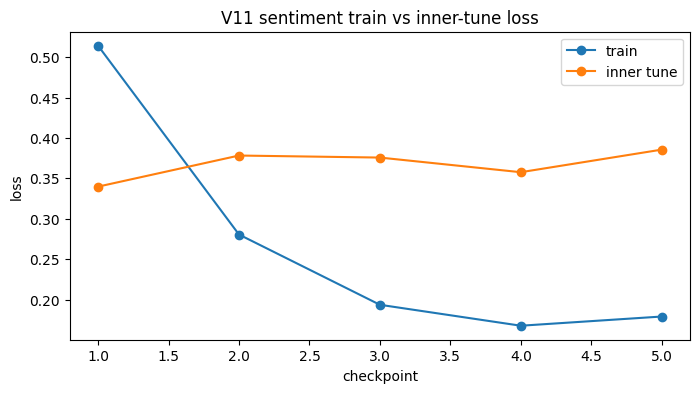

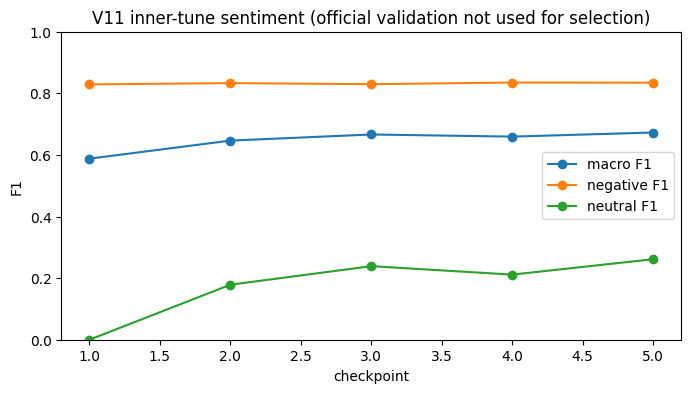

              precision    recall  f1-score   support

    positive     0.9376    0.9173    0.9273      3568
    negative     0.8133    0.7247    0.7665      1028
     neutral     0.2197    0.3871    0.2803       248

    accuracy                         0.8493      4844
   macro avg     0.6569    0.6764    0.6580      4844
weighted avg     0.8744    0.8493    0.8601      4844



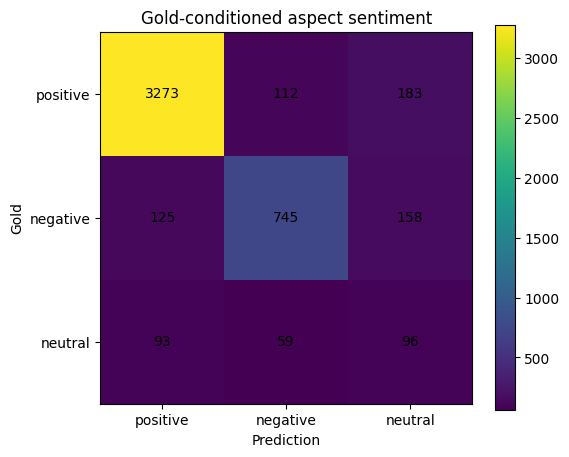

Macro F1: 0.6580265643274311 | Accuracy: 0.8492981007431875 | {'positive': 0.9273268168295793, 'negative': 0.7664609053497943, 'neutral': 0.28029197080291973}


In [38]:
if len(sentiment_history):
    x=np.arange(1,len(sentiment_history)+1)
    plt.figure(figsize=(8,4))
    plt.plot(x,sentiment_history.train_loss,marker="o",label="train")
    plt.plot(x,sentiment_history.val_loss,marker="o",label="inner tune")
    plt.xlabel("checkpoint"); plt.ylabel("loss"); plt.title("V11 sentiment train vs inner-tune loss"); plt.legend(); plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(x,sentiment_history.val_macro_f1,marker="o",label="macro F1")
    plt.plot(x,sentiment_history.val_negative_f1,marker="o",label="negative F1")
    plt.plot(x,sentiment_history.val_neutral_f1,marker="o",label="neutral F1")
    plt.ylim(0,1); plt.xlabel("checkpoint"); plt.ylabel("F1"); plt.title("V11 inner-tune sentiment (official validation not used for selection)"); plt.legend(); plt.show()

SENT_TEST=eval_sentiment(sentiment_model,test_sent) if sentiment_model is not None and test_sent else None
if SENT_TEST:
    y_true=[ID2SENT[i] for i in SENT_TEST["y_true"]]
    y_pred=[ID2SENT[i] for i in SENT_TEST["y_pred"]]
    print(classification_report(y_true,y_pred,labels=CONFIG["sentiment_labels"],digits=4,zero_division=0))

    cm=confusion_matrix(y_true,y_pred,labels=CONFIG["sentiment_labels"])
    plt.figure(figsize=(6,5)); plt.imshow(cm)
    plt.xticks(range(3),CONFIG["sentiment_labels"]); plt.yticks(range(3),CONFIG["sentiment_labels"])
    for i in range(3):
        for j in range(3):
            plt.text(j,i,cm[i,j],ha="center",va="center")
    plt.xlabel("Prediction"); plt.ylabel("Gold"); plt.title("Gold-conditioned aspect sentiment"); plt.colorbar(); plt.show()

    print("Macro F1:",SENT_TEST["macro_f1"],"| Accuracy:",SENT_TEST["accuracy"],"|",SENT_TEST["per_class_f1"])


### 9.2 Melakukan Kalibrasi Suhu


In [39]:
TEMPERATURE=1.0

def fit_temperature(logits_np,labels):
    if logits_np is None or len(logits_np)==0:
        return 1.0
    logits=torch.tensor(logits_np,dtype=torch.float32,device=DEVICE)
    y=torch.tensor(labels,dtype=torch.long,device=DEVICE)
    log_t=torch.zeros(1,requires_grad=True,device=DEVICE)
    opt=torch.optim.LBFGS([log_t],lr=.05,max_iter=50)
    loss_fn=nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad()
        t=torch.exp(log_t).clamp(.05,20)
        loss=loss_fn(logits/t,y)
        loss.backward()
        return loss
    opt.step(closure)
    return float(torch.exp(log_t).clamp(.05,20).detach().cpu())

if sentiment_model is not None and val_sent:
    v=eval_sentiment(sentiment_model,val_sent)
    TEMPERATURE=fit_temperature(v["logits"],v["y_true"])
print("Temperature:",TEMPERATURE)


# ============================================================
# V9 CALIBRATION / CONFIDENCE METRICS
# ============================================================
def expected_calibration_error(logits_np,labels,temperature=1.0,n_bins=None):
    n_bins=int(n_bins or CONFIG["ece_bins"])
    logits=torch.tensor(logits_np,dtype=torch.float32)
    probs=torch.softmax(logits/float(temperature),dim=-1).numpy()
    conf=probs.max(axis=1); pred=probs.argmax(axis=1)
    labels=np.asarray(labels)
    bins=np.linspace(0,1,n_bins+1)
    ece=0.0
    for lo,hi in zip(bins[:-1],bins[1:]):
        mask=(conf>lo)&(conf<=hi)
        if not mask.any(): continue
        acc=(pred[mask]==labels[mask]).mean()
        ece += mask.mean()*abs(acc-conf[mask].mean())
    return float(ece)

def multiclass_brier(logits_np,labels,temperature=1.0):
    logits=torch.tensor(logits_np,dtype=torch.float32)
    p=torch.softmax(logits/float(temperature),dim=-1).numpy()
    y=np.eye(3,dtype=np.float32)[np.asarray(labels,dtype=int)]
    return float(np.mean(np.sum((p-y)**2,axis=1)))

if SENT_TEST:
    V11_CALIBRATION={
        "ece":expected_calibration_error(SENT_TEST["logits"],SENT_TEST["y_true"],TEMPERATURE),
        "brier":multiclass_brier(SENT_TEST["logits"],SENT_TEST["y_true"],TEMPERATURE),
        "temperature":TEMPERATURE,
    }
    V10_CALIBRATION=V11_CALIBRATION
    V9_CALIBRATION=V11_CALIBRATION  # compatibility aliases
    print("V11 calibration:",V11_CALIBRATION)


Temperature: 0.8556287288665771
V11 calibration: {'ece': 0.02914410838157453, 'brier': 0.21628732979297638, 'temperature': 0.8556287288665771}


## Fase 10 — Menyiapkan Dataset Span


In [40]:
def unified_gold_spans(r,kind):
    key_s="aspect_start" if kind=="aspect" else "opinion_start"
    key_e="aspect_end" if kind=="aspect" else "opinion_end"
    return [(int(a[key_s]),int(a[key_e])) for a in r.get("annotations",[]) if a.get(key_s) is not None and a.get(key_e) is not None]

def terma_gold_spans(r,kind):
    target="ASP" if kind=="aspect" else "OPN"
    return [(x["start"],x["end"]) for x in r.get("spans",[]) if x["kind"]==target]

def char_to_bio(offsets,spans):
    labels=[-100]*len(offsets)
    for i,(s,e) in enumerate(offsets):
        if e>s: labels[i]=TAG2ID["O"]
    for gs,ge in spans:
        hit=[i for i,(s,e) in enumerate(offsets) if e>s and max(s,gs)<min(e,ge)]
        for j,i in enumerate(hit):
            labels[i]=TAG2ID["B" if j==0 else "I"]
    return labels

class SpanDataset(Dataset):
    def __init__(self,records,kind,source):
        self.items=[]
        for ridx,r in enumerate(records):
            text=str(r["text"])
            gold=unified_gold_spans(r,kind) if source=="unified" else terma_gold_spans(r,kind)
            if source=="unified" and r.get("rejected_annotation_count",0)>0 and not gold:
                continue
            enc=tokenizer(
                text,truncation=True,max_length=CONFIG["span_max_length"],
                stride=CONFIG["span_stride"],return_overflowing_tokens=True,
                return_offsets_mapping=True,padding=False
            )
            for wi in range(len(enc["input_ids"])):
                offsets=enc["offset_mapping"][wi]
                self.items.append({
                    "input_ids":enc["input_ids"][wi],"attention_mask":enc["attention_mask"][wi],
                    "labels":char_to_bio(offsets,gold),"offset_mapping":offsets,
                    "record_index":ridx,"text":text,
                    "sample_weight":float(r.get("sample_weight",1.0))
                })
    def __len__(self): return len(self.items)
    def __getitem__(self,idx): return self.items[idx]

def span_collate(batch):
    maxlen=max(len(x["input_ids"]) for x in batch)
    ids=[]; masks=[]; labels=[]
    extra={"offset_mapping":[],"record_index":[],"text":[],"sample_weights":[]}
    for x in batch:
        pad=maxlen-len(x["input_ids"])
        ids.append(x["input_ids"]+[tokenizer.pad_token_id]*pad)
        masks.append(x["attention_mask"]+[0]*pad)
        labels.append(x["labels"]+[-100]*pad)
        extra["offset_mapping"].append(x["offset_mapping"])
        extra["record_index"].append(x["record_index"])
        extra["text"].append(x["text"])
        extra["sample_weights"].append(float(x.get("sample_weight",1.0)))
    return {
        "input_ids":torch.tensor(ids),"attention_mask":torch.tensor(masks),"labels":torch.tensor(labels),
        "sample_weights":torch.tensor(extra.pop("sample_weights"),dtype=torch.float32),
        **extra
    }

train_unified=[r for r in records if r.get("split")=="train"]
val_unified=[r for r in records if r.get("split")=="validation"]
test_unified=[r for r in records if r.get("split")=="test"]
train_terma=[r for r in terma_records if r.get("split")=="train"]
val_terma=[r for r in terma_records if r.get("split")=="validation"]
test_terma=[r for r in terma_records if r.get("split")=="test"]
# ============================================================
# V7 SPAN TRAINING MIX
# ============================================================
# Core academic scientific splits remain separate.
train_unified=[r for r in records if r.get("split")=="train"]
val_unified=[r for r in records if r.get("split")=="validation"]
test_unified=[r for r in records if r.get("split")=="test"]
unseen_sight_unified=list(sight_unseen_records)

train_terma=[r for r in terma_records if r.get("split")=="train"]
val_terma=[r for r in terma_records if r.get("split")=="validation"]
test_terma=[r for r in terma_records if r.get("split")=="test"]

def terma_to_unified(r, include_aspect=True, include_opinion=True, split_override=None):
    asp = [x for x in r.get("spans",[]) if x.get("kind")=="ASP"]
    opn = [x for x in r.get("spans",[]) if x.get("kind")=="OPN"]
    anns=[]
    # TermA has no gold aspect-opinion relation. Keep each supervision type independent.
    if include_aspect:
        for x in asp:
            anns.append({
                "aspect_term":r["text"][x["start"]:x["end"]],
                "aspect_start":x["start"],"aspect_end":x["end"],
                "opinion_term":None,"opinion_start":None,"opinion_end":None,
                "sentiment":None,"aspect_category":None,
                "target_type":"explicit","relation_type":None,
            })
    if include_opinion:
        for x in opn:
            anns.append({
                "aspect_term":None,"aspect_start":None,"aspect_end":None,
                "opinion_term":r["text"][x["start"]:x["end"]],
                "opinion_start":x["start"],"opinion_end":x["end"],
                "sentiment":None,"aspect_category":None,
                "target_type":"opinion_only","relation_type":None,
            })
    return {
        "id":"terma_unified__"+r["id"],
        "text":r["text"],
        "domain":r.get("domain","hotel"),
        "source_dataset":"IndoNLU-TermA-Unified",
        "source_record_id":r.get("source_record_id",r["id"]),
        "split":split_override or r.get("split"),
        "annotations":anns,
        "rejected_annotation_count":0,
    }

terma_aspect_train_u=[
    terma_to_unified(r,include_aspect=True,include_opinion=False,split_override="train")
    for r in train_terma if any(x.get("kind")=="ASP" for x in r.get("spans",[]))
]
terma_opinion_train_u=[
    terma_to_unified(r,include_aspect=False,include_opinion=True,split_override="train")
    for r in train_terma if any(x.get("kind")=="OPN" for x in r.get("spans",[]))
]
terma_opinion_val_u=[
    terma_to_unified(r,include_aspect=False,include_opinion=True,split_override="validation")
    for r in val_terma if any(x.get("kind")=="OPN" for x in r.get("spans",[]))
]

aspect_train_records_v7 = train_unified + (
    terma_aspect_train_u if CONFIG["use_terma_aspect_aux"] else []
) + (gmaps_train_records if CONFIG["use_gmaps_gold"] else [])

gmaps_silver_span_aux=[]
if CONFIG.get("use_gmaps_silver_aux",False):
    for _r in gmaps_silver_aux_records:
        _c=deepcopy(_r)
        _c["sample_weight"]=CONFIG["gmaps_silver_aux_loss_weight"]
        gmaps_silver_span_aux.append(_c)
aspect_train_records_v7 = aspect_train_records_v7 + gmaps_silver_span_aux

# GMaps validation may be included in checkpoint selection once available.
aspect_val_records_v7 = val_unified + (
    gmaps_val_records if CONFIG["use_gmaps_gold"] else []
)

opinion_train_records_v7 = terma_opinion_train_u + (
    gmaps_train_records if CONFIG["use_gmaps_gold"] else []
)
opinion_train_records_v7 = opinion_train_records_v7 + gmaps_silver_span_aux
opinion_val_records_v7 = terma_opinion_val_u + (
    gmaps_val_records if CONFIG["use_gmaps_gold"] else []
)

print(
    "V7 aspect records:",
    {"core_train":len(train_unified),
     "terma_aux":len(terma_aspect_train_u),
     "gmaps_gold_train":len(gmaps_train_records),
     "gmaps_silver_aux":len(gmaps_silver_span_aux),
     "train_total":len(aspect_train_records_v7),
     "val_total":len(aspect_val_records_v7)}
)
print(
    "V7 opinion records:",
    {"terma_train":len(terma_opinion_train_u),
     "gmaps_gold_train":len(gmaps_train_records),
     "gmaps_silver_aux":len(gmaps_silver_span_aux),
     "train_total":len(opinion_train_records_v7),
     "val_total":len(opinion_val_records_v7)}
)


V7 aspect records: {'core_train': 7455, 'terma_aux': 2483, 'gmaps_gold_train': 0, 'gmaps_silver_aux': 315, 'train_total': 10253, 'val_total': 1885}
V7 opinion records: {'terma_train': 2803, 'gmaps_gold_train': 0, 'gmaps_silver_aux': 315, 'train_total': 3118, 'val_total': 937}


### 10.1 Menyusun Daftar Training Aspek dan Opini


In [41]:
# ============================================================
# V11 SPAN AUXILIARY PATCH — EXPLICIT TRAIN SPANS ONLY
# ============================================================
_v10_syn_span = [deepcopy(r) for r in v10_synthetic_train_records] if ABLATION["use_synthetic"] else []
_v11_syn_span = [
    deepcopy(r) for r in v11_synthetic_train_records
    if any(
        a.get("aspect_start") is not None or a.get("opinion_start") is not None
        for a in r.get("annotations", [])
    )
] if ABLATION["use_v11_synthetic"] else []
if _v10_syn_span or _v11_syn_span:
    aspect_train_records_v7 = aspect_train_records_v7 + _v10_syn_span + _v11_syn_span
    opinion_train_records_v7 = opinion_train_records_v7 + _v10_syn_span + _v11_syn_span
assert all(r.get("split") == "train" for r in _v10_syn_span + _v11_syn_span)
print("V11 aspect train records:", len(aspect_train_records_v7), {
    "v10_synthetic": len(_v10_syn_span),
    "v11_synthetic_templates": len(_v11_syn_span),
    "gmaps_silver": len(gmaps_silver_span_aux),
})
print("V11 opinion train records:", len(opinion_train_records_v7))


V11 aspect train records: 11013 {'v10_synthetic': 748, 'v11_synthetic_templates': 12, 'gmaps_silver': 315}
V11 opinion train records: 3878


## Fase 11 — Melatih dan Mengevaluasi Model Span


In [42]:
def decode_bio_offsets(offsets,pred_ids,entity_probs):
    out=[]; cur=None
    for i,((s,e),pid) in enumerate(zip(offsets,pred_ids)):
        if e<=s: continue
        tag=ID2TAG[int(pid)]; conf=float(entity_probs[i])
        if tag=="B":
            if cur: out.append(cur)
            cur={"start":s,"end":e,"scores":[conf]}
        elif tag=="I" and cur is not None:
            cur["end"]=e; cur["scores"].append(conf)
        else:
            if cur: out.append(cur); cur=None
    if cur: out.append(cur)
    for x in out:
        x["score"]=float(np.mean(x.pop("scores")))
    return out

def span_iou(a,b):
    inter=max(0,min(a["end"],b["end"])-max(a["start"],b["start"]))
    union=max(a["end"],b["end"])-min(a["start"],b["start"])
    return inter/union if union else 0.0

def nms_spans(spans,iou_threshold=.55):
    ordered=sorted(spans,key=lambda x:(-x.get("score",0),-(x["end"]-x["start"])))
    kept=[]
    for cand in ordered:
        overlap=False
        for k in kept:
            exact=cand["start"]==k["start"] and cand["end"]==k["end"]
            contained=(cand["start"]<=k["start"] and cand["end"]>=k["end"]) or (k["start"]<=cand["start"] and k["end"]>=cand["end"])
            if exact or contained or span_iou(cand,k)>=iou_threshold:
                overlap=True; break
        if not overlap: kept.append(cand)
    return sorted(kept,key=lambda x:(x["start"],x["end"]))

def exact_prf(golds,preds):
    tp=sum(len(g&p) for g,p in zip(golds,preds)); fp=sum(len(p-g) for g,p in zip(golds,preds)); fn=sum(len(g-p) for g,p in zip(golds,preds))
    p=tp/(tp+fp) if tp+fp else 0.; r=tp/(tp+fn) if tp+fn else 0.
    f=2*p*r/(p+r) if p+r else 0.
    return {"precision":p,"recall":r,"f1":f,"tp":tp,"fp":fp,"fn":fn}

@torch.no_grad()
def predict_span_records(model,records,kind,source):
    ds=SpanDataset(records,kind,source)
    loader=DataLoader(ds,batch_size=CONFIG["span_batch_size"],collate_fn=span_collate)
    by_record=defaultdict(list); model.eval()
    for batch in loader:
        offsets=batch.pop("offset_mapping"); ridxs=batch.pop("record_index"); batch.pop("text"); batch.pop("labels"); batch.pop("sample_weights",None)
        inp={k:v.to(DEVICE) for k,v in batch.items()}
        logits=model(**inp).logits
        soft=logits.softmax(-1); pred=soft.argmax(-1); entity=soft[:,:,1:].max(-1).values
        for bi in range(pred.size(0)):
            n=len(offsets[bi])
            spans=decode_bio_offsets(offsets[bi],pred[bi,:n].cpu().tolist(),entity[bi,:n].cpu().tolist())
            by_record[ridxs[bi]].extend(spans)
    return by_record

def eval_span(model,records,kind,source,threshold=0.):
    by=predict_span_records(model,records,kind,source)
    golds=[]; preds=[]
    for i,r in enumerate(records):
        g=set(unified_gold_spans(r,kind) if source=="unified" else terma_gold_spans(r,kind))
        p={(x["start"],x["end"]) for x in nms_spans([z for z in by.get(i,[]) if z["score"]>=threshold])}
        golds.append(g); preds.append(p)
    return exact_prf(golds,preds)

def tag_weights(ds,max_ratio=1.5,power=.15):
    c=Counter()
    for x in ds.items: c.update(v for v in x["labels"] if v!=-100)
    total=sum(c.values())
    raw=[(total/max(1,c[i]))**power for i in range(3)]
    base=raw[0]
    return torch.tensor([min(max_ratio,x/base) for x in raw],dtype=torch.float32,device=DEVICE)

def train_span(kind,train_records,val_records,source):
    ds=SpanDataset(train_records,kind,source)
    loader=DataLoader(ds,batch_size=CONFIG["span_batch_size"],shuffle=True,collate_fn=span_collate)
    model=AutoModelForTokenClassification.from_pretrained(CONFIG["encoder"],num_labels=3,id2label=ID2TAG,label2id=TAG2ID)
    model.resize_token_embeddings(len(tokenizer)); model.to(DEVICE)
    loss_fn=nn.CrossEntropyLoss(weight=tag_weights(ds),ignore_index=-100,reduction="none")
    opt=torch.optim.AdamW(model.parameters(),lr=CONFIG["span_lr"],weight_decay=.01)
    best_state=None; best=-1.; bad=0; hist=[]
    for epoch in range(1,CONFIG["span_epochs"]+1):
        model.train(); losses=[]
        for batch in tqdm(loader,desc=f"{kind} {epoch}/{CONFIG['span_epochs']}"):
            batch.pop("offset_mapping"); batch.pop("record_index"); batch.pop("text")
            sample_weights=batch.pop("sample_weights").to(DEVICE)
            labels=batch.pop("labels").to(DEVICE)
            inp={k:v.to(DEVICE) for k,v in batch.items()}
            opt.zero_grad(set_to_none=True)
            logits=model(**inp).logits
            tok_loss=loss_fn(logits.view(-1,3),labels.view(-1)).view(labels.shape)
            valid=(labels!=-100).float()
            seq_loss=(tok_loss*valid).sum(1)/valid.sum(1).clamp_min(1.0)
            loss=(seq_loss*sample_weights).sum()/sample_weights.sum().clamp_min(1e-8)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            losses.append(float(loss.item()))
        val=eval_span(model,val_records,kind,source)
        row={"epoch":epoch,"train_loss":np.mean(losses),"val_f1":val["f1"],"val_precision":val["precision"],"val_recall":val["recall"]}
        print(row); hist.append(row)
        if val["f1"]>best:
            best=val["f1"]; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad+=1
            if bad>=CONFIG["span_patience"]: break
    if best_state is not None: model.load_state_dict(best_state)
    return model,pd.DataFrame(hist)

RUN_SPAN_TRAINING=True
aspect_model=opinion_model=None
aspect_history=opinion_history=pd.DataFrame()
ASPECT_TEST_METRICS=None
OPINION_TEST_METRICS=None

if RUN_SPAN_TRAINING and train_unified and val_unified:
    aspect_model,aspect_history=train_span("aspect",aspect_train_records_v7,aspect_val_records_v7,"unified")
    aspect_model.save_pretrained(MODEL_DIR/"aspect_tagger")

if RUN_SPAN_TRAINING and opinion_train_records_v7 and opinion_val_records_v7:
    opinion_model,opinion_history=train_span("opinion",opinion_train_records_v7,opinion_val_records_v7,"unified")
    opinion_model.save_pretrained(MODEL_DIR/"opinion_tagger")# V6 explicit held-out span metrics.
if aspect_model is not None and test_unified:
    ASPECT_TEST_METRICS=eval_span(aspect_model,test_unified,"aspect","unified")
    print("Aspect held-out exact:",ASPECT_TEST_METRICS)

if opinion_model is not None and test_terma:
    OPINION_TEST_METRICS=eval_span(opinion_model,test_terma,"opinion","terma")
    print("Opinion held-out exact:",OPINION_TEST_METRICS)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at /content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


aspect 1/5:   0%|          | 0/687 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': np.float64(0.21285987657317254), 'val_f1': 0.6317460317460317, 'val_precision': 0.7173756308579669, 'val_recall': 0.5643788996029495}


aspect 2/5:   0%|          | 0/687 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': np.float64(0.12434764190684065), 'val_f1': 0.6300661109514228, 'val_precision': 0.6386946386946387, 'val_recall': 0.6216676120249575}


...

{'epoch': 3, 'train_loss': np.float64(0.04489418974054264), 'val_f1': 0.9776867963152508, 'val_precision': 0.9664103601780656, 'val_recall': 0.9892294946147473}


opinion 4/5:   0%|          | 0/243 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': np.float64(0.02861316463672422), 'val_f1': 0.9894649865730221, 'val_precision': 0.9868149979398434, 'val_recall': 0.992129246064623}


opinion 5/5:   0%|          | 0/243 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': np.float64(0.016954236090185173), 'val_f1': 0.9939995861783572, 'val_precision': 0.992972302604382, 'val_recall': 0.9950289975144988}
Aspect held-out exact: {'precision': 0.7476600524148259, 'recall': 0.581537565521258, 'f1': 0.6542178542178543, 'tp': 1997, 'fp': 674, 'fn': 1437}
Opinion held-out exact: {'precision': 0.9071399092034668, 'recall': 0.9212070410729254, 'f1': 0.9141193595342068, 'tp': 2198, 'fp': 225, 'fn': 188}


### 11.1 Menentukan Profil Operasi


In [43]:
def tune_threshold(model,records,kind,source,beta=1.,precision_floor=0.):
    by=predict_span_records(model,records,kind,source)
    rows=[]
    for thr in np.round(np.arange(.10,.91,.05),2):
        golds=[]; preds=[]
        for i,r in enumerate(records):
            g=set(unified_gold_spans(r,kind) if source=="unified" else terma_gold_spans(r,kind))
            p={(x["start"],x["end"]) for x in nms_spans([z for z in by.get(i,[]) if z["score"]>=thr])}
            golds.append(g); preds.append(p)
        m=exact_prf(golds,preds)
        b2=beta*beta
        fb=(1+b2)*m["precision"]*m["recall"]/(b2*m["precision"]+m["recall"]) if m["precision"]+m["recall"] else 0.
        rows.append({"threshold":thr,**m,"fbeta":fb})
    df=pd.DataFrame(rows)
    eligible=df[df.precision>=precision_floor]
    if eligible.empty: eligible=df
    best=eligible.sort_values(["fbeta","f1","precision"],ascending=False).iloc[0]
    return float(best.threshold),df

INFERENCE_PROFILES={
    "scientific_balanced":{"aspect_threshold":.5,"opinion_threshold":.5},
    "production_precision":{"aspect_threshold":.6,"opinion_threshold":.65},
    "maps_high_recall":{"aspect_threshold":.35,"opinion_threshold":.35},
}

if aspect_model is not None and val_unified:
    INFERENCE_PROFILES["scientific_balanced"]["aspect_threshold"],_=tune_threshold(aspect_model,val_unified,"aspect","unified",1.,0.)
    INFERENCE_PROFILES["production_precision"]["aspect_threshold"],_=tune_threshold(aspect_model,val_unified,"aspect","unified",.5,.70)
    _maps_aspect_val = gmaps_val_records if gmaps_val_records else val_unified
    INFERENCE_PROFILES["maps_high_recall"]["aspect_threshold"],_=tune_threshold(
        aspect_model,_maps_aspect_val,"aspect","unified",2.,.50
    )

if opinion_model is not None and val_terma:
    INFERENCE_PROFILES["scientific_balanced"]["opinion_threshold"],_=tune_threshold(opinion_model,val_terma,"opinion","terma",1.,0.)
    INFERENCE_PROFILES["production_precision"]["opinion_threshold"],_=tune_threshold(opinion_model,val_terma,"opinion","terma",.5,.85)
    if gmaps_val_records:
        INFERENCE_PROFILES["maps_high_recall"]["opinion_threshold"],_=tune_threshold(
            opinion_model,gmaps_val_records,"opinion","unified",2.,.70
        )
    else:
        INFERENCE_PROFILES["maps_high_recall"]["opinion_threshold"],_=tune_threshold(
            opinion_model,val_terma,"opinion","terma",2.,.70
        )

print(json.dumps(INFERENCE_PROFILES,indent=2))


{
  "scientific_balanced": {
    "aspect_threshold": 0.5,
    "opinion_threshold": 0.85
  },
  "production_precision": {
    "aspect_threshold": 0.75,
    "opinion_threshold": 0.9
  },
  "maps_high_recall": {
    "aspect_threshold": 0.1,
    "opinion_threshold": 0.1
  }
}


## Fase 12 — Menjalankan Inferensi Sliding-Window


In [44]:
@torch.no_grad()
def infer_spans_single(text,model,threshold):
    if model is None: return []
    enc=tokenizer(
        str(text),truncation=True,max_length=CONFIG["span_max_length"],stride=CONFIG["span_stride"],
        return_overflowing_tokens=True,return_offsets_mapping=True,padding=False
    )
    all_spans=[]; model.eval()
    for wi in range(len(enc["input_ids"])):
        ids=torch.tensor([enc["input_ids"][wi]],device=DEVICE)
        mask=torch.tensor([enc["attention_mask"][wi]],device=DEVICE)
        offsets=enc["offset_mapping"][wi]
        logits=model(input_ids=ids,attention_mask=mask).logits[0]
        soft=logits.softmax(-1); pred=soft.argmax(-1).cpu().tolist(); entity=soft[:,1:].max(-1).values.cpu().tolist()
        all_spans.extend([x for x in decode_bio_offsets(offsets,pred[:len(offsets)],entity[:len(offsets)]) if x["score"]>=threshold])
    return nms_spans(all_spans)

def infer_spans(text,model,threshold,dual_view=False):
    raw=str(text)
    out=infer_spans_single(raw,model,threshold)
    for x in out: x["source_view"]="raw"

    if not dual_view or not CONFIG["enable_reversible_normalization"]:
        return nms_spans(out)

    al=normalize_gmaps_text_with_alignment(raw)
    norm=infer_spans_single(al["normalized_text"],model,threshold)
    mapped=[]
    for x in norm:
        p=normalized_span_to_raw(x["start"],x["end"],al)
        if p is None: continue
        mapped.append({"start":p[0],"end":p[1],"score":x["score"],"source_view":"normalized"})
    return nms_spans(out+mapped)


### 12.1 Mempelajari Relasi Aspek-Opini


In [45]:
# ============================================================
# SECTION 14 — V10 SAFE ASPECT–OPINION RELATION TRAINING
# MISSING SILVER PAIR != NEGATIVE
# ============================================================
def _mark_relation_pair(text,a_s,a_e,o_s,o_e):
    out=str(text)
    for s,e,l,r in sorted([(int(a_s),int(a_e),'[ASP]','[/ASP]'),(int(o_s),int(o_e),'[OPN]','[/OPN]')],key=lambda x:x[0],reverse=True):
        out=out[:s]+l+' '+out[s:e]+' '+r+out[e:]
    return out

def _gold_relation_examples(records_in):
    # Cross-pair negatives are allowed ONLY for human-approved complete records.
    out=[]
    for r in records_in:
        if str(r.get('human_status','')).lower() not in GOLD_STATUSES or not r.get('annotation_complete',False): continue
        anns=[a for a in r.get('annotations',[]) if a.get('aspect_start') is not None and a.get('opinion_start') is not None and a.get('relation') is not False]
        aspects=sorted(set((int(a['aspect_start']),int(a['aspect_end'])) for a in anns)); opinions=sorted(set((int(a['opinion_start']),int(a['opinion_end'])) for a in anns))
        positive={(int(a['aspect_start']),int(a['aspect_end']),int(a['opinion_start']),int(a['opinion_end'])) for a in anns}
        for a_s,a_e,o_s,o_e in positive:
            out.append({'text':_mark_relation_pair(r['text'],a_s,a_e,o_s,o_e),'label':1,'split':r['split'],'record_id':r['id'],'place_id':r.get('place_id'),'source_dataset':'GMAPS-HUMAN-GOLD','sample_weight':1.0})
        for a_s,a_e in aspects:
            sl,sr=_sentence_bounds(str(r['text']),a_s,a_e)
            for o_s,o_e in opinions:
                if (a_s,a_e,o_s,o_e) in positive or not (sl<=o_s and o_e<=sr): continue
                out.append({'text':_mark_relation_pair(r['text'],a_s,a_e,o_s,o_e),'label':0,'split':r['split'],'record_id':r['id'],'place_id':r.get('place_id'),'source_dataset':'GMAPS-HUMAN-GOLD','sample_weight':1.0})
    return out

# Real GMaps SILVER: explicit positive relation links only. No closure, ever.
def _silver_positive_relation_examples():
    if not ABLATION['use_silver']: return []
    df=V10_GMAPS_SILVER_TRAIN_DF[V10_GMAPS_SILVER_TRAIN_DF['relation_positive_only_eligible'].astype(bool)].copy()
    out=[]
    for _,r in df.iterrows():
        if pd.isna(r['aspect_start']) or pd.isna(r['opinion_start']): continue
        out.append({'text':_mark_relation_pair(r['review_text_raw'],int(r['aspect_start']),int(r['aspect_end']),int(r['opinion_start']),int(r['opinion_end'])),
                    'label':1,'split':'train','record_id':str(r['review_id']),'place_id':str(r['place_id']),'source_dataset':'GMAPS-V9.1-SILVER-POSITIVE',
                    'sample_weight':float(CONFIG['relation_gmaps_silver_positive_weight'])})
    return out

# Synthetic: use only explicit labeled relation rows from the audited file.
def _synthetic_relation_examples():
    if not ABLATION['use_synthetic']: return []
    text_map=V10_SYN_REV_DF.set_index('review_id')['review_text_raw'].astype(str).to_dict(); out=[]
    for _,r in V10_SYN_REL_DF.iterrows():
        label=int(r['relation_label']); rtype=str(r['relation_type'])
        assert (label,rtype) in {(1,'positive'),(0,'hard_negative')}
        w=CONFIG['relation_synthetic_positive_weight'] if label==1 else CONFIG['relation_synthetic_hard_negative_weight']
        out.append({'text':_mark_relation_pair(text_map[str(r['review_id'])],int(r['aspect_start']),int(r['aspect_end']),int(r['opinion_start']),int(r['opinion_end'])),
                    'label':label,'split':'train','record_id':str(r['review_id']),'place_id':f"synthetic::{r['review_id']}",'source_dataset':f'SYNTHETIC-V10-{rtype}','sample_weight':float(w)})
    return out


# V11 synthetic: explicit listed pairs are positive. Cross-pair hard negatives are
# created only when the record declares complete hard_multi_aspect supervision.
def _v11_synthetic_relation_examples():
    if not ABLATION["use_v11_synthetic"]:
        return []
    out = []
    for record in v11_synthetic_train_records:
        explicit = [
            a for a in record.get("annotations", [])
            if a.get("aspect_start") is not None and a.get("opinion_start") is not None
        ]
        positives = {
            (
                int(a["aspect_start"]), int(a["aspect_end"]),
                int(a["opinion_start"]), int(a["opinion_end"]),
            ) for a in explicit
        }
        for a_s, a_e, o_s, o_e in sorted(positives):
            out.append({
                "text": _mark_relation_pair(record["text"], a_s, a_e, o_s, o_e),
                "label": 1, "split": "train", "record_id": record["id"],
                "place_id": record.get("place_id"),
                "source_dataset": "SYNTHETIC-V11-positive",
                "sample_weight": float(CONFIG["relation_v11_positive_weight"]),
            })
        if record.get("annotation_complete", False) and record.get("difficulty_level") == "hard_multi_aspect":
            aspects = sorted({(x[0], x[1]) for x in positives})
            opinions = sorted({(x[2], x[3]) for x in positives})
            for a_s, a_e in aspects:
                for o_s, o_e in opinions:
                    pair = (a_s, a_e, o_s, o_e)
                    if pair in positives:
                        continue
                    out.append({
                        "text": _mark_relation_pair(record["text"], a_s, a_e, o_s, o_e),
                        "label": 0, "split": "train", "record_id": record["id"],
                        "place_id": record.get("place_id"),
                        "source_dataset": "SYNTHETIC-V11-hard_negative",
                        "sample_weight": float(CONFIG["relation_v11_hard_negative_weight"]),
                    })
    return out


_gold_rel=_gold_relation_examples(gmaps_gold_records)
_gold_train=[x for x in _gold_rel if x['split']=='train']; relation_test=[x for x in _gold_rel if x['split']=='test']; _gold_val=[x for x in _gold_rel if x['split']=='validation']
_silver_rel=_silver_positive_relation_examples()
_syn_rel=_synthetic_relation_examples()
_v11_rel=_v11_synthetic_relation_examples()
# Cap only V10 synthetic positives; V11 explicit positives and hard negatives remain grouped by template.
_syn_neg=[x for x in _syn_rel if x['label']==0]
_syn_pos=[x for x in _syn_rel if x['label']==1]
_syn_pos_cap=int(max(1, round(CONFIG['relation_positive_to_negative_cap']*len(_syn_neg)))) if _syn_neg else len(_syn_pos)
if len(_syn_pos)>_syn_pos_cap:
    _syn_pos=sorted(_syn_pos,key=lambda x:hashlib.sha1((str(x['record_id'])+'|'+x['text']).encode()).hexdigest())[:_syn_pos_cap]
_syn_rel=_syn_pos+_syn_neg
_aux_rel=_silver_rel+_syn_rel+_v11_rel

# Deterministic train-derived auxiliary tune split by PLACE/REVIEW; never supplied SILVER validation/test.
def _rel_tune_key(x): return x.get('place_id') or x.get('record_id')
_aux_train=[];_aux_tune=[]
for x in _aux_rel:
    h=_v10_hash01(_rel_tune_key(x),seed=7771)
    (_aux_tune if h<CONFIG['relation_aux_tune_fraction'] else _aux_train).append(x)

relation_train=list(_gold_train)+list(_aux_train)
relation_val=list(_gold_val) if _gold_val else list(_aux_tune)
RELATION_SUPERVISION='gold+aux' if _gold_train and _aux_train else ('gold' if _gold_train else ('aux_train_only' if _aux_train else 'none'))

# Audit source/label balance. No auto-negative path exists for SILVER.
_rel_counts=Counter((x['source_dataset'],x['label']) for x in relation_train)
V10_RELATION_AUDIT=pd.DataFrame([{'source':src,'label':label,'n':n} for (src,label),n in sorted(_rel_counts.items())])
print('V11 relation train counts:',dict(_rel_counts)); display(V10_RELATION_AUDIT)
assert not any(x['label']==0 and 'SILVER' in x['source_dataset'] for x in relation_train), 'Missing SILVER pair became negative — forbidden'

class RelationDataset(Dataset):
    def __init__(self,items): self.items=items
    def __len__(self): return len(self.items)
    def __getitem__(self,i):
        x=self.items[i]; enc=tokenizer(x['text'],truncation=True,max_length=CONFIG['sentiment_max_length'])
        return {**enc,'labels':int(x['label']),'sample_weight':float(x.get('sample_weight',1.0))}

def relation_collate(batch):
    labels=torch.tensor([x.pop('labels') for x in batch],dtype=torch.long); sw=torch.tensor([x.pop('sample_weight',1.0) for x in batch],dtype=torch.float32)
    enc=tokenizer.pad(batch,return_tensors='pt'); enc['labels']=labels;enc['sample_weights']=sw;return enc

@torch.no_grad()
def eval_relation(model,items,threshold=.5):
    if model is None or not items:return None
    dl=DataLoader(RelationDataset(items),batch_size=CONFIG['sentiment_batch_size'],collate_fn=relation_collate);ys=[];scores=[];model.eval()
    for b in dl:
        y=b.pop('labels');b.pop('sample_weights',None);logits=model(**{k:v.to(DEVICE) for k,v in b.items()}).logits
        scores.extend(logits.softmax(-1)[:,1].cpu().tolist());ys.extend(y.tolist())
    ps=[int(x>=threshold) for x in scores];p,r,f,_=precision_recall_fscore_support(ys,ps,average='binary',zero_division=0)
    return {'precision':float(p),'recall':float(r),'f1':float(f),'scores':scores,'labels':ys}

relation_history=[]

def train_relation_v10():
    global relation_history
    relation_history=[]
    pos=sum(x['label']==1 for x in relation_train);neg=sum(x['label']==0 for x in relation_train)
    if not relation_train or not relation_val or pos<50 or neg<50:
        print('Relation training skipped: insufficient safe positive/hard-negative supervision.',{'positive':pos,'negative':neg});return None,CONFIG['relation_threshold_default'],None,None
    model=AutoModelForSequenceClassification.from_pretrained(CONFIG['encoder'],num_labels=2);model.resize_token_embeddings(len(tokenizer));model.to(DEVICE)
    dl=DataLoader(RelationDataset(relation_train),batch_size=CONFIG['sentiment_batch_size'],shuffle=True,collate_fn=relation_collate);opt=torch.optim.AdamW(model.parameters(),lr=CONFIG['relation_lr'],weight_decay=.01)
    best_state=None;best=-1.;best_thr=.5;best_val=None
    for epoch in range(1,CONFIG['relation_epochs']+1):
        model.train();losses=[]
        for b in tqdm(dl,desc=f"relation {epoch}/{CONFIG['relation_epochs']}"):
            labels=b.pop('labels').to(DEVICE);sw=b.pop('sample_weights').to(DEVICE);inp={k:v.to(DEVICE) for k,v in b.items()};opt.zero_grad(set_to_none=True)
            per=nn.functional.cross_entropy(model(**inp).logits,labels,reduction='none');loss=(per*sw).sum()/sw.sum().clamp_min(1e-8);loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),1.0);opt.step();losses.append(float(loss.item()))
        rows=[]
        for thr in np.arange(.20,.81,.05):
            m=eval_relation(model,relation_val,float(thr))
            if m: rows.append((m['f1'],m['precision'],float(thr),m))
        if rows:
            rows.sort(reverse=True,key=lambda z:(z[0],z[1]));score=rows[0][0]
            history_row={'task':'relation','stage':'relation_hardening','epoch':epoch,'train_loss':float(np.mean(losses)),'validation_loss':np.nan,'macro_f1':np.nan,'positive_f1':np.nan,'negative_f1':np.nan,'neutral_f1':np.nan,'aspect_f1':np.nan,'relation_f1':float(score),'relation_precision':float(rows[0][3]['precision']),'relation_recall':float(rows[0][3]['recall']),'threshold':rows[0][2]}
            relation_history.append(history_row);print(history_row)
            if score>best: best=score;best_thr=rows[0][2];best_val=rows[0][3];best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if best_state is not None:model.load_state_dict(best_state)
    model.save_pretrained(MODEL_DIR/'relation_classifier')
    gold_test=eval_relation(model,relation_test,best_thr) if relation_test else None
    return model,best_thr,gold_test,best_val

relation_model,RELATION_THRESHOLD,RELATION_TEST_METRICS,RELATION_AUX_TUNE_METRICS=train_relation_v10()
relation_history=pd.DataFrame(relation_history)
RELATION_GOLD_VALIDATED=bool(relation_test and RELATION_TEST_METRICS)
print('Relation model learned:',relation_model is not None,'| supervision:',RELATION_SUPERVISION,'| threshold:',RELATION_THRESHOLD)
if RELATION_AUX_TUNE_METRICS: print('Relation AUX internal tune (NOT GOLD benchmark):',{k:v for k,v in RELATION_AUX_TUNE_METRICS.items() if k not in {'scores','labels'}})
if RELATION_TEST_METRICS: print('Relation HUMAN GOLD held-out:',{k:v for k,v in RELATION_TEST_METRICS.items() if k not in {'scores','labels'}})


V11 relation train counts: {('GMAPS-V9.1-SILVER-POSITIVE', 1): 696, ('SYNTHETIC-V10-positive', 1): 1145, ('SYNTHETIC-V10-hard_negative', 0): 575, ('SYNTHETIC-V11-positive', 1): 16, ('SYNTHETIC-V11-hard_negative', 0): 24}


,source,label,n
0,GMAPS-V9.1-SILVER-POSITIVE,1,696
1,SYNTHETIC-V10-hard_negative,0,575
2,SYNTHETIC-V10-positive,1,1145
3,SYNTHETIC-V11-hard_negative,0,24
4,SYNTHETIC-V11-positive,1,16


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


relation 1/3:   0%|          | 0/154 [00:00<?, ?it/s]

{'task': 'relation', 'stage': 'relation_hardening', 'epoch': 1, 'train_loss': 0.5129825262377015, 'validation_loss': nan, 'macro_f1': nan, 'positive_f1': nan, 'negative_f1': nan, 'neutral_f1': nan, 'aspect_f1': nan, 'relation_f1': 0.9781659388646288, 'relation_precision': 0.9940828402366864, 'relation_recall': 0.9627507163323782, 'threshold': 0.7999999999999998}


relation 2/3:   0%|          | 0/154 [00:00<?, ?it/s]

{'task': 'relation', 'stage': 'relation_hardening', 'epoch': 2, 'train_loss': 0.1295772564167296, 'validation_loss': nan, 'macro_f1': nan, 'positive_f1': nan, 'negative_f1': nan, 'neutral_f1': nan, 'aspect_f1': nan, 'relation_f1': 0.9884393063583815, 'relation_precision': 0.9970845481049563, 'relation_recall': 0.9799426934097422, 'threshold': 0.2}


relation 3/3:   0%|          | 0/154 [00:00<?, ?it/s]

{'task': 'relation', 'stage': 'relation_hardening', 'epoch': 3, 'train_loss': 0.056923866189763785, 'validation_loss': nan, 'macro_f1': nan, 'positive_f1': nan, 'negative_f1': nan, 'neutral_f1': nan, 'aspect_f1': nan, 'relation_f1': 0.9985693848354793, 'relation_precision': 0.9971428571428571, 'relation_recall': 1.0, 'threshold': 0.2}
Relation model learned: True | supervision: aux_train_only | threshold: 0.2
Relation AUX internal tune (NOT GOLD benchmark): {'precision': 0.9971428571428571, 'recall': 1.0, 'f1': 0.9985693848354793}


## Fase 13 — Melatih Taksonomi Aspek


In [46]:
# ============================================================
# V10 CANONICAL TAXONOMY
# ============================================================
V11_TAXONOMY_LABELS=[
    'Food Quality','Beverage Quality','Service Quality','Service Speed','Waiting Time',
    'Staff Attitude','Professionalism','Price & Value','Facilities','Cleanliness','Parking',
    'Location & Access','Ambience','Portion','Menu Variety','Digital Service',
    'Overall Experience','Other'
]
V10_TAXONOMY_LABELS=V11_TAXONOMY_LABELS

def canonical_taxonomy_label(raw_label,aspect_term='',domain_hint=''):
    raw=str(raw_label or '').lower().replace('_',' ').replace('#',' ')
    asp=str(aspect_term or '').lower(); dom=str(domain_hint or '').lower()
    text=f'{raw} {asp}'

    # Aspect/category-first canonicalization. Opinion polarity is never used here.
    if re.search(r'\b(waiting time|queue|antrean|antrian|waiting)\b',raw): return 'Waiting Time'
    if re.search(r'\b(service speed|order speed|speed)\b',raw): return 'Service Speed'
    if re.search(r'\b(professionalism|professional|explanation quality|penjelasan)\b',raw): return 'Professionalism'
    if re.search(r'\b(price|harga|value|biaya|cost)\b',text): return 'Price & Value'
    if re.search(r'\b(staff attitude|cashier|barista|pegawai|petugas|staff|employee|kasir|dokter|doctor|perawat|nurse|midwife|bidan)\b',raw): return 'Staff Attitude'
    if re.search(r'\b(parking|parkir)\b',text): return 'Parking'
    if re.search(r'\b(location|lokasi|access|akses|accessibility|strategis|jalan)\b',text): return 'Location & Access'
    if re.search(r'\b(clean|cleanliness|kebersihan|bersih|kotor)\b',raw): return 'Cleanliness'
    if re.search(r'\b(portion|porsi)\b',text): return 'Portion'
    if re.search(r'\b(menu variety|variety|pilihan menu)\b',raw): return 'Menu Variety'
    if re.search(r'\b(wifi|digital|app|aplikasi|website|internet|qr|online)\b',text): return 'Digital Service'
    if re.search(r'\b(ambience|suasana|vibes|environment|atmosphere)\b',text): return 'Ambience'
    if re.search(r'\b(toilet|prayer room|waiting room|facilit|fasilitas|musholla|mushola|ac|lift|kursi|meja|security)\b',text): return 'Facilities'

    # Source category says service/process: keep it service-oriented even if the aspect noun is a product.
    if re.search(r'\b(service|pelayanan|process|administrative|administrasi|information clarity|appointment|scheduling|registration|pharmacy|medication|emergency|referral|laboratory|radiology|bpjs|availability|cashier payment)\b',raw): return 'Service Quality'

    # Quality categories are then resolved by the aspect surface.
    if re.search(r'\b(beverage|drink|minuman|coffee|kopi|americano|latte|tea|teh)\b',text): return 'Beverage Quality'
    if re.search(r'\b(food|makanan|meal|dish|pasta|nasi|taste|rasa)\b',text): return 'Food Quality'
    if re.search(r'\b(product quality|quality)\b',raw): return 'Other'
    if re.search(r'\b(overall|general|experience|pengalaman)\b',raw): return 'Overall Experience'
    return 'Other'

TAX2ID={x:i for i,x in enumerate(V11_TAXONOMY_LABELS)}; ID2TAX={i:x for x,i in TAX2ID.items()}

def _tax_mark(text,s,e):
    text=str(text);return text[:s]+'[ASP] '+text[s:e]+' [/ASP]'+text[e:]

def _build_tax_examples(records_in,allowed_splits,source_weight_override=None):
    out=[]
    for r in records_in:
        if r.get('split') not in allowed_splits: continue
        if str(r.get('domain','')).lower()==CONFIG['unseen_domain'] and r.get('split')!='unseen_test': continue
        for a in r.get('annotations',[]):
            if a.get('aspect_start') is None or not a.get('aspect_category'): continue
            s,e=int(a['aspect_start']),int(a['aspect_end']); raw=a.get('aspect_category') or a.get('taxonomy_label'); label=canonical_taxonomy_label(raw,a.get('aspect_term',''),r.get('domain',''))
            w=source_weight_override if source_weight_override is not None else float(a.get('sample_weight',r.get('sample_weight',1.0)))
            out.append({'text':_tax_mark(r['text'],s,e),'label_name':label,'label':TAX2ID[label],'split':r.get('split'),'record_id':r.get('id'),'domain':r.get('domain','unknown'),'source_dataset':r.get('source_dataset'),'sample_weight':float(w)})
    return out

_tax_core_train=_build_tax_examples([r for r in records if r.get('split')=='train'],{'train'},1.0)
_tax_core_val=_build_tax_examples([r for r in records if r.get('split')=='validation'],{'validation'},1.0)
_tax_core_test=_build_tax_examples([r for r in records if r.get('split')=='test'],{'test'},1.0)
_tax_silver=_build_tax_examples(gmaps_silver_aux_records,{'train'}) if ABLATION['use_silver'] else []
_tax_syn=_build_tax_examples(v10_synthetic_train_records,{'train'}) if ABLATION['use_synthetic'] else []
_tax_v11=_build_tax_examples(v11_synthetic_train_records,{'train'}) if ABLATION['use_v11_synthetic'] else []
TAX_TRAIN=_tax_core_train+_tax_silver+_tax_syn+_tax_v11;TAX_VAL=_tax_core_val;TAX_TEST=_tax_core_test

class TaxonomyDataset(Dataset):
    def __init__(self,items):self.items=items
    def __len__(self):return len(self.items)
    def __getitem__(self,i):
        x=self.items[i];enc=tokenizer(x['text'],truncation=True,max_length=CONFIG['sentiment_max_length']);return {**enc,'labels':int(x['label']),'sample_weight':float(x['sample_weight'])}
def taxonomy_collate(batch):
    labels=torch.tensor([x.pop('labels') for x in batch],dtype=torch.long);sw=torch.tensor([x.pop('sample_weight') for x in batch],dtype=torch.float32);enc=tokenizer.pad(batch,return_tensors='pt');enc['labels']=labels;enc['sample_weights']=sw;return enc
@torch.no_grad()
def eval_taxonomy(model,items):
    if model is None or not items:return None
    dl=DataLoader(TaxonomyDataset(items),batch_size=CONFIG['taxonomy_batch_size'],collate_fn=taxonomy_collate);ys=[];ps=[];model.eval()
    for b in dl:
        y=b.pop('labels');b.pop('sample_weights',None);logits=model(**{k:v.to(DEVICE) for k,v in b.items()}).logits;ys.extend(y.tolist());ps.extend(logits.argmax(-1).cpu().tolist())
    p,r,f,_=precision_recall_fscore_support(ys,ps,labels=list(range(len(V11_TAXONOMY_LABELS))),zero_division=0)
    present=sorted(set(ys)); macro_present=float(np.mean([f[i] for i in present])) if present else 0.0
    return {'accuracy':float(accuracy_score(ys,ps)),'macro_f1':macro_present,'macro_f1_all_labels':float(np.mean(f)),'per_class_f1':{ID2TAX[i]:float(f[i]) for i in range(len(f))},'n':len(ys),'y_true':ys,'y_pred':ps}

def train_taxonomy_v10():
    if not CONFIG.get('run_taxonomy_classifier',True) or not TAX_TRAIN or not TAX_VAL:return None,None,None
    model=AutoModelForSequenceClassification.from_pretrained(CONFIG['encoder'],num_labels=len(V11_TAXONOMY_LABELS),id2label=ID2TAX,label2id=TAX2ID);model.resize_token_embeddings(len(tokenizer));model.to(DEVICE)
    dl=DataLoader(TaxonomyDataset(TAX_TRAIN),batch_size=CONFIG['taxonomy_batch_size'],shuffle=True,collate_fn=taxonomy_collate);opt=torch.optim.AdamW(model.parameters(),lr=CONFIG['taxonomy_lr'],weight_decay=.01)
    best=-1.;best_state=None;best_val=None
    for epoch in range(1,CONFIG['taxonomy_epochs']+1):
        model.train();losses=[]
        for b in tqdm(dl,desc=f"taxonomy {epoch}/{CONFIG['taxonomy_epochs']}"):
            labels=b.pop('labels').to(DEVICE);sw=b.pop('sample_weights').to(DEVICE);inp={k:v.to(DEVICE) for k,v in b.items()};opt.zero_grad(set_to_none=True)
            per=nn.functional.cross_entropy(model(**inp).logits,labels,reduction='none');loss=(per*sw).sum()/sw.sum().clamp_min(1e-8);loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),1.0);opt.step();losses.append(float(loss.item()))
        val=eval_taxonomy(model,TAX_VAL);score=.6*val['macro_f1']+.4*val['accuracy'];print({'epoch':epoch,'train_loss':np.mean(losses),'val_macro_f1':val['macro_f1'],'val_accuracy':val['accuracy'],'score':score})
        if score>best:best=score;best_val=deepcopy(val);best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if best_state is not None:model.load_state_dict(best_state)
    model.save_pretrained(MODEL_DIR/'taxonomy_classifier');test=eval_taxonomy(model,TAX_TEST)
    return model,best_val,test

taxonomy_model,TAXONOMY_VAL_METRICS,TAXONOMY_TEST_METRICS=train_taxonomy_v10()
print('Taxonomy data:',{'train':len(TAX_TRAIN),'validation':len(TAX_VAL),'test':len(TAX_TEST),'silver_aux':len(_tax_silver),'v10_synthetic_aux':len(_tax_syn),'v11_synthetic_aux':len(_tax_v11)})
if TAXONOMY_TEST_METRICS: print('Taxonomy core held-out:',{'accuracy':TAXONOMY_TEST_METRICS['accuracy'],'macro_f1':TAXONOMY_TEST_METRICS['macro_f1'],'n':TAXONOMY_TEST_METRICS['n']})

@torch.no_grad()
def taxonomy_for_inference(text,start,end,aspect_term,context,domain_hint=None):
    # Learned head first only above confidence floor; otherwise retain V9 aspect-first heuristic.
    if taxonomy_model is not None:
        marked=_tax_mark(text,int(start),int(end));enc=tokenizer(marked,truncation=True,max_length=CONFIG['sentiment_max_length'],return_tensors='pt').to(DEVICE);probs=taxonomy_model(**enc).logits[0].softmax(-1);pid=int(probs.argmax());conf=float(probs[pid])
        if conf>=CONFIG['taxonomy_min_confidence_inference']:
            label=ID2TAX[pid]
            return {'taxonomy_id':'v11.'+re.sub(r'[^a-z0-9]+','_',label.lower()).strip('_'),'normalized_category':label,'taxonomy_domain':domain_hint or 'generic','taxonomy_confidence':conf,'taxonomy_method':'learned_canonical_taxonomy_v11','taxonomy_evidence':['learned_classifier']}
    return taxonomy_mapper(aspect_term,context,domain_hint=domain_hint)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


taxonomy 1/3:   0%|          | 0/614 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': np.float64(1.0820891919761217), 'val_macro_f1': 0.6094306839092397, 'val_accuracy': 0.7754038561750912, 'score': 0.6758199528155804}


taxonomy 2/3:   0%|          | 0/614 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': np.float64(0.5620795658119144), 'val_macro_f1': 0.7225759751964738, 'val_accuracy': 0.7899947889525795, 'score': 0.7495435006989161}


taxonomy 3/3:   0%|          | 0/614 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': np.float64(0.3960355212760282), 'val_macro_f1': 0.7770018076766568, 'val_accuracy': 0.7926003126628453, 'score': 0.7832412096711322}
Taxonomy data: {'train': 9815, 'validation': 1919, 'test': 3642, 'silver_aux': 535, 'v10_synthetic_aux': 1780, 'v11_synthetic_aux': 17}
Taxonomy core held-out: {'accuracy': 0.8179571663920923, 'macro_f1': 0.8285733598755632, 'n': 3642}


## Fase 14 — Menyusun Pipeline ABSA


In [47]:
@torch.no_grad()
def predict_sentiment_for_aspect(text,start,end):
    marked,target=mark_aspect(text,start,end)
    enc=tokenizer(
        marked,text_pair=target,truncation=True,max_length=CONFIG["sentiment_max_length"],return_tensors="pt"
    ).to(DEVICE)
    logits=sentiment_model(**enc).logits[0]/float(TEMPERATURE)
    probs=logits.softmax(-1); pid=int(probs.argmax())
    return {
        "sentiment":ID2SENT[pid],
        "sentiment_confidence":float(probs[pid]),
        "sentiment_probabilities":{ID2SENT[i]:float(probs[i]) for i in range(3)},
        "sentiment_context":marked,
        "sentiment_method":"learned_3class_aspect_marked_local_context"
    }

# ============================================================
# TAXONOMY RULES V2.1 — GENERIC GOOGLE MAPS / MULTI-INDUSTRY
# ============================================================
# Format:
# taxonomy_id -> domain, label, keywords, optional sentiment cues.
#
# Tujuan:
# - mapping aspect surface -> normalized business category
# - tetap heuristic/transparan
# - tidak mengubah scientific gold labels
# - bisa dikembangkan ke classifier taxonomy terpisah nanti

TAXONOMY_RULES = {

    # ========================================================
    # 1. GENERIC EXPERIENCE
    # ========================================================
    "generic.overall_experience": {
        "domain":"generic",
        "label":"Overall Experience",
        "keywords":[
            "overall","pengalaman","experience","kesan","puas","kecewa",
            "worth","sepadan","recommended","direkomendasikan","balik lagi","datang lagi"
        ],
    },
    "generic.service_quality": {
        "domain":"generic",
        "label":"Service Quality",
        "keywords":[
            "pelayanan","layanan","service","petugas","pegawai","staf","staff",
            "helpful","ramah","jutek","responsif","tidak responsif"
        ],
    },
    "generic.service_speed": {
        "domain":"generic",
        "label":"Service Speed",
        "keywords":[
            "cepat","lambat","lama","gercep","satset","waktu layanan","service time",
            "proses cepat","proses lama"
        ],
    },
    "generic.waiting_time": {
        "domain":"generic",
        "label":"Waiting Time",
        "keywords":[
            "antre","antrean","menunggu","nunggu","queue","waiting time",
            "nomor antrean","waktu tunggu"
        ],
    },
    "generic.staff_attitude": {
        "domain":"generic",
        "label":"Staff Attitude",
        "keywords":[
            "ramah","jutek","judes","ketus","sopan","tidak sopan","cuek","membantu",
            "helpful","informatif","responsif"
        ],
    },
    "generic.cleanliness": {
        "domain":"generic",
        "label":"Cleanliness",
        "keywords":[
            "bersih","kotor","jorok","kebersihan","sampah","bau","pesing","berdebu"
        ],
    },
    "generic.comfort": {
        "domain":"generic",
        "label":"Comfort",
        "keywords":[
            "nyaman","tidak nyaman","panas","dingin","adem","sejuk","bising","berisik","tenang"
        ],
    },
    "generic.price_value": {
        "domain":"generic",
        "label":"Price & Value",
        "keywords":[
            "harga","mahal","murah","terjangkau","overpriced","sepadan","worth","value for money",
            "biaya","tarif","fee"
        ],
    },
    "generic.location_access": {
        "domain":"generic",
        "label":"Location & Access",
        "keywords":[
            "lokasi","akses","jalan","strategis","mudah dicari","susah dicari","nyasar","maps"
        ],
    },
    "generic.parking": {
        "domain":"generic",
        "label":"Parking",
        "keywords":[
            "parkir","area parkir","parking","valet","motor","mobil","slot parkir"
        ],
    },
    "generic.facilities": {
        "domain":"generic",
        "label":"Facilities",
        "keywords":[
            "fasilitas","toilet","wifi","musala","mushola","ac","lift","eskalator",
            "ruang tunggu","kursi","charging","stop kontak","cctv"
        ],
    },
    "generic.security": {
        "domain":"generic",
        "label":"Security",
        "keywords":[
            "aman","tidak aman","security","satpam","petugas keamanan","cctv","penjaga"
        ],
    },
    "generic.operating_hours": {
        "domain":"generic",
        "label":"Operating Hours",
        "keywords":[
            "jam buka","jam tutup","jam operasional","buka","tutup","24 jam","opening hours"
        ],
    },
    "generic.digital_service": {
        "domain":"generic",
        "label":"Digital Service",
        "keywords":[
            "aplikasi","website","sistem","online","login","otp","error","down","loading",
            "notifikasi","registrasi online","pendaftaran online"
        ],
    },
    "generic.communication_channel": {
        "domain":"generic",
        "label":"Communication Channel",
        "keywords":[
            "whatsapp","wa","telepon","call center","hotline","chat","email","dm",
            "dibalas","tidak dibalas"
        ],
    },

    # ========================================================
    # 2. F&B / COFFEE SHOP / RESTAURANT
    # ========================================================
    "fnb.food_quality": {
        "domain":"food_beverage",
        "label":"Food Quality",
        "keywords":[
            "makanan","menu","nasi","mie","pasta","roti","croissant","dessert","kue",
            "snack","cemilan","cassava","casava","steak","ayam","burger","pizza"
        ],
    },
    "fnb.beverage_quality": {
        "domain":"food_beverage",
        "label":"Beverage Quality",
        "keywords":[
            "minuman","kopi","americano","latte","espresso","cappuccino","matcha","teh",
            "jus","juice","milkshake","mocktail"
        ],
    },
    "fnb.taste": {
        "domain":"food_beverage",
        "label":"Taste",
        "keywords":[
            "rasa","enak","tidak enak","asin","keasinan","manis","kemanisan","pahit",
            "hambar","gurih","pedas","asam"
        ],
    },
    "fnb.portion": {
        "domain":"food_beverage",
        "label":"Portion",
        "keywords":[
            "porsi","portion","banyak","sedikit","dikit","kecil","besar"
        ],
    },
    "fnb.presentation": {
        "domain":"food_beverage",
        "label":"Food Presentation",
        "keywords":[
            "penyajian","plating","presentasi makanan","tampilan makanan"
        ],
    },
    "fnb.menu_variety": {
        "domain":"food_beverage",
        "label":"Menu Variety",
        "keywords":[
            "variasi menu","pilihan menu","menu lengkap","menu sedikit","banyak pilihan"
        ],
    },
    "fnb.order_accuracy": {
        "domain":"food_beverage",
        "label":"Order Accuracy",
        "keywords":[
            "pesanan salah","order salah","salah pesanan","pesanan sesuai","order sesuai",
            "kurang item","item kurang"
        ],
    },
    "fnb.order_speed": {
        "domain":"food_beverage",
        "label":"Order Speed",
        "keywords":[
            "pesanan lama","makanan lama","minuman lama","keluar lama","nunggu makanan",
            "nunggu minuman","service time"
        ],
    },
    "fnb.cashier": {
        "domain":"food_beverage",
        "label":"Cashier",
        "keywords":["kasir","cashier"],
    },
    "fnb.barista": {
        "domain":"food_beverage",
        "label":"Barista",
        "keywords":["barista"],
    },
    "fnb.waiter": {
        "domain":"food_beverage",
        "label":"Waiter / Server",
        "keywords":["waiter","waitress","pramusaji","pelayan"],
    },
    "fnb.ambience": {
        "domain":"food_beverage",
        "label":"Ambience",
        "keywords":[
            "suasana","ambience","vibes","cozy","nyaman","estetis","instagrammable",
            "outdoor","indoor","pohon","rindang","adem"
        ],
    },
    "fnb.wfc_support": {
        "domain":"food_beverage",
        "label":"Work From Cafe Support",
        "keywords":[
            "wfc","work from cafe","wifi","stop kontak","colokan","meja kerja","laptop"
        ],
    },

    # ========================================================
    # 3. HEALTHCARE
    # ========================================================
    "healthcare.medical_service": {
        "domain":"healthcare",
        "label":"Medical Service",
        "keywords":[
            "dokter","perawat","bidan","tenaga kesehatan","pelayanan medis","pemeriksaan",
            "diagnosis","diagnosa","tindakan"
        ],
    },
    "healthcare.doctor": {
        "domain":"healthcare",
        "label":"Doctor",
        "keywords":["dokter","dr ","dr.","drg","dokter gigi"],
    },
    "healthcare.nurse": {
        "domain":"healthcare",
        "label":"Nurse",
        "keywords":["perawat","suster","nurse"],
    },
    "healthcare.registration": {
        "domain":"healthcare",
        "label":"Registration",
        "keywords":[
            "pendaftaran","registrasi","admisi","daftar online","pendaftaran online"
        ],
    },
    "healthcare.queue": {
        "domain":"healthcare",
        "label":"Healthcare Queue",
        "keywords":[
            "antrean dokter","nomor antrean","nunggu dokter","waktu tunggu dokter"
        ],
    },
    "healthcare.pharmacy": {
        "domain":"healthcare",
        "label":"Pharmacy",
        "keywords":["farmasi","apotek","obat","resep"],
    },
    "healthcare.lab": {
        "domain":"healthcare",
        "label":"Laboratory",
        "keywords":["laboratorium","lab","cek darah","tes darah"],
    },
    "healthcare.radiology": {
        "domain":"healthcare",
        "label":"Radiology",
        "keywords":["rontgen","x-ray","xray","usg","radiologi"],
    },
    "healthcare.emergency": {
        "domain":"healthcare",
        "label":"Emergency / ER",
        "keywords":["igd","ugd","gawat darurat","emergency"],
    },
    "healthcare.bpjs": {
        "domain":"healthcare",
        "label":"BPJS / Insurance Administration",
        "keywords":["bpjs","jkn","kis","rujukan","jaminan","asuransi kesehatan"],
    },
    "healthcare.inpatient": {
        "domain":"healthcare",
        "label":"Inpatient Care",
        "keywords":["rawat inap","ranap","kamar inap"],
    },
    "healthcare.outpatient": {
        "domain":"healthcare",
        "label":"Outpatient Care",
        "keywords":["rawat jalan","rajal","kontrol","poliklinik","poli"],
    },

    # ========================================================
    # 4. GOVERNMENT / PUBLIC SERVICE
    # ========================================================
    "government.counter_service": {
        "domain":"government",
        "label":"Counter Service",
        "keywords":["loket","petugas loket","counter","pelayanan loket"],
    },
    "government.document_process": {
        "domain":"government",
        "label":"Document Processing",
        "keywords":[
            "dokumen","berkas","surat","akta","legalisasi","legalisir","fotokopi"
        ],
    },
    "government.identity_document": {
        "domain":"government",
        "label":"Population Document",
        "keywords":[
            "ktp","e-ktp","kartu tanda penduduk","kartu keluarga","kk","akta kelahiran",
            "dukcapil"
        ],
    },
    "government.licensing": {
        "domain":"government",
        "label":"Licensing",
        "keywords":["izin","perizinan","izin online","mpp","mal pelayanan publik"],
    },
    "government.immigration": {
        "domain":"government",
        "label":"Immigration",
        "keywords":["imigrasi","paspor","passport","visa"],
    },
    "government.vehicle_document": {
        "domain":"government",
        "label":"Vehicle Document Service",
        "keywords":["samsat","sim","stnk","pajak kendaraan"],
    },
    "government.bureaucracy": {
        "domain":"government",
        "label":"Bureaucracy",
        "keywords":["birokrasi","prosedur","alur proses","persyaratan","syarat"],
    },

    # ========================================================
    # 5. BANKING / FINANCIAL SERVICE
    # ========================================================
    "banking.customer_service": {
        "domain":"banking",
        "label":"Customer Service",
        "keywords":["customer service","cs bank","layanan pelanggan"],
    },
    "banking.teller": {
        "domain":"banking",
        "label":"Teller",
        "keywords":["teller"],
    },
    "banking.security": {
        "domain":"banking",
        "label":"Bank Security",
        "keywords":["satpam","security","petugas keamanan"],
    },
    "banking.account_opening": {
        "domain":"banking",
        "label":"Account Opening",
        "keywords":["buka rekening","pembukaan rekening","rekening baru"],
    },
    "banking.atm": {
        "domain":"banking",
        "label":"ATM",
        "keywords":["atm","mesin atm","tarik tunai","setor tunai","atm error","atm kosong"],
    },
    "banking.mobile_banking": {
        "domain":"banking",
        "label":"Mobile Banking",
        "keywords":[
            "mobile banking","mbanking","m-banking","livin","brimo","bca mobile","wondr"
        ],
    },
    "banking.internet_banking": {
        "domain":"banking",
        "label":"Internet Banking",
        "keywords":["internet banking","ibanking","i-banking"],
    },
    "banking.transaction": {
        "domain":"banking",
        "label":"Transaction",
        "keywords":["transfer","transaksi","saldo","pending","gagal transaksi","qris"],
    },
    "banking.credit_loan": {
        "domain":"banking",
        "label":"Credit / Loan",
        "keywords":["kredit","pinjaman","loan","kpr","kartu kredit"],
    },
    "banking.fee": {
        "domain":"banking",
        "label":"Bank Fee",
        "keywords":["biaya admin","biaya administrasi","admin fee","fee"],
    },

    # ========================================================
    # 6. SOCIAL SERVICE
    # ========================================================
    "social.benefit_service": {
        "domain":"social_service",
        "label":"Social Benefit Service",
        "keywords":[
            "bansos","bantuan sosial","blt","bpnt","pkh","sembako","penerima manfaat"
        ],
    },
    "social.data_registration": {
        "domain":"social_service",
        "label":"Social Welfare Data",
        "keywords":["dtks","data sosial","data penerima","verifikasi data"],
    },
    "social.case_worker": {
        "domain":"social_service",
        "label":"Social Worker / Companion",
        "keywords":["pendamping","pendamping sosial","petugas sosial"],
    },
    "social.disability_service": {
        "domain":"social_service",
        "label":"Disability Service",
        "keywords":["disabilitas","difabel","penyandang disabilitas"],
    },
    "social.elderly_service": {
        "domain":"social_service",
        "label":"Elderly Service",
        "keywords":["lansia","panti lansia","panti jompo"],
    },

    # ========================================================
    # 7. HOTEL / HOSPITALITY
    # ========================================================
    "hotel.room": {
        "domain":"hotel",
        "label":"Room",
        "keywords":["kamar","room","kasur","bed","handuk","linen"],
    },
    "hotel.cleanliness": {
        "domain":"hotel",
        "label":"Room Cleanliness",
        "keywords":["kamar bersih","kamar kotor","housekeeping","bau kamar"],
    },
    "hotel.reception": {
        "domain":"hotel",
        "label":"Reception",
        "keywords":["resepsionis","receptionist","reception"],
    },
    "hotel.checkin_checkout": {
        "domain":"hotel",
        "label":"Check-in / Check-out",
        "keywords":["check-in","check-out","checkin","checkout"],
    },
    "hotel.breakfast": {
        "domain":"hotel",
        "label":"Breakfast",
        "keywords":["sarapan","breakfast"],
    },
    "hotel.pool": {
        "domain":"hotel",
        "label":"Swimming Pool",
        "keywords":["kolam renang","pool","swimming pool"],
    },

    # ========================================================
    # 8. RETAIL / MALL
    # ========================================================
    "retail.product_quality": {
        "domain":"retail",
        "label":"Product Quality",
        "keywords":["produk","barang","kualitas produk","kualitas barang"],
    },
    "retail.stock": {
        "domain":"retail",
        "label":"Stock Availability",
        "keywords":["stok","stock","habis","restock","tersedia"],
    },
    "retail.cashier": {
        "domain":"retail",
        "label":"Cashier",
        "keywords":["kasir","cashier"],
    },
    "retail.promotion": {
        "domain":"retail",
        "label":"Promotion / Discount",
        "keywords":["promo","promosi","diskon","discount","voucher"],
    },
    "retail.store_layout": {
        "domain":"retail",
        "label":"Store Layout",
        "keywords":["layout toko","penataan","rak","lorong","aisle"],
    },

    # ========================================================
    # 9. EDUCATION
    # ========================================================
    "education.teacher": {
        "domain":"education",
        "label":"Teacher / Lecturer",
        "keywords":["guru","dosen","pengajar"],
    },
    "education.administration": {
        "domain":"education",
        "label":"Academic Administration",
        "keywords":["tata usaha","tu","admin kampus","administrasi akademik"],
    },
    "education.classroom": {
        "domain":"education",
        "label":"Classroom",
        "keywords":["kelas","ruang kelas","classroom"],
    },
    "education.library": {
        "domain":"education",
        "label":"Library",
        "keywords":["perpustakaan","perpus","library"],
    },
    "education.lab": {
        "domain":"education",
        "label":"Laboratory",
        "keywords":["laboratorium","lab komputer","lab"],
    },
    "education.campus_facility": {
        "domain":"education",
        "label":"Campus Facility",
        "keywords":["kantin","wifi kampus","toilet kampus","parkir kampus"],
    },

    # ========================================================
    # 10. TRANSPORTATION
    # ========================================================
    "transport.station": {
        "domain":"transportation",
        "label":"Station / Terminal",
        "keywords":["stasiun","terminal","halte","station"],
    },
    "transport.ticketing": {
        "domain":"transportation",
        "label":"Ticketing",
        "keywords":["tiket","ticket","loket tiket","mesin tiket"],
    },
    "transport.schedule": {
        "domain":"transportation",
        "label":"Schedule",
        "keywords":["jadwal","schedule","keberangkatan","kedatangan","delay","terlambat"],
    },
    "transport.cleanliness": {
        "domain":"transportation",
        "label":"Transport Cleanliness",
        "keywords":["toilet stasiun","stasiun bersih","terminal kotor"],
    },
    "transport.driver": {
        "domain":"transportation",
        "label":"Driver",
        "keywords":["driver","pengemudi","sopir","supir"],
    },

    # ========================================================
    # 11. AUTOMOTIVE / WORKSHOP
    # ========================================================
    "automotive.mechanic": {
        "domain":"automotive",
        "label":"Mechanic",
        "keywords":["mekanik","mechanic"],
    },
    "automotive.service_quality": {
        "domain":"automotive",
        "label":"Workshop Service",
        "keywords":["servis mobil","servis motor","service mobil","service motor"],
    },
    "automotive.sparepart": {
        "domain":"automotive",
        "label":"Spare Part",
        "keywords":["suku cadang","sparepart","onderdil"],
    },
    "automotive.carwash": {
        "domain":"automotive",
        "label":"Car Wash",
        "keywords":["cuci mobil","car wash","carwash"],
    },

    # ========================================================
    # 12. TOURISM / RECREATION
    # ========================================================
    "tourism.scenery": {
        "domain":"tourism",
        "label":"Scenery",
        "keywords":["pemandangan","view","scenery","sunset","gunung","danau","pantai"],
    },
    "tourism.photo_spot": {
        "domain":"tourism",
        "label":"Photo Spot",
        "keywords":["spot foto","instagrammable","foto","photo"],
    },
    "tourism.family_friendly": {
        "domain":"tourism",
        "label":"Family Friendly",
        "keywords":["ramah keluarga","family friendly","ramah anak","kids friendly"],
    },
    "tourism.ticket_price": {
        "domain":"tourism",
        "label":"Ticket Price",
        "keywords":["harga tiket","tiket masuk","HTM","biaya masuk"],
    },
}

def _taxonomy_text(aspect, context=None):
    return str(aspect or "").lower(), str(context or "").lower()

def taxonomy_mapper(aspect, context=None, domain_hint=None):
    """
    V6 ASPECT-FIRST taxonomy.

    Aspect surface is the primary evidence.
    Context is only supporting/tie-break evidence, preventing:
      parkiran -> Ambience
      harga -> Food Quality
    """
    aspect_text, context_text = _taxonomy_text(aspect,context)
    candidates=[]

    for taxonomy_id,spec in TAXONOMY_RULES.items():
        domain=spec["domain"]
        aspect_matches=[kw for kw in spec["keywords"] if kw.lower() in aspect_text]
        context_matches=[kw for kw in spec["keywords"] if kw.lower() in context_text]

        if not aspect_matches and not context_matches:
            continue

        # Strong aspect weighting. Context cannot normally override direct aspect evidence.
        aspect_score=sum(
            4.0 + min(len(kw.split()),4)*0.35
            for kw in aspect_matches
        )
        context_score=sum(
            0.35 + min(len(kw.split()),4)*0.05
            for kw in context_matches
        )
        domain_bonus=0.80 if domain_hint and domain==domain_hint else 0.0

        total=aspect_score+context_score+domain_bonus

        candidates.append({
            "taxonomy_id":taxonomy_id,
            "domain":domain,
            "label":spec["label"],
            "score":total,
            "aspect_matches":aspect_matches,
            "context_matches":context_matches,
        })

    if not candidates:
        return {
            "taxonomy_id":"generic.other",
            "normalized_category":"other",
            "taxonomy_domain":domain_hint or "generic",
            "taxonomy_confidence":0.0,
            "taxonomy_method":"heuristic_no_match_v6",
            "taxonomy_evidence":[],
        }

    candidates.sort(
        key=lambda x:(
            bool(x["aspect_matches"]),
            x["score"],
            x["domain"]!="generic",
            max([len(k) for k in x["aspect_matches"]+x["context_matches"]] or [0])
        ),
        reverse=True
    )
    best=candidates[0]

    conf=min(
        0.93,
        0.56
        + 0.10*len(best["aspect_matches"])
        + 0.03*len(best["context_matches"])
        + (0.04 if domain_hint==best["domain"] else 0.0)
    )

    evidence=(best["aspect_matches"]+best["context_matches"])[:8]
    return {
        "taxonomy_id":best["taxonomy_id"],
        "normalized_category":best["label"],
        "taxonomy_domain":best["domain"],
        "taxonomy_confidence":round(float(conf),4),
        "taxonomy_method":"heuristic_aspect_first_taxonomy_v6",
        "taxonomy_evidence":evidence,
    }

def split_coordinated_aspect(text, span, domain_hint=None):
    """
    Conservative repair for merged coordination spans.
    Split only when >=2 fragments independently receive meaningful taxonomy.
    """
    s,e=span["start"],span["end"]
    surface=str(text)[s:e]
    parts=list(re.finditer(r"\b(?:dan|sama)\b|&|,",surface,re.I))
    if not parts:
        return [span]

    boundaries=[0]
    for m in parts:
        boundaries.extend([m.start(),m.end()])
    boundaries.append(len(surface))

    fragments=[]
    cursor=0
    for m in parts:
        frag=surface[cursor:m.start()]
        fs=cursor
        cursor=m.end()
        frag_s=fs+len(frag)-len(frag.lstrip(" ,"))
        frag_e=m.start()-len(frag)+len(frag.rstrip(" ,"))
        # easier robust offset from stripped search
        stripped=frag.strip(" ,")
        if stripped:
            rel=surface.find(stripped,fs,m.start())
            fragments.append((rel,rel+len(stripped),stripped))
    tail=surface[cursor:]
    stripped=tail.strip(" ,")
    if stripped:
        rel=surface.find(stripped,cursor)
        fragments.append((rel,rel+len(stripped),stripped))

    valid=[]
    for rs,re_,frag in fragments:
        tax=taxonomy_mapper(frag,"",domain_hint=domain_hint)
        if (
            tax["taxonomy_id"]!="generic.other"
            and tax["taxonomy_confidence"]>=CONFIG["coordination_split_min_taxonomy_conf"]
        ):
            valid.append({
                **span,
                "start":s+rs,
                "end":s+re_,
                "score":float(span.get("score",0))*0.97,
                "coordination_repair":True,
            })

    return valid if len(valid)>=2 else [span]

def opinion_for_aspect(text, aspect_span, opinion_spans):
    """
    Relation remains heuristic, but V6 prevents cross-sentence contamination.
    """
    if not opinion_spans:
        return None

    s,e=aspect_span["start"],aspect_span["end"]
    sent_left,sent_right=_sentence_bounds(str(text),s,e)

    candidates=[]
    for op in opinion_spans:
        if op["start"]<sent_left or op["end"]>sent_right:
            continue
        if op["end"]<=s:
            dist=s-op["end"]
        elif op["start"]>=e:
            dist=op["start"]-e
        else:
            dist=0
        if dist<=CONFIG["opinion_max_char_distance"]:
            candidates.append((dist,-float(op.get("score",0)),op))

    if not candidates:
        return None
    candidates.sort(key=lambda x:(x[0],x[1]))
    return candidates[0][2]

@torch.no_grad()
def predict_sentiment_for_aspect(text,start,end,peer_spans=None):
    marked,target=mark_aspect(text,start,end,peer_spans=peer_spans)
    enc=tokenizer(
        marked,text_pair=target,
        truncation=True,max_length=CONFIG["sentiment_max_length"],
        return_tensors="pt"
    ).to(DEVICE)
    logits=sentiment_model(**enc).logits[0]/float(TEMPERATURE)
    probs=logits.softmax(-1)
    pid=int(probs.argmax())
    return {
        "sentiment":ID2SENT[pid],
        "sentiment_confidence":float(probs[pid]),
        "sentiment_probabilities":{ID2SENT[i]:float(probs[i]) for i in range(3)},
        "sentiment_context":marked,
        "sentiment_method":"learned_3class_clause_aware_target_context_v6",
    }

def predict_absa(text,profile=None):
    profile=profile or CONFIG["default_profile"]
    cfg=INFERENCE_PROFILES[profile]
    dual=profile=="maps_high_recall" and CONFIG["dual_view_maps_inference"]
    domain_hint=resolve_review_domain(text)

    aspects=infer_spans(
        text,aspect_model,cfg["aspect_threshold"],dual_view=dual
    )

    # Repair merged coordinated aspect spans.
    repaired=[]
    for asp in aspects:
        repaired.extend(split_coordinated_aspect(text,asp,domain_hint=domain_hint))
    aspects=nms_spans(repaired)

    opinions=(
        infer_spans(text,opinion_model,cfg["opinion_threshold"],dual_view=dual)
        if opinion_model is not None else []
    )

    peer_spans=[(x["start"],x["end"]) for x in aspects]
    out=[]

    for asp in aspects:
        s,e=asp["start"],asp["end"]
        aspect_term=str(text)[s:e]

        # Taxonomy aspect-first; full context used only as weak supporting evidence.
        _,_,sent_ctx=local_context(text,s,e,peer_spans=peer_spans)
        tax=taxonomy_for_inference(text,s,e,aspect_term,sent_ctx,domain_hint=domain_hint)

        sent=predict_sentiment_for_aspect(
            text,s,e,peer_spans=peer_spans
        )
        nearest=opinion_for_aspect(text,asp,opinions)

        out.append({
            "aspect_term":aspect_term,
            "aspect_start":s,
            "aspect_end":e,
            "aspect_confidence":float(asp["score"]),
            "aspect_source_view":asp.get("source_view","raw"),
            "coordination_repair":bool(asp.get("coordination_repair",False)),

            "opinion_term":str(text)[nearest["start"]:nearest["end"]] if nearest else None,
            "opinion_start":nearest["start"] if nearest else None,
            "opinion_end":nearest["end"] if nearest else None,
            "relation_method":"heuristic_same_sentence_nearest_v6" if nearest else "not_available",

            **tax,
            **sent,
            "profile":profile,
        })

    return out

# V6 taxonomy sanity checks.
for probe in [
    ("parkiran","parkiran luas, banyak pohon dan outdoor adem","food_beverage"),
    ("harga","harga masih oke walaupun menu pricey","food_beverage"),
    ("kopinya","kopinya enak tapi pasta asin","food_beverage"),
    ("dokternya","dokternya ramah tapi antreannya lama","healthcare"),
]:
    print(probe,"=>",taxonomy_mapper(*probe))


('parkiran', 'parkiran luas, banyak pohon dan outdoor adem', 'food_beverage') => {'taxonomy_id': 'generic.parking', 'normalized_category': 'Parking', 'taxonomy_domain': 'generic', 'taxonomy_confidence': 0.69, 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': ['parkir', 'parkir']}
('harga', 'harga masih oke walaupun menu pricey', 'food_beverage') => {'taxonomy_id': 'generic.price_value', 'normalized_category': 'Price & Value', 'taxonomy_domain': 'generic', 'taxonomy_confidence': 0.69, 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': ['harga', 'harga']}
('kopinya', 'kopinya enak tapi pasta asin', 'food_beverage') => {'taxonomy_id': 'fnb.beverage_quality', 'normalized_category': 'Beverage Quality', 'taxonomy_domain': 'food_beverage', 'taxonomy_confidence': 0.73, 'taxonomy_method': 'heuristic_aspect_first_taxonomy_v6', 'taxonomy_evidence': ['kopi', 'kopi']}
('dokternya', 'dokternya ramah tapi antreannya lama', 'healthcare') => {'taxo

### 14.1 Memperkuat Inferensi Google Maps


In [48]:

# ============================================================
# V7 OPERATIONAL GMAPS OVERRIDES
# ============================================================
taxonomy_mapper_v6 = taxonomy_mapper

# Add explicit rules missing in V6.
TAXONOMY_RULES.update({
    "generic.prayer_room":{
        "domain":"generic","label":"Prayer Room / Facilities",
        "keywords":["musholla","mushola","musala","masjid","prayer room"]
    },
    "generic.service_speed":{
        "domain":"generic","label":"Service Speed",
        "keywords":["service speed","kecepatan layanan","waktu pelayanan","pelayanan lama","servis lama"]
    },
    "generic.waiting_time":{
        "domain":"generic","label":"Waiting Time",
        "keywords":["waktu tunggu","nunggu","menunggu","antrean","antrian"]
    },
})

_PRICE_HEAD_RE=re.compile(r"^\s*(harga|biaya|tarif|price)\b",re.I)
_PRAYER_RE=re.compile(r"\b(musholla|mushola|musala|masjid|prayer\s*room)\b",re.I)
_WAIT_RE=re.compile(
    r"\b(lama+|nunggu|menunggu|terlambat|delay|hampir\s+\d+|\d+\s*(?:mnt|menit|jam))\b",
    re.I
)
_SERVICE_ASPECT_RE=re.compile(
    r"\b(service|servis|pelayanan|pesanan|order|minuman|makanan|antrean|antrian)\b",
    re.I
)

def taxonomy_mapper(aspect,context=None,domain_hint=None):
    aspect_text=str(aspect or "")
    context_text=str(context or "")
    low=aspect_text.lower()

    # Head/preference rules must beat weak context keywords.
    if _PRICE_HEAD_RE.search(low):
        return {
            "taxonomy_id":"generic.price_value",
            "normalized_category":"Price & Value",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.93,
            "taxonomy_method":"heuristic_head_precedence_v7",
            "taxonomy_evidence":["price_head"],
        }
    if _PRAYER_RE.search(low):
        return {
            "taxonomy_id":"generic.prayer_room",
            "normalized_category":"Prayer Room / Facilities",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.93,
            "taxonomy_method":"heuristic_head_precedence_v7",
            "taxonomy_evidence":["prayer_room_head"],
        }
    if re.search(r"\bservice\s*speed\b",low,re.I):
        return {
            "taxonomy_id":"generic.service_speed",
            "normalized_category":"Service Speed",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.93,
            "taxonomy_method":"heuristic_head_precedence_v7",
            "taxonomy_evidence":["service_speed_head"],
        }
    if _SERVICE_ASPECT_RE.search(low) and _WAIT_RE.search(context_text):
        return {
            "taxonomy_id":"generic.service_speed",
            "normalized_category":"Service Speed",
            "taxonomy_domain":"generic",
            "taxonomy_confidence":0.86,
            "taxonomy_method":"heuristic_contextual_speed_v7",
            "taxonomy_evidence":["service_aspect","waiting_evidence"],
        }
    return taxonomy_mapper_v6(aspect,context,domain_hint)

def expand_to_word_boundary(text,span):
    if not CONFIG["maps_word_boundary_repair"]:
        return span
    text=str(text);s=int(span["start"]);e=int(span["end"])
    while s>0 and (text[s-1].isalnum() or text[s-1] in "_-"):
        s-=1
    while e<len(text) and (text[e].isalnum() or text[e] in "_-"):
        e+=1
    if s==span["start"] and e==span["end"]:
        return span
    return {**span,"start":s,"end":e,
            "score":float(span.get("score",0))*0.995,
            "aspect_method":"word_boundary_repair_v7"}

GMAPS_EXPLICIT_CANDIDATE_PATTERNS=[
    # Staff / roles
    r"\b(?:mba|mbak|mas|kak)\s+(?:kasir(?:nya)?|barista(?:nya)?|dokter(?:nya)?|perawat(?:nya)?|bidan(?:nya)?)\b",
    r"\b(?:kasir(?:nya)?|barista(?:nya)?|dokter(?:nya)?|perawat(?:nya)?|bidan(?:nya)?|farmasi(?:nya)?)\b",
    # Facilities / service
    r"\b(?:musholla(?:nya)?|mushola(?:nya)?|musala(?:nya)?|toilet(?:nya)?|parkiran(?:\s+mobil)?|ruang\s+tunggu)\b",
    r"\b(?:service\s*speed|servicenya|pelayanannya|antrean(?:nya)?|antrian(?:nya)?)\b",
    # Common F&B product heads; optional modifier captures compound product names.
    r"\b(?:iced?\s+)?americano(?:nya)?\b",
    r"\b(?:cappuccino|cappucino|latte|espresso|matcha)(?:nya)?\b",
    r"\b(?:chicken\s+)?pasta(?:nya)?\b",
]


# V9 neutral/factual heads that V8 missed.
GMAPS_EXPLICIT_CANDIDATE_PATTERNS.extend([
    r"\b(?:harga(?:nya)?|biaya(?:nya)?|tarif(?:nya)?|price)\b",
    r"\b(?:lokasi(?:nya)?|letak(?:nya)?|akses(?:nya)?)\b",
])
def gmaps_candidate_recovery(text):
    if not CONFIG["maps_lexicon_candidate_recovery"]:
        return []
    out=[]
    for pat in GMAPS_EXPLICIT_CANDIDATE_PATTERNS:
        for m in re.finditer(pat,str(text),re.I):
            out.append({
                "start":m.start(),"end":m.end(),
                "score":0.72,
                "source_view":"gmaps_lexicon",
                "aspect_method":"heuristic_candidate_recovery_v7"
            })
    return out

def merge_aspect_candidates_v7(spans):
    # Prefer longer containing spans if their confidence is not much lower.
    ordered=sorted(spans,key=lambda x:(x["start"],x["end"],-x.get("score",0)))
    final=[]
    for cand in sorted(ordered,key=lambda x:(-x.get("score",0),-(x["end"]-x["start"]))):
        replaced=False
        for i,k in enumerate(final):
            contains=(cand["start"]<=k["start"] and cand["end"]>=k["end"])
            kcontains=(k["start"]<=cand["start"] and k["end"]>=cand["end"])
            if contains or kcontains or span_iou(cand,k)>=.55:
                longer=cand if (cand["end"]-cand["start"])>(k["end"]-k["start"]) else k
                shorter=k if longer is cand else cand
                if longer.get("score",0) >= shorter.get("score",0)-.12:
                    final[i]=longer
                replaced=True
                break
        if not replaced:
            final.append(cand)
    return sorted(final,key=lambda x:(x["start"],x["end"]))

@torch.no_grad()
def _relation_probability(text,asp,op):
    if relation_model is None:
        return None
    marked=_mark_relation_pair(
        text,asp["start"],asp["end"],op["start"],op["end"]
    )
    enc=tokenizer(
        marked,truncation=True,max_length=CONFIG["sentiment_max_length"],
        return_tensors="pt"
    ).to(DEVICE)
    p=relation_model(**enc).logits[0].softmax(-1)[1]
    return float(p)

def opinions_for_aspect_v7(text,aspect_span,opinion_spans):
    if not opinion_spans:
        return []
    s,e=aspect_span["start"],aspect_span["end"]
    sl,sr=_sentence_bounds(str(text),s,e)
    candidates=[]
    for op in opinion_spans:
        if op["start"]<sl or op["end"]>sr:
            continue
        if op["end"]<=s: dist=s-op["end"]
        elif op["start"]>=e: dist=op["start"]-e
        else: dist=0
        if dist>CONFIG["opinion_max_char_distance"]:
            continue
        rp=_relation_probability(text,aspect_span,op)
        if rp is not None:
            if rp < RELATION_THRESHOLD: continue
            rank=(-rp,dist,-float(op.get("score",0)))
        else:
            rank=(dist,-float(op.get("score",0)))
        candidates.append((rank,op,rp))
    candidates.sort(key=lambda z:z[0])
    return candidates[:CONFIG["relation_max_opinions_per_aspect"]]

def apply_maps_sentiment_guardrail(text,aspect_term,context,tax,sent):
    if not CONFIG["maps_waiting_negative_guardrail"]:
        return sent
    low_ctx=str(context or "").lower()
    low_asp=str(aspect_term or "").lower()
    # High-precision operational rule: explicit long wait/duration on service/order/food/beverage.
    if _SERVICE_ASPECT_RE.search(low_asp) and _WAIT_RE.search(low_ctx):
        if re.search(r"\b(lama+|hampir\s+\d+|\d+\s*(?:mnt|menit|jam)|nunggu|menunggu)\b",low_ctx):
            if sent.get("sentiment")!="negative":
                return {
                    **sent,
                    "sentiment":"negative",
                    "sentiment_confidence":max(float(sent.get("sentiment_confidence",0)),0.78),
                    "sentiment_method":"operational_waiting_guardrail_v7",
                }
    return sent


@torch.no_grad()
def predict_sentiment_for_aspect_v9(text,start,end,peer_spans=None,opinion_span=None):
    op_s=opinion_span.get("start") if opinion_span else None
    op_e=opinion_span.get("end") if opinion_span else None
    marked,target=mark_aspect_with_optional_opinion(
        text,start,end,opinion_start=op_s,opinion_end=op_e,peer_spans=peer_spans
    )
    enc=tokenizer(
        marked,text_pair=target,truncation=True,
        max_length=CONFIG["sentiment_max_length"],return_tensors="pt"
    ).to(DEVICE)
    logits=sentiment_model(**enc).logits[0]/float(TEMPERATURE)
    probs=logits.softmax(-1); pid=int(probs.argmax())
    return {
        "sentiment":ID2SENT[pid],
        "sentiment_confidence":float(probs[pid]),
        "sentiment_probabilities":{ID2SENT[i]:float(probs[i]) for i in range(3)},
        "sentiment_context":marked,
        "sentiment_method":"learned_3class_aspect_opinion_context_v9" if opinion_span else "learned_3class_clause_context_v9",
    }

def predict_absa(text,profile=None):
    profile=profile or CONFIG["default_profile"]
    cfg=INFERENCE_PROFILES[profile]
    dual=profile=="maps_high_recall" and CONFIG["dual_view_maps_inference"]
    domain_hint=resolve_review_domain(text)

    aspects=infer_spans(text,aspect_model,cfg["aspect_threshold"],dual_view=dual)
    if profile=="maps_high_recall":
        aspects=[expand_to_word_boundary(text,a) for a in aspects]
        aspects=aspects+gmaps_candidate_recovery(text)

    repaired=[]
    for asp in aspects:
        repaired.extend(split_coordinated_aspect(text,asp,domain_hint=domain_hint))
    aspects=merge_aspect_candidates_v7(repaired) if profile=="maps_high_recall" else nms_spans(repaired)

    opinions=(
        infer_spans(text,opinion_model,cfg["opinion_threshold"],dual_view=dual)
        if opinion_model is not None else []
    )

    peer_spans=[(x["start"],x["end"]) for x in aspects]
    out=[]
    for asp in aspects:
        s,e=asp["start"],asp["end"]
        aspect_term=str(text)[s:e]
        _,_,sent_ctx=local_context(text,s,e,peer_spans=peer_spans)
        tax=taxonomy_for_inference(text,s,e,aspect_term,sent_ctx,domain_hint=domain_hint)

        rels=opinions_for_aspect_v7(text,asp,opinions)
        opinion_terms=[str(text)[op["start"]:op["end"]] for _,op,_ in rels]
        relation_scores=[rp for _,_,rp in rels if rp is not None]
        first_op=rels[0][1] if rels else None

        sent=(
            predict_sentiment_for_aspect_v9(text,s,e,peer_spans=peer_spans,opinion_span=first_op)
            if profile=="maps_high_recall" and CONFIG.get("opinion_conditioned_sentiment",True)
            else predict_sentiment_for_aspect(text,s,e,peer_spans=peer_spans)
        )
        if profile=="maps_high_recall":
            sent=apply_maps_sentiment_guardrail(text,aspect_term,sent_ctx,tax,sent)

        out.append({
            "aspect_term":aspect_term,
            "aspect_start":s,"aspect_end":e,
            "aspect_confidence":float(asp.get("score",0)),
            "aspect_source_view":asp.get("source_view","raw"),
            "aspect_method":asp.get("aspect_method","learned_bio_v7"),
            "coordination_repair":bool(asp.get("coordination_repair",False)),
            "opinion_term":str(text)[first_op["start"]:first_op["end"]] if first_op else None,
            "opinion_start":first_op["start"] if first_op else None,
            "opinion_end":first_op["end"] if first_op else None,
            "opinion_terms":opinion_terms,
            "opinion_evidence":[
                {
                    "term":str(text)[op["start"]:op["end"]],
                    "start":int(op["start"]),
                    "end":int(op["end"]),
                    "confidence":float(op.get("score",0)),
                    "relation_probability":rp,
                }
                for _,op,rp in rels
            ],
            "relation_scores":relation_scores,
            "relation_method":(
                "learned_relation_v7" if relation_model is not None and rels
                else "heuristic_same_sentence_many_opinion_v7" if rels
                else "not_available"
            ),
            **tax,**sent,
            "profile":profile,
        })
    return out


# ============================================================
# V8 OPERATIONAL GMAPS POST-PROCESSING
# - scientific_balanced remains unchanged
# - all rules are transparent and maps_high_recall-only
# ============================================================
_gmaps_candidate_recovery_v7 = gmaps_candidate_recovery
_predict_absa_v7_operational = predict_absa

V8_EVAL_CUE_RE = re.compile(
    r"\b("
    r"enak+|bagus|baik|ramah|bersih|nyaman|adem|sejuk|luas|cepat|gercep|"
    r"membantu|helpful|responsif|respon|minta\s+maaf|bikin\s+ulang|dibuat\s+ulang|gratis|tanpa\s+charge|"
    r"lama+|lambat|kotor|mahal|pricey|sempit|kecil|susah|sulit|"
    r"beda|asin|keasinan|pahit|hambar|dikit|sedikit|kecewa|jutek|judes|"
    r"standar|biasa\s+saja|masih\s+oke|worth\s+it|harus\s+dibenerin|"
    r"\d+\s*(?:mnt|menit|jam)"
    r")\b", re.I
)

V8_STRONG_NEG_RE = re.compile(
    r"\b("
    r"susah|sulit|kotor|jutek|judes|kecewa|terlalu\s+lama|lama+|lambat|"
    r"sempit|kecil\s+banget|agak\s+kecil|rasanya\s+beda|rasa(?:nya)?\s+beda|"
    r"keasinan|tidak\s+enak|ga\s+enak|gak\s+enak|nggak\s+enak|"
    r"agak\s+dikit|terlalu\s+sedikit|harus\s+dibenerin|"
    r"hampir\s+\d+\s*(?:mnt|menit|jam)|\d+\s*(?:mnt|menit|jam)"
    r")\b", re.I
)

V8_STRONG_POS_RE = re.compile(
    r"\b("
    r"ramah|bersih|nyaman|enak+|bagus|baik|membantu|helpful|responsif|"
    r"langsung\s+respon|minta\s+maaf|bikin\s+ulang|dibuat\s+ulang|"
    r"gratis|tanpa\s+charge"
    r")\b", re.I
)

def _v8_context_window(text,s,e,chars=None):
    chars=int(chars or CONFIG.get("maps_candidate_context_chars",260))
    return str(text)[max(0,int(s)-chars):min(len(str(text)),int(e)+chars)]

def _v8_head(term):
    low=unicodedata.normalize("NFKC",str(term or "")).lower()
    low=re.sub(r"[^\w\s]"," ",low)
    low=re.sub(r"\s+"," ",low).strip()
    low=re.sub(r"^(mba|mbak|mas|kak)\s+","",low)
    if re.match(r"^(harga|biaya|tarif|price)\b",low):
        return "price::"+low
    toks=[t for t in re.findall(r"[a-z0-9]+",low) if t]
    if not toks:
        return low
    head=toks[-1]
    # Indonesian possessive suffix for explicit anaphoric mentions.
    if head.endswith("nya") and len(head)>5:
        head=head[:-3]
    # Common morphological surface variants.
    if head=="pastanya": head="pasta"
    if head=="kopinya": head="kopi"
    return head

def _v8_has_nearby_evidence(text,cand):
    s,e=int(cand["start"]),int(cand["end"])
    ctx=_v8_context_window(text,s,e)
    if V8_EVAL_CUE_RE.search(ctx):
        return True

    # A product may be introduced neutrally, then evaluated by a repeated head
    # in the next clause/sentence (e.g. iced americano ... Americano ...).
    head=_v8_head(str(text)[s:e])
    if head and len(head)>=4:
        tail=str(text)[e:min(len(str(text)),e+CONFIG.get("maps_candidate_context_chars",260))]
        if re.search(rf"\b{re.escape(head)}(?:nya)?\b",tail,re.I) and V8_EVAL_CUE_RE.search(tail):
            return True
    return False

def gmaps_candidate_recovery(text):
    cands=_gmaps_candidate_recovery_v7(text)
    if not CONFIG.get("maps_evidence_aware_candidate_recovery",True):
        return cands
    out=[]
    for c in cands:
        if _v8_has_nearby_evidence(text,c):
            out.append({**c,"aspect_method":"heuristic_evidence_aware_candidate_v8"})
    return out

def _v8_operational_sentiment(text,item):
    if not CONFIG.get("maps_semantic_guardrails",True):
        return item
    s,e=int(item["aspect_start"]),int(item["aspect_end"])
    # Sentence context first; nearby alias evidence can be used by consolidation.
    l,r=_sentence_bounds(str(text),s,e)
    ctx=str(text)[l:r]
    lowasp=str(item.get("aspect_term","")).lower()
    tax=str(item.get("taxonomy_id",""))

    override=None
    reason=None

    # High-precision negative patterns for the operational GMaps profile.
    if (
        ("parking" in tax or re.search(r"\bparkir",lowasp))
        and re.search(r"\b(susah|sulit|sempit|penuh)\b",ctx,re.I)
    ):
        override="negative"; reason="parking_difficulty"
    elif (
        ("prayer_room" in tax or re.search(r"\b(musholla|mushola|musala)",lowasp))
        and re.search(r"\b(kecil|sempit|kotor|susah)\b",ctx,re.I)
    ):
        override="negative"; reason="prayer_room_negative_cue"
    elif (
        ("beverage" in tax or re.search(r"\b(americano|kopi|latte|espresso|cappuccino|minuman)",lowasp))
        and re.search(r"\b(rasa(?:nya)?\s+beda|tidak\s+enak|ga\s+enak|gak\s+enak|kecewa)\b",ctx,re.I)
    ):
        override="negative"; reason="beverage_quality_negative_cue"
    elif (
        ("portion" in tax or re.search(r"\bporsi",lowasp))
        and re.search(r"\b(dikit|sedikit|kecil)\b",ctx,re.I)
    ):
        override="negative"; reason="portion_small"
    elif (
        re.search(r"\b(kasir|barista|dokter|perawat|bidan|staff|staf|pegawai)\b",lowasp,re.I)
        and V8_STRONG_POS_RE.search(ctx)
        and not V8_STRONG_NEG_RE.search(ctx)
    ):
        override="positive"; reason="staff_positive_action"


    # V9 high-precision facility positive cue.
    if override is None and re.search(r"\btoilet",lowasp,re.I) and re.search(r"\bbersih\b",ctx,re.I):
        override="positive"; reason="toilet_clean"

    # V9 explicit factual/neutral patterns.
    if override is None and CONFIG.get("maps_neutral_factual_recovery",True):
        if re.search(r"^\s*(harga|biaya|tarif|price)\b",lowasp,re.I):
            if re.search(r"\b(standar|standard|normal|sesuai daftar)\b",ctx,re.I) and not re.search(r"\b(mahal|murah|pricey|worth|oke|bagus|buruk)\b",ctx,re.I):
                override="neutral"; reason="price_factual_neutral"
        elif re.search(r"\b(lokasi|letak|akses)",lowasp,re.I):
            if re.search(r"\b(di|berada|lantai|jalan|gedung)\b",ctx,re.I) and not re.search(r"\b(strategis|susah|sulit|mudah|jauh|dekat|bagus|buruk)\b",ctx,re.I):
                override="neutral"; reason="location_factual_neutral"

    if override and item.get("sentiment")!=override:
        return {
            **item,
            "sentiment":override,
            "sentiment_confidence":max(float(item.get("sentiment_confidence",0)),0.80),
            "sentiment_method":"operational_semantic_guardrail_v9",
            "sentiment_guardrail_reason":reason,
        }
    return item

def _v8_alias_groups(items):
    groups=defaultdict(list)
    for x in items:
        key=_v8_head(x.get("aspect_term"))
        if key and len(key)>=3:
            groups[key].append(x)
        else:
            groups[f'__{x.get("aspect_start")}']= [x]
    return groups

def consolidate_document_aliases_v8(text,items):
    if not CONFIG.get("maps_document_alias_consolidation",True):
        return items
    out=[]
    for key,grp in _v8_alias_groups(items).items():
        if len(grp)==1:
            out.append(grp[0]); continue

        # Avoid merging unrelated generic heads across distant parts of a review.
        starts=[int(x["aspect_start"]) for x in grp]
        if max(starts)-min(starts) > 420:
            out.extend(grp); continue

        # Canonical surface = longest explicit mention; ties earliest.
        canonical=sorted(
            grp,key=lambda x:(-(int(x["aspect_end"])-int(x["aspect_start"])),int(x["aspect_start"]))
        )[0].copy()

        # Prefer non-neutral evidence over neutral when the same entity is re-mentioned.
        nonneutral=[x for x in grp if x.get("sentiment") in {"positive","negative"}]
        if nonneutral:
            best_sent=max(nonneutral,key=lambda x:float(x.get("sentiment_confidence",0)))
            canonical["sentiment"]=best_sent["sentiment"]
            canonical["sentiment_confidence"]=best_sent.get("sentiment_confidence",0)
            canonical["sentiment_method"]=best_sent.get("sentiment_method","alias_consolidation_v8")

        ev=[]
        for x in grp:
            ev.extend(x.get("opinion_evidence",[]) or [])
        seen=set(); ev2=[]
        for z in ev:
            k=(z.get("start"),z.get("end"))
            if k not in seen:
                seen.add(k); ev2.append(z)
        canonical["opinion_evidence"]=ev2
        canonical["opinion_terms"]=[z.get("term") for z in ev2 if z.get("term")]
        canonical["alias_terms"]=list(dict.fromkeys(str(x.get("aspect_term")) for x in grp))
        canonical["alias_consolidated"]=True
        canonical["aspect_confidence"]=max(float(x.get("aspect_confidence",0)) for x in grp)
        out.append(canonical)

    return sorted(out,key=lambda x:(int(x["aspect_start"]),int(x["aspect_end"])))

def predict_absa(text,profile=None):
    profile=profile or CONFIG["default_profile"]
    result=_predict_absa_v7_operational(text,profile)
    if profile!="maps_high_recall":
        return result
    result=[_v8_operational_sentiment(text,x) for x in result]
    return consolidate_document_aliases_v8(text,result)


## Fase 15 — Mengevaluasi Model End-to-End


In [49]:
def gold_aspects(r):
    return {(int(a["aspect_start"]),int(a["aspect_end"])) for a in r.get("annotations",[]) if a.get("aspect_start") is not None}

def gold_aspect_sentiment(r):
    return {(int(a["aspect_start"]),int(a["aspect_end"]),a["sentiment"]) for a in r.get("annotations",[]) if usable_sentiment_annotation(a)}

def evaluate_e2e(records_eval):
    ga=[]; pa=[]; gas=[]; pas=[]
    for r in tqdm(records_eval,desc="e2e"):
        p=predict_absa(r["text"],"scientific_balanced")
        ga.append(gold_aspects(r))
        pa.append({(x["aspect_start"],x["aspect_end"]) for x in p})
        gas.append(gold_aspect_sentiment(r))
        pas.append({(x["aspect_start"],x["aspect_end"],x["sentiment"]) for x in p})
    return {"aspect":exact_prf(ga,pa),"aspect_sentiment":exact_prf(gas,pas)}

E2E_TEST=evaluate_e2e(test_unified) if aspect_model is not None and sentiment_model is not None and test_unified else None
if E2E_TEST:
    print("V7 CORE IN-DOMAIN E2E")
    print(json.dumps(E2E_TEST,indent=2))

E2E_UNSEEN_SIGHT=evaluate_e2e(unseen_sight_unified) if (
    aspect_model is not None and sentiment_model is not None and unseen_sight_unified
) else None
if E2E_UNSEEN_SIGHT:
    print("V7 UNSEEN SIGHT E2E — domain never used in training")
    print(json.dumps(E2E_UNSEEN_SIGHT,indent=2))


e2e:   0%|          | 0/3251 [00:00<?, ?it/s]

V7 CORE IN-DOMAIN E2E
{
  "aspect": {
    "precision": 0.7508519500189322,
    "recall": 0.5774606872451951,
    "f1": 0.6528395061728396,
    "tp": 1983,
    "fp": 658,
    "fn": 1451
  },
  "aspect_sentiment": {
    "precision": 0.6830745929572132,
    "recall": 0.5173501577287066,
    "f1": 0.5887728459530026,
    "tp": 1804,
    "fp": 837,
    "fn": 1683
  }
}


e2e:   0%|          | 0/524 [00:00<?, ?it/s]

V7 UNSEEN SIGHT E2E — domain never used in training
{
  "aspect": {
    "precision": 0.8300653594771242,
    "recall": 0.18352601156069365,
    "f1": 0.30059171597633133,
    "tp": 127,
    "fp": 26,
    "fn": 565
  },
  "aspect_sentiment": {
    "precision": 0.6862745098039216,
    "recall": 0.15173410404624277,
    "f1": 0.2485207100591716,
    "tp": 105,
    "fp": 48,
    "fn": 587
  }
}


### 15.1 Menguji Robustness per Domain


In [50]:
domain_rows=[]
if sentiment_model is not None and test_sent:
    domains=sorted(set(x["domain"] for x in test_sent))
    for domain in domains:
        subset=[x for x in test_sent if x["domain"]==domain]
        m=eval_sentiment(sentiment_model,subset)
        domain_rows.append({
            "domain":domain,"n":len(subset),"macro_f1":m["macro_f1"],
            "positive_f1":m["per_class_f1"]["positive"],
            "negative_f1":m["per_class_f1"]["negative"],
            "neutral_f1":m["per_class_f1"]["neutral"]
        })
per_domain=pd.DataFrame(domain_rows)
display(per_domain)
if len(per_domain):
    print("Macro-domain:",per_domain.macro_f1.mean(),"| Worst-domain:",per_domain.macro_f1.min())

GATES={
    "sentiment_macro_f1":CONFIG["target_metric_floor"],
    "positive_f1":CONFIG["target_metric_floor"],
    "negative_f1":CONFIG["target_metric_floor"],
    "neutral_f1":CONFIG["target_metric_floor"],
    "aspect_precision":CONFIG["target_metric_floor"],
    "aspect_recall":CONFIG["target_metric_floor"],
    "aspect_exact_f1":CONFIG["target_metric_floor"],
    "aspect_sentiment_exact_f1":CONFIG["target_metric_floor"],
}
rows=[]
if SENT_TEST:
    rows += [
        {"metric":"sentiment_macro_f1","value":SENT_TEST["macro_f1"]},
        {"metric":"positive_f1","value":SENT_TEST["per_class_f1"]["positive"]},
        {"metric":"negative_f1","value":SENT_TEST["per_class_f1"]["negative"]},
        {"metric":"neutral_f1","value":SENT_TEST["per_class_f1"]["neutral"]},
    ]
if E2E_TEST:
    rows += [
        {"metric":"aspect_precision","value":E2E_TEST["aspect"]["precision"]},
        {"metric":"aspect_recall","value":E2E_TEST["aspect"]["recall"]},
        {"metric":"aspect_exact_f1","value":E2E_TEST["aspect"]["f1"]},
        {"metric":"aspect_sentiment_exact_f1","value":E2E_TEST["aspect_sentiment"]["f1"]},
    ]
gate_df=pd.DataFrame(rows)
if len(gate_df):
    gate_df["threshold"]=gate_df.metric.map(GATES)
    gate_df["gap_to_target"]=gate_df["threshold"]-gate_df["value"]
    gate_df["pass"]=gate_df.value>=gate_df.threshold
    display(gate_df)
    leakage_ok=all(v==0 for v in remaining_overlap.values())
    unseen_clean=all(str(r.get("domain","")).lower()!=CONFIG["unseen_domain"] for r in records if r.get("split") in {"train","validation"})
    overall_pass=bool(gate_df["pass"].all()) and leakage_ok and unseen_clean
    print("V10 CORE 85% GATE:","PASS" if overall_pass else "FAIL")
    print("  normalized-text leakage clean:",leakage_ok)
    print("  sight excluded from training:",unseen_clean)

SIGHT_SENT_TEST=eval_sentiment(sentiment_model,sight_unseen_sent) if (
    sentiment_model is not None and sight_unseen_sent
) else None
if SIGHT_SENT_TEST:
    print("UNSEEN SIGHT SENTIMENT:",{
        "n":len(sight_unseen_sent),
        "macro_f1":round(SIGHT_SENT_TEST["macro_f1"],4),
        "class_f1":{k:round(v,4) for k,v in SIGHT_SENT_TEST["per_class_f1"].items()}
    })


,domain,n,macro_f1,positive_f1,negative_f1,neutral_f1
0,coursera,712,0.606660,0.928372,0.639640,0.251969
1,food,662,0.555012,0.862912,0.603448,0.198675
2,hotel,883,0.608433,0.957708,0.708861,0.158730
3,laptop,675,0.677191,0.920398,0.843318,0.267857
4,phone,1153,0.727179,0.933413,0.855967,0.392157
5,restaurant,759,0.697077,0.936709,0.774775,0.379747


Macro-domain: 0.64525864593641 | Worst-domain: 0.5550118561708511


,metric,value,threshold,gap_to_target,pass
0,sentiment_macro_f1,0.658027,0.85,0.191973,False
1,positive_f1,0.927327,0.85,-0.077327,True
2,negative_f1,0.766461,0.85,0.083539,False
3,neutral_f1,0.280292,0.85,0.569708,False
4,aspect_precision,0.750852,0.85,0.099148,False
5,aspect_recall,0.577461,0.85,0.272539,False
6,aspect_exact_f1,0.652840,0.85,0.197160,False
7,aspect_sentiment_exact_f1,0.588773,0.85,0.261227,False


V10 CORE 85% GATE: FAIL
  normalized-text leakage clean: True
  sight excluded from training: True
UNSEEN SIGHT SENTIMENT: {'n': 825, 'macro_f1': 0.5984, 'class_f1': {'positive': 0.8395, 'negative': 0.4536, 'neutral': 0.5021}}


In [51]:
# ============================================================
# V11 RUNTIME PREFLIGHT — AFTER TRAINING COMPONENT CONSTRUCTION
# ============================================================
print("V11 RUNTIME PREFLIGHT")
assert V11_DATA_AUDIT_PASS is True
assert set(SENT2ID) == {"positive", "negative", "neutral"} and "conflict" not in SENT2ID
assert RUN_MODE in V11_ABLATIONS
assert not any(
    str(r.get("domain", "")).lower() == "sight"
    for r in records if r.get("split") == "train"
)
assert all(r.get("split") == "train" for r in gmaps_silver_aux_records)
assert all(not r.get("annotation_complete", False) for r in gmaps_silver_aux_records)
assert not any(
    x["label"] == 0 and "SILVER" in x["source_dataset"]
    for x in relation_train
)
assert all(r.get("split") == "train" for r in v11_synthetic_train_records)
print({
    "run_mode": RUN_MODE, "encoder": CONFIG["encoder"],
    "dapt_used": DAPT_ACTUAL_USED,
    "silver_aux_reviews": len(gmaps_silver_aux_records),
    "v10_synthetic_train_reviews": len(v10_synthetic_train_records),
    "v11_synthetic_template_records": len(v11_synthetic_train_records),
    "relation_supervision": RELATION_SUPERVISION,
})
print("V11 PREFLIGHT: PASS")


V11 RUNTIME PREFLIGHT
{'run_mode': 'dapt_silver_v11synthetic', 'encoder': '/content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder', 'dapt_used': True, 'silver_aux_reviews': 315, 'v10_synthetic_train_reviews': 748, 'v11_synthetic_template_records': 14, 'relation_supervision': 'aux_train_only'}
V11 PREFLIGHT: PASS


### 15.2 Menjalankan Hard-Contrast Regression


In [52]:
HARD_CONTRAST_SUITE=[
    "Kopinya enak tapi pastanya agak keasinan.",
    "Tempatnya bagus tapi toiletnya kotor.",
    "Dokternya ramah tetapi antreannya lama.",
    "Harga standar dan lokasinya di lantai dua.",
]

if aspect_model is not None and sentiment_model is not None:
    for text in HARD_CONTRAST_SUITE:
        print("\nTEXT:",text)
        for x in predict_absa(text,"maps_high_recall"):
            print(f'  {x["aspect_term"]} -> {x["sentiment"]} | asp={x["aspect_confidence"]:.3f} | sent={x["sentiment_confidence"]:.3f}')



TEXT: Kopinya enak tapi pastanya agak keasinan.
  Kopinya -> positive | asp=0.715 | sent=0.869
  pastanya -> negative | asp=0.720 | sent=0.696

TEXT: Tempatnya bagus tapi toiletnya kotor.
  Tempatnya -> positive | asp=0.995 | sent=0.917
  toiletnya -> negative | asp=0.971 | sent=0.815

TEXT: Dokternya ramah tetapi antreannya lama.
  Dokternya -> positive | asp=0.797 | sent=0.930
  antreannya -> negative | asp=0.720 | sent=0.668

TEXT: Harga standar dan lokasinya di lantai dua.
  Harga -> neutral | asp=0.720 | sent=0.853
  lokasinya -> neutral | asp=0.720 | sent=0.869


### 15.3 Menguji Review Google Maps Kompleks


In [53]:
REVIEW_INPUT = """Awalnya kesini krn direkomen temen, ternyata tempatnya emg nyaman bgt.
parkiran luas, banyak pohon dan area outdoor adem.
gw pesen cappucino sama pasta, kopinya enakk tp pastanya agak keasinan.

sayangnya servicenya lamaaa, minuman keluar 15mnt tapi makanan hampir 40mnt.
pdhl waktu itu ga terlalu rame.
mba kasirnya ramah dan mas baristanya juga sempet minta maaf.

toiletnya bersih cuma mushollanya agak kecil.
harga menurut gw masih oke, walaupun beberapa menu agak pricey.
overall masih worth it dan mungkin bakal balik lagi."""

if aspect_model is not None and sentiment_model is not None:
    result=predict_absa(REVIEW_INPUT,"maps_high_recall")
    for x in result:
        print(
            f'{x["aspect_term"]} -> {x["sentiment"]} | '
            f'asp={x["aspect_confidence"]:.3f} | sent={x["sentiment_confidence"]:.3f} | '
            f'cat={x["normalized_category"]}'
        )


tempatnya -> positive | asp=0.941 | sent=0.773 | cat=Ambience
parkiran -> positive | asp=0.969 | sent=0.827 | cat=Parking
area outdoor -> positive | asp=0.707 | sent=0.889 | cat=Ambience
cappucino -> positive | asp=0.720 | sent=0.630 | cat=Food Quality
kopinya -> positive | asp=0.850 | sent=0.765 | cat=Beverage Quality
pastanya -> negative | asp=0.853 | sent=0.741 | cat=Food Quality
servicenya -> negative | asp=0.906 | sent=0.866 | cat=Service Quality
minuman -> negative | asp=0.541 | sent=0.832 | cat=Beverage Quality
makanan -> negative | asp=0.808 | sent=0.780 | cat=Food Quality
mba kasirnya -> positive | asp=0.731 | sent=0.925 | cat=Staff Attitude
mas baristanya -> positive | asp=0.720 | sent=0.823 | cat=Staff Attitude
toiletnya -> positive | asp=0.929 | sent=0.548 | cat=Cleanliness
mushollanya -> negative | asp=0.891 | sent=0.800 | cat=Facilities
harga -> positive | asp=0.931 | sent=0.757 | cat=Price & Value
overall -> positive | asp=0.977 | sent=0.515 | cat=Overall Experience


### 15.4 Mengevaluasi Google Maps Held-Out


In [54]:

# V9 taxonomy evaluation harmonization.
# This only aligns naming schemas for evaluation; it does not change predictions.
V9_TAXONOMY_ALIAS = {
    "ambience":"fnb.ambience",
    "food quality":"fnb.food_quality",
    "beverage quality":"fnb.beverage_quality",
    "taste":"fnb.taste",
    "portion":"fnb.portion",
    "menu variety":"fnb.menu_variety",
    "cashier":"fnb.cashier",
    "barista":"fnb.barista",
    "service quality":"generic.service_quality",
    "service speed":"generic.service_speed",
    "waiting time":"generic.waiting_time",
    "staff attitude":"generic.staff_attitude",
    "price & value":"generic.price_value",
    "price and value":"generic.price_value",
    "parking":"generic.parking",
    "facilities":"generic.facilities",
    "toilet":"generic.facilities",
    "prayer room":"generic.prayer_room",
    "prayer room / facilities":"generic.prayer_room",
    "overall experience":"generic.overall_experience",
    "doctor service":"healthcare.doctor",
    "doctor":"healthcare.doctor",
    "nurse service":"healthcare.nurse",
    "nurse":"healthcare.nurse",
    "registration":"healthcare.registration",
    "queue / waiting time":"healthcare.queue",
    "healthcare queue":"healthcare.queue",
    "pharmacy":"healthcare.pharmacy",
    "laboratory":"healthcare.lab",
    "radiology":"healthcare.radiology",
    "emergency service":"healthcare.emergency",
    "bpjs service":"healthcare.bpjs",
}

def _v9_tax_key(taxonomy_id=None,taxonomy_label=None):
    if taxonomy_label is not None:
        label=re.sub(r"\s+"," ",str(taxonomy_label).strip().lower())
        if label in V9_TAXONOMY_ALIAS:
            return V9_TAXONOMY_ALIAS[label]
    tid=str(taxonomy_id or "").strip().lower()
    return V9_TAXONOMY_ALIAS.get(tid,tid)


# ============================================================
# V9 GMAPS HELD-OUT EVALUATION
# ============================================================
def evaluate_gmaps_gold(records_eval):
    if not records_eval:
        return None
    aspect_g=[];aspect_p=[]
    as_g=[];as_p=[]
    neg_gold=0;neg_hit=0
    taxonomy_total=0;taxonomy_hit=0
    relation_g=[];relation_p=[]

    for r in tqdm(records_eval,desc="gmaps-gold-eval"):
        pred=predict_absa(r["text"],"maps_high_recall")
        explicit=[a for a in r.get("annotations",[]) if a.get("aspect_start") is not None]

        ga={(int(a["aspect_start"]),int(a["aspect_end"])) for a in explicit}
        pa={(int(x["aspect_start"]),int(x["aspect_end"])) for x in pred}
        aspect_g.append(ga);aspect_p.append(pa)

        gas={(int(a["aspect_start"]),int(a["aspect_end"]),canonical_sentiment_label(a.get("sentiment")))
             for a in explicit if canonical_sentiment_label(a.get("sentiment")) in SENT2ID}
        pas={(int(x["aspect_start"]),int(x["aspect_end"]),x["sentiment"]) for x in pred}
        as_g.append(gas);as_p.append(pas)

        pred_by_span={(int(x["aspect_start"]),int(x["aspect_end"])):x for x in pred}
        for a in explicit:
            span=(int(a["aspect_start"]),int(a["aspect_end"]))
            sent=canonical_sentiment_label(a.get("sentiment"))
            if sent=="negative":
                neg_gold+=1
                if (span[0],span[1],"negative") in pas:
                    neg_hit+=1
            gold_tax=_v9_tax_key(a.get("taxonomy_id"),a.get("taxonomy_label"))
            if gold_tax:
                taxonomy_total+=1
                if span in pred_by_span:
                    pred_tax=_v9_tax_key(
                        pred_by_span[span].get("taxonomy_id"),
                        pred_by_span[span].get("normalized_category"),
                    )
                    if pred_tax==gold_tax:
                        taxonomy_hit+=1

        rg=set()
        for a in explicit:
            if a.get("opinion_start") is not None and a.get("relation") is not False:
                rg.add((
                    int(a["aspect_start"]),int(a["aspect_end"]),
                    int(a["opinion_start"]),int(a["opinion_end"])
                ))
        rp=set()
        for x in pred:
            evidence=x.get("opinion_evidence",[]) or []
            if evidence:
                for ev in evidence:
                    if ev.get("start") is None or ev.get("end") is None:
                        continue
                    rp.add((
                        int(x["aspect_start"]),int(x["aspect_end"]),
                        int(ev["start"]),int(ev["end"])
                    ))
            elif x.get("opinion_start") is not None:
                rp.add((
                    int(x["aspect_start"]),int(x["aspect_end"]),
                    int(x["opinion_start"]),int(x["opinion_end"])
                ))
        relation_g.append(rg);relation_p.append(rp)

    result={
        "n_reviews":len(records_eval),
        "aspect":exact_prf(aspect_g,aspect_p),
        "aspect_sentiment":exact_prf(as_g,as_p),
        "negative_complaint_recall":neg_hit/neg_gold if neg_gold else None,
        "taxonomy_accuracy":taxonomy_hit/taxonomy_total if taxonomy_total else None,
        "relation_primary_exact":exact_prf(relation_g,relation_p),
    }
    return result

GMAPS_TEST_METRICS=evaluate_gmaps_gold(gmaps_test_records)

if GMAPS_TEST_METRICS:
    print(json.dumps(GMAPS_TEST_METRICS,indent=2))
    g=GMAPS_TEST_METRICS
    enough=len(gmaps_test_records)>=CONFIG["gmaps_min_gold_test_reviews"]
    checks={
        "test_size_enough":enough,
        "aspect_recall>=0.85":g["aspect"]["recall"]>=.85,
        "aspect_precision>=0.85":g["aspect"]["precision"]>=.85,
        "aspect_sentiment_f1>=0.85":g["aspect_sentiment"]["f1"]>=.85,
        "negative_complaint_recall>=0.85":(
            g["negative_complaint_recall"] is not None
            and g["negative_complaint_recall"]>=.85
        ),
        "taxonomy_accuracy>=0.85":(
            g["taxonomy_accuracy"] is not None
            and g["taxonomy_accuracy"]>=.85
        ),
    }
    print("GMAPS V10 85% GATE:", "PASS" if all(checks.values()) else "FAIL")
    print(checks)
else:
    print("GMAPS V10 85% GATE: NOT EVALUABLE — human-approved held-out GMaps gold belum tersedia.")


GMAPS V10 85% GATE: NOT EVALUABLE — human-approved held-out GMaps gold belum tersedia.


### 15.5 Menjalankan Diagnostik SILVER


In [55]:

# ============================================================
# V7.1 SILVER-ONLY DIAGNOSTIC (NOT A GATE)
# ============================================================
GMAPS_SILVER_DIAGNOSTIC=None

if CONFIG.get("gmaps_run_silver_diagnostic",True):
    _silver_test=[
        r for r in gmaps_silver_all
        if r.get("split")=="test" and len(r.get("annotations",[]))>0
    ]
    if _silver_test:
        GMAPS_SILVER_DIAGNOSTIC=evaluate_gmaps_gold(_silver_test)
        print("GMAPS SILVER DIAGNOSTIC — NOT GOLD, NOT FOR TUNING")
        print(json.dumps(GMAPS_SILVER_DIAGNOSTIC,indent=2,ensure_ascii=False))
    else:
        print("GMAPS SILVER DIAGNOSTIC: no annotated SILVER test records available.")


gmaps-gold-eval:   0%|          | 0/117 [00:00<?, ?it/s]

GMAPS SILVER DIAGNOSTIC — NOT GOLD, NOT FOR TUNING
{
  "n_reviews": 117,
  "aspect": {
    "precision": 0.5594405594405595,
    "recall": 0.6584362139917695,
    "f1": 0.6049149338374291,
    "tp": 160,
    "fp": 126,
    "fn": 83
  },
  "aspect_sentiment": {
    "precision": 0.4965034965034965,
    "recall": 0.5612648221343873,
    "f1": 0.5269016697588126,
    "tp": 142,
    "fp": 144,
    "fn": 111
  },
  "negative_complaint_recall": 0.18,
  "taxonomy_accuracy": 0.6037037037037037,
  "relation_primary_exact": {
    "precision": 0.3390191897654584,
    "recall": 0.5658362989323843,
    "f1": 0.424,
    "tp": 159,
    "fp": 310,
    "fn": 122
  }
}


### 15.6 Memeriksa Status Data dan DAPT


In [56]:

print("V11 GMAPS DATA STATUS")
print(json.dumps(GMAPS_DATA_STATUS,indent=2,ensure_ascii=False))
print("Raw GMaps text available for DAPT:",len(_raw_gmaps_for_dapt))
print("Active downstream encoder:",CONFIG["encoder"])
print("DAPT actual run this session:",DAPT_ACTUAL_RUN)
print("DAPT encoder actually used downstream:",DAPT_ACTUAL_USED)

print("V11 DATA USAGE PROOF")
print({
    "external_files": [str(x) for x in _EXTERNAL_GMAPS_FILES],
    "external_rows_read": GMAPS_DATA_STATUS.get("external_rows_read",0),
    "silver_total": len(gmaps_silver_all),
    "silver_aux_train_only": len(gmaps_silver_aux_records),
    "gold_human_approved": len(gmaps_gold_records),
    "gold_train": len(gmaps_train_records),
    "gold_validation": len(gmaps_val_records),
    "gold_test": len(gmaps_test_records),
    "dapt_texts": len(_raw_gmaps_for_dapt),
    "dapt_used": DAPT_ACTUAL_USED,
    "v11_synthetic_templates": len(v11_synthetic_train_records),
})
if len(gmaps_gold_records)==0:
    print("⚠ GMaps GOLD supervised = 0. Current LLM file remains SILVER until human_status is approved/verified.")


V11 GMAPS DATA STATUS
{
  "gold_files_rows": 0,
  "silver_files_rows": 0,
  "human_approved_records": 0,
  "pending_records_in_gold_dir": 0,
  "gold_train": 0,
  "gold_validation": 0,
  "gold_test": 0,
  "gold_offset_errors": 0,
  "silver_offset_errors": 0,
  "external_files": 0,
  "external_rows_read": 0,
  "external_duplicates_excluded": 0,
  "external_validation_errors": 0,
  "silver_records_total": 0,
  "v8_auto_text_duplicates_removed": 0,
  "silver_records_after_text_dedup": 0,
  "gold_records_after_text_dedup": 0
}
Raw GMaps text available for DAPT: 1487
Active downstream encoder: /content/generic_indonesian_absa_v11_fixed/models/dapt_silver_v11synthetic/dapt_encoder
DAPT actual run this session: True
DAPT encoder actually used downstream: True
V11 DATA USAGE PROOF
{'external_files': [], 'external_rows_read': 0, 'silver_total': 800, 'silver_aux_train_only': 315, 'gold_human_approved': 0, 'gold_train': 0, 'gold_validation': 0, 'gold_test': 0, 'dapt_texts': 1487, 'dapt_used': True

## Fase 16 — Menyusun Manifest dan Readiness Model


In [57]:
# ============================================================
# V11 MODEL MANIFEST + READINESS METADATA
# ============================================================
V10_ACTUAL_BASELINE = {
    "sentiment_macro_f1": 0.65,
    "positive_f1": 0.94,
    "negative_f1": 0.80,
    "neutral_f1": 0.22,
    "aspect_f1": 0.68,
    "relation_gmaps_diagnostic_f1": 0.40,
}
MANIFEST = {
    "model_version": CONFIG["model_version"],
    "base_version": "absa_v10_stabilization_ablation",
    "run_mode": RUN_MODE, "ablation_flags": ABLATION,
    "encoder": CONFIG["encoder"],
    "sentiment_labels": CONFIG["sentiment_labels"],
    "taxonomy_version": CONFIG["taxonomy_version"],
    "v10_bundle_detected": V10_BUNDLE_AVAILABLE,
    "v11_bundle_detected": V11_BUNDLE_AVAILABLE,
    "v10_bundle_sha256_verified": V10_BUNDLE_AVAILABLE and not bool(V10_HASH_ERRORS),
    "dapt": DAPT_CORPUS_META if "DAPT_CORPUS_META" in globals() else None,
    "dapt_actual_run": DAPT_ACTUAL_RUN, "dapt_actual_used": DAPT_ACTUAL_USED,
    "silver_aux_reviews": len(gmaps_silver_aux_records),
    "v10_synthetic_train_reviews": len(v10_synthetic_train_records),
    "v11_synthetic_raw_rows": len(V11_SYN_RAW_DF),
    "v11_synthetic_effective_templates": len(v11_synthetic_train_records),
    "v11_synthetic_audit": V11_SYNTHETIC_AUDIT,
    "neutral_curriculum": V11_NEUTRAL_CURRICULUM_REPORT,
    "actual_class_exposure": V11_EXPOSURE_LOG,
    "relation_supervision": RELATION_SUPERVISION,
    "relation_gold_validated": RELATION_GOLD_VALIDATED,
    "data_audit": V11_DATA_AUDIT,
    "v10_reported_baseline": V10_ACTUAL_BASELINE,
    "scientific_rules": [
        "three sentiment classes only",
        "test never tunes checkpoints, thresholds, or hyperparameters",
        "GMaps place-disjoint",
        "normalized duplicate overlap zero",
        "DAPT uses train-side raw text only",
        "M-ABSA sight unseen only",
        "SILVER is never GOLD",
        "missing SILVER relation pair is never negative",
        "V10/V11 synthetic are TRAIN auxiliary only",
        "V11 repeated templates are deduplicated before training",
    ],
}
manifest_path = BASE_DIR / "configs" / f"manifest_v11_{RUN_MODE}.json"
manifest_path.write_text(
    json.dumps(MANIFEST, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
print("Manifest:", manifest_path)


Manifest: /content/generic_indonesian_absa_v11_fixed/configs/manifest_v11_dapt_silver_v11synthetic.json


## Fase 17 — Menjalankan Uji Review Manual


In [71]:
# ============================================================
# V11 MANUAL REVIEW TEST — ASPECT, OPINION, RELATION, TAXONOMY, CONFIDENCE
# ============================================================
# Ganti hanya REVIEW_INPUT untuk mencoba review baru.
REVIEW_INPUT = """ Untuk pengambilan obat prosesny sangat buang waktu malah ga bisa ambil obat malem lagi,malah dipindah ke pagi ga bisa ambil malam lagi alasan nya tidak jelas.
Mungkin karena skrg gartis untuk ktp depok jadi pelayanan di minimalis. """.strip()

TEST_PROFILE = "maps_high_recall"  # production_precision | scientific_balanced | maps_high_recall
SENTIMENT_ID = {"positive": "positif", "negative": "negatif", "neutral": "netral"}


def manual_test_review(review_text, profile="maps_high_recall"):
    if aspect_model is None or sentiment_model is None:
        raise RuntimeError("Aspect dan sentiment model harus selesai di-train/load lebih dahulu.")
    result = predict_absa(review_text, profile=profile)
    print("=" * 100)
    print("Review:\n", review_text)
    print("=" * 100)
    if not result:
        print("Tidak ada prediksi ABSA yang valid.")
        return result

    seen = set()
    rows = []
    for item in result:
        aspect = str(item.get("aspect_term") or "").strip()
        if not aspect:
            continue
        sentiment_raw = str(item.get("sentiment") or "").lower().strip()
        sentiment = SENTIMENT_ID.get(sentiment_raw, sentiment_raw)
        taxonomy = str(
            item.get("normalized_category") or item.get("taxonomy_id") or "Unmapped"
        ).strip()
        opinions = item.get("opinion_terms") or ([item.get("opinion_term")] if item.get("opinion_term") else [])
        opinions = [str(x) for x in opinions if x]
        relation_scores = [float(x) for x in item.get("relation_scores", []) if x is not None]
        key = (aspect.lower(), tuple(x.lower() for x in opinions), sentiment.lower(), taxonomy.lower())
        if key in seen:
            continue
        seen.add(key)
        rows.append({
            "aspect": aspect,
            "opinion": "; ".join(opinions) if opinions else "—",
            "sentiment": sentiment,
            "taxonomy": taxonomy,
            "aspect_confidence": float(item.get("aspect_confidence", 0.0)),
            "sentiment_confidence": float(item.get("sentiment_confidence", 0.0)),
            "taxonomy_confidence": float(item.get("taxonomy_confidence", 0.0)),
            "relation_confidence": max(relation_scores) if relation_scores else np.nan,
            "relation_method": item.get("relation_method", "not_available"),
        })
    output = pd.DataFrame(rows)
    if len(output):
        display(output)
    else:
        print("Tidak ada prediksi ABSA yang valid setelah deduplikasi.")
    print(f"Total aspect: {len(output)} | Profile: {profile}")
    return result


MANUAL_RESULT = manual_test_review(REVIEW_INPUT, profile=TEST_PROFILE)


Review:
 Untuk pengambilan obat prosesny sangat buang waktu malah ga bisa ambil obat malem lagi,malah dipindah ke pagi ga bisa ambil malam lagi alasan nya tidak jelas.
Mungkin karena skrg gartis untuk ktp depok jadi pelayanan di minimalis.


,aspect,opinion,sentiment,taxonomy,aspect_confidence,sentiment_confidence,taxonomy_confidence,relation_confidence,relation_method
0,pelayanan,—,netral,Service Quality,0.94396,0.624942,0.973586,NaN,not_available


Total aspect: 1 | Profile: maps_high_recall


### 17.1 Memeriksa Cakupan Domain


In [59]:
def public_aux_inventory(items):
    if not items:
        return pd.DataFrame()
    df=pd.DataFrame(items)
    return (
        df.groupby(["source_dataset","domain","sentiment"])
          .size().reset_index(name="n")
          .sort_values(["source_dataset","domain","sentiment"])
    )

display(public_aux_inventory(public_train_aux))

@torch.no_grad()
def eval_public_category_sentiment(model,items,name):
    if not items:
        print(name,": N/A (no examples loaded)")
        return None
    m=eval_sentiment(model,items)
    print(name,{
        "n":len(items),
        "macro_f1":round(m["macro_f1"],4),
        "class_f1":{k:round(v,4) for k,v in m["per_class_f1"].items()}
    })
    return m

PUBLIC_VAL_METRICS=eval_public_category_sentiment(
    sentiment_model,public_val_aux,"Public category validation"
) if sentiment_model is not None else None

PUBLIC_TEST_METRICS=eval_public_category_sentiment(
    sentiment_model,public_test_aux,"Public category held-out test"
) if sentiment_model is not None else None

# V7 provenance honesty: configured != actually contributing.
if public_train_aux:
    _source_counts = pd.Series([x.get("source_dataset","unknown") for x in public_train_aux]).value_counts().to_dict()
else:
    _source_counts = {}
print("Actual public TRAIN contributions:",_source_counts)

_expected_enabled = {
    "IndoNLU-CASA":CONFIG.get("use_casa_aux",False),
    "IndoNLU-HOASA":CONFIG.get("use_hoasa_aux",False),
    "Zenodo-FNB-ABSA":CONFIG.get("use_fnb_zenodo_aux",False),
    "IndoHotelABSA":CONFIG.get("use_indohotel_aux",False),
}
for _name,_enabled in _expected_enabled.items():
    if _enabled and _source_counts.get(_name,0)==0:
        print(f"WARNING: {_name} enabled in config but contributed 0 supervised train examples. Audit adapter/download before claiming it was used.")


,source_dataset,domain,sentiment,n
0,IndoNLU-CASA,automotive,negative,296
1,IndoNLU-CASA,automotive,neutral,307
2,IndoNLU-CASA,automotive,positive,779
3,IndoNLU-HOASA,hotel,negative,3481
4,IndoNLU-HOASA,hotel,neutral,604
5,IndoNLU-HOASA,hotel,positive,947


Public category validation {'n': 798, 'macro_f1': 0.7882, 'class_f1': {'positive': 0.8291, 'negative': 0.9116, 'neutral': 0.6238}}
Public category held-out test {'n': 913, 'macro_f1': 0.8098, 'class_f1': {'positive': 0.8646, 'negative': 0.9035, 'neutral': 0.6612}}
Actual public TRAIN contributions: {'IndoNLU-HOASA': 5032, 'IndoNLU-CASA': 1382}


## Fase 18 — Memverifikasi Perubahan Model


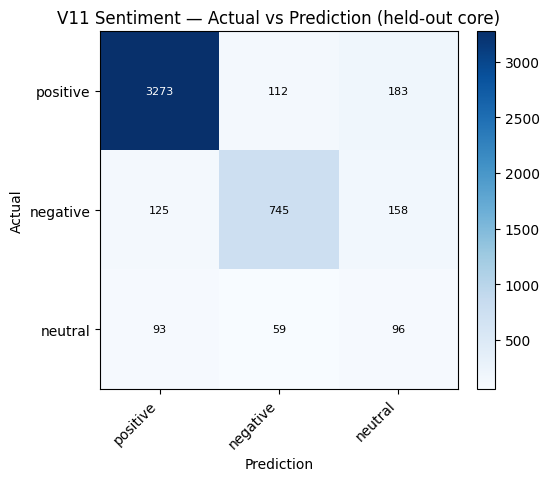

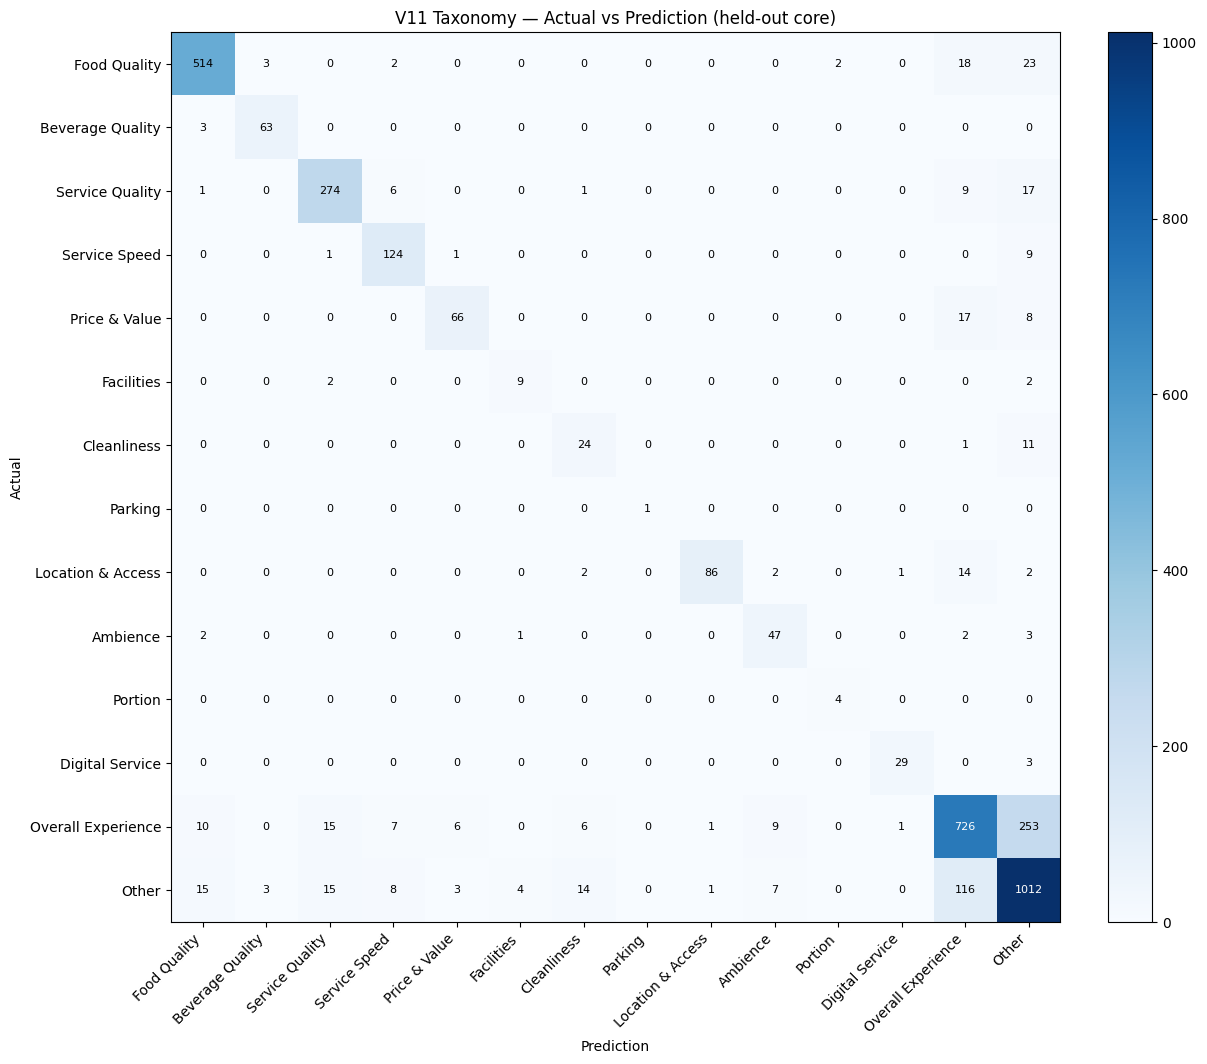

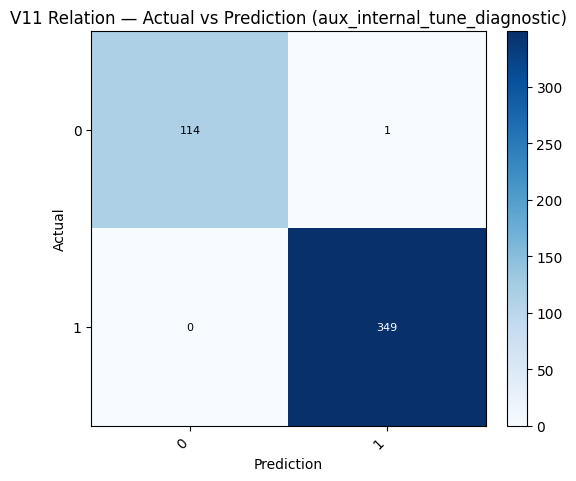

,task,stage,epoch,train_loss,validation_loss,macro_f1,positive_f1,negative_f1,neutral_f1,aspect_f1,relation_f1,opinion_f1
0,sentiment,core_fit,1.0,0.514048,0.339772,0.587892,0.934692,0.828986,0.000000,NaN,NaN,NaN
1,sentiment,normal_training,2.0,0.280516,0.378230,0.646507,0.927855,0.833096,0.178571,NaN,NaN,NaN
2,sentiment,normal_training,3.0,0.193629,0.375714,0.666319,0.930456,0.829694,0.238806,NaN,NaN,NaN
3,sentiment,normal_training,4.0,0.167731,0.357614,0.659439,0.931927,0.835007,0.211382,NaN,NaN,NaN
4,sentiment,neutral_hardening,5.0,0.179101,0.385535,0.672747,0.922325,0.834553,0.261364,NaN,NaN,NaN
5,aspect,aspect_span,1.0,0.212860,NaN,NaN,NaN,NaN,NaN,0.631746,NaN,NaN
6,aspect,aspect_span,2.0,0.124348,NaN,NaN,NaN,NaN,NaN,0.630066,NaN,NaN
7,opinion,opinion_span,1.0,0.188964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.931926
8,opinion,opinion_span,2.0,0.081137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.964323
9,opinion,opinion_span,3.0,0.044894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977687


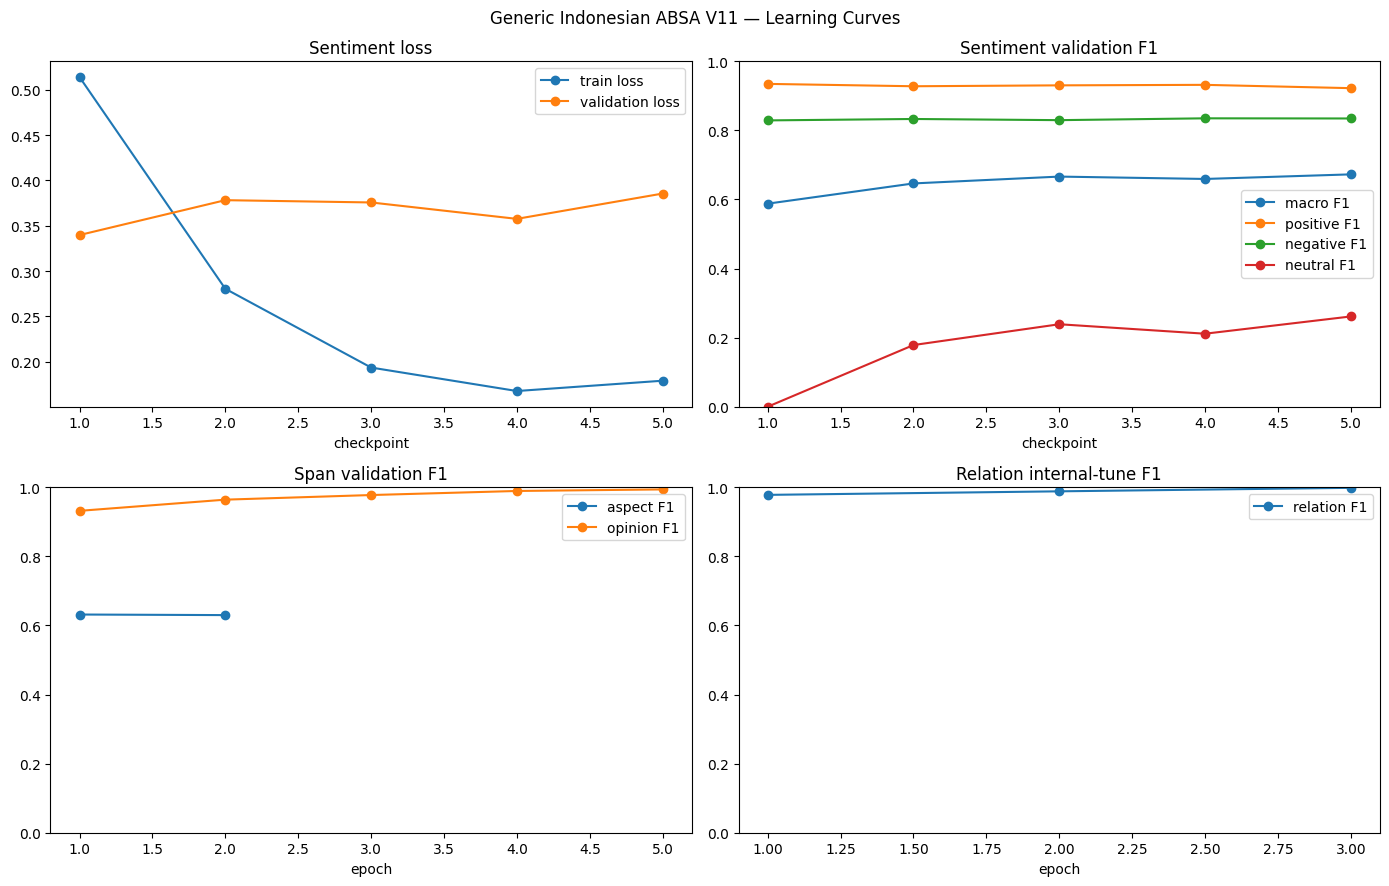

e2e:   0%|          | 0/564 [00:00<?, ?it/s]

e2e:   0%|          | 0/518 [00:00<?, ?it/s]

e2e:   0%|          | 0/580 [00:00<?, ?it/s]

e2e:   0%|          | 0/532 [00:00<?, ?it/s]

e2e:   0%|          | 0/521 [00:00<?, ?it/s]

...

,domain,sentiment_n,review_n,sentiment_macro_f1,positive_f1,negative_f1,neutral_f1,aspect_f1,aspect_sentiment_f1,taxonomy_accuracy,taxonomy_macro_f1,relation_f1,scope
0,coursera,712,564,0.606660,0.928372,0.639640,0.251969,0.698140,0.604255,0.827815,0.554730,None,heldout_core_gold_compatible
1,food,662,518,0.555012,0.862912,0.603448,0.198675,0.610723,0.515695,0.803333,0.594794,None,heldout_core_gold_compatible
2,hotel,883,580,0.608433,0.957708,0.708861,0.158730,0.702652,0.643657,0.771654,0.777334,None,heldout_core_gold_compatible
3,laptop,675,532,0.677191,0.920398,0.843318,0.267857,0.745868,0.652935,0.702448,0.575244,None,heldout_core_gold_compatible
4,phone,1153,521,0.727179,0.933413,0.855967,0.392157,0.547062,0.512208,0.859497,0.781885,None,heldout_core_gold_compatible
5,restaurant,759,536,0.697077,0.936709,0.774775,0.379747,0.700000,0.636274,0.892982,0.760339,None,heldout_core_gold_compatible


,component,metric,precision,recall,f1,accuracy,scope,is_gold_gate,value
0,sentiment,positive,0.937554,0.917321,0.927327,NaN,heldout_core,True,NaN
1,sentiment,negative,0.813319,0.724708,0.766461,NaN,heldout_core,True,NaN
2,sentiment,neutral,0.219680,0.387097,0.280292,NaN,heldout_core,True,NaN
3,sentiment,macro,0.656851,0.676375,0.658027,0.849298,heldout_core,True,NaN
4,aspect,exact_span,0.750852,0.577461,0.652840,NaN,heldout_core,True,NaN
5,aspect_sentiment,exact_match,0.683075,0.517350,0.588773,NaN,heldout_core,True,NaN
6,opinion,exact_span,0.907140,0.921207,0.914119,NaN,heldout_terma,True,NaN
7,relation,binary_pair_diagnostic,0.997143,1.000000,0.998569,NaN,train_derived_aux_tune_not_gold,False,NaN
8,taxonomy,canonical_category,NaN,NaN,0.828573,0.817957,heldout_core,True,NaN
9,calibration,ECE,NaN,NaN,NaN,NaN,heldout_core,True,0.029144


,metric,value,target,evaluated,pass,scope
0,negative_f1,0.766461,0.84,True,False,heldout_gold_required
1,neutral_f1,0.280292,0.50,True,False,heldout_gold_required
2,sentiment_macro_f1,0.658027,0.75,True,False,heldout_gold_required
3,aspect_f1,0.652840,0.75,True,False,heldout_gold_required
4,aspect_sentiment_f1,0.588773,0.70,True,False,heldout_gold_required
5,relation_f1,NaN,0.55,False,False,heldout_gold_required
6,taxonomy_macro_f1,0.828573,0.75,True,True,heldout_gold_required


,run_mode,status,updated_at_utc,use_dapt,use_silver,use_v10_synthetic,use_v11_synthetic,dapt_used,sentiment_macro_f1,positive_f1,...,neutral_f1,aspect_f1,aspect_sentiment_f1,opinion_f1,relation_f1_human_gold,relation_f1_aux_internal,taxonomy_accuracy,taxonomy_macro_f1,calibration_ece,calibration_brier
0,base,not_run,NaN,False,False,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dapt_only,not_run,NaN,True,False,False,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,silver_only,not_run,NaN,False,True,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dapt_silver,not_run,NaN,True,True,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dapt_silver_v11synthetic,completed,2026-08-31T04:52:07.386709+00:00,True,True,True,True,True,0.658027,0.927327,...,0.280292,0.65284,0.588773,0.914119,None,0.998569,0.817957,0.828573,0.029144,0.216287


V11 canonical outputs: /content/generic_indonesian_absa_v11_fixed/outputs


In [60]:
# ============================================================
# V11 CANONICAL EVALUATION, CONFUSION MATRICES, LEARNING CURVES, PER-DOMAIN
# ============================================================
REPORT_DIR = BASE_DIR / "reports"
OUTPUT_DIR = BASE_DIR / "outputs"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _safe_metric(obj, *keys):
    try:
        for key in keys:
            obj = obj[key]
        return float(obj)
    except Exception:
        return None


def _plot_confusion(y_true, y_pred, labels, title, output_path):
    if y_true is None or y_pred is None or len(y_true) == 0:
        return None
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    size = max(6, min(16, 0.65 * len(labels) + 4))
    fig, ax = plt.subplots(figsize=(size, size * 0.82))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(labels)), labels=labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)), labels=labels)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    if len(labels) <= 20:
        cutoff = matrix.max() * 0.55 if matrix.size else 0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(
                    j, i, int(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > cutoff else "black",
                    fontsize=8,
                )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    return matrix


# Confusion matrix: sentiment held-out core.
SENTIMENT_CM = None
if SENT_TEST:
    _sent_y_true = [ID2SENT[i] for i in SENT_TEST["y_true"]]
    _sent_y_pred = [ID2SENT[i] for i in SENT_TEST["y_pred"]]
    SENTIMENT_CM = _plot_confusion(
        _sent_y_true, _sent_y_pred, CONFIG["sentiment_labels"],
        "V11 Sentiment — Actual vs Prediction (held-out core)",
        OUTPUT_DIR / "confusion_matrix_sentiment_v11.png",
    )

# Confusion matrix: taxonomy held-out core.
TAXONOMY_CM = None
if TAXONOMY_TEST_METRICS:
    _tax_ids = sorted(set(TAXONOMY_TEST_METRICS["y_true"]) | set(TAXONOMY_TEST_METRICS["y_pred"]))
    _tax_labels = [ID2TAX[i] for i in _tax_ids]
    TAXONOMY_CM = _plot_confusion(
        [ID2TAX[i] for i in TAXONOMY_TEST_METRICS["y_true"]],
        [ID2TAX[i] for i in TAXONOMY_TEST_METRICS["y_pred"]],
        _tax_labels,
        "V11 Taxonomy — Actual vs Prediction (held-out core)",
        OUTPUT_DIR / "confusion_matrix_taxonomy_v11.png",
    )

# Confusion matrix: human GOLD test when available; otherwise clearly labelled
# train-derived AUX diagnostic. The latter never becomes the canonical relation gate.
RELATION_CM = None
RELATION_CM_SCOPE = None
_relation_cm_items = relation_test if relation_test else relation_val
if relation_model is not None and _relation_cm_items:
    RELATION_CM_SCOPE = "human_gold_test" if relation_test else "aux_internal_tune_diagnostic"
    _relation_cm_eval = eval_relation(relation_model, _relation_cm_items, RELATION_THRESHOLD)
    _rel_pred = [int(x >= RELATION_THRESHOLD) for x in _relation_cm_eval["scores"]]
    RELATION_CM = _plot_confusion(
        _relation_cm_eval["labels"], _rel_pred, [0, 1],
        f"V11 Relation — Actual vs Prediction ({RELATION_CM_SCOPE})",
        OUTPUT_DIR / "confusion_matrix_relation_v11.png",
    )


# Unified training history schema required by V11.
_history_rows = []
for _, row in sentiment_history.iterrows() if len(sentiment_history) else []:
    _history_rows.append({
        "task": "sentiment", "stage": row.get("stage"),
        "epoch": row.get("epoch"), "train_loss": row.get("train_loss"),
        "validation_loss": row.get("validation_loss", row.get("val_loss")),
        "macro_f1": row.get("macro_f1", row.get("val_macro_f1")),
        "positive_f1": row.get("positive_f1", row.get("val_positive_f1")),
        "negative_f1": row.get("negative_f1", row.get("val_negative_f1")),
        "neutral_f1": row.get("neutral_f1", row.get("val_neutral_f1")),
        "aspect_f1": np.nan, "relation_f1": np.nan,
    })
for _, row in aspect_history.iterrows() if len(aspect_history) else []:
    _history_rows.append({
        "task": "aspect", "stage": "aspect_span", "epoch": row.get("epoch"),
        "train_loss": row.get("train_loss"), "validation_loss": np.nan,
        "macro_f1": np.nan, "positive_f1": np.nan, "negative_f1": np.nan,
        "neutral_f1": np.nan, "aspect_f1": row.get("val_f1"),
        "relation_f1": np.nan,
    })
for _, row in opinion_history.iterrows() if len(opinion_history) else []:
    _history_rows.append({
        "task": "opinion", "stage": "opinion_span", "epoch": row.get("epoch"),
        "train_loss": row.get("train_loss"), "validation_loss": np.nan,
        "macro_f1": np.nan, "positive_f1": np.nan, "negative_f1": np.nan,
        "neutral_f1": np.nan, "aspect_f1": np.nan,
        "opinion_f1": row.get("val_f1"), "relation_f1": np.nan,
    })
for _, row in relation_history.iterrows() if len(relation_history) else []:
    _history_rows.append({
        "task": "relation", "stage": row.get("stage"), "epoch": row.get("epoch"),
        "train_loss": row.get("train_loss"), "validation_loss": row.get("validation_loss"),
        "macro_f1": np.nan, "positive_f1": np.nan, "negative_f1": np.nan,
        "neutral_f1": np.nan, "aspect_f1": np.nan,
        "relation_f1": row.get("relation_f1"),
    })
TRAINING_HISTORY_V11 = pd.DataFrame(_history_rows)
_required_history_cols = [
    "task", "stage", "epoch", "train_loss", "validation_loss", "macro_f1",
    "positive_f1", "negative_f1", "neutral_f1", "aspect_f1", "relation_f1",
]
for _column in _required_history_cols:
    if _column not in TRAINING_HISTORY_V11:
        TRAINING_HISTORY_V11[_column] = np.nan
TRAINING_HISTORY_V11 = TRAINING_HISTORY_V11[_required_history_cols + [
    c for c in TRAINING_HISTORY_V11.columns if c not in _required_history_cols
]]
TRAINING_HISTORY_V11.to_csv(OUTPUT_DIR / "training_history_v11.csv", index=False)
display(TRAINING_HISTORY_V11)


def _plot_training_history(history, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    sent = history[history["task"] == "sentiment"]
    if len(sent):
        x = np.arange(1, len(sent) + 1)
        axes[0, 0].plot(x, sent["train_loss"], marker="o", label="train loss")
        axes[0, 0].plot(x, sent["validation_loss"], marker="o", label="validation loss")
        axes[0, 0].set_title("Sentiment loss")
        axes[0, 0].set_xlabel("checkpoint")
        axes[0, 0].legend()
        for col, label in [
            ("macro_f1", "macro F1"), ("positive_f1", "positive F1"),
            ("negative_f1", "negative F1"), ("neutral_f1", "neutral F1"),
        ]:
            axes[0, 1].plot(x, sent[col], marker="o", label=label)
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].set_title("Sentiment validation F1")
        axes[0, 1].set_xlabel("checkpoint")
        axes[0, 1].legend()
    span = history[history["task"].isin(["aspect", "opinion"])]
    for task_name, group in span.groupby("task"):
        metric = "aspect_f1" if task_name == "aspect" else "opinion_f1"
        if metric in group:
            axes[1, 0].plot(group["epoch"], group[metric], marker="o", label=f"{task_name} F1")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_title("Span validation F1")
    axes[1, 0].set_xlabel("epoch")
    if len(span):
        axes[1, 0].legend()
    rel = history[history["task"] == "relation"]
    if len(rel):
        axes[1, 1].plot(rel["epoch"], rel["relation_f1"], marker="o", label="relation F1")
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, "Relation history unavailable", ha="center", va="center")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_title("Relation internal-tune F1")
    axes[1, 1].set_xlabel("epoch")
    fig.suptitle("Generic Indonesian ABSA V11 — Learning Curves")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


_plot_training_history(TRAINING_HISTORY_V11, OUTPUT_DIR / "learning_curve.png")


# Per-domain held-out metrics. Synthetic and SILVER are not evaluated here.
_domain_sent_items = list(test_sent) + list(gmaps_test_sent)
_domain_record_items = list(test_unified) + list(gmaps_test_records)
_domain_tax_items = list(_tax_core_test) + _build_tax_examples(gmaps_test_records, {"test"}, 1.0)
_domain_names = sorted(
    set(x.get("domain", "unknown") for x in _domain_sent_items)
    | set(r.get("domain", "unknown") for r in _domain_record_items)
)
_domain_rows = []
for domain_name in _domain_names:
    sent_subset = [x for x in _domain_sent_items if x.get("domain") == domain_name]
    record_subset = [r for r in _domain_record_items if r.get("domain") == domain_name]
    gmaps_record_subset = [r for r in gmaps_test_records if r.get("domain") == domain_name]
    tax_subset = [x for x in _domain_tax_items if x.get("domain") == domain_name]
    sent_metrics = eval_sentiment(sentiment_model, sent_subset) if sentiment_model is not None and sent_subset else None
    e2e_metrics = evaluate_e2e(record_subset) if aspect_model is not None and sentiment_model is not None and record_subset else None
    tax_metrics = eval_taxonomy(taxonomy_model, tax_subset) if taxonomy_model is not None and tax_subset else None
    gmaps_domain_metrics = evaluate_gmaps_gold(gmaps_record_subset) if gmaps_record_subset else None
    _domain_rows.append({
        "domain": domain_name, "sentiment_n": len(sent_subset),
        "review_n": len(record_subset),
        "sentiment_macro_f1": _safe_metric(sent_metrics, "macro_f1"),
        "positive_f1": _safe_metric(sent_metrics, "per_class_f1", "positive"),
        "negative_f1": _safe_metric(sent_metrics, "per_class_f1", "negative"),
        "neutral_f1": _safe_metric(sent_metrics, "per_class_f1", "neutral"),
        "aspect_f1": _safe_metric(e2e_metrics, "aspect", "f1"),
        "aspect_sentiment_f1": _safe_metric(e2e_metrics, "aspect_sentiment", "f1"),
        "taxonomy_accuracy": _safe_metric(tax_metrics, "accuracy"),
        "taxonomy_macro_f1": _safe_metric(tax_metrics, "macro_f1"),
        "relation_f1": _safe_metric(gmaps_domain_metrics, "relation_primary_exact", "f1"),
        "scope": "heldout_human_gmaps_gold" if gmaps_record_subset else "heldout_core_gold_compatible",
    })
PER_DOMAIN_METRICS_V11 = pd.DataFrame(_domain_rows)
PER_DOMAIN_METRICS_V11.to_csv(OUTPUT_DIR / "per_domain_metrics_v11.csv", index=False)
display(PER_DOMAIN_METRICS_V11)


# One canonical table: every metric declares its evaluation scope.
_canonical_rows = []
if SENT_TEST:
    for label in CONFIG["sentiment_labels"]:
        _canonical_rows.append({
            "component": "sentiment", "metric": label,
            "precision": SENT_TEST["per_class_precision"][label],
            "recall": SENT_TEST["per_class_recall"][label],
            "f1": SENT_TEST["per_class_f1"][label], "accuracy": np.nan,
            "scope": "heldout_core", "is_gold_gate": True,
        })
    _canonical_rows.append({
        "component": "sentiment", "metric": "macro",
        "precision": float(np.mean(list(SENT_TEST["per_class_precision"].values()))),
        "recall": float(np.mean(list(SENT_TEST["per_class_recall"].values()))),
        "f1": SENT_TEST["macro_f1"], "accuracy": SENT_TEST["accuracy"],
        "scope": "heldout_core", "is_gold_gate": True,
    })
if E2E_TEST:
    _canonical_rows.extend([
        {"component": "aspect", "metric": "exact_span", **{k: E2E_TEST["aspect"][k] for k in ["precision", "recall", "f1"]}, "accuracy": np.nan, "scope": "heldout_core", "is_gold_gate": True},
        {"component": "aspect_sentiment", "metric": "exact_match", **{k: E2E_TEST["aspect_sentiment"][k] for k in ["precision", "recall", "f1"]}, "accuracy": np.nan, "scope": "heldout_core", "is_gold_gate": True},
    ])
if OPINION_TEST_METRICS:
    _canonical_rows.append({
        "component": "opinion", "metric": "exact_span",
        **{k: OPINION_TEST_METRICS[k] for k in ["precision", "recall", "f1"]},
        "accuracy": np.nan, "scope": "heldout_terma", "is_gold_gate": True,
    })
if RELATION_TEST_METRICS:
    _canonical_rows.append({
        "component": "relation", "metric": "binary_pair",
        **{k: RELATION_TEST_METRICS[k] for k in ["precision", "recall", "f1"]},
        "accuracy": np.nan, "scope": "heldout_human_gmaps_gold", "is_gold_gate": True,
    })
elif RELATION_AUX_TUNE_METRICS:
    _canonical_rows.append({
        "component": "relation", "metric": "binary_pair_diagnostic",
        **{k: RELATION_AUX_TUNE_METRICS[k] for k in ["precision", "recall", "f1"]},
        "accuracy": np.nan, "scope": "train_derived_aux_tune_not_gold",
        "is_gold_gate": False,
    })
if TAXONOMY_TEST_METRICS:
    _canonical_rows.append({
        "component": "taxonomy", "metric": "canonical_category",
        "precision": np.nan, "recall": np.nan,
        "f1": TAXONOMY_TEST_METRICS["macro_f1"],
        "accuracy": TAXONOMY_TEST_METRICS["accuracy"],
        "scope": "heldout_core", "is_gold_gate": True,
    })
_cal = globals().get("V11_CALIBRATION", globals().get("V10_CALIBRATION"))
if _cal:
    _canonical_rows.extend([
        {"component": "calibration", "metric": "ECE", "value": _cal["ece"], "scope": "heldout_core", "is_gold_gate": True},
        {"component": "calibration", "metric": "Brier Score", "value": _cal["brier"], "scope": "heldout_core", "is_gold_gate": True},
    ])
CANONICAL_EVALUATION_V11 = pd.DataFrame(_canonical_rows)
CANONICAL_EVALUATION_V11.to_csv(OUTPUT_DIR / "canonical_evaluation_v11.csv", index=False)
display(CANONICAL_EVALUATION_V11)

V11_RUN_METRICS = {
    "run_mode": RUN_MODE,
    "positive_precision": _safe_metric(SENT_TEST, "per_class_precision", "positive"),
    "positive_recall": _safe_metric(SENT_TEST, "per_class_recall", "positive"),
    "positive_f1": _safe_metric(SENT_TEST, "per_class_f1", "positive"),
    "negative_precision": _safe_metric(SENT_TEST, "per_class_precision", "negative"),
    "negative_recall": _safe_metric(SENT_TEST, "per_class_recall", "negative"),
    "negative_f1": _safe_metric(SENT_TEST, "per_class_f1", "negative"),
    "neutral_precision": _safe_metric(SENT_TEST, "per_class_precision", "neutral"),
    "neutral_recall": _safe_metric(SENT_TEST, "per_class_recall", "neutral"),
    "neutral_f1": _safe_metric(SENT_TEST, "per_class_f1", "neutral"),
    "sentiment_macro_f1": _safe_metric(SENT_TEST, "macro_f1"),
    "aspect_precision": _safe_metric(E2E_TEST, "aspect", "precision"),
    "aspect_recall": _safe_metric(E2E_TEST, "aspect", "recall"),
    "aspect_f1": _safe_metric(E2E_TEST, "aspect", "f1"),
    "aspect_sentiment_precision": _safe_metric(E2E_TEST, "aspect_sentiment", "precision"),
    "aspect_sentiment_recall": _safe_metric(E2E_TEST, "aspect_sentiment", "recall"),
    "aspect_sentiment_f1": _safe_metric(E2E_TEST, "aspect_sentiment", "f1"),
    "opinion_precision": _safe_metric(OPINION_TEST_METRICS, "precision"),
    "opinion_recall": _safe_metric(OPINION_TEST_METRICS, "recall"),
    "opinion_f1": _safe_metric(OPINION_TEST_METRICS, "f1"),
    "relation_precision_human_gold": _safe_metric(RELATION_TEST_METRICS, "precision"),
    "relation_recall_human_gold": _safe_metric(RELATION_TEST_METRICS, "recall"),
    "relation_f1_human_gold": _safe_metric(RELATION_TEST_METRICS, "f1"),
    "relation_f1_aux_internal": _safe_metric(RELATION_AUX_TUNE_METRICS, "f1"),
    "taxonomy_accuracy": _safe_metric(TAXONOMY_TEST_METRICS, "accuracy"),
    "taxonomy_macro_f1": _safe_metric(TAXONOMY_TEST_METRICS, "macro_f1"),
    "calibration_ece": _safe_metric(_cal, "ece"),
    "calibration_brier": _safe_metric(_cal, "brier"),
    "dapt_used": bool(DAPT_ACTUAL_USED),
    "data_audit_pass": bool(V11_DATA_AUDIT_PASS),
}

_target_key_map = {
    "negative_f1": "negative_f1",
    "neutral_f1": "neutral_f1",
    "sentiment_macro_f1": "sentiment_macro_f1",
    "aspect_f1": "aspect_f1",
    "aspect_sentiment_f1": "aspect_sentiment_f1",
    "relation_f1": "relation_f1_human_gold",
    "taxonomy_macro_f1": "taxonomy_macro_f1",
}
_gate_rows = []
for metric_name, target in CONFIG["v11_targets"].items():
    value = V11_RUN_METRICS.get(_target_key_map[metric_name])
    _gate_rows.append({
        "metric": metric_name, "value": value, "target": target,
        "evaluated": value is not None,
        "pass": bool(value >= target) if value is not None else False,
        "scope": "heldout_gold_required",
    })
V11_TARGET_GATE = pd.DataFrame(_gate_rows)
V11_TARGET_GATE.to_csv(OUTPUT_DIR / "v11_target_gate.csv", index=False)
display(V11_TARGET_GATE)

_run_json_path = REPORT_DIR / f"v11_ablation_{RUN_MODE}.json"
_run_json_path.write_text(
    json.dumps(V11_RUN_METRICS, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)

# Upsert current run while retaining explicit not-run rows for all supported modes.
_ablation_path = OUTPUT_DIR / "ablation_results_v11.csv"
_ablation_columns = [
    "run_mode", "status", "updated_at_utc", "use_dapt", "use_silver",
    "use_v10_synthetic", "use_v11_synthetic", "dapt_used",
    "sentiment_macro_f1", "positive_f1", "negative_f1", "neutral_f1",
    "aspect_f1", "aspect_sentiment_f1", "opinion_f1",
    "relation_f1_human_gold", "relation_f1_aux_internal",
    "taxonomy_accuracy", "taxonomy_macro_f1", "calibration_ece", "calibration_brier",
]
if _ablation_path.exists():
    _ablation_df = pd.read_csv(_ablation_path)
else:
    _ablation_df = pd.DataFrame([
        {
            "run_mode": mode, "status": "not_run",
            "use_dapt": flags["use_dapt"], "use_silver": flags["use_silver"],
            "use_v10_synthetic": flags["use_synthetic"],
            "use_v11_synthetic": flags["use_v11_synthetic"],
        }
        for mode, flags in V11_ABLATIONS.items()
    ])
_current_row = {
    **V11_RUN_METRICS,
    "status": "completed", "updated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "use_dapt": ABLATION["use_dapt"], "use_silver": ABLATION["use_silver"],
    "use_v10_synthetic": ABLATION["use_synthetic"],
    "use_v11_synthetic": ABLATION["use_v11_synthetic"],
}
_ablation_df = _ablation_df[_ablation_df["run_mode"] != RUN_MODE]
_ablation_df = pd.concat([_ablation_df, pd.DataFrame([_current_row])], ignore_index=True)
_mode_order = {mode: i for i, mode in enumerate(V11_ABLATIONS)}
_ablation_df["_order"] = _ablation_df["run_mode"].map(_mode_order)
_ablation_df = _ablation_df.sort_values("_order").drop(columns="_order")
for _column in _ablation_columns:
    if _column not in _ablation_df:
        _ablation_df[_column] = np.nan
ABLATION_RESULTS_V11 = _ablation_df[_ablation_columns]
ABLATION_RESULTS_V11.to_csv(_ablation_path, index=False)
display(ABLATION_RESULTS_V11)
print("V11 canonical outputs:", OUTPUT_DIR)


### 18.1 Menganalisis Error Held-Out


In [61]:
# ============================================================
# V11 ERROR ANALYSIS — HELD-OUT ONLY
# ============================================================
ERROR_ANALYSIS_COLUMNS = [
    "review_text", "gold_aspect", "pred_aspect", "gold_sentiment",
    "pred_sentiment", "gold_taxonomy", "pred_taxonomy", "gold_relation",
    "pred_relation", "error_type", "domain", "source_dataset",
]


def _relation_strings_from_prediction(item):
    out = []
    aspect = str(item.get("aspect_term") or "")
    for ev in item.get("opinion_evidence", []) or []:
        if ev.get("term"):
            out.append(f"{aspect}::{ev['term']}")
    if not out and item.get("opinion_term"):
        out.append(f"{aspect}::{item['opinion_term']}")
    return out


def generate_error_analysis(records_eval):
    rows = []
    if aspect_model is None or sentiment_model is None:
        return pd.DataFrame(columns=ERROR_ANALYSIS_COLUMNS)
    coref_re = re.compile(r"(?:\b(?:ini|itu|dia|mereka|beliau|tersebut)\b|\b\w+nya\b)", re.I)
    for record in tqdm(records_eval, desc="error-analysis"):
        pred = predict_absa(record["text"], "scientific_balanced")
        pred_by_span = {
            (int(x["aspect_start"]), int(x["aspect_end"])): x for x in pred
        }
        matched_pred_spans = set()
        for ann in record.get("annotations", []):
            gold_sent = canonical_sentiment_label(ann.get("sentiment"))
            if gold_sent not in VALID_SENTIMENTS:
                continue
            implicit = bool(ann.get("implicit", False) or ann.get("aspect_start") is None)
            gold_tax = canonical_taxonomy_label(
                ann.get("taxonomy_label") or ann.get("aspect_category") or ann.get("implicit_category"),
                ann.get("aspect_term") or "", record.get("domain", ""),
            )
            gold_rel = None
            if ann.get("opinion_term"):
                gold_rel = f"{ann.get('aspect_term') or '<IMPLICIT>'}::{ann.get('opinion_term')}"
            if implicit:
                base = {
                    "review_text": record["text"],
                    "gold_aspect": f"<IMPLICIT:{gold_tax}>",
                    "pred_aspect": json.dumps([x.get("aspect_term") for x in pred], ensure_ascii=False),
                    "gold_sentiment": gold_sent, "pred_sentiment": None,
                    "gold_taxonomy": gold_tax,
                    "pred_taxonomy": json.dumps([x.get("normalized_category") for x in pred], ensure_ascii=False),
                    "gold_relation": gold_rel,
                    "pred_relation": json.dumps([
                        z for x in pred for z in _relation_strings_from_prediction(x)
                    ], ensure_ascii=False),
                    "error_type": "implicit aspect failure",
                    "domain": record.get("domain"),
                    "source_dataset": record.get("source_dataset"),
                }
                rows.append(base)
                continue

            span = (int(ann["aspect_start"]), int(ann["aspect_end"]))
            item = pred_by_span.get(span)
            if item is None:
                base = {
                    "review_text": record["text"], "gold_aspect": ann.get("aspect_term"),
                    "pred_aspect": json.dumps([x.get("aspect_term") for x in pred], ensure_ascii=False),
                    "gold_sentiment": gold_sent, "pred_sentiment": None,
                    "gold_taxonomy": gold_tax, "pred_taxonomy": None,
                    "gold_relation": gold_rel, "pred_relation": None,
                    "error_type": "missed aspect", "domain": record.get("domain"),
                    "source_dataset": record.get("source_dataset"),
                }
                rows.append(base)
                if coref_re.search(str(record["text"])):
                    rows.append({**base, "error_type": "coreference failure"})
                continue

            matched_pred_spans.add(span)
            pred_sent = item.get("sentiment")
            pred_tax = canonical_taxonomy_label(
                item.get("normalized_category") or item.get("taxonomy_id"),
                item.get("aspect_term") or "", record.get("domain", ""),
            )
            pred_relations = _relation_strings_from_prediction(item)
            common = {
                "review_text": record["text"], "gold_aspect": ann.get("aspect_term"),
                "pred_aspect": item.get("aspect_term"), "gold_sentiment": gold_sent,
                "pred_sentiment": pred_sent, "gold_taxonomy": gold_tax,
                "pred_taxonomy": pred_tax, "gold_relation": gold_rel,
                "pred_relation": json.dumps(pred_relations, ensure_ascii=False),
                "domain": record.get("domain"),
                "source_dataset": record.get("source_dataset"),
            }
            if pred_sent != gold_sent:
                rows.append({**common, "error_type": "wrong sentiment"})
            if pred_tax != gold_tax:
                rows.append({**common, "error_type": "wrong taxonomy"})
            if gold_rel is not None and gold_rel not in pred_relations:
                rows.append({**common, "error_type": "relation failure"})
                if coref_re.search(str(record["text"])):
                    rows.append({**common, "error_type": "coreference failure"})

        for span, item in pred_by_span.items():
            if span not in matched_pred_spans:
                rows.append({
                    "review_text": record["text"], "gold_aspect": None,
                    "pred_aspect": item.get("aspect_term"), "gold_sentiment": None,
                    "pred_sentiment": item.get("sentiment"), "gold_taxonomy": None,
                    "pred_taxonomy": item.get("normalized_category"),
                    "gold_relation": None,
                    "pred_relation": json.dumps(_relation_strings_from_prediction(item), ensure_ascii=False),
                    "error_type": "spurious aspect", "domain": record.get("domain"),
                    "source_dataset": record.get("source_dataset"),
                })
    return pd.DataFrame(rows, columns=ERROR_ANALYSIS_COLUMNS)


_error_eval_records = list(test_unified) + list(gmaps_test_records) + list(unseen_sight_unified)
ERROR_ANALYSIS_V11 = generate_error_analysis(_error_eval_records)
ERROR_ANALYSIS_V11.to_csv(OUTPUT_DIR / "error_analysis_v11.csv", index=False)
print("V11 error counts:")
display(ERROR_ANALYSIS_V11["error_type"].value_counts().rename_axis("error_type").reset_index(name="n") if len(ERROR_ANALYSIS_V11) else ERROR_ANALYSIS_V11)
display(ERROR_ANALYSIS_V11.head(50))


error-analysis:   0%|          | 0/3775 [00:00<?, ?it/s]

V11 error counts:


,error_type,n
0,missed aspect,2090
1,coreference failure,1436
2,implicit aspect failure,1332
3,spurious aspect,684
4,wrong taxonomy,435
5,wrong sentiment,243


,review_text,gold_aspect,pred_aspect,gold_sentiment,pred_sentiment,gold_taxonomy,pred_taxonomy,gold_relation,pred_relation,error_type,domain,source_dataset
0,Sangat direkomendasikan.,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA
1,Saya sangat merekomendasikannya.,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA
2,Terima kasih .,<IMPLICIT:Overall Experience>,[],positive,None,Overall Experience,[],None,[],implicit aspect failure,coursera,M-ABSA
3,Sangat direkomendasikan!,<IMPLICIT:Food Quality>,[],positive,None,Food Quality,[],None,[],implicit aspect failure,food,M-ABSA
4,Saya belajar banyak.,<IMPLICIT:Overall Experience>,[],positive,None,Overall Experience,[],None,[],implicit aspect failure,coursera,M-ABSA
5,Saya sungguh menikmatinya.,<IMPLICIT:Overall Experience>,[],positive,None,Overall Experience,[],None,[],implicit aspect failure,coursera,M-ABSA
6,"Ya, sebagian besar pengkodean adalah mempelaja...",teori dasar,[],negative,None,Other,None,None,None,missed aspect,coursera,M-ABSA
7,"Ya, sebagian besar pengkodean adalah mempelaja...",teori dasar,[],negative,None,Other,None,None,None,coreference failure,coursera,M-ABSA
8,"Ya, sebagian besar pengkodean adalah mempelaja...",<IMPLICIT:Other>,[],negative,None,Other,[],None,[],implicit aspect failure,coursera,M-ABSA
9,"Terima kasih banyak, Dr. Chuck dan tim!",Dr. Chuck dan tim,"[""Dr. Chuck""]",positive,None,Overall Experience,None,None,None,missed aspect,coursera,M-ABSA


## Fase 19 — Menjalankan Final Production Gate


In [62]:
# ============================================================
# V11 FINAL VERIFICATION / PRE-PRODUCTION GATE
# ============================================================
print("=" * 96)
print("V11 FINAL VERIFICATION —", RUN_MODE)
print("=" * 96)
print("Dataset audit:", V11_DATA_AUDIT_PASS)
print("Core normalized-text leakage:", remaining_overlap)
print("Sight unseen test records:", len(unseen_sight_unified))
print("GMaps SILVER diagnostic records:", len(gmaps_silver_all))
print("GMaps human-approved records:", len(gmaps_gold_records))
print("DAPT used:", DAPT_ACTUAL_USED, "| corpus:", DAPT_CORPUS_META)
print(
    "Relation learned:", relation_model is not None,
    "| supervision:", RELATION_SUPERVISION,
    "| HUMAN GOLD validated:", RELATION_GOLD_VALIDATED,
)

_heldout_target_pass = bool(
    len(V11_TARGET_GATE)
    and V11_TARGET_GATE["evaluated"].all()
    and V11_TARGET_GATE["pass"].all()
)
production_requirements = {
    "v11_heldout_target_gate_pass": _heldout_target_pass,
    "human_approved_gmaps_gold_available": len(gmaps_gold_records) > 0,
    "relation_human_gold_validated": RELATION_GOLD_VALIDATED,
    "taxonomy_heldout_available": TAXONOMY_TEST_METRICS is not None,
    "calibration_report_available": globals().get("V11_CALIBRATION") is not None,
    "data_leakage_checks_pass": V11_DATA_AUDIT_PASS and all(v == 0 for v in remaining_overlap.values()),
    "actual_class_exposure_logged": len(V11_EXPOSURE_DF) > 0,
    "neutral_hardening_stage_executed": bool(
        len(sentiment_history)
        and (sentiment_history["stage"] == "neutral_hardening").any()
    ),
    "latency_throughput_benchmarked": False,
    "monitoring_drift_rollback_security_ready": False,
}
PRODUCTION_STATUS = (
    "production_ready" if all(production_requirements.values())
    else "research / pre-production candidate"
)
print("V11 target gate:")
display(V11_TARGET_GATE)
print("Production requirements:", json.dumps(production_requirements, indent=2))
print("V11 STATUS:", PRODUCTION_STATUS)
print("Required outputs:")
for _name in [
    "training_history_v11.csv", "learning_curve.png", "error_analysis_v11.csv",
    "ablation_results_v11.csv", "canonical_evaluation_v11.csv",
    "per_domain_metrics_v11.csv",
]:
    _path = OUTPUT_DIR / _name
    print("✓" if _path.exists() else "✗", _path)
assert PRODUCTION_STATUS != "production_ready" or all(production_requirements.values())


V11 FINAL VERIFICATION — dapt_silver_v11synthetic
Dataset audit: True
Core normalized-text leakage: {'train__validation': 0, 'train__test': 0, 'validation__test': 0}
Sight unseen test records: 524
GMaps SILVER diagnostic records: 800
GMaps human-approved records: 0
DAPT used: True | corpus: {'gmaps_train_raw': 1487, 'generic_core_train': 637, 'total': 2124, 'gmaps_ratio_actual': 0.7000941619585688, 'heldout_gmaps_overlap': 0, 'sight_overlap': 0}
Relation learned: True | supervision: aux_train_only | HUMAN GOLD validated: False
V11 target gate:


,metric,value,target,evaluated,pass,scope
0,negative_f1,0.766461,0.84,True,False,heldout_gold_required
1,neutral_f1,0.280292,0.50,True,False,heldout_gold_required
2,sentiment_macro_f1,0.658027,0.75,True,False,heldout_gold_required
3,aspect_f1,0.652840,0.75,True,False,heldout_gold_required
4,aspect_sentiment_f1,0.588773,0.70,True,False,heldout_gold_required
5,relation_f1,NaN,0.55,False,False,heldout_gold_required
6,taxonomy_macro_f1,0.828573,0.75,True,True,heldout_gold_required


Production requirements: {
  "v11_heldout_target_gate_pass": false,
  "human_approved_gmaps_gold_available": false,
  "relation_human_gold_validated": false,
  "taxonomy_heldout_available": true,
  "calibration_report_available": true,
  "data_leakage_checks_pass": true,
  "actual_class_exposure_logged": true,
  "neutral_hardening_stage_executed": true,
  "latency_throughput_benchmarked": false,
  "monitoring_drift_rollback_security_ready": false
}
V11 STATUS: research / pre-production candidate
Required outputs:
✓ /content/generic_indonesian_absa_v11_fixed/outputs/training_history_v11.csv
✓ /content/generic_indonesian_absa_v11_fixed/outputs/learning_curve.png
✓ /content/generic_indonesian_absa_v11_fixed/outputs/error_analysis_v11.csv
✓ /content/generic_indonesian_absa_v11_fixed/outputs/ablation_results_v11.csv
✓ /content/generic_indonesian_absa_v11_fixed/outputs/canonical_evaluation_v11.csv
✓ /content/generic_indonesian_absa_v11_fixed/outputs/per_domain_metrics_v11.csv


## Fase 20 — Mengekspor Model untuk Deployment Web


In [69]:
# ============================================================
# EXPORT COMPLETE ABSA V11 MODEL FOR WEB DEPLOYMENT
# Jalankan setelah seluruh training selesai
# ============================================================

import json
import shutil
from pathlib import Path
from datetime import datetime, timezone

import numpy as np


# ============================================================
# 1. LOKASI OUTPUT
# ============================================================

# Default disimpan di /content.
# Jika ingin langsung ke Google Drive, ganti menjadi:
# EXPORT_PARENT = Path("/content/drive/MyDrive/ABSA_MODEL")

EXPORT_PARENT = Path("/content")
EXPORT_DIR = EXPORT_PARENT / "absa_v11_web_bundle"
EXPORT_ZIP = EXPORT_PARENT / "absa_v11_web_bundle.zip"


# ============================================================
# 2. PASTIKAN SEMUA MODEL TERSEDIA
# ============================================================

REQUIRED_MODELS = {
    "aspect_tagger": aspect_model,
    "opinion_tagger": opinion_model,
    "sentiment_classifier": sentiment_model,
    "relation_classifier": relation_model,
    "taxonomy_classifier": taxonomy_model,
}

missing_models = [
    name
    for name, model in REQUIRED_MODELS.items()
    if model is None
]

if missing_models:
    raise RuntimeError(
        "Model belum lengkap. Model yang belum tersedia: "
        + ", ".join(missing_models)
    )

if "tokenizer" not in globals() or tokenizer is None:
    raise RuntimeError("Tokenizer belum tersedia.")

required_runtime_variables = [
    "TEMPERATURE",
    "RELATION_THRESHOLD",
    "INFERENCE_PROFILES",
    "SENT2ID",
    "ID2SENT",
    "TAG2ID",
    "ID2TAG",
    "TAX2ID",
    "ID2TAX",
]

missing_variables = [
    name for name in required_runtime_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Runtime configuration belum lengkap: "
        + ", ".join(missing_variables)
    )


# ============================================================
# 3. BUAT FOLDER EXPORT BERSIH
# ============================================================

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

if EXPORT_ZIP.exists():
    EXPORT_ZIP.unlink()

EXPORT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 4. PASTIKAN LABEL MAPPING TERSIMPAN DI CONFIG MODEL
# ============================================================

def apply_label_mapping(model, id2label, label2id):
    model.config.id2label = {
        int(key): str(value)
        for key, value in id2label.items()
    }
    model.config.label2id = {
        str(key): int(value)
        for key, value in label2id.items()
    }


apply_label_mapping(
    sentiment_model,
    ID2SENT,
    SENT2ID,
)

apply_label_mapping(
    aspect_model,
    ID2TAG,
    TAG2ID,
)

apply_label_mapping(
    opinion_model,
    ID2TAG,
    TAG2ID,
)

apply_label_mapping(
    relation_model,
    {
        0: "not_related",
        1: "related",
    },
    {
        "not_related": 0,
        "related": 1,
    },
)

apply_label_mapping(
    taxonomy_model,
    ID2TAX,
    TAX2ID,
)


# ============================================================
# 5. SIMPAN TOKENIZER
# ============================================================

TOKENIZER_DIR = EXPORT_DIR / "tokenizer"

tokenizer.save_pretrained(
    TOKENIZER_DIR
)

print("✓ Tokenizer saved")


# ============================================================
# 6. SIMPAN SEMUA MODEL
# ============================================================

for component_name, model in REQUIRED_MODELS.items():

    component_dir = EXPORT_DIR / component_name
    component_dir.mkdir(parents=True, exist_ok=True)

    model.eval()

    model.save_pretrained(
        component_dir,
        safe_serialization=True,
        max_shard_size="2GB",
    )

    print(f"✓ {component_name} saved")


# ============================================================
# 7. JSON-SAFE CONVERTER
# ============================================================

def json_safe(value):

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            json_safe(item)
            for item in value
        ]

    return value


# ============================================================
# 8. SIMPAN KONFIGURASI INFERENCE
# ============================================================

inference_config = {
    "bundle_name": "absa_v11_web_bundle",
    "model_version": CONFIG.get(
        "model_version",
        "generic_indonesian_absa_v11_fixed",
    ),
    "run_mode": globals().get(
        "RUN_MODE",
        "unknown",
    ),
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "language": "id",

    "components": {
        "tokenizer": "tokenizer",
        "aspect_model": "aspect_tagger",
        "opinion_model": "opinion_tagger",
        "sentiment_model": "sentiment_classifier",
        "relation_model": "relation_classifier",
        "taxonomy_model": "taxonomy_classifier",
    },

    "labels": {
        "sentiment_id2label": ID2SENT,
        "sentiment_label2id": SENT2ID,
        "bio_id2label": ID2TAG,
        "bio_label2id": TAG2ID,
        "taxonomy_id2label": ID2TAX,
        "taxonomy_label2id": TAX2ID,
    },

    "special_tokens": [
        "[ASP]",
        "[/ASP]",
        "[OPN]",
        "[/OPN]",
    ],

    "inference": {
        "default_profile": CONFIG.get(
            "default_profile",
            "production_precision",
        ),
        "profiles": INFERENCE_PROFILES,
        "sentiment_temperature": float(TEMPERATURE),
        "relation_threshold": float(RELATION_THRESHOLD),
        "taxonomy_confidence_threshold": float(
            CONFIG.get(
                "taxonomy_min_confidence_inference",
                0.55,
            )
        ),
        "span_max_length": int(
            CONFIG.get("span_max_length", 192)
        ),
        "span_stride": int(
            CONFIG.get("span_stride", 64)
        ),
        "sentiment_max_length": int(
            CONFIG.get("sentiment_max_length", 256)
        ),
        "dual_view_maps_inference": bool(
            CONFIG.get(
                "dual_view_maps_inference",
                True,
            )
        ),
    },

    "training_status": {
        "dapt_used": bool(
            globals().get("DAPT_ACTUAL_USED", False)
        ),
        "relation_supervision": globals().get(
            "RELATION_SUPERVISION",
            "unknown",
        ),
        "relation_human_gold_validated": bool(
            globals().get(
                "RELATION_GOLD_VALIDATED",
                False,
            )
        ),
        "human_gmaps_gold_count": len(
            globals().get(
                "gmaps_gold_records",
                [],
            )
        ),
    },
}

with open(
    EXPORT_DIR / "inference_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        json_safe(inference_config),
        file,
        ensure_ascii=False,
        indent=2,
    )

print("✓ Inference configuration saved")


# ============================================================
# 9. SIMPAN REQUIREMENTS UNTUK BACKEND WEB
# ============================================================

requirements = """torch>=2.1
transformers>=4.45,<5
safetensors>=0.4
sentencepiece
numpy
"""

(
    EXPORT_DIR / "requirements.txt"
).write_text(
    requirements,
    encoding="utf-8",
)


# ============================================================
# 10. VALIDASI FILE MODEL
# ============================================================

for component_name in REQUIRED_MODELS:

    component_dir = EXPORT_DIR / component_name

    config_file = component_dir / "config.json"

    weight_files = (
        list(component_dir.glob("*.safetensors"))
        + list(component_dir.glob("pytorch_model*.bin"))
    )

    assert config_file.exists(), (
        f"config.json tidak ditemukan: {component_name}"
    )

    assert weight_files, (
        f"Model weights tidak ditemukan: {component_name}"
    )

assert (
    TOKENIZER_DIR / "tokenizer_config.json"
).exists()

assert (
    EXPORT_DIR / "inference_config.json"
).exists()

print("✓ Export validation passed")


# ============================================================
# 11. BUAT ZIP UNTUK UPLOAD KE WEB/SERVER
# ============================================================

zip_result = shutil.make_archive(
    base_name=str(EXPORT_DIR),
    format="zip",
    root_dir=str(EXPORT_DIR.parent),
    base_dir=EXPORT_DIR.name,
)

zip_path = Path(zip_result)

print("=" * 80)
print("ABSA V11 WEB BUNDLE BERHASIL DISIMPAN")
print("=" * 80)
print("Folder :", EXPORT_DIR)
print("ZIP    :", zip_path)
print(
    "Size   :",
    f"{zip_path.stat().st_size / (1024 ** 3):.2f} GB",
)
print("=" * 80)

✓ Tokenizer saved
✓ aspect_tagger saved
✓ opinion_tagger saved
✓ sentiment_classifier saved
✓ relation_classifier saved
✓ taxonomy_classifier saved
✓ Inference configuration saved
✓ Export validation passed
ABSA V11 WEB BUNDLE BERHASIL DISIMPAN
Folder : /content/absa_v11_web_bundle
ZIP    : /content/absa_v11_web_bundle.zip
Size   : 1.89 GB


## Fase 21 — Meninjau Hasil dan Aturan Interpretasi
